# Media Polarization Lab

## 0: Data Exploration

This notebook establishes a reproducible understanding of the raw news dataset before any modeling or semantic analysis is performed.

In [50]:
# !pip install -r requirements-research.txt

In [11]:
import sys

import numpy as np
import pandas as pd
import matplotlib
import plotly
import sklearn

print("Python:", sys.version)
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Plotly:", plotly.__version__)
print("Scikit-learn:", sklearn.__version__)

Python: 3.12.14 (main, Aug 12 2026, 13:57:54) [Clang 21.0.0 (clang-2100.1.1.101)]
Pandas: 3.0.5
NumPy: 2.5.3
Matplotlib: 3.11.2
Plotly: 7.0.0
Scikit-learn: 1.9.1


## 1. Load Raw Dataset

The raw MediaCloud dataset is loaded without modification. This section establishes the dataset's size, schema, memory footprint, missingness, uniqueness, and basic integrity before any preprocessing is performed.

In [13]:
from pathlib import Path
import hashlib
import pandas as pd

# ---------------------------------------------------------
# Locate dataset
# ---------------------------------------------------------

possible_paths = [
    Path("data/raw/data.csv"),       # if Jupyter runs from project root
    Path("../data/raw/data.csv"),    # if Jupyter runs from notebooks/
]

DATA_PATH = next((path for path in possible_paths if path.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "Could not find data.csv. Expected it under data/raw/data.csv"
    )

DATA_PATH = DATA_PATH.resolve()

# ---------------------------------------------------------
# File metadata
# ---------------------------------------------------------

file_size_mb = DATA_PATH.stat().st_size / (1024 ** 2)

sha256 = hashlib.sha256()
with open(DATA_PATH, "rb") as f:
    for chunk in iter(lambda: f.read(1024 * 1024), b""):
        sha256.update(chunk)

# ---------------------------------------------------------
# Load raw dataset
# ---------------------------------------------------------

df_raw = pd.read_csv(
    DATA_PATH,
    low_memory=False
)

# ---------------------------------------------------------
# Dataset-level summary
# ---------------------------------------------------------

print("=" * 70)
print("RAW DATASET")
print("=" * 70)

print(f"File:              {DATA_PATH.name}")
print(f"Location:          {DATA_PATH}")
print(f"File size:         {file_size_mb:,.2f} MB")
print(f"SHA-256:           {sha256.hexdigest()}")
print()
print(f"Rows:              {len(df_raw):,}")
print(f"Columns:           {df_raw.shape[1]:,}")
print(f"Duplicate rows:    {df_raw.duplicated().sum():,}")
print(
    f"Memory usage:      "
    f"{df_raw.memory_usage(deep=True).sum() / (1024 ** 2):,.2f} MB"
)

print("\nColumns:")
for i, column in enumerate(df_raw.columns, start=1):
    print(f"  {i:>2}. {column}")

# ---------------------------------------------------------
# Column-level summary
# ---------------------------------------------------------

column_summary = pd.DataFrame({
    "dtype": df_raw.dtypes.astype(str),
    "non_null": df_raw.notna().sum(),
    "null": df_raw.isna().sum(),
    "null_pct": (df_raw.isna().mean() * 100).round(2),
    "unique": df_raw.nunique(dropna=True),
})

display(column_summary)

# ---------------------------------------------------------
# Preview
# ---------------------------------------------------------

print("\nFirst 5 rows:")
display(df_raw.head())

RAW DATASET
File:              data.csv
Location:          /Users/lasya/Documents/projects/media-polarization-lab/data/raw/data.csv
File size:         262.92 MB
SHA-256:           8ed8725f8f793a908e006427412f70c2d168b1b912e196990320962a62990b8e

Rows:              854,845
Columns:           8
Duplicate rows:    0
Memory usage:      307.34 MB

Columns:
   1. id
   2. indexed_date
   3. language
   4. media_name
   5. media_url
   6. publish_date
   7. title
   8. url


,dtype,non_null,null,null_pct,unique
id,str,854845,0,0.0,854845
indexed_date,str,854845,0,0.0,851629
language,str,854845,0,0.0,19
media_name,str,854845,0,0.0,234
media_url,str,854845,0,0.0,234
publish_date,str,854845,0,0.0,3703
title,str,854845,0,0.0,663218
url,str,854845,0,0.0,854845



First 5 rows:


,id,indexed_date,language,media_name,media_url,publish_date,title,url
0,418f2ae641c4b4531187342245dc68db63b234ad0041a8...,2026-03-18 23:23:50.895967+00:00,en,theroot.com,theroot.com,2016-02-24,All Skinfolk Ain’t Kinfolk: A Few Words on Ben...,https://www.theroot.com/all-skinfolk-aint-kinf...
1,601f48d89e13605f9b48115700c00c3bf0a7e13de787ee...,2026-03-05 19:25:56.214478+00:00,en,syracuse.com,syracuse.com,2016-12-29,Rep. Richard Hanna will consider run for NY go...,https://www.syracuse.com/politics/2016/12/rep_...
2,5ca989aff2d5ac75d4fc1fad09c723b076178289567d4a...,2025-10-24 02:22:00.450072+00:00,en,chicagotribune.com,chicagotribune.com,2016-10-29,Former Rage Against the Machine guitarist Tom ...,https://www.chicagotribune.com/2016/10/29/form...
3,29691c2c9665b88965b07fc73174ece3df8122939ed390...,2025-08-25 05:49:02.509639+00:00,en,scientificamerican.com,scientificamerican.com,2016-01-01,Carbon Capture May Be Too Expensive to Combat ...,http://www.scientificamerican.com/article/carb...
4,3efdb9579847144713d3689363bdbca70d9f2498505832...,2025-08-25 05:32:39.634412+00:00,en,newyorker.com,newyorker.com,2016-01-04,The Ford Foundation’s Quest to Fix the World,http://www.newyorker.com/magazine/2016/01/04/w...


## 2. Dataset Coverage and Basic Integrity

Before cleaning or filtering, we examine the dataset's temporal coverage, language distribution, source coverage, and headline duplication.

This helps determine what each field represents and whether the raw dataset matches the assumptions made in the original analysis.

In [14]:
# ---------------------------------------------------------
# Parse dates without modifying df_raw
# ---------------------------------------------------------

publish_dates = pd.to_datetime(
    df_raw["publish_date"],
    errors="coerce",
    utc=True
)

indexed_dates = pd.to_datetime(
    df_raw["indexed_date"],
    errors="coerce",
    utc=True
)

# ---------------------------------------------------------
# Temporal coverage
# ---------------------------------------------------------

print("=" * 70)
print("TEMPORAL COVERAGE")
print("=" * 70)

print("\nPublish date:")
print(f"  Earliest:       {publish_dates.min()}")
print(f"  Latest:         {publish_dates.max()}")
print(f"  Invalid dates:  {publish_dates.isna().sum():,}")
print(f"  Unique dates:   {publish_dates.dt.date.nunique():,}")

print("\nIndexed date:")
print(f"  Earliest:       {indexed_dates.min()}")
print(f"  Latest:         {indexed_dates.max()}")
print(f"  Invalid dates:  {indexed_dates.isna().sum():,}")
print(f"  Unique dates:   {indexed_dates.dt.date.nunique():,}")

# ---------------------------------------------------------
# Publication year distribution
# ---------------------------------------------------------

year_counts = (
    publish_dates.dt.year
    .value_counts()
    .sort_index()
    .rename_axis("year")
    .to_frame("articles")
)

year_counts["pct"] = (
    year_counts["articles"] / len(df_raw) * 100
).round(2)

print("\n" + "=" * 70)
print("PUBLICATION YEAR DISTRIBUTION")
print("=" * 70)

display(year_counts)

# ---------------------------------------------------------
# Language distribution
# ---------------------------------------------------------

language_counts = (
    df_raw["language"]
    .value_counts(dropna=False)
    .rename_axis("language")
    .to_frame("articles")
)

language_counts["pct"] = (
    language_counts["articles"] / len(df_raw) * 100
).round(3)

print("\n" + "=" * 70)
print("LANGUAGE DISTRIBUTION")
print("=" * 70)

display(language_counts)

# ---------------------------------------------------------
# Media/source coverage
# ---------------------------------------------------------

media_counts = (
    df_raw["media_name"]
    .value_counts()
    .rename_axis("media_name")
    .to_frame("articles")
)

media_counts["pct"] = (
    media_counts["articles"] / len(df_raw) * 100
).round(3)

print("\n" + "=" * 70)
print("MEDIA SOURCE COVERAGE")
print("=" * 70)

print(f"Unique media_name values: {df_raw['media_name'].nunique():,}")
print(f"Unique media_url values:  {df_raw['media_url'].nunique():,}")

print("\nTop 20 outlets:")
display(media_counts.head(20))

print("\nBottom 20 outlets:")
display(media_counts.tail(20))

# ---------------------------------------------------------
# media_name ↔ media_url consistency
# ---------------------------------------------------------

name_to_url = df_raw.groupby("media_name")["media_url"].nunique()
url_to_name = df_raw.groupby("media_url")["media_name"].nunique()

print("\n" + "=" * 70)
print("MEDIA IDENTIFIER CONSISTENCY")
print("=" * 70)

print(
    "media_name values mapping to >1 media_url:",
    int((name_to_url > 1).sum())
)

print(
    "media_url values mapping to >1 media_name:",
    int((url_to_name > 1).sum())
)

# ---------------------------------------------------------
# Headline duplication
# ---------------------------------------------------------

title_counts = df_raw["title"].value_counts()

duplicate_title_rows = df_raw["title"].duplicated(keep=False).sum()
repeated_unique_titles = (title_counts > 1).sum()

print("\n" + "=" * 70)
print("HEADLINE DUPLICATION")
print("=" * 70)

print(f"Total rows:                  {len(df_raw):,}")
print(f"Unique titles:               {df_raw['title'].nunique():,}")
print(f"Unique repeated titles:      {repeated_unique_titles:,}")
print(f"Rows with repeated titles:   {duplicate_title_rows:,}")
print(
    f"Rows with repeated titles %: "
    f"{duplicate_title_rows / len(df_raw) * 100:.2f}%"
)

print("\nMost frequently repeated headlines:")
display(
    title_counts.head(20)
    .rename_axis("title")
    .to_frame("occurrences")
)

# ---------------------------------------------------------
# Same title across multiple outlets
# ---------------------------------------------------------

title_outlet_counts = (
    df_raw.groupby("title")["media_name"]
    .nunique()
    .sort_values(ascending=False)
)

cross_outlet_titles = (title_outlet_counts > 1).sum()

print("\n" + "=" * 70)
print("CROSS-OUTLET HEADLINE REPETITION")
print("=" * 70)

print(
    f"Titles appearing in multiple outlets: "
    f"{cross_outlet_titles:,}"
)

print("\nHeadlines appearing across the most outlets:")
display(
    title_outlet_counts.head(20)
    .rename_axis("title")
    .to_frame("outlet_count")
)

TEMPORAL COVERAGE

Publish date:
  Earliest:       2016-01-01 00:00:00+00:00
  Latest:         2026-02-19 00:00:00+00:00
  Invalid dates:  0
  Unique dates:   3,703

Indexed date:
  Earliest:       2024-02-04 01:04:29.971189+00:00
  Latest:         2026-03-18 23:23:50.895967+00:00
  Invalid dates:  13,112
  Unique dates:   754

PUBLICATION YEAR DISTRIBUTION


,articles,pct
year,,
2016,91137,10.66
2017,104155,12.18
2018,70620,8.26
2019,132482,15.50
2020,84939,9.94
2021,95100,11.12
2022,80429,9.41
2023,78389,9.17
2024,56885,6.65



LANGUAGE DISTRIBUTION


,articles,pct
language,,
en,853733,99.870
es,436,0.051
pt,291,0.034
fr,111,0.013
it,83,0.010
la,79,0.009
ja,52,0.006
id,13,0.002
zh,12,0.001



MEDIA SOURCE COVERAGE
Unique media_name values: 234
Unique media_url values:  234

Top 20 outlets:


...

,articles,pct
media_name,,
fansided.com,48,0.006
bleacherreport.com,46,0.005
sbnation.com,45,0.005
cbssports.com,37,0.004
axs.com,36,0.004
univision.com,33,0.004
talkingnewmedia.com,30,0.004
axcessnews.com,22,0.003
kapitall.com,21,0.002



MEDIA IDENTIFIER CONSISTENCY
media_name values mapping to >1 media_url: 0
media_url values mapping to >1 media_name: 0

HEADLINE DUPLICATION
Total rows:                  854,845
Unique titles:               663,218
Unique repeated titles:      89,066
Rows with repeated titles:   280,693
Rows with repeated titles %: 32.84%

Most frequently repeated headlines:


,occurrences
title,
Daily hits and misses in pop culture,2745
USA TODAY: Latest World and US News,811
LexisNexis® Legal Newsroom,566
10 Things to Know for Today,254
Opinion,236
Mealey ;s Litigation Procedure,208
USA TODAY's politics blog,198
Letters,183
Mealey ;s Toxic Tort/Environmental,149



CROSS-OUTLET HEADLINE REPETITION
Titles appearing in multiple outlets: 32,825

Headlines appearing across the most outlets:


,outlet_count
title,
Jeff Bezos commits $10 billion to fight climate change,20
"Battling 18 blazes, California may face worst fire season",19
Democratic socialism surging in the age of Trump,19
UN report on global warming carries life-or-death warning,18
"Canadian wildfires hit Indigenous communities hard, threatening their land and culture",18
Tropical Storm Arthur crawls closer to North Carolina coast,17
House Republicans unveil Medicaid cuts that Democrats warn will leave millions without care,17
"Pope Francis, first Latin American pontiff who ministered with a charming, humble style, dies at 88",17
"How climate change, other factors stoke Australia fires",16


## 3. Understanding Repeated Headlines

A repeated headline does not necessarily represent a duplicate record.

Repeated titles may arise from:

- recurring sections published by the same outlet on different dates
- multiple URLs representing the same story within one outlet
- syndicated stories published across multiple outlets
- genuine duplicate ingestion
- identical headlines reused for different articles

Before applying any deduplication rule, repeated headlines are classified by outlet and publication date.

In [15]:
# ---------------------------------------------------------
# Build a lightweight working frame for duplicate analysis
# ---------------------------------------------------------

dup_df = df_raw[
    ["id", "title", "media_name", "publish_date", "url"]
].copy()

dup_df["publish_date_parsed"] = pd.to_datetime(
    dup_df["publish_date"],
    errors="coerce",
    utc=True
)

# ---------------------------------------------------------
# Profile every exact title
# ---------------------------------------------------------

title_profile = (
    dup_df
    .groupby("title", dropna=False)
    .agg(
        rows=("id", "size"),
        outlets=("media_name", "nunique"),
        publish_dates=("publish_date", "nunique"),
        urls=("url", "nunique"),
    )
)

title_profile["is_repeated"] = title_profile["rows"] > 1
title_profile["cross_outlet"] = title_profile["outlets"] > 1
title_profile["multi_date"] = title_profile["publish_dates"] > 1

# ---------------------------------------------------------
# Classification
# ---------------------------------------------------------

def classify_title(row):
    if row["rows"] == 1:
        return "single occurrence"

    if row["outlets"] == 1 and row["publish_dates"] == 1:
        return "same outlet / same date"

    if row["outlets"] == 1 and row["publish_dates"] > 1:
        return "same outlet / multiple dates"

    if row["outlets"] > 1 and row["publish_dates"] == 1:
        return "multiple outlets / same date"

    return "multiple outlets / multiple dates"


title_profile["category"] = title_profile.apply(
    classify_title,
    axis=1
)

# ---------------------------------------------------------
# Number of UNIQUE TITLES in each category
# ---------------------------------------------------------

category_titles = (
    title_profile["category"]
    .value_counts()
    .rename_axis("category")
    .to_frame("unique_titles")
)

category_titles["pct_of_titles"] = (
    category_titles["unique_titles"]
    / len(title_profile)
    * 100
).round(2)

# ---------------------------------------------------------
# Number of RAW ROWS represented by each category
# ---------------------------------------------------------

category_rows = (
    title_profile
    .groupby("category")["rows"]
    .sum()
    .sort_values(ascending=False)
    .to_frame("rows")
)

category_rows["pct_of_rows"] = (
    category_rows["rows"]
    / len(df_raw)
    * 100
).round(2)

duplicate_summary = (
    category_titles
    .join(category_rows)
    .sort_values("rows", ascending=False)
)

print("=" * 75)
print("REPEATED HEADLINE STRUCTURE")
print("=" * 75)

display(duplicate_summary)

# ---------------------------------------------------------
# Stronger candidate for actual duplicate ingestion:
# same title + same outlet + same publication date
# ---------------------------------------------------------

same_story_groups = (
    dup_df
    .groupby(
        ["title", "media_name", "publish_date"],
        dropna=False
    )
    .agg(
        rows=("id", "size"),
        unique_urls=("url", "nunique"),
    )
    .reset_index()
)

same_story_duplicates = (
    same_story_groups[
        same_story_groups["rows"] > 1
    ]
    .sort_values("rows", ascending=False)
)

print("\n" + "=" * 75)
print("SAME TITLE + OUTLET + PUBLICATION DATE")
print("=" * 75)

print(
    f"Groups with >1 row: "
    f"{len(same_story_duplicates):,}"
)

print(
    f"Rows belonging to these groups: "
    f"{same_story_duplicates['rows'].sum():,}"
)

print(
    f"Potential excess rows if one row/group were retained: "
    f"{(same_story_duplicates['rows'] - 1).sum():,}"
)

display(same_story_duplicates.head(20))

# ---------------------------------------------------------
# Recurring headlines:
# same outlet, but reused across multiple dates
# ---------------------------------------------------------

recurring_titles = (
    title_profile[
        (title_profile["outlets"] == 1) &
        (title_profile["publish_dates"] > 1)
    ]
    .sort_values(
        ["publish_dates", "rows"],
        ascending=False
    )
)

print("\n" + "=" * 75)
print("RECURRING SAME-OUTLET HEADLINES")
print("=" * 75)

print(
    f"Unique recurring titles: "
    f"{len(recurring_titles):,}"
)

display(recurring_titles.head(20))

# ---------------------------------------------------------
# Likely syndicated / shared headlines:
# same title appearing across multiple outlets
# ---------------------------------------------------------

cross_outlet = (
    title_profile[
        title_profile["outlets"] > 1
    ]
    .sort_values(
        ["outlets", "rows"],
        ascending=False
    )
)

print("\n" + "=" * 75)
print("CROSS-OUTLET HEADLINES")
print("=" * 75)

print(
    f"Unique cross-outlet titles: "
    f"{len(cross_outlet):,}"
)

display(cross_outlet.head(20))

# ---------------------------------------------------------
# Inspect actual records for representative cases
# ---------------------------------------------------------

def show_title_records(title, max_rows=30):
    """Display all records associated with one exact headline."""
    sample = (
        dup_df[dup_df["title"] == title]
        .sort_values(["publish_date", "media_name"])
        [
            [
                "title",
                "media_name",
                "publish_date",
                "url"
            ]
        ]
    )

    print(f"\nTITLE: {title}")
    print(f"Rows: {len(sample):,}")
    print(f"Outlets: {sample['media_name'].nunique():,}")
    print(f"Dates: {sample['publish_date'].nunique():,}")

    display(sample.head(max_rows))


print("\n" + "=" * 75)
print("EXAMPLE RECORDS")
print("=" * 75)

# Highly repeated recurring headline
show_title_records(
    "Daily hits and misses in pop culture"
)

# Highly distributed cross-outlet headline
show_title_records(
    "Jeff Bezos commits $10 billion to fight climate change"
)

REPEATED HEADLINE STRUCTURE


,unique_titles,pct_of_titles,rows,pct_of_rows
category,,,,
single occurrence,574152,86.57,574152,67.16
same outlet / same date,51279,7.73,131917,15.43
multiple outlets / same date,24397,3.68,86877,10.16
multiple outlets / multiple dates,8428,1.27,37941,4.44
same outlet / multiple dates,4962,0.75,23958,2.80



SAME TITLE + OUTLET + PUBLICATION DATE
Groups with >1 row: 61,844
Rows belonging to these groups: 163,074
Potential excess rows if one row/group were retained: 101,230


,title,media_name,publish_date,rows,unique_urls
186428,Daily hits and misses in pop culture,usatoday.com,2019-05-15,875,875
673079,USA TODAY: Latest World and US News,usatoday.com,2019-01-10,793,793
186427,Daily hits and misses in pop culture,usatoday.com,2019-05-14,430,430
186431,Daily hits and misses in pop culture,usatoday.com,2019-05-19,399,399
186436,Daily hits and misses in pop culture,usatoday.com,2019-05-24,223,223
186429,Daily hits and misses in pop culture,usatoday.com,2019-05-17,221,221
186426,Daily hits and misses in pop culture,usatoday.com,2019-05-13,176,176
186432,Daily hits and misses in pop culture,usatoday.com,2019-05-20,165,165
699441,We're Sorry,scientificamerican.com,2017-05-15,133,133
441722,New missile gap leaves U.S. scrambling to coun...,reuters.com,2019-04-25,130,130



RECURRING SAME-OUTLET HEADLINES
Unique recurring titles: 4,962


...

,rows,outlets,publish_dates,urls,is_repeated,cross_outlet,multi_date,category
title,,,,,,,,
Jeff Bezos commits $10 billion to fight climate change,26,20,3,26,True,True,True,multiple outlets / multiple dates
Democratic socialism surging in the age of Trump,23,19,2,23,True,True,True,multiple outlets / multiple dates
"Battling 18 blazes, California may face worst fire season",20,19,2,20,True,True,True,multiple outlets / multiple dates
UN report on global warming carries life-or-death warning,29,18,3,29,True,True,True,multiple outlets / multiple dates
"Canadian wildfires hit Indigenous communities hard, threatening their land and culture",18,18,3,18,True,True,True,multiple outlets / multiple dates
Tropical Storm Arthur crawls closer to North Carolina coast,22,17,2,22,True,True,True,multiple outlets / multiple dates
House Republicans unveil Medicaid cuts that Democrats warn will leave millions without care,17,17,2,17,True,True,True,multiple outlets / multiple dates
"Pope Francis, first Latin American pontiff who ministered with a charming, humble style, dies at 88",17,17,1,17,True,True,False,multiple outlets / same date
10 Things to Know for Today,254,16,85,254,True,True,True,multiple outlets / multiple dates



EXAMPLE RECORDS

TITLE: Daily hits and misses in pop culture
Rows: 2,745
Outlets: 1
Dates: 11


,title,media_name,publish_date,url
267926,Daily hits and misses in pop culture,usatoday.com,2019-05-13,http://rssfeeds.usatoday.com/~/73961935/0/usat...
267927,Daily hits and misses in pop culture,usatoday.com,2019-05-13,http://rssfeeds.usatoday.com/~/86205424/0/usat...
267928,Daily hits and misses in pop culture,usatoday.com,2019-05-13,http://rssfeeds.usatoday.com/~/84993530/0/usat...
267929,Daily hits and misses in pop culture,usatoday.com,2019-05-13,http://rssfeeds.usatoday.com/~/82489107/0/usat...
267930,Daily hits and misses in pop culture,usatoday.com,2019-05-13,http://rssfeeds.usatoday.com/~/99399661/0/usat...
267931,Daily hits and misses in pop culture,usatoday.com,2019-05-13,http://rssfeeds.usatoday.com/~/110610736/0/top...
267932,Daily hits and misses in pop culture,usatoday.com,2019-05-13,http://rssfeeds.usatoday.com/~/111933718/0/top...
267933,Daily hits and misses in pop culture,usatoday.com,2019-05-13,http://rssfeeds.usatoday.com/~/107130870/0/usa...
267934,Daily hits and misses in pop culture,usatoday.com,2019-05-13,http://rssfeeds.usatoday.com/~/87480033/0/usat...
267935,Daily hits and misses in pop culture,usatoday.com,2019-05-13,http://rssfeeds.usatoday.com/~/88094577/0/topp...



TITLE: Jeff Bezos commits $10 billion to fight climate change
Rows: 26
Outlets: 20
Dates: 3


,title,media_name,publish_date,url
413598,Jeff Bezos commits $10 billion to fight climat...,arkansasonline.com,2020-02-17,http://www.arkansasonline.com/news/2020/feb/17...
413658,Jeff Bezos commits $10 billion to fight climat...,augustachronicle.com,2020-02-17,https://www.augustachronicle.com/ZZ/news/20200...
413558,Jeff Bezos commits $10 billion to fight climat...,centralmaine.com,2020-02-17,https://www.centralmaine.com/2020/02/17/jeff-b...
413552,Jeff Bezos commits $10 billion to fight climat...,cnn.com,2020-02-17,http://rss.cnn.com/~r/rss/cnn_latest/~3/qFGoPR...
413560,Jeff Bezos commits $10 billion to fight climat...,cnn.com,2020-02-17,http://rss.cnn.com/~r/rss/cnn_topstories/~3/qF...
413631,Jeff Bezos commits $10 billion to fight climat...,cnn.com,2020-02-17,http://rss.cnn.com/~r/rss/cnn_tech/~3/qFGoPRCN...
419392,Jeff Bezos commits $10 billion to fight climat...,cnn.com,2020-02-17,https://www.cnn.com/2020/02/17/tech/bezos-eart...
413671,Jeff Bezos commits $10 billion to fight climat...,dispatch.com,2020-02-17,https://www.dispatch.com/ZZ/news/20200217/jeff...
413523,Jeff Bezos commits $10 billion to fight climat...,ledger-enquirer.com,2020-02-17,https://www.ledger-enquirer.com/news/business/...
413537,Jeff Bezos commits $10 billion to fight climat...,mashable.com,2020-02-17,http://feeds.mashable.com/~r/Mashable/~3/w1P02...


## 4. URL Integrity and Canonicalization

The raw dataset contains a unique URL for every row, but the same underlying article may still appear through slightly different URL representations.

Examples include:

- HTTP vs HTTPS
- `www` vs non-`www`
- tracking parameters
- URL fragments
- trailing slashes

A conservative URL normalization strategy is used to identify probable duplicate article references without collapsing URLs whose query parameters may contain meaningful article identifiers.

No records are removed at this stage.

In [16]:
from urllib.parse import urlsplit, urlunsplit, parse_qsl, urlencode
import re

# ---------------------------------------------------------
# Conservative URL normalizer
# ---------------------------------------------------------

TRACKING_PARAMS = {
    "fbclid",
    "gclid",
    "mc_cid",
    "mc_eid",
    "ocid",
    "cmpid",
    "referrer",
}

def normalize_url(url):
    """
    Conservatively normalize a URL while preserving parameters
    that may identify the underlying article.

    Normalizations:
    - lowercase hostname
    - remove leading www.
    - ignore http vs https
    - remove fragments
    - remove common tracking parameters
    - remove trailing slash
    - sort remaining query parameters

    Important:
    Query parameters are NOT removed wholesale because some
    websites use them as article identifiers.
    """

    try:
        parsed = urlsplit(str(url).strip())

        host = (parsed.hostname or "").lower()

        if host.startswith("www."):
            host = host[4:]

        path = re.sub(r"/+", "/", parsed.path or "/")

        if path != "/" and path.endswith("/"):
            path = path[:-1]

        query_pairs = []

        for key, value in parse_qsl(
            parsed.query,
            keep_blank_values=True
        ):
            key_lower = key.lower()

            # Remove utm_* tracking parameters
            if key_lower.startswith("utm_"):
                continue

            # Remove known tracking-only parameters
            if key_lower in TRACKING_PARAMS:
                continue

            query_pairs.append((key, value))

        query_pairs = sorted(query_pairs)

        normalized_query = urlencode(
            query_pairs,
            doseq=True
        )

        # Scheme deliberately excluded so HTTP/HTTPS normalize together
        normalized = urlunsplit(
            (
                "",
                host,
                path,
                normalized_query,
                ""
            )
        )

        return normalized

    except Exception:
        return None


# ---------------------------------------------------------
# Normalize without modifying df_raw
# ---------------------------------------------------------

url_audit = df_raw[
    [
        "id",
        "title",
        "media_name",
        "publish_date",
        "url"
    ]
].copy()

url_audit["normalized_url"] = (
    url_audit["url"]
    .map(normalize_url)
)

# ---------------------------------------------------------
# Basic normalization statistics
# ---------------------------------------------------------

print("=" * 75)
print("URL NORMALIZATION")
print("=" * 75)

print(f"Raw URLs:                 {url_audit['url'].nunique():,}")
print(
    f"Normalized URLs:          "
    f"{url_audit['normalized_url'].nunique():,}"
)
print(
    f"Normalization collisions: "
    f"{len(url_audit) - url_audit['normalized_url'].nunique():,}"
)

print(
    f"Failed normalization:     "
    f"{url_audit['normalized_url'].isna().sum():,}"
)

# ---------------------------------------------------------
# Profile normalized URL collisions
# ---------------------------------------------------------

normalized_profile = (
    url_audit
    .groupby("normalized_url", dropna=False)
    .agg(
        rows=("id", "size"),
        titles=("title", "nunique"),
        outlets=("media_name", "nunique"),
        publish_dates=("publish_date", "nunique"),
        raw_urls=("url", "nunique"),
    )
)

normalized_duplicates = (
    normalized_profile[
        normalized_profile["rows"] > 1
    ]
    .sort_values("rows", ascending=False)
)

print("\n" + "=" * 75)
print("PROBABLE URL DUPLICATES")
print("=" * 75)

print(
    f"Normalized URL groups with >1 row: "
    f"{len(normalized_duplicates):,}"
)

print(
    f"Rows in those groups:              "
    f"{normalized_duplicates['rows'].sum():,}"
)

print(
    f"Potential excess rows:             "
    f"{(normalized_duplicates['rows'] - 1).sum():,}"
)

# ---------------------------------------------------------
# Agreement within URL collision groups
# ---------------------------------------------------------

print("\n" + "=" * 75)
print("DUPLICATE GROUP CONSISTENCY")
print("=" * 75)

print(
    "Groups containing one title:       "
    f"{(normalized_duplicates['titles'] == 1).sum():,}"
)

print(
    "Groups containing one outlet:      "
    f"{(normalized_duplicates['outlets'] == 1).sum():,}"
)

print(
    "Groups containing one publish date:"
    f" {(normalized_duplicates['publish_dates'] == 1).sum():,}"
)

print("\nLargest normalized URL collision groups:")

display(
    normalized_duplicates.head(20)
)

# ---------------------------------------------------------
# Inspect actual records from largest collision groups
# ---------------------------------------------------------

largest_collision_urls = (
    normalized_duplicates
    .head(10)
    .index
)

collision_examples = (
    url_audit[
        url_audit["normalized_url"].isin(
            largest_collision_urls
        )
    ]
    .sort_values(
        [
            "normalized_url",
            "publish_date"
        ]
    )
)

print("\n" + "=" * 75)
print("EXAMPLE COLLISIONS")
print("=" * 75)

display(
    collision_examples[
        [
            "title",
            "media_name",
            "publish_date",
            "url",
            "normalized_url"
        ]
    ].head(50)
)

URL NORMALIZATION
Raw URLs:                 854,845
Normalized URLs:          851,180
Normalization collisions: 3,665
Failed normalization:     0

PROBABLE URL DUPLICATES
Normalized URL groups with >1 row: 3,594
Rows in those groups:              7,259
Potential excess rows:             3,665

DUPLICATE GROUP CONSISTENCY
Groups containing one title:       3,096
Groups containing one outlet:      3,594
Groups containing one publish date: 3,513

Largest normalized URL collision groups:


,rows,titles,outlets,publish_dates,raw_urls
normalized_url,,,,,
//nbcnews.com/politics/2020-election/more-200-retired-generals-admirals-endorse-biden-including-some-who-n1240842?cid=sm_npd_ms_fb_ma,6,1,1,1,6
//wired.com/story/covid-19-is-hitting-teens-especially-hard,5,1,1,1,5
//pjmedia.com/faith/2017/01/24/pelosi-democrats-do-the-lords-work-republicans-dishonor-god,4,1,1,1,4
//newyorker.com/culture/annals-of-inquiry/the-coronavirus-and-our-future,4,1,1,1,4
//csmonitor.com/USA/Politics/2016/1019/The-Politics-of-US-series-Illegal-immigration,4,1,1,1,4
//wired.com/story/coronavirus-apocalypse-myths,4,1,1,1,4
//bloomberg.com/news/features/2017-04-26/is-justin-trudeau-the-anti-trump,4,1,1,1,4
//businessinsider.com/photos-america-before-epa-documerica-2017-10,4,1,1,2,4
//businessinsider.com/poll-shows-trump-appears-to-be-losing-somewhat-supporters-with-antics-2018-12,4,1,1,1,4



EXAMPLE COLLISIONS


,title,media_name,publish_date,url,normalized_url
135487,Is Justin Trudeau the Anti-Trump?,bloomberg.com,2017-04-26,https://www.bloomberg.com/news/features/2017-0...,//bloomberg.com/news/features/2017-04-26/is-ju...
145100,Is Justin Trudeau the Anti-Trump?,bloomberg.com,2017-04-26,https://www.bloomberg.com/news/features/2017-0...,//bloomberg.com/news/features/2017-04-26/is-ju...
169642,Is Justin Trudeau the Anti-Trump?,bloomberg.com,2017-04-26,https://www.bloomberg.com/news/features/2017-0...,//bloomberg.com/news/features/2017-04-26/is-ju...
169664,Is Justin Trudeau the Anti-Trump?,bloomberg.com,2017-04-26,https://www.bloomberg.com/news/features/2017-0...,//bloomberg.com/news/features/2017-04-26/is-ju...
157033,Vintage photos taken by the EPA reveal what Am...,businessinsider.com,2017-10-09,http://www.businessinsider.com/photos-america-...,//businessinsider.com/photos-america-before-ep...
253738,Vintage photos taken by the EPA reveal what Am...,businessinsider.com,2018-07-05,https://www.businessinsider.com/photos-america...,//businessinsider.com/photos-america-before-ep...
256106,Vintage photos taken by the EPA reveal what Am...,businessinsider.com,2018-07-05,https://www.businessinsider.com/photos-america...,//businessinsider.com/photos-america-before-ep...
264871,Vintage photos taken by the EPA reveal what Am...,businessinsider.com,2018-07-05,https://www.businessinsider.com/photos-america...,//businessinsider.com/photos-america-before-ep...
253677,Poll shows Trump appears to be losing core vot...,businessinsider.com,2018-12-24,https://www.businessinsider.com/poll-shows-tru...,//businessinsider.com/poll-shows-trump-appears...
256455,Poll shows Trump appears to be losing core vot...,businessinsider.com,2018-12-24,https://www.businessinsider.com/poll-shows-tru...,//businessinsider.com/poll-shows-trump-appears...


## 5. Validation of URL-Based Duplicate Candidates

URL canonicalization identified a small number of probable duplicate article references.

Most canonical URL groups agree on outlet, headline, and publication date. However, a minority contain multiple titles or publication dates.

These disagreement cases are examined before defining the final deduplication rule.

In [17]:
# ---------------------------------------------------------
# Identify ambiguous normalized-URL groups
# ---------------------------------------------------------

title_mismatch_urls = normalized_duplicates[
    normalized_duplicates["titles"] > 1
].index

date_mismatch_urls = normalized_duplicates[
    normalized_duplicates["publish_dates"] > 1
].index

ambiguous_urls = set(title_mismatch_urls) | set(date_mismatch_urls)

ambiguous_records = (
    url_audit[
        url_audit["normalized_url"].isin(ambiguous_urls)
    ]
    .sort_values(
        ["normalized_url", "publish_date", "title"]
    )
)

print("=" * 75)
print("AMBIGUOUS NORMALIZED URL GROUPS")
print("=" * 75)

print(f"All collision groups:            {len(normalized_duplicates):,}")
print(f"Groups with multiple titles:     {len(title_mismatch_urls):,}")
print(f"Groups with multiple dates:      {len(date_mismatch_urls):,}")
print(f"Groups with either disagreement: {len(ambiguous_urls):,}")


# ---------------------------------------------------------
# How different are the dates?
# ---------------------------------------------------------

date_spread = (
    ambiguous_records
    .assign(
        publish_dt=pd.to_datetime(
            ambiguous_records["publish_date"],
            errors="coerce",
            utc=True
        )
    )
    .groupby("normalized_url")
    .agg(
        rows=("id", "size"),
        titles=("title", "nunique"),
        outlets=("media_name", "nunique"),
        min_date=("publish_dt", "min"),
        max_date=("publish_dt", "max"),
    )
)

date_spread["date_difference_days"] = (
    date_spread["max_date"] - date_spread["min_date"]
).dt.days

print("\n" + "=" * 75)
print("AMBIGUOUS GROUP SUMMARY")
print("=" * 75)

display(
    date_spread
    .sort_values(
        ["date_difference_days", "rows"],
        ascending=False
    )
    .head(30)
)


# ---------------------------------------------------------
# Inspect groups with multiple titles
# ---------------------------------------------------------

print("\n" + "=" * 75)
print("MULTIPLE-TITLE URL GROUPS")
print("=" * 75)

multi_title_examples = (
    ambiguous_records[
        ambiguous_records["normalized_url"].isin(
            title_mismatch_urls[:20]
        )
    ][
        [
            "normalized_url",
            "title",
            "media_name",
            "publish_date",
            "url"
        ]
    ]
)

display(multi_title_examples.head(100))


# ---------------------------------------------------------
# Inspect groups with multiple publication dates
# ---------------------------------------------------------

print("\n" + "=" * 75)
print("MULTIPLE-DATE URL GROUPS")
print("=" * 75)

multi_date_examples = (
    ambiguous_records[
        ambiguous_records["normalized_url"].isin(
            date_mismatch_urls[:20]
        )
    ][
        [
            "normalized_url",
            "title",
            "media_name",
            "publish_date",
            "url"
        ]
    ]
)

display(multi_date_examples.head(100))


# ---------------------------------------------------------
# Candidate deduplication impact
# ---------------------------------------------------------

raw_count = len(df_raw)

candidate_deduplicated_count = (
    url_audit["normalized_url"].nunique()
)

removed_count = (
    raw_count - candidate_deduplicated_count
)

print("\n" + "=" * 75)
print("CANDIDATE URL DEDUPLICATION IMPACT")
print("=" * 75)

print(f"Raw rows:                  {raw_count:,}")
print(
    f"Rows after URL dedupe:     "
    f"{candidate_deduplicated_count:,}"
)
print(f"Potential rows removed:    {removed_count:,}")
print(
    f"Percentage removed:        "
    f"{removed_count / raw_count * 100:.3f}%"
)

AMBIGUOUS NORMALIZED URL GROUPS
All collision groups:            3,594
Groups with multiple titles:     498
Groups with multiple dates:      81
Groups with either disagreement: 555

AMBIGUOUS GROUP SUMMARY


,rows,titles,outlets,min_date,max_date,date_difference_days
normalized_url,,,,,,
//livescience.com/24310-flat-earth-belief.html,2,1,1,2017-05-30 00:00:00+00:00,2022-10-17 00:00:00+00:00,1966
//livescience.com/37057-global-warming-effects.html,3,1,1,2017-08-12 00:00:00+00:00,2022-10-27 00:00:00+00:00,1902
//mashable.com/article/earth-day-2019-climate-change-carbon-dioxide,2,2,1,2019-04-22 00:00:00+00:00,2023-04-21 00:00:00+00:00,1460
//mashable.com/uk/roundup/best-air-purifiers-uk,2,2,1,2020-02-17 00:00:00+00:00,2023-06-23 00:00:00+00:00,1222
//mashable.com/article/where-to-see-retreating-glaciers,2,2,1,2019-09-19 00:00:00+00:00,2023-01-07 00:00:00+00:00,1206
//livescience.com/65938-homeostasis.html,2,1,1,2019-07-15 00:00:00+00:00,2022-09-12 00:00:00+00:00,1155
//washingtonpost.com/people/chris-mooney,2,1,1,2016-07-27 00:00:00+00:00,2019-04-22 00:00:00+00:00,999
//livescience.com/earth.html,2,2,1,2019-11-01 00:00:00+00:00,2022-05-09 00:00:00+00:00,920
//mashable.com/gifts/best-eco-friendly-gifts,2,2,1,2019-11-20 00:00:00+00:00,2022-04-21 00:00:00+00:00,883



MULTIPLE-TITLE URL GROUPS


,normalized_url,title,media_name,publish_date,url
256582,//businessinsider.com/trump-doubt-un-climate-c...,Trump suggests the climate may actually be 'fa...,businessinsider.com,2018-10-10,https://www.businessinsider.com/trump-doubt-un...
261790,//businessinsider.com/trump-doubt-un-climate-c...,Trump suggests the climate may actually be 'fa...,businessinsider.com,2018-10-10,https://www.businessinsider.com/trump-doubt-un...
234528,//businessinsider.com/trump-doubt-un-climate-c...,Trump suggests the climate may actually be 'fa...,businessinsider.com,2018-10-10,https://www.businessinsider.com/trump-doubt-un...
293818,//cbsnews.com/news/christchurch-new-zealand-sh...,"Christchurch, New Zealand shootings: Multiple ...",cbsnews.com,2019-03-14,https://www.cbsnews.com/news/christchurch-new-...
293832,//cbsnews.com/news/christchurch-new-zealand-sh...,"Christchurch, New Zealand shootings: Multiple ...",cbsnews.com,2019-03-14,https://www.cbsnews.com/news/christchurch-new-...
293816,//cbsnews.com/news/christchurch-new-zealand-sh...,Police say active shooter situation reported i...,cbsnews.com,2019-03-14,https://www.cbsnews.com/news/christchurch-new-...
427495,//foxnews.com/politics/bernie-sanders-payments...,Bernie Sanders reveals 'major plans' to be fun...,foxnews.com,2020-02-24,https://www.foxnews.com/politics/bernie-sander...
427551,//foxnews.com/politics/bernie-sanders-payments...,Bernie Sanders reveals 'major plans' to be fun...,foxnews.com,2020-02-24,https://www.foxnews.com/politics/bernie-sander...
416022,//foxnews.com/politics/bernie-sanders-payments...,Bernie Sanders reveals 'major plans' to be fun...,foxnews.com,2020-02-24,https://www.foxnews.com/politics/bernie-sander...
345470,//pjmedia.com/trending/sanders-says-population...,Sanders Says 'Population Control' Would Be Par...,pjmedia.com,2019-09-05,https://pjmedia.com/trending/sanders-says-popu...



MULTIPLE-DATE URL GROUPS


,normalized_url,title,media_name,publish_date,url
157033,//businessinsider.com/photos-america-before-ep...,Vintage photos taken by the EPA reveal what Am...,businessinsider.com,2017-10-09,http://www.businessinsider.com/photos-america-...
253738,//businessinsider.com/photos-america-before-ep...,Vintage photos taken by the EPA reveal what Am...,businessinsider.com,2018-07-05,https://www.businessinsider.com/photos-america...
256106,//businessinsider.com/photos-america-before-ep...,Vintage photos taken by the EPA reveal what Am...,businessinsider.com,2018-07-05,https://www.businessinsider.com/photos-america...
264871,//businessinsider.com/photos-america-before-ep...,Vintage photos taken by the EPA reveal what Am...,businessinsider.com,2018-07-05,https://www.businessinsider.com/photos-america...
461302,//indiancountrytoday.com/news/biden-harris-cam...,Biden-Harris campaign announces tribal nations...,indiancountrytoday.com,2020-10-08,https://indiancountrytoday.com/news/biden-harr...
475909,//indiancountrytoday.com/news/biden-harris-cam...,Biden-Harris campaign announces tribal nations...,indiancountrytoday.com,2020-10-09,https://indiancountrytoday.com/news/biden-harr...
475937,//indiancountrytoday.com/news/biden-harris-cam...,Biden-Harris campaign announces tribal nations...,indiancountrytoday.com,2020-10-09,https://indiancountrytoday.com/news/biden-harr...
165421,//livescience.com/37057-global-warming-effects...,Effects of Global Warming,livescience.com,2017-08-12,https://www.livescience.com/37057-global-warmi...
191591,//livescience.com/37057-global-warming-effects...,Effects of Global Warming,livescience.com,2017-08-12,https://www.livescience.com/37057-global-warmi...
643581,//livescience.com/37057-global-warming-effects...,Effects of Global Warming,livescience.com,2022-10-27,https://www.livescience.com/37057-global-warmi...



CANDIDATE URL DEDUPLICATION IMPACT
Raw rows:                  854,845
Rows after URL dedupe:     851,180
Potential rows removed:    3,665
Percentage removed:        0.429%


## 6. Conservative Article Deduplication

URL normalization revealed that some canonical URLs are reused or updated over time. Therefore, canonical URL alone is not sufficient to identify duplicate articles.

A record is considered a high-confidence duplicate only when all of the following agree:

- normalized URL
- news outlet
- exact headline
- publication date

This conservative strategy removes alternate URL representations of the same observed article while retaining:

- revised headlines
- republished articles
- reused URL paths
- recurring headline templates
- syndicated stories across outlets

The raw dataset remains unchanged. A separate canonical working dataset is created for downstream analysis.

In [18]:
# ---------------------------------------------------------
# Attach normalized URL to a working copy
# ---------------------------------------------------------

df_work = df_raw.copy()

df_work["normalized_url"] = (
    df_work["url"]
    .map(normalize_url)
)

# ---------------------------------------------------------
# Define a conservative article identity
#
# Same:
#   normalized URL
#   outlet
#   headline
#   publication date
#
# ---------------------------------------------------------

article_identity_cols = [
    "normalized_url",
    "media_name",
    "title",
    "publish_date",
]

identity_sizes = (
    df_work
    .groupby(
        article_identity_cols,
        dropna=False
    )["id"]
    .transform("size")
)

df_work["duplicate_group_size"] = identity_sizes

df_work["high_confidence_duplicate"] = (
    df_work["duplicate_group_size"] > 1
)

# Keep the first record from each exact article identity group
df_canonical = (
    df_work
    .drop_duplicates(
        subset=article_identity_cols,
        keep="first"
    )
    .copy()
)

# ---------------------------------------------------------
# Impact summary
# ---------------------------------------------------------

raw_rows = len(df_work)
canonical_rows = len(df_canonical)
removed_rows = raw_rows - canonical_rows

duplicate_groups = (
    df_work.loc[
        df_work["high_confidence_duplicate"],
        article_identity_cols
    ]
    .drop_duplicates()
    .shape[0]
)

duplicate_rows = (
    df_work["high_confidence_duplicate"].sum()
)

print("=" * 75)
print("CONSERVATIVE ARTICLE DEDUPLICATION")
print("=" * 75)

print(f"Raw rows:                         {raw_rows:,}")
print(f"Canonical rows:                   {canonical_rows:,}")
print(f"Rows removed:                     {removed_rows:,}")
print(
    f"Percentage removed:               "
    f"{removed_rows / raw_rows * 100:.3f}%"
)

print()
print(f"Duplicate identity groups:        {duplicate_groups:,}")
print(f"Rows inside duplicate groups:     {duplicate_rows:,}")

# ---------------------------------------------------------
# Size distribution of duplicate groups
# ---------------------------------------------------------

duplicate_group_distribution = (
    df_work.loc[
        df_work["high_confidence_duplicate"],
        article_identity_cols
    ]
    .value_counts()
    .value_counts()
    .sort_index()
    .rename_axis("group_size")
    .to_frame("number_of_groups")
)

print("\n" + "=" * 75)
print("DUPLICATE GROUP SIZE DISTRIBUTION")
print("=" * 75)

display(duplicate_group_distribution)

# ---------------------------------------------------------
# Confirm what remains after deduplication
# ---------------------------------------------------------

remaining_identity_duplicates = (
    df_canonical
    .duplicated(
        subset=article_identity_cols
    )
    .sum()
)

print("\n" + "=" * 75)
print("POST-DEDUPLICATION VALIDATION")
print("=" * 75)

print(
    f"Remaining exact article identities duplicated: "
    f"{remaining_identity_duplicates:,}"
)

print(
    f"Unique original URLs retained:                  "
    f"{df_canonical['url'].nunique():,}"
)

print(
    f"Unique normalized URLs retained:                "
    f"{df_canonical['normalized_url'].nunique():,}"
)

print(
    f"Unique headlines retained:                      "
    f"{df_canonical['title'].nunique():,}"
)

print(
    f"Unique outlets retained:                        "
    f"{df_canonical['media_name'].nunique():,}"
)

# ---------------------------------------------------------
# Show largest removed duplicate groups
# ---------------------------------------------------------

duplicate_examples = (
    df_work[
        df_work["high_confidence_duplicate"]
    ]
    .groupby(
        article_identity_cols,
        dropna=False
    )
    .agg(
        rows=("id", "size"),
        original_urls=("url", "nunique"),
    )
    .sort_values("rows", ascending=False)
)

print("\nLargest high-confidence duplicate groups:")

display(
    duplicate_examples.head(20)
)

CONSERVATIVE ARTICLE DEDUPLICATION
Raw rows:                         854,845
Canonical rows:                   851,735
Rows removed:                     3,110
Percentage removed:               0.364%

Duplicate identity groups:        3,045
Rows inside duplicate groups:     6,155

DUPLICATE GROUP SIZE DISTRIBUTION


,number_of_groups
group_size,
2,2994
3,40
4,9
5,1
6,1



POST-DEDUPLICATION VALIDATION
Remaining exact article identities duplicated: 0
Unique original URLs retained:                  851,735
Unique normalized URLs retained:                851,180
Unique headlines retained:                      663,218
Unique outlets retained:                        234

Largest high-confidence duplicate groups:


,,,,rows,original_urls
normalized_url,media_name,title,publish_date,,
//nbcnews.com/politics/2020-election/more-200-retired-generals-admirals-endorse-biden-including-some-who-n1240842?cid=sm_npd_ms_fb_ma,nbcnews.com,"More than 200 retired generals, admirals endorse Biden",2020-09-24,6,6
//wired.com/story/covid-19-is-hitting-teens-especially-hard,wired.com,The Reality of Covid-19 Is Hitting Teens Especially Hard,2020-04-06,5,5
//foxnews.com/opinion/bidens-policies-push-into-deep-depression-tom-del-beccaro-steve-moore,foxnews.com,"Tom Del Beccaro, Steve Moore: Joe Biden's policies would push us into a deep depression",2020-06-08,4,4
//csmonitor.com/USA/Politics/2016/1019/The-Politics-of-US-series-Illegal-immigration,csmonitor.com,The Politics of US series: Illegal immigration,2016-10-19,4,4
//washingtonpost.com/national/nothing-on-this-page-is-real-how-lies-become-truth-in-online-america/2018/11/17/edd44cc8-e85a-11e8-bbdb-72fdbf9d4fed_story.html,washingtonpost.com,‘Nothing on this page is real’: How lies become truth in online America,2018-11-17,4,4
//wired.com/story/coronavirus-apocalypse-myths,wired.com,This Is Not the Apocalypse You Were Looking For,2020-03-30,4,4
//businessinsider.com/poll-shows-trump-appears-to-be-losing-somewhat-supporters-with-antics-2018-12,businessinsider.com,"Poll shows Trump appears to be losing core voters with nonstop tweets, rhetoric, antics",2018-12-24,4,4
//newyorker.com/culture/annals-of-inquiry/the-coronavirus-and-our-future,newyorker.com,The Coronavirus Is Rewriting Our Imaginations,2020-05-01,4,4
//pjmedia.com/faith/2017/01/24/pelosi-democrats-do-the-lords-work-republicans-dishonor-god,pjmedia.com,"Pelosi: Democrats Do 'The Lord's Work,' Republicans 'Dishonor God'",2017-01-24,4,4


## 7. Headline Text Quality

Semantic models are sensitive to the quality of their text input. Before generating embeddings, the canonical headline corpus is audited for malformed, low-information, or unusual text.

This analysis examines:

- headline length
- word count
- leading/trailing whitespace
- repeated internal whitespace
- empty or whitespace-only values
- URL-like titles
- HTML markup and entities
- encoding corruption
- control characters
- punctuation-heavy titles
- extremely short and long headlines
- highly repeated generic headlines

No headline is removed or modified in this section.

In [19]:
import html
import re
import unicodedata
import numpy as np
import pandas as pd

# ---------------------------------------------------------
# Build headline audit frame from canonical data
# ---------------------------------------------------------

title_audit = df_canonical[
    [
        "id",
        "title",
        "media_name",
        "publish_date",
        "url",
    ]
].copy()

title_audit["title_str"] = title_audit["title"].astype(str)

# ---------------------------------------------------------
# Basic text measurements
# ---------------------------------------------------------

title_audit["char_count"] = (
    title_audit["title_str"].str.len()
)

title_audit["word_count"] = (
    title_audit["title_str"]
    .str.split()
    .str.len()
)

title_audit["stripped_title"] = (
    title_audit["title_str"].str.strip()
)

title_audit["normalized_whitespace_title"] = (
    title_audit["stripped_title"]
    .str.replace(r"\s+", " ", regex=True)
)

# ---------------------------------------------------------
# Text-quality flags
# ---------------------------------------------------------

title_audit["is_blank"] = (
    title_audit["stripped_title"].eq("")
)

title_audit["has_edge_whitespace"] = (
    title_audit["title_str"]
    .ne(title_audit["stripped_title"])
)

title_audit["has_repeated_whitespace"] = (
    title_audit["title_str"]
    .str.contains(r"\s{2,}", regex=True)
)

title_audit["looks_like_url"] = (
    title_audit["stripped_title"]
    .str.contains(
        r"^(https?://|www\.)",
        case=False,
        regex=True
    )
)

title_audit["has_html_tag"] = (
    title_audit["title_str"]
    .str.contains(
        r"<[^>]+>",
        regex=True
    )
)

title_audit["has_html_entity"] = (
    title_audit["title_str"]
    .str.contains(
        r"&(?:[a-zA-Z]+|#\d+|#x[0-9a-fA-F]+);",
        regex=True
    )
)

# Common visible signs of broken text decoding / mojibake
mojibake_pattern = (
    r"�|Ã.|Â.|â€™|â€œ|â€|â€“|â€”|â€¦|ðŸ"
)

title_audit["has_encoding_artifact"] = (
    title_audit["title_str"]
    .str.contains(
        mojibake_pattern,
        regex=True,
        na=False
    )
)

# ASCII control characters except normal whitespace
title_audit["has_control_character"] = (
    title_audit["title_str"]
    .str.contains(
        r"[\x00-\x08\x0B\x0C\x0E-\x1F\x7F]",
        regex=True
    )
)

# ---------------------------------------------------------
# Punctuation-heavy titles
# ---------------------------------------------------------

def punctuation_ratio(text):
    if not text:
        return 0.0

    punctuation = sum(
        1
        for c in text
        if unicodedata.category(c).startswith("P")
    )

    return punctuation / len(text)


title_audit["punctuation_ratio"] = (
    title_audit["title_str"]
    .map(punctuation_ratio)
)

title_audit["punctuation_heavy"] = (
    title_audit["punctuation_ratio"] >= 0.40
)

# ---------------------------------------------------------
# Length-based audit flags
# These are diagnostic only, not deletion rules.
# ---------------------------------------------------------

title_audit["very_short_chars"] = (
    title_audit["char_count"] < 10
)

title_audit["very_short_words"] = (
    title_audit["word_count"] <= 2
)

title_audit["very_long"] = (
    title_audit["char_count"] > 250
)

# ---------------------------------------------------------
# Corpus-level title frequency
# ---------------------------------------------------------

canonical_title_frequency = (
    title_audit["title_str"]
    .value_counts()
)

title_audit["title_frequency"] = (
    title_audit["title_str"]
    .map(canonical_title_frequency)
)

# Short + frequently reused is useful for identifying
# generic/template-style headlines for manual inspection.
title_audit["possible_generic_template"] = (
    (title_audit["word_count"] <= 5) &
    (title_audit["title_frequency"] >= 20)
)

# ---------------------------------------------------------
# Length distribution
# ---------------------------------------------------------

print("=" * 75)
print("HEADLINE LENGTH")
print("=" * 75)

length_summary = pd.DataFrame({
    "characters": title_audit["char_count"].describe(
        percentiles=[
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99,
        ]
    ),
    "words": title_audit["word_count"].describe(
        percentiles=[
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99,
        ]
    ),
})

display(length_summary.round(2))

# ---------------------------------------------------------
# Quality flag summary
# ---------------------------------------------------------

quality_flags = [
    "is_blank",
    "has_edge_whitespace",
    "has_repeated_whitespace",
    "looks_like_url",
    "has_html_tag",
    "has_html_entity",
    "has_encoding_artifact",
    "has_control_character",
    "punctuation_heavy",
    "very_short_chars",
    "very_short_words",
    "very_long",
    "possible_generic_template",
]

quality_summary = pd.DataFrame({
    "rows": [
        int(title_audit[col].sum())
        for col in quality_flags
    ]
}, index=quality_flags)

quality_summary["pct"] = (
    quality_summary["rows"]
    / len(title_audit)
    * 100
).round(4)

print("\n" + "=" * 75)
print("HEADLINE QUALITY FLAGS")
print("=" * 75)

display(
    quality_summary.sort_values(
        "rows",
        ascending=False
    )
)

# ---------------------------------------------------------
# Character / word extremes
# ---------------------------------------------------------

print("\n" + "=" * 75)
print("SHORTEST HEADLINES")
print("=" * 75)

display(
    title_audit[
        [
            "title",
            "media_name",
            "publish_date",
            "char_count",
            "word_count",
            "title_frequency",
        ]
    ]
    .sort_values(
        ["char_count", "word_count"]
    )
    .head(30)
)

print("\n" + "=" * 75)
print("LONGEST HEADLINES")
print("=" * 75)

display(
    title_audit[
        [
            "title",
            "media_name",
            "publish_date",
            "char_count",
            "word_count",
        ]
    ]
    .sort_values(
        "char_count",
        ascending=False
    )
    .head(20)
)

# ---------------------------------------------------------
# Most repeated short / generic-looking titles
# ---------------------------------------------------------

print("\n" + "=" * 75)
print("FREQUENT SHORT HEADLINES")
print("=" * 75)

generic_candidates = (
    title_audit[
        title_audit["possible_generic_template"]
    ][
        [
            "title",
            "media_name",
            "word_count",
            "title_frequency",
        ]
    ]
    .drop_duplicates("title")
    .sort_values(
        "title_frequency",
        ascending=False
    )
)

display(generic_candidates.head(40))

# ---------------------------------------------------------
# Problematic encoding / markup examples
# ---------------------------------------------------------

inspection_flags = (
    title_audit[
        [
            "has_html_tag",
            "has_html_entity",
            "has_encoding_artifact",
            "has_control_character",
            "looks_like_url",
        ]
    ]
    .any(axis=1)
)

print("\n" + "=" * 75)
print("TEXT ENCODING / MARKUP EXAMPLES")
print("=" * 75)

display(
    title_audit.loc[
        inspection_flags,
        [
            "title",
            "media_name",
            "publish_date",
            "has_html_tag",
            "has_html_entity",
            "has_encoding_artifact",
            "has_control_character",
            "looks_like_url",
        ]
    ].head(50)
)

/var/folders/w0/3gcyvg0s5dnd4ykcbv1pb2100000gn/T/ipykernel_27110/3959192514.py:66: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  .str.contains(


HEADLINE LENGTH


,characters,words
count,851735.00,851735.00
mean,67.40,10.68
std,124.64,4.64
min,1.00,1.00
1%,22.00,3.00
5%,34.00,6.00
25%,54.00,8.00
50%,64.00,10.00
75%,79.00,13.00
95%,103.00,17.00



HEADLINE QUALITY FLAGS


,rows,pct
possible_generic_template,5331,0.6259
very_short_words,3157,0.3707
has_html_entity,1570,0.1843
very_short_chars,811,0.0952
has_encoding_artifact,199,0.0234
very_long,55,0.0065
has_html_tag,25,0.0029
has_repeated_whitespace,2,0.0002
looks_like_url,2,0.0002
punctuation_heavy,2,0.0002


...

,title,media_name,publish_date,char_count,word_count
249591,storybreak stars<\/title><\/svg>');background-...,jezebel.com,2018-12-28,32766,786
312533,storybreak stars<\/title><\/svg>');background-...,jezebel.com,2019-06-03,32766,803
166890,storybreak stars<\/title><\/svg>');background-...,gizmodo.com,2017-04-14,32766,821
247707,storybreak stars<\/title><\/svg>');background-...,gizmodo.com,2018-02-23,32766,785
287138,storybreak stars<\/title><\/svg>');background-...,jezebel.com,2019-02-25,32766,813
337909,storybreak stars<\/title><\/svg>');background-...,gizmodo.com,2019-08-19,32766,803
248367,storybreak stars<\/title><\/svg>');background-...,deadspin.com,2018-12-18,32766,786
338412,storybreak stars<\/title><\/svg>');background-...,gizmodo.com,2019-08-20,32766,803
219788,storybreak stars<\/title><\/svg>');background-...,jezebel.com,2018-07-05,32766,803
350016,storybreak stars<\/title><\/svg>');background-...,jezebel.com,2019-09-17,32766,802



FREQUENT SHORT HEADLINES


,title,media_name,word_count,title_frequency
69303,LexisNexis® Legal Newsroom,lexisnexis.com,3,566
51769,Opinion,washingtonpost.com,1,236
225217,Mealey ;s Litigation Procedure,lexisnexis.com,4,208
229144,USA TODAY's politics blog,usatoday.com,4,198
1163,Letters,jsonline.com,1,183
225567,Mealey ;s Toxic Tort/Environmental,lexisnexis.com,4,149
1974,Cheers and Jeers: Thursday,dailykos.com,4,142
1040,San Antonio Express-News,mysanantonio.com,3,139
2449,Cheers and Jeers: Tuesday,dailykos.com,4,133
169333,We're Sorry,scientificamerican.com,2,133



TEXT ENCODING / MARKUP EXAMPLES


,title,media_name,publish_date,has_html_tag,has_html_entity,has_encoding_artifact,has_control_character,looks_like_url
3869,Plunging Oil Prices Nip at&nbsp;Retirement Sav...,usnews.com,2016-01-29,False,True,False,False,False
4777,Shark attacks hit record worldwide in 2015 &#8...,tampabay.com,2016-02-08,False,True,False,False,False
6070,Tim Cook just escalated Apple's fight with the...,tampabay.com,2016-02-17,False,True,False,False,False
7674,http://www.theguardian.com/vital-signs/2016/ma...,theguardian.com,2016-03-02,False,False,False,False,True
10368,"Rockefeller&nbsp;Dumps Oil, Exxon&nbsp;Mobil",usnews.com,2016-03-24,False,True,False,False,False
11841,ALEC Invites Politicians to &quot;Plan Your 20...,truth-out.org,2016-04-04,False,True,False,False,False
12232,"Scientists blame warming, El Niño for &quot;gr...",cbsnews.com,2016-04-06,False,True,False,False,False
12276,Clinton &quot;not even sure&quot; Sanders is a...,cbsnews.com,2016-04-06,False,True,False,False,False
12434,&quot;An Age of the Statistically Unlikely&quo...,truth-out.org,2016-04-07,False,True,False,False,False
12550,"Global warming changing Earth&#039;s wobble, N...",cbsnews.com,2016-04-08,False,True,False,False,False


## 8. Conservative Headline Normalization

The canonical article corpus contains a small number of formatting and encoding artifacts.

Headline normalization is intentionally conservative. The objective is to repair representation issues without changing the semantic content of a headline.

The normalization process:

- decodes HTML entities
- removes embedded HTML tags
- removes control characters
- applies Unicode normalization
- collapses repeated whitespace
- trims leading and trailing whitespace

Potential mojibake is flagged rather than automatically rewritten because automatic character replacement may alter the original text incorrectly.

The original headline is always preserved.

In [20]:
# ---------------------------------------------------------
# Conservative headline normalization
# ---------------------------------------------------------

import html
import re
import unicodedata
import pandas as pd

def normalize_headline(text):
    """
    Conservatively clean headline representation
    without intentionally changing semantic content.
    """

    if pd.isna(text):
        return None

    text = str(text)

    # Decode HTML entities:
    # &quot; -> "
    # &#39;  -> '
    # &nbsp; -> space
    text = html.unescape(text)

    # Remove HTML tags while preserving surrounding text
    text = re.sub(r"<[^>]+>", " ", text)

    # Remove ASCII control characters except normal whitespace
    text = re.sub(
        r"[\x00-\x08\x0B\x0C\x0E-\x1F\x7F]",
        "",
        text
    )

    # Canonical Unicode representation
    text = unicodedata.normalize("NFC", text)

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text)

    return text.strip()


# ---------------------------------------------------------
# Preserve original title and create clean title
# ---------------------------------------------------------

df_canonical["title_original"] = df_canonical["title"]

df_canonical["title_clean"] = (
    df_canonical["title_original"]
    .map(normalize_headline)
)

# ---------------------------------------------------------
# Recalculate basic statistics after normalization
# ---------------------------------------------------------

df_canonical["title_clean_char_count"] = (
    df_canonical["title_clean"]
    .str.len()
)

df_canonical["title_clean_word_count"] = (
    df_canonical["title_clean"]
    .str.split()
    .str.len()
)

df_canonical["title_changed"] = (
    df_canonical["title_original"]
    != df_canonical["title_clean"]
)

df_canonical["title_clean_blank"] = (
    df_canonical["title_clean"]
    .fillna("")
    .str.strip()
    .eq("")
)

# ---------------------------------------------------------
# Re-audit formatting problems
# ---------------------------------------------------------

df_canonical["clean_has_html_tag"] = (
    df_canonical["title_clean"]
    .str.contains(
        r"<[^>]+>",
        regex=True,
        na=False
    )
)

df_canonical["clean_has_html_entity"] = (
    df_canonical["title_clean"]
    .str.contains(
        r"&(?:[a-zA-Z]+|#\d+|#x[0-9a-fA-F]+);",
        regex=True,
        na=False
    )
)

df_canonical["clean_looks_like_url"] = (
    df_canonical["title_clean"]
    .str.contains(
        r"^(?:https?://|www\.)",
        case=False,
        regex=True,
        na=False
    )
)

# Avoid regex capture-group warning
mojibake_pattern_clean = (
    r"(?:�|Ã.|Â.|â€™|â€œ|â€|â€“|â€”|â€¦|ðŸ)"
)

df_canonical["clean_has_encoding_artifact"] = (
    df_canonical["title_clean"]
    .str.contains(
        mojibake_pattern_clean,
        regex=True,
        na=False
    )
)

# ---------------------------------------------------------
# Normalization summary
# ---------------------------------------------------------

print("=" * 75)
print("HEADLINE NORMALIZATION")
print("=" * 75)

print(f"Canonical records:              {len(df_canonical):,}")
print(
    f"Headlines changed:              "
    f"{df_canonical['title_changed'].sum():,}"
)
print(
    f"Headlines changed %:            "
    f"{df_canonical['title_changed'].mean() * 100:.3f}%"
)

print(
    f"Blank after normalization:      "
    f"{df_canonical['title_clean_blank'].sum():,}"
)

print()
print(
    f"Remaining HTML tags:            "
    f"{df_canonical['clean_has_html_tag'].sum():,}"
)

print(
    f"Remaining HTML entities:        "
    f"{df_canonical['clean_has_html_entity'].sum():,}"
)

print(
    f"Remaining URL-like titles:      "
    f"{df_canonical['clean_looks_like_url'].sum():,}"
)

print(
    f"Remaining encoding artifacts:   "
    f"{df_canonical['clean_has_encoding_artifact'].sum():,}"
)

# ---------------------------------------------------------
# Before / after examples
# ---------------------------------------------------------

changed_examples = (
    df_canonical[
        df_canonical["title_changed"]
    ][
        [
            "media_name",
            "publish_date",
            "title_original",
            "title_clean",
        ]
    ]
)

print("\n" + "=" * 75)
print("NORMALIZATION EXAMPLES")
print("=" * 75)

display(changed_examples.head(50))

# ---------------------------------------------------------
# Extreme lengths AFTER cleaning
# ---------------------------------------------------------

print("\n" + "=" * 75)
print("LONGEST HEADLINES AFTER NORMALIZATION")
print("=" * 75)

display(
    df_canonical[
        [
            "title_clean",
            "media_name",
            "publish_date",
            "title_clean_char_count",
            "title_clean_word_count",
        ]
    ]
    .sort_values(
        "title_clean_char_count",
        ascending=False
    )
    .head(30)
)

# ---------------------------------------------------------
# Distribution after normalization
# ---------------------------------------------------------

print("\n" + "=" * 75)
print("CLEAN HEADLINE LENGTH DISTRIBUTION")
print("=" * 75)

clean_length_summary = pd.DataFrame({
    "characters": (
        df_canonical["title_clean_char_count"]
        .describe(
            percentiles=[
                0.01,
                0.05,
                0.25,
                0.50,
                0.75,
                0.95,
                0.99,
            ]
        )
    ),
    "words": (
        df_canonical["title_clean_word_count"]
        .describe(
            percentiles=[
                0.01,
                0.05,
                0.25,
                0.50,
                0.75,
                0.95,
                0.99,
            ]
        )
    ),
})

display(clean_length_summary.round(2))

HEADLINE NORMALIZATION
Canonical records:              851,735
Headlines changed:              1,628
Headlines changed %:            0.191%
Blank after normalization:      0

Remaining HTML tags:            0
Remaining HTML entities:        5
Remaining URL-like titles:      2
Remaining encoding artifacts:   199

NORMALIZATION EXAMPLES


,media_name,publish_date,title_original,title_clean
3869,usnews.com,2016-01-29,Plunging Oil Prices Nip at&nbsp;Retirement Sav...,Plunging Oil Prices Nip at Retirement Savings
4777,tampabay.com,2016-02-08,Shark attacks hit record worldwide in 2015 &#8...,Shark attacks hit record worldwide in 2015 — w...
6070,tampabay.com,2016-02-17,Tim Cook just escalated Apple's fight with the...,Tim Cook just escalated Apple's fight with the...
10368,usnews.com,2016-03-24,"Rockefeller&nbsp;Dumps Oil, Exxon&nbsp;Mobil","Rockefeller Dumps Oil, Exxon Mobil"
11841,truth-out.org,2016-04-04,ALEC Invites Politicians to &quot;Plan Your 20...,"ALEC Invites Politicians to ""Plan Your 2016 Ag..."
12232,cbsnews.com,2016-04-06,"Scientists blame warming, El Niño for &quot;gr...","Scientists blame warming, El Niño for ""gruesom..."
12276,cbsnews.com,2016-04-06,Clinton &quot;not even sure&quot; Sanders is a...,"Clinton ""not even sure"" Sanders is a Democrat"
12434,truth-out.org,2016-04-07,&quot;An Age of the Statistically Unlikely&quo...,"""An Age of the Statistically Unlikely"": An Int..."
12550,cbsnews.com,2016-04-08,"Global warming changing Earth&#039;s wobble, N...","Global warming changing Earth's wobble, NASA says"
12671,truth-out.org,2016-04-08,"Happy Halloween, Rush: From All of Us &quot;Hu...","Happy Halloween, Rush: From All of Us ""Human D..."



LONGEST HEADLINES AFTER NORMALIZATION


,title_clean,media_name,publish_date,title_clean_char_count,title_clean_word_count
312533,storybreak stars ');background-repeat:no-repea...,jezebel.com,2019-06-03,32751,804
249591,storybreak stars ');background-repeat:no-repea...,jezebel.com,2018-12-28,32751,787
289562,storybreak stars ');background-repeat:no-repea...,gizmodo.com,2019-03-05,32751,814
276084,storybreak stars ');background-repeat:no-repea...,jezebel.com,2019-04-29,32751,797
350016,storybreak stars ');background-repeat:no-repea...,jezebel.com,2019-09-17,32751,803
287138,storybreak stars ');background-repeat:no-repea...,jezebel.com,2019-02-25,32751,814
219788,storybreak stars ');background-repeat:no-repea...,jezebel.com,2018-07-05,32751,804
166890,storybreak stars ');background-repeat:no-repea...,gizmodo.com,2017-04-14,32751,822
338412,storybreak stars ');background-repeat:no-repea...,gizmodo.com,2019-08-20,32751,804
247707,storybreak stars ');background-repeat:no-repea...,gizmodo.com,2018-02-23,32751,786



CLEAN HEADLINE LENGTH DISTRIBUTION


,characters,words
count,851735.00,851735.00
mean,67.38,10.68
std,124.58,4.64
min,1.00,1.00
1%,22.00,3.00
5%,34.00,6.00
25%,54.00,8.00
50%,64.00,10.00
75%,79.00,13.00
95%,103.00,17.00


## 9. Headline Quality Tiers

Headline quality issues are separated into two categories:

### Hard exclusions

Records that are clearly not usable as headline text, such as:

- URLs stored as headlines
- extreme page/CSS payloads
- browser-error boilerplate
- blank text

### Review flags

Records that may still be legitimate but could introduce noise into semantic analysis, such as:

- encoding corruption
- extremely short headlines
- highly repeated generic/template headlines
- unusually long but plausible headlines

These flags do not yet determine final semantic-analysis eligibility. They provide an auditable basis for later filtering decisions.

In [21]:
# ---------------------------------------------------------
# Improve HTML entity decoding
#
# A few titles are double-encoded:
# &amp;#8211; -> &#8211; -> –
# ---------------------------------------------------------

def decode_html_entities_repeated(text, max_rounds=3):
    if pd.isna(text):
        return None

    text = str(text)

    for _ in range(max_rounds):
        decoded = html.unescape(text)

        if decoded == text:
            break

        text = decoded

    return text


df_canonical["title_nlp_candidate"] = (
    df_canonical["title_clean"]
    .map(decode_html_entities_repeated)
    .map(lambda x: unicodedata.normalize("NFC", x) if x else x)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# ---------------------------------------------------------
# Recalculate measurements
# ---------------------------------------------------------

df_canonical["nlp_char_count"] = (
    df_canonical["title_nlp_candidate"]
    .str.len()
)

df_canonical["nlp_word_count"] = (
    df_canonical["title_nlp_candidate"]
    .str.split()
    .str.len()
)

# ---------------------------------------------------------
# Residual formatting checks
# ---------------------------------------------------------

df_canonical["nlp_has_html_entity"] = (
    df_canonical["title_nlp_candidate"]
    .str.contains(
        r"&(?:[a-zA-Z]+|#\d+|#x[0-9a-fA-F]+);",
        regex=True,
        na=False
    )
)

df_canonical["nlp_looks_like_url"] = (
    df_canonical["title_nlp_candidate"]
    .str.contains(
        r"^(?:https?://|www\.)",
        case=False,
        regex=True,
        na=False
    )
)

mojibake_pattern = (
    r"(?:�|Ã.|Â.|â€™|â€œ|â€|â€“|â€”|â€¦|ðŸ)"
)

df_canonical["nlp_has_encoding_artifact"] = (
    df_canonical["title_nlp_candidate"]
    .str.contains(
        mojibake_pattern,
        regex=True,
        na=False
    )
)

# ---------------------------------------------------------
# Obvious non-headline payloads
# ---------------------------------------------------------

df_canonical["nlp_extreme_payload"] = (
    df_canonical["nlp_char_count"] > 1000
)

df_canonical["nlp_browser_boilerplate"] = (
    df_canonical["title_nlp_candidate"]
    .str.contains(
        r"your web browser is not fully supported",
        case=False,
        regex=True,
        na=False
    )
)

df_canonical["nlp_blank"] = (
    df_canonical["title_nlp_candidate"]
    .fillna("")
    .str.strip()
    .eq("")
)

# ---------------------------------------------------------
# Low-information / review flags
#
# These are NOT exclusions yet.
# ---------------------------------------------------------

candidate_frequency = (
    df_canonical["title_nlp_candidate"]
    .value_counts()
)

df_canonical["nlp_title_frequency"] = (
    df_canonical["title_nlp_candidate"]
    .map(candidate_frequency)
)

df_canonical["nlp_very_short"] = (
    df_canonical["nlp_word_count"] <= 2
)

df_canonical["nlp_generic_template"] = (
    (df_canonical["nlp_word_count"] <= 5) &
    (df_canonical["nlp_title_frequency"] >= 20)
)

df_canonical["nlp_unusually_long"] = (
    (df_canonical["nlp_char_count"] > 250) &
    (df_canonical["nlp_char_count"] <= 1000)
)

# ---------------------------------------------------------
# Hard exclusion
# ---------------------------------------------------------

df_canonical["nlp_hard_exclude"] = (
    df_canonical[
        [
            "nlp_blank",
            "nlp_looks_like_url",
            "nlp_extreme_payload",
            "nlp_browser_boilerplate",
        ]
    ]
    .any(axis=1)
)

# ---------------------------------------------------------
# Review flag
# ---------------------------------------------------------

df_canonical["nlp_needs_review"] = (
    df_canonical[
        [
            "nlp_has_encoding_artifact",
            "nlp_very_short",
            "nlp_generic_template",
            "nlp_unusually_long",
            "nlp_has_html_entity",
        ]
    ]
    .any(axis=1)
)

# ---------------------------------------------------------
# Quality tier
# ---------------------------------------------------------

def quality_tier(row):
    if row["nlp_hard_exclude"]:
        return "C - obvious non-headline"
    elif row["nlp_needs_review"]:
        return "B - review"
    else:
        return "A - clean candidate"


df_canonical["nlp_quality_tier"] = (
    df_canonical.apply(
        quality_tier,
        axis=1
    )
)

# ---------------------------------------------------------
# Summary
# ---------------------------------------------------------

print("=" * 75)
print("NLP HEADLINE QUALITY TIERS")
print("=" * 75)

tier_summary = (
    df_canonical["nlp_quality_tier"]
    .value_counts()
    .rename_axis("quality_tier")
    .to_frame("rows")
)

tier_summary["pct"] = (
    tier_summary["rows"]
    / len(df_canonical)
    * 100
).round(4)

display(tier_summary)

# ---------------------------------------------------------
# Individual flags
# ---------------------------------------------------------

flags = [
    "nlp_blank",
    "nlp_looks_like_url",
    "nlp_extreme_payload",
    "nlp_browser_boilerplate",
    "nlp_has_encoding_artifact",
    "nlp_has_html_entity",
    "nlp_very_short",
    "nlp_generic_template",
    "nlp_unusually_long",
]

flag_summary = pd.DataFrame(
    {
        "rows": [
            int(df_canonical[col].sum())
            for col in flags
        ]
    },
    index=flags
)

flag_summary["pct"] = (
    flag_summary["rows"]
    / len(df_canonical)
    * 100
).round(4)

print("\n" + "=" * 75)
print("QUALITY FLAG SUMMARY")
print("=" * 75)

display(
    flag_summary.sort_values(
        "rows",
        ascending=False
    )
)

# ---------------------------------------------------------
# Hard exclusions
# ---------------------------------------------------------

print("\n" + "=" * 75)
print("HARD EXCLUSION EXAMPLES")
print("=" * 75)

display(
    df_canonical.loc[
        df_canonical["nlp_hard_exclude"],
        [
            "title_original",
            "title_nlp_candidate",
            "media_name",
            "publish_date",
            "nlp_char_count",
            "nlp_looks_like_url",
            "nlp_extreme_payload",
            "nlp_browser_boilerplate",
        ]
    ]
    .sort_values(
        "nlp_char_count",
        ascending=False
    )
    .head(100)
)

# ---------------------------------------------------------
# Encoding problems
# ---------------------------------------------------------

print("\n" + "=" * 75)
print("ENCODING ARTIFACT EXAMPLES")
print("=" * 75)

display(
    df_canonical.loc[
        df_canonical["nlp_has_encoding_artifact"],
        [
            "title_original",
            "title_nlp_candidate",
            "media_name",
            "publish_date",
        ]
    ].head(50)
)

# ---------------------------------------------------------
# Unusually long but not automatically invalid
# ---------------------------------------------------------

print("\n" + "=" * 75)
print("UNUSUALLY LONG BUT PLAUSIBLE HEADLINES")
print("=" * 75)

display(
    df_canonical.loc[
        df_canonical["nlp_unusually_long"],
        [
            "title_nlp_candidate",
            "media_name",
            "publish_date",
            "nlp_char_count",
            "nlp_word_count",
        ]
    ]
    .sort_values(
        "nlp_char_count",
        ascending=False
    )
    .head(30)
)

# ---------------------------------------------------------
# Remaining HTML entities after repeated decoding
# ---------------------------------------------------------

print("\n" + "=" * 75)
print("REMAINING HTML ENTITY CASES")
print("=" * 75)

display(
    df_canonical.loc[
        df_canonical["nlp_has_html_entity"],
        [
            "title_original",
            "title_nlp_candidate",
            "media_name",
            "publish_date",
        ]
    ]
)

NLP HEADLINE QUALITY TIERS


,rows,pct
quality_tier,,
A - clean candidate,843941,99.0849
B - review,7778,0.9132
C - obvious non-headline,16,0.0019



QUALITY FLAG SUMMARY


,rows,pct
nlp_generic_template,5331,0.6259
nlp_very_short,3157,0.3707
nlp_has_encoding_artifact,199,0.0234
nlp_unusually_long,43,0.0050
nlp_extreme_payload,12,0.0014
nlp_looks_like_url,2,0.0002
nlp_browser_boilerplate,2,0.0002
nlp_has_html_entity,1,0.0001
nlp_blank,0,0.0000



HARD EXCLUSION EXAMPLES


...

,title_original,title_nlp_candidate,media_name,publish_date
60674,Why millennials love Bernie Sanders: This is w...,Why millennials love Bernie Sanders: This is w...,salon.com,2016-06-03
61747,Leading climate change advocacy groups express...,Leading climate change advocacy groups express...,salon.com,2016-12-13
61832,"Donald Trump���s daughter, Ivanka Trump: Our n...","Donald Trump���s daughter, Ivanka Trump: Our n...",salon.com,2016-12-15
61846,Donald Trump self-sabotage gambit: He���s used...,Donald Trump self-sabotage gambit: He���s used...,salon.com,2016-10-16
61929,The dirty deplorables: Who���s who on Donald T...,The dirty deplorables: Who���s who on Donald T...,salon.com,2016-12-19
61952,"���They mocked us, they made fun of us���: Ber...","���They mocked us, they made fun of us���: Ber...",salon.com,2016-12-20
62206,Dear Donald Trump: Here���s how not to be the ...,Dear Donald Trump: Here���s how not to be the ...,salon.com,2016-12-10
62253,���Flawed individuals will victimize you���: A...,���Flawed individuals will victimize you���: A...,salon.com,2016-12-10
62263,"Trump���s not Hitler, he���s Mussolini: How GO...","Trump���s not Hitler, he���s Mussolini: How GO...",salon.com,2016-03-11
62283,Trump lashes out at ���very political��� Pope ...,Trump lashes out at ���very political��� Pope ...,salon.com,2016-02-12



UNUSUALLY LONG BUT PLAUSIBLE HEADLINES


,title_nlp_candidate,media_name,publish_date,nlp_char_count,nlp_word_count
264615,Notice Your web browser is not fully supported...,cbsnews.com,2018-02-01,623,82
264634,Notice Your web browser is not fully supported...,cbsnews.com,2018-02-01,604,77
853166,Critical Metals Corp. Nasdaq-CRML Executes a T...,benzinga.com,2026-01-15,489,70
448675,"“Just a few short months ago, we were seeing t...",nytimes.com,2020-08-24,366,57
710200,“We secured the southern border of the United ...,nytimes.com,2023-08-23,345,60
672467,“What I said was that social media companies n...,nytimes.com,2023-12-06,338,58
522017,"“Just before Covid, we had the most inclusive ...",nytimes.com,2021-04-28,336,52
449273,"“Earlier this year, I ended the NAFTA nightmar...",nytimes.com,2020-08-27,335,55
785736,“I have always fought to protect kids. I have ...,nytimes.com,2024-01-10,324,57
662710,B2Gold Reports Total Gold Production for Q4 20...,benzinga.com,2023-01-18,324,55



REMAINING HTML ENTITY CASES


,title_original,title_nlp_candidate,media_name,publish_date
579710,What's on TV Monday: ‘Promised Land’ on ABC; ‘...,What's on TV Monday: ‘Promised Land’ on ABC; ‘...,latimes.com,2022-01-31


## 10. NLP Candidate Corpus

The canonical article dataset is preserved for coverage and descriptive analysis.

A separate NLP candidate corpus is created for semantic modeling.

Records are excluded from semantic analysis only when:

- the dataset language label is not English
- the record is clearly not a headline
- the headline contains unresolved encoding corruption

Short, generic, recurring, and unusually long but plausible headlines are retained at this stage. Their behavior will be evaluated during semantic relevance filtering rather than removed through arbitrary length thresholds.

In [22]:
# ---------------------------------------------------------
# NLP eligibility rules
# ---------------------------------------------------------

df_canonical["is_english"] = (
    df_canonical["language"]
    .str.lower()
    .eq("en")
)

df_canonical["nlp_eligible"] = (
    df_canonical["is_english"]
    & ~df_canonical["nlp_hard_exclude"]
    & ~df_canonical["nlp_has_encoding_artifact"]
)

# Explain why a record is excluded
def nlp_exclusion_reason(row):
    reasons = []

    if not row["is_english"]:
        reasons.append("non_english")

    if row["nlp_hard_exclude"]:
        reasons.append("non_headline")

    if row["nlp_has_encoding_artifact"]:
        reasons.append("encoding_artifact")

    if not reasons:
        return "eligible"

    return " | ".join(reasons)


df_canonical["nlp_exclusion_reason"] = (
    df_canonical.apply(
        nlp_exclusion_reason,
        axis=1
    )
)

# ---------------------------------------------------------
# Create semantic-analysis candidate corpus
# ---------------------------------------------------------

df_nlp = (
    df_canonical[
        df_canonical["nlp_eligible"]
    ]
    .copy()
    .reset_index(drop=True)
)

# ---------------------------------------------------------
# Eligibility summary
# ---------------------------------------------------------

print("=" * 75)
print("NLP ELIGIBILITY")
print("=" * 75)

print(f"Canonical articles:        {len(df_canonical):,}")
print(f"NLP-eligible articles:     {len(df_nlp):,}")
print(
    f"Excluded from NLP:         "
    f"{len(df_canonical) - len(df_nlp):,}"
)

print(
    f"NLP retention rate:        "
    f"{len(df_nlp) / len(df_canonical) * 100:.3f}%"
)

# ---------------------------------------------------------
# Exclusion reasons
# ---------------------------------------------------------

exclusion_summary = (
    df_canonical.loc[
        ~df_canonical["nlp_eligible"],
        "nlp_exclusion_reason"
    ]
    .value_counts()
    .rename_axis("reason")
    .to_frame("rows")
)

exclusion_summary["pct_of_canonical"] = (
    exclusion_summary["rows"]
    / len(df_canonical)
    * 100
).round(4)

print("\n" + "=" * 75)
print("EXCLUSION REASONS")
print("=" * 75)

display(exclusion_summary)

# ---------------------------------------------------------
# Language distribution after canonical deduplication
# ---------------------------------------------------------

language_summary = (
    df_canonical["language"]
    .value_counts()
    .rename_axis("language")
    .to_frame("canonical_rows")
)

language_summary["pct"] = (
    language_summary["canonical_rows"]
    / len(df_canonical)
    * 100
).round(4)

print("\n" + "=" * 75)
print("CANONICAL LANGUAGE DISTRIBUTION")
print("=" * 75)

display(language_summary)

# ---------------------------------------------------------
# Validate NLP corpus
# ---------------------------------------------------------

print("\n" + "=" * 75)
print("NLP CORPUS VALIDATION")
print("=" * 75)

print(
    f"Non-English records remaining:      "
    f"{(~df_nlp['language'].str.lower().eq('en')).sum():,}"
)

print(
    f"Hard exclusions remaining:          "
    f"{df_nlp['nlp_hard_exclude'].sum():,}"
)

print(
    f"Encoding artifacts remaining:       "
    f"{df_nlp['nlp_has_encoding_artifact'].sum():,}"
)

print(
    f"Unique outlets represented:         "
    f"{df_nlp['media_name'].nunique():,}"
)

print(
    f"Unique headlines represented:       "
    f"{df_nlp['title_nlp_candidate'].nunique():,}"
)

# ---------------------------------------------------------
# Temporal coverage
# ---------------------------------------------------------

nlp_dates = pd.to_datetime(
    df_nlp["publish_date"],
    errors="coerce",
    utc=True
)

print(
    f"Earliest publication:               "
    f"{nlp_dates.min()}"
)

print(
    f"Latest publication:                 "
    f"{nlp_dates.max()}"
)

# ---------------------------------------------------------
# Dataset-layer summary
# ---------------------------------------------------------

layer_summary = pd.DataFrame({
    "dataset": [
        "Raw source",
        "Canonical articles",
        "NLP candidates",
    ],
    "rows": [
        len(df_raw),
        len(df_canonical),
        len(df_nlp),
    ],
})

layer_summary["removed_from_previous"] = [
    0,
    len(df_raw) - len(df_canonical),
    len(df_canonical) - len(df_nlp),
]

layer_summary["retained_from_raw_pct"] = (
    layer_summary["rows"]
    / len(df_raw)
    * 100
).round(3)

print("\n" + "=" * 75)
print("DATASET LAYERS")
print("=" * 75)

display(layer_summary)

NLP ELIGIBILITY
Canonical articles:        851,735
NLP-eligible articles:     850,409
Excluded from NLP:         1,326
NLP retention rate:        99.844%

EXCLUSION REASONS


,rows,pct_of_canonical
reason,,
non_english,1111,0.1304
encoding_artifact,199,0.0234
non_headline,16,0.0019



CANONICAL LANGUAGE DISTRIBUTION


,canonical_rows,pct
language,,
en,850624,99.8696
es,436,0.0512
pt,291,0.0342
fr,111,0.0130
it,83,0.0097
la,78,0.0092
ja,52,0.0061
id,13,0.0015
zh,12,0.0014



NLP CORPUS VALIDATION
Non-English records remaining:      0
Hard exclusions remaining:          0
Encoding artifacts remaining:       0
Unique outlets represented:         234
Unique headlines represented:       661,974
Earliest publication:               2016-01-01 00:00:00+00:00
Latest publication:                 2026-02-19 00:00:00+00:00

DATASET LAYERS


,dataset,rows,removed_from_previous,retained_from_raw_pct
0,Raw source,854845,0,100.000
1,Canonical articles,851735,3110,99.636
2,NLP candidates,850409,1326,99.481


## 11. Temporal Coverage and Monthly Activity

The NLP candidate corpus is examined over time before any topic or climate filtering is applied.

This analysis establishes:

- whether every month in the study window is represented
- monthly article volume
- number of active outlets per month
- changes in source coverage over time
- unusually high- or low-volume periods

These patterns are important because later polarization metrics depend on the number and composition of outlets represented in each month.

Matplotlib is building the font cache; this may take a moment.


TEMPORAL COVERAGE
First month:             2016-01
Last month:              2026-02
Expected months:         122
Observed months:         122
Missing months:          0

MONTHLY SUMMARY STATISTICS


,articles,active_outlets,unique_titles,unique_title_pct
count,122.00,122.00,122.00,122.00
mean,6970.57,167.10,5479.91,80.21
std,2452.21,17.97,1647.02,8.43
min,2732.00,127.00,2365.00,54.97
5%,3870.20,136.05,3333.55,67.94
25%,5119.00,150.25,4242.25,72.08
50%,6551.50,171.00,5265.00,83.15
75%,8280.75,182.00,6715.00,87.49
95%,11424.05,191.00,8102.00,90.97
max,15236.00,196.00,10851.00,92.70



HIGHEST-VOLUME MONTHS


,articles,active_outlets,unique_titles,unique_title_pct
year_month,,,,
2019-09,15236,186,10851,71.22
2017-06,14300,193,10091,70.57
2019-05,12437,191,6836,54.97
2020-01,12280,188,8718,70.99
2017-01,12111,193,7904,65.26
2021-10,11445,171,9503,83.03
2019-12,11426,190,8026,70.24
2019-08,11387,194,8106,71.19
2019-06,11181,192,7850,70.21



LOWEST-VOLUME MONTHS


,articles,active_outlets,unique_titles,unique_title_pct
year_month,,,,
2026-02,2732,127,2365,86.57
2024-12,3271,146,2915,89.12
2025-12,3332,132,2847,85.44
2018-09,3507,158,2529,72.11
2018-04,3698,169,2805,75.85
2025-02,3807,146,3344,87.84
2026-01,3862,135,3411,88.32
2025-03,4026,147,3448,85.64
2024-02,4036,139,3678,91.13


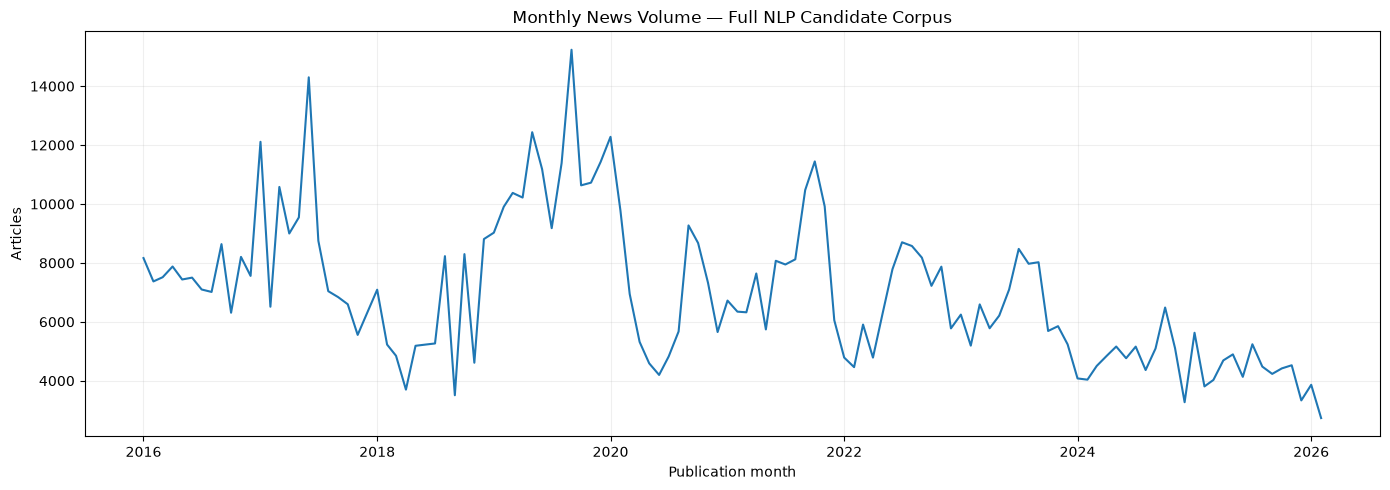

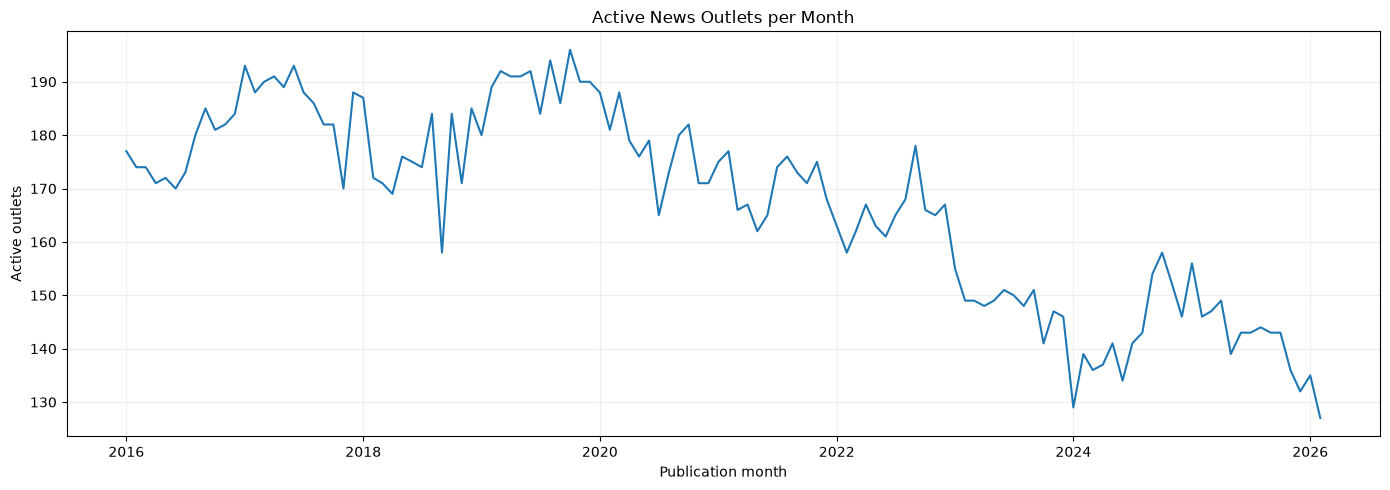

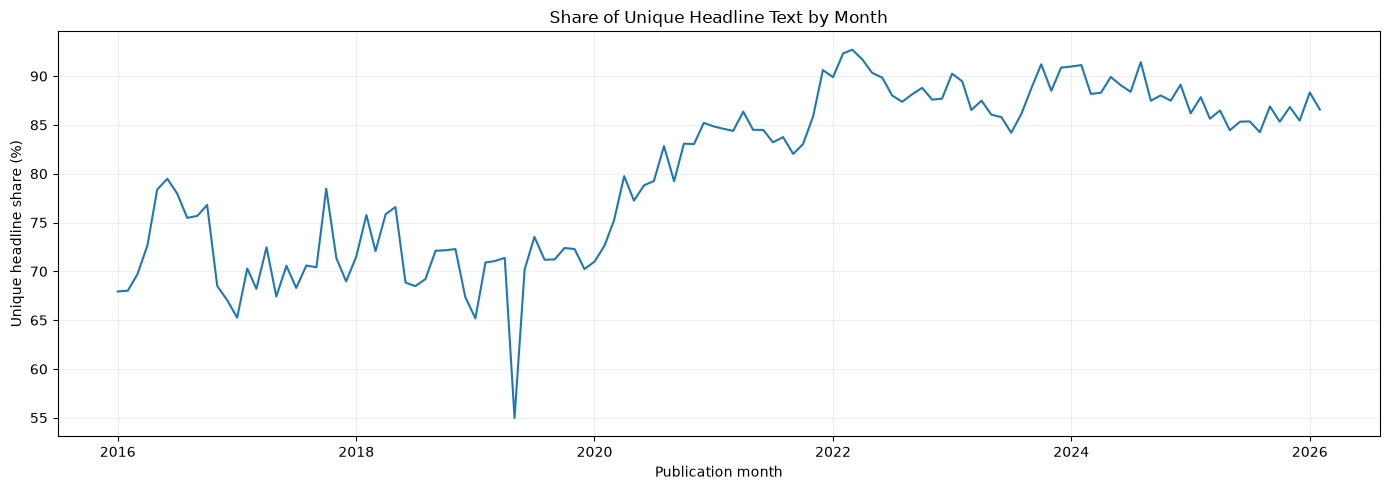

In [23]:
import matplotlib.pyplot as plt
import pandas as pd

# ---------------------------------------------------------
# Prepare publication dates
# ---------------------------------------------------------

df_nlp["publish_dt"] = pd.to_datetime(
    df_nlp["publish_date"],
    errors="coerce",
    utc=True
)

# Remove timezone only for monthly Period conversion
df_nlp["year_month"] = (
    df_nlp["publish_dt"]
    .dt.tz_convert(None)
    .dt.to_period("M")
)

# ---------------------------------------------------------
# Monthly summary
# ---------------------------------------------------------

monthly_summary = (
    df_nlp
    .groupby("year_month")
    .agg(
        articles=("id", "size"),
        active_outlets=("media_name", "nunique"),
        unique_titles=("title_nlp_candidate", "nunique"),
    )
    .sort_index()
)

monthly_summary["repeated_title_rows"] = (
    monthly_summary["articles"]
    - monthly_summary["unique_titles"]
)

monthly_summary["unique_title_pct"] = (
    monthly_summary["unique_titles"]
    / monthly_summary["articles"]
    * 100
).round(2)

# Timestamp version for plotting
monthly_summary["month"] = (
    monthly_summary.index.to_timestamp()
)

# ---------------------------------------------------------
# Coverage continuity
# ---------------------------------------------------------

expected_months = pd.period_range(
    start=df_nlp["year_month"].min(),
    end=df_nlp["year_month"].max(),
    freq="M"
)

missing_months = expected_months.difference(
    monthly_summary.index
)

print("=" * 75)
print("TEMPORAL COVERAGE")
print("=" * 75)

print(
    f"First month:             "
    f"{monthly_summary.index.min()}"
)

print(
    f"Last month:              "
    f"{monthly_summary.index.max()}"
)

print(
    f"Expected months:         "
    f"{len(expected_months):,}"
)

print(
    f"Observed months:         "
    f"{len(monthly_summary):,}"
)

print(
    f"Missing months:          "
    f"{len(missing_months):,}"
)

if len(missing_months) > 0:
    print(
        "Missing:",
        ", ".join(map(str, missing_months))
    )

# ---------------------------------------------------------
# Monthly distribution statistics
# ---------------------------------------------------------

print("\n" + "=" * 75)
print("MONTHLY SUMMARY STATISTICS")
print("=" * 75)

display(
    monthly_summary[
        [
            "articles",
            "active_outlets",
            "unique_titles",
            "unique_title_pct",
        ]
    ]
    .describe(
        percentiles=[
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
        ]
    )
    .round(2)
)

# ---------------------------------------------------------
# Highest-volume months
# ---------------------------------------------------------

print("\n" + "=" * 75)
print("HIGHEST-VOLUME MONTHS")
print("=" * 75)

display(
    monthly_summary[
        [
            "articles",
            "active_outlets",
            "unique_titles",
            "unique_title_pct",
        ]
    ]
    .sort_values(
        "articles",
        ascending=False
    )
    .head(15)
)

# ---------------------------------------------------------
# Lowest-volume months
# ---------------------------------------------------------

print("\n" + "=" * 75)
print("LOWEST-VOLUME MONTHS")
print("=" * 75)

display(
    monthly_summary[
        [
            "articles",
            "active_outlets",
            "unique_titles",
            "unique_title_pct",
        ]
    ]
    .sort_values(
        "articles"
    )
    .head(15)
)

# ---------------------------------------------------------
# Monthly article volume
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    monthly_summary["month"],
    monthly_summary["articles"]
)

ax.set_title(
    "Monthly News Volume — Full NLP Candidate Corpus"
)
ax.set_xlabel("Publication month")
ax.set_ylabel("Articles")
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Active outlets per month
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    monthly_summary["month"],
    monthly_summary["active_outlets"]
)

ax.set_title(
    "Active News Outlets per Month"
)
ax.set_xlabel("Publication month")
ax.set_ylabel("Active outlets")
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Monthly uniqueness of headline text
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    monthly_summary["month"],
    monthly_summary["unique_title_pct"]
)

ax.set_title(
    "Share of Unique Headline Text by Month"
)
ax.set_xlabel("Publication month")
ax.set_ylabel("Unique headline share (%)")
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## 12. Outlet Coverage and Continuity

Monthly article volume and the number of active outlets change substantially over the study period.

Before constructing outlet-level semantic centroids, each outlet is examined for:

- total article volume
- number of active months
- first and last observed month
- overall temporal coverage
- continuity between first and last appearance

This analysis helps distinguish consistently represented outlets from sparse or short-lived sources and informs later minimum-coverage requirements for longitudinal comparisons.

OUTLET COVERAGE SUMMARY
Total outlets:                  234
Total study months:             122
Outlets active all 122 months:  54
Outlets active >= 90% months:   100
Outlets active >= 75% months:   135
Outlets active >= 50% months:   172
Outlets active < 25% months:    30

OUTLET COVERAGE DISTRIBUTION


,total_articles,active_months,coverage_pct,continuity_pct,mean_articles_active_month,median_articles_active_month
count,234.00,234.00,234.00,234.00,234.00,234.00
mean,3634.23,87.12,71.41,79.33,34.51,26.68
std,6945.38,37.38,30.64,25.35,61.02,47.23
min,1.00,1.00,0.82,4.67,1.00,1.00
5%,21.00,12.65,10.37,23.89,1.35,1.00
25%,264.00,58.25,47.75,63.68,3.71,2.62
50%,1367.50,102.00,83.61,90.42,13.86,10.00
75%,3889.75,121.00,99.18,100.00,36.35,29.75
90%,7651.50,122.00,100.00,100.00,76.19,61.75
95%,16895.60,122.00,100.00,100.00,144.24,109.22



TOP 25 OUTLETS BY ARTICLE VOLUME


/var/folders/w0/3gcyvg0s5dnd4ykcbv1pb2100000gn/T/ipykernel_27110/3586653082.py:167: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  .round(2)


,total_articles,active_months,coverage_pct,continuity_pct,first_month,last_month,median_articles_active_month
media_name,,,,,,,
reuters.com,56463,122,100.00,100.00,2016-01,2026-02,189.5
theguardian.com,42764,122,100.00,100.00,2016-01,2026-02,330.0
nytimes.com,38558,122,100.00,100.00,2016-01,2026-02,294.5
washingtonpost.com,32904,99,81.15,100.00,2016-01,2024-03,316.0
latimes.com,26131,122,100.00,100.00,2016-01,2026-02,148.5
cnn.com,23044,122,100.00,100.00,2016-01,2026-02,141.5
cbsnews.com,22940,122,100.00,100.00,2016-01,2026-02,102.5
benzinga.com,22341,111,90.98,97.37,2016-09,2026-02,21.0
forbes.com,21112,121,99.18,100.00,2016-01,2026-01,192.0


...


SPARSE OUTLETS


/var/folders/w0/3gcyvg0s5dnd4ykcbv1pb2100000gn/T/ipykernel_27110/3586653082.py:230: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  .round(2)


,total_articles,active_months,coverage_pct,continuity_pct,first_month,last_month
media_name,,,,,,
dailysource.org,1,1,0.82,100.00,2020-10,2020-10
hollywoodweeklymagazine.com,3,3,2.46,10.00,2019-07,2021-12
breakingnews.com,4,3,2.46,100.00,2016-09,2016-11
indiancountrynews.com,5,4,3.28,12.12,2016-10,2019-06
ms.now,18,4,3.28,100.00,2025-11,2026-02
nationalenquirer.com,5,5,4.10,4.67,2017-01,2025-11
hudsonvalley360.com,6,6,4.92,20.69,2019-02,2021-06
accesshollywood.com,9,9,7.38,40.91,2016-09,2018-06
ictnews.org,148,9,7.38,23.68,2023-01,2026-02



OUTLET ENTRY / EXIT BY YEAR


,first_appearance,last_appearance
2016,216,1
2017,8,1
2018,2,4
2019,3,4
2020,3,6
2021,0,9
2022,0,6
2023,1,7
2024,0,11
2025,1,44


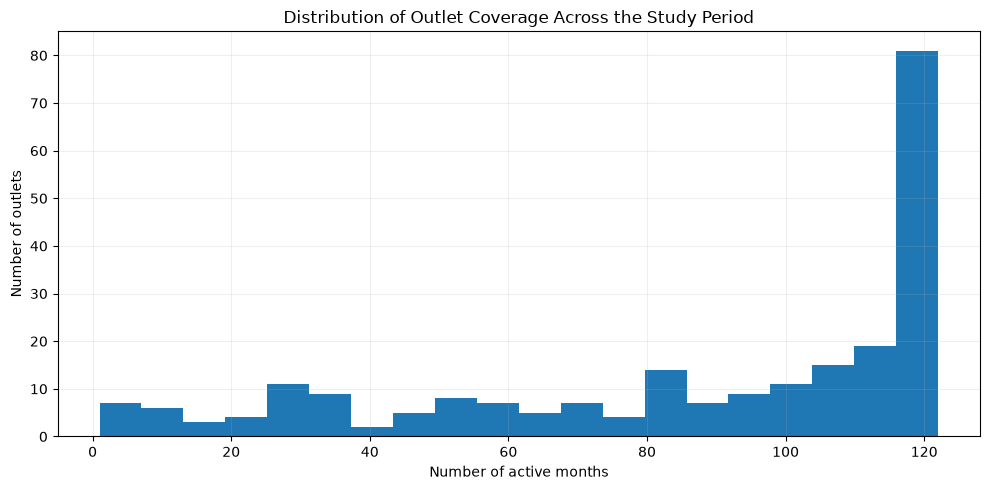

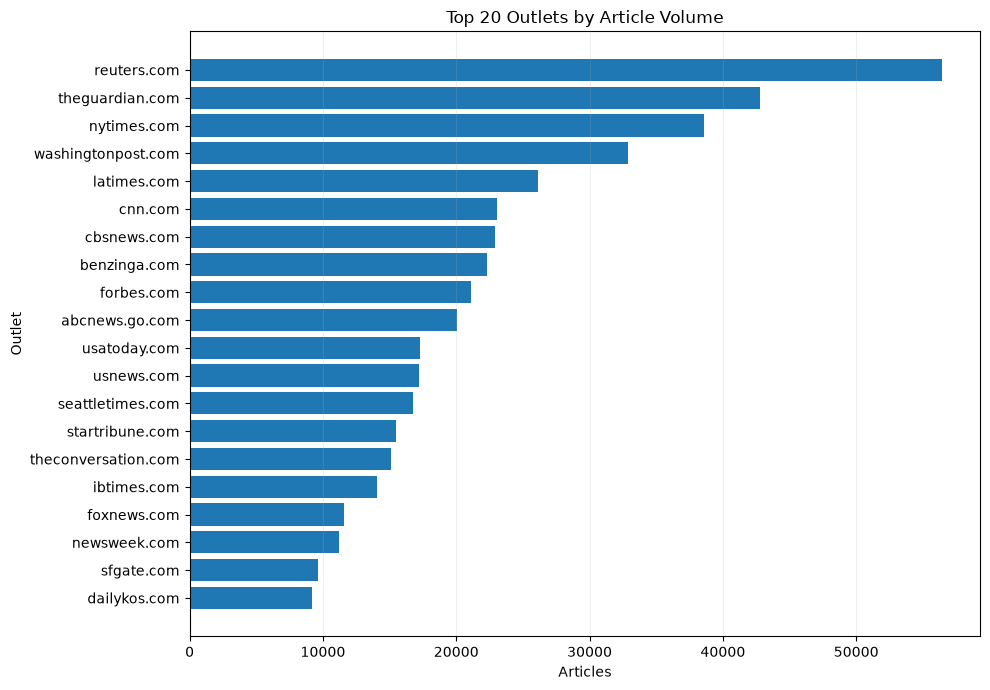

In [24]:
# ---------------------------------------------------------
# Outlet-month article counts
# ---------------------------------------------------------

outlet_month_counts = (
    df_nlp
    .groupby(
        ["media_name", "year_month"]
    )
    .size()
    .rename("articles")
    .reset_index()
)

# ---------------------------------------------------------
# Outlet-level coverage profile
# ---------------------------------------------------------

outlet_profile = (
    outlet_month_counts
    .groupby("media_name")
    .agg(
        total_articles=("articles", "sum"),
        active_months=("year_month", "nunique"),
        first_month=("year_month", "min"),
        last_month=("year_month", "max"),
        mean_articles_active_month=("articles", "mean"),
        median_articles_active_month=("articles", "median"),
        min_articles_active_month=("articles", "min"),
        max_articles_active_month=("articles", "max"),
    )
)

TOTAL_MONTHS = len(expected_months)

outlet_profile["coverage_pct"] = (
    outlet_profile["active_months"]
    / TOTAL_MONTHS
    * 100
)

# ---------------------------------------------------------
# Continuity within each outlet's observed lifespan
# ---------------------------------------------------------

def months_between(start, end):
    return (
        (end.year - start.year) * 12
        + (end.month - start.month)
        + 1
    )


outlet_profile["months_in_observed_span"] = [
    months_between(start, end)
    for start, end in zip(
        outlet_profile["first_month"],
        outlet_profile["last_month"]
    )
]

outlet_profile["continuity_pct"] = (
    outlet_profile["active_months"]
    / outlet_profile["months_in_observed_span"]
    * 100
)

outlet_profile["missing_months_within_span"] = (
    outlet_profile["months_in_observed_span"]
    - outlet_profile["active_months"]
)

# ---------------------------------------------------------
# Basic summary
# ---------------------------------------------------------

print("=" * 75)
print("OUTLET COVERAGE SUMMARY")
print("=" * 75)

print(f"Total outlets:                  {len(outlet_profile):,}")
print(f"Total study months:             {TOTAL_MONTHS:,}")

print(
    f"Outlets active all 122 months:  "
    f"{(outlet_profile['active_months'] == TOTAL_MONTHS).sum():,}"
)

print(
    f"Outlets active >= 90% months:   "
    f"{(outlet_profile['coverage_pct'] >= 90).sum():,}"
)

print(
    f"Outlets active >= 75% months:   "
    f"{(outlet_profile['coverage_pct'] >= 75).sum():,}"
)

print(
    f"Outlets active >= 50% months:   "
    f"{(outlet_profile['coverage_pct'] >= 50).sum():,}"
)

print(
    f"Outlets active < 25% months:    "
    f"{(outlet_profile['coverage_pct'] < 25).sum():,}"
)

# ---------------------------------------------------------
# Distribution
# ---------------------------------------------------------

print("\n" + "=" * 75)
print("OUTLET COVERAGE DISTRIBUTION")
print("=" * 75)

display(
    outlet_profile[
        [
            "total_articles",
            "active_months",
            "coverage_pct",
            "continuity_pct",
            "mean_articles_active_month",
            "median_articles_active_month",
        ]
    ]
    .describe(
        percentiles=[
            0.05,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
        ]
    )
    .round(2)
)

# ---------------------------------------------------------
# Largest outlets
# ---------------------------------------------------------

print("\n" + "=" * 75)
print("TOP 25 OUTLETS BY ARTICLE VOLUME")
print("=" * 75)

display(
    outlet_profile
    .sort_values(
        "total_articles",
        ascending=False
    )
    .head(25)
    [
        [
            "total_articles",
            "active_months",
            "coverage_pct",
            "continuity_pct",
            "first_month",
            "last_month",
            "median_articles_active_month",
        ]
    ]
    .round(2)
)

# ---------------------------------------------------------
# Most consistently represented outlets
# ---------------------------------------------------------

print("\n" + "=" * 75)
print("MOST CONTINUOUS OUTLETS")
print("=" * 75)

display(
    outlet_profile[
        outlet_profile["active_months"] >= 100
    ]
    .sort_values(
        [
            "active_months",
            "total_articles"
        ],
        ascending=False
    )
    .head(40)
    [
        [
            "total_articles",
            "active_months",
            "coverage_pct",
            "continuity_pct",
            "first_month",
            "last_month",
        ]
    ]
    .round(2)
)

# ---------------------------------------------------------
# Sparse outlets
# ---------------------------------------------------------

print("\n" + "=" * 75)
print("SPARSE OUTLETS")
print("=" * 75)

display(
    outlet_profile
    .sort_values(
        [
            "active_months",
            "total_articles"
        ]
    )
    .head(30)
    [
        [
            "total_articles",
            "active_months",
            "coverage_pct",
            "continuity_pct",
            "first_month",
            "last_month",
        ]
    ]
    .round(2)
)

# ---------------------------------------------------------
# First / last appearance by year
# ---------------------------------------------------------

outlet_profile["first_year"] = (
    outlet_profile["first_month"]
    .map(lambda x: x.year)
)

outlet_profile["last_year"] = (
    outlet_profile["last_month"]
    .map(lambda x: x.year)
)

first_year_counts = (
    outlet_profile["first_year"]
    .value_counts()
    .sort_index()
)

last_year_counts = (
    outlet_profile["last_year"]
    .value_counts()
    .sort_index()
)

appearance_summary = pd.DataFrame({
    "first_appearance": first_year_counts,
    "last_appearance": last_year_counts,
}).fillna(0).astype(int)

print("\n" + "=" * 75)
print("OUTLET ENTRY / EXIT BY YEAR")
print("=" * 75)

display(appearance_summary)

# ---------------------------------------------------------
# Plot: active months distribution
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    outlet_profile["active_months"],
    bins=20
)

ax.set_title(
    "Distribution of Outlet Coverage Across the Study Period"
)
ax.set_xlabel("Number of active months")
ax.set_ylabel("Number of outlets")
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Plot: top outlets by total article volume
# ---------------------------------------------------------

top_outlets_plot = (
    outlet_profile
    .sort_values(
        "total_articles",
        ascending=False
    )
    .head(20)
    .sort_values("total_articles")
)

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(
    top_outlets_plot.index,
    top_outlets_plot["total_articles"]
)

ax.set_title(
    "Top 20 Outlets by Article Volume"
)
ax.set_xlabel("Articles")
ax.set_ylabel("Outlet")
ax.grid(
    axis="x",
    alpha=0.2
)

plt.tight_layout()
plt.show()

## 13. Outlet-Month Sample Size Baseline

Semantic polarization will eventually be calculated from outlet-month embedding centroids.

A centroid based on only one or two headlines may be unstable and overly sensitive to individual stories. Before semantic filtering is introduced, the full NLP candidate corpus is examined to understand the available sample size per outlet-month.

This section evaluates:

- article-count distribution across outlet-month observations
- sensitivity to candidate minimum sample-size thresholds
- number of qualifying outlets retained per month
- temporal changes in outlet-month coverage

The final minimum headline requirement will not be selected here. It will be re-evaluated after climate relevance filtering, because the semantic analysis uses the climate-specific subset rather than the full news corpus.

OUTLET-MONTH SAMPLE SIZE BASELINE
Observed outlet-month combinations: 20,386
Maximum possible combinations:       28,548
Observed combination rate:           71.41%

ARTICLES PER OUTLET-MONTH


,articles
count,20386.00
mean,41.72
std,97.96
min,1.00
1%,1.00
5%,1.00
10%,1.00
25%,4.00
50%,15.00
75%,40.00



MINIMUM SAMPLE-SIZE SENSITIVITY


,qualifying_outlet_months,pct_outlet_months_retained,unique_outlets_retained,median_outlets_per_month,min_outlets_in_any_month,max_outlets_in_any_month
min_articles,,,,,,
1,20386,100.00,234,171.0,127,196
2,18321,89.87,229,153.0,106,180
3,16878,82.79,225,141.0,96,175
5,14948,73.32,218,122.0,81,163
10,12233,60.01,190,99.0,57,143
20,8862,43.47,167,73.5,28,116
30,6650,32.62,150,52.0,20,104
50,4127,20.24,120,31.5,9,75
100,1870,9.17,82,13.0,5,41



OUTLET-MONTH SAMPLE-SIZE BANDS


,outlet_months,pct
articles_per_outlet_month,,
1,2065,10.13
2,1443,7.08
3–4,1930,9.47
5–9,2715,13.32
10–19,3371,16.54
20–49,4735,23.23
50–99,2257,11.07
100+,1870,9.17


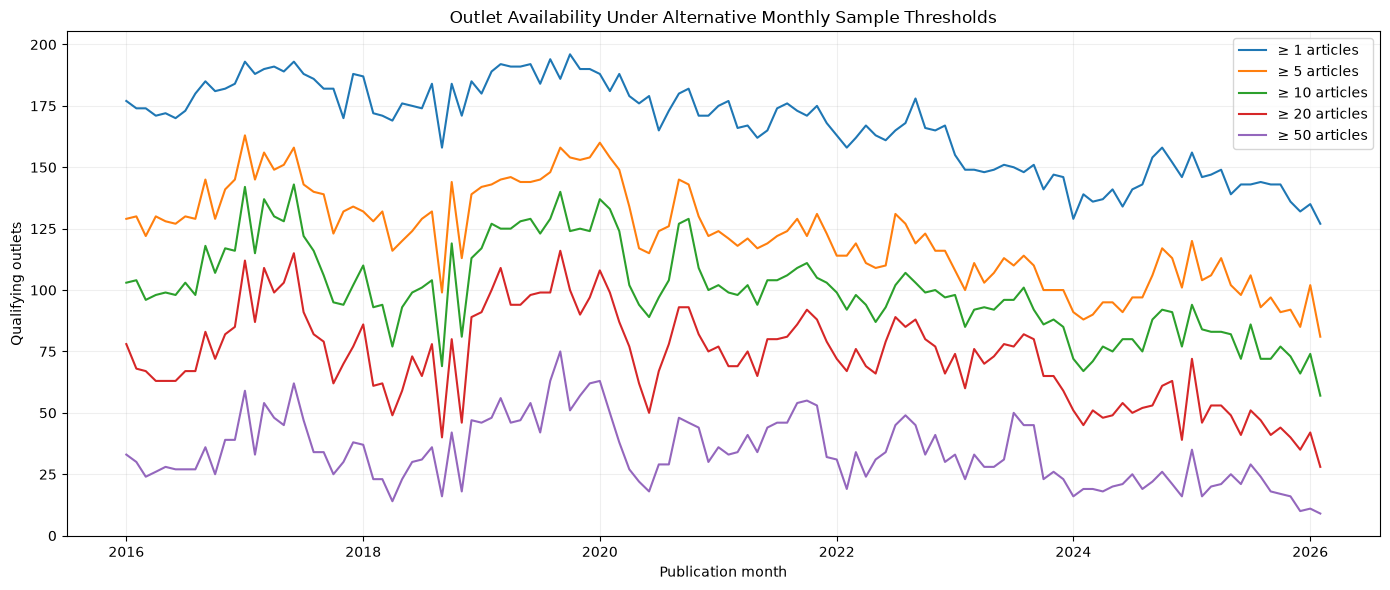


PRELIMINARY STABLE PANELS
Outlets present >=90% of study months: 100
Outlets present all 122 months:         54

Articles from >=90% panel: 665,939 (78.31%)
Articles from full-coverage panel: 472,168 (55.52%)


In [25]:
# ---------------------------------------------------------
# Outlet-month sample-size distribution
# ---------------------------------------------------------

outlet_month_baseline = (
    df_nlp
    .groupby(
        ["media_name", "year_month"]
    )
    .size()
    .rename("articles")
    .reset_index()
)

print("=" * 75)
print("OUTLET-MONTH SAMPLE SIZE BASELINE")
print("=" * 75)

print(
    f"Observed outlet-month combinations: "
    f"{len(outlet_month_baseline):,}"
)

print(
    f"Maximum possible combinations:       "
    f"{df_nlp['media_name'].nunique() * len(expected_months):,}"
)

print(
    f"Observed combination rate:           "
    f"{len(outlet_month_baseline) / (df_nlp['media_name'].nunique() * len(expected_months)) * 100:.2f}%"
)

# ---------------------------------------------------------
# Distribution of articles per outlet-month
# ---------------------------------------------------------

print("\n" + "=" * 75)
print("ARTICLES PER OUTLET-MONTH")
print("=" * 75)

sample_size_stats = (
    outlet_month_baseline["articles"]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
        ]
    )
    .to_frame("articles")
)

display(sample_size_stats.round(2))

# ---------------------------------------------------------
# Threshold sensitivity
# ---------------------------------------------------------

candidate_thresholds = [
    1,
    2,
    3,
    5,
    10,
    20,
    30,
    50,
    100,
]

threshold_rows = []

for threshold in candidate_thresholds:

    qualifying = outlet_month_baseline[
        outlet_month_baseline["articles"] >= threshold
    ]

    monthly_qualifying = (
        qualifying
        .groupby("year_month")["media_name"]
        .nunique()
    )

    threshold_rows.append({
        "min_articles": threshold,

        "qualifying_outlet_months":
            len(qualifying),

        "pct_outlet_months_retained":
            len(qualifying)
            / len(outlet_month_baseline)
            * 100,

        "unique_outlets_retained":
            qualifying["media_name"].nunique(),

        "median_outlets_per_month":
            monthly_qualifying.median(),

        "min_outlets_in_any_month":
            monthly_qualifying.min(),

        "max_outlets_in_any_month":
            monthly_qualifying.max(),
    })


threshold_summary = (
    pd.DataFrame(threshold_rows)
    .set_index("min_articles")
)

threshold_summary[
    "pct_outlet_months_retained"
] = threshold_summary[
    "pct_outlet_months_retained"
].round(2)

print("\n" + "=" * 75)
print("MINIMUM SAMPLE-SIZE SENSITIVITY")
print("=" * 75)

display(threshold_summary)

# ---------------------------------------------------------
# How common are very small samples?
# ---------------------------------------------------------

sample_bins = pd.cut(
    outlet_month_baseline["articles"],
    bins=[
        0,
        1,
        2,
        4,
        9,
        19,
        49,
        99,
        float("inf"),
    ],
    labels=[
        "1",
        "2",
        "3–4",
        "5–9",
        "10–19",
        "20–49",
        "50–99",
        "100+",
    ]
)

sample_bin_summary = (
    sample_bins
    .value_counts(sort=False)
    .rename_axis("articles_per_outlet_month")
    .to_frame("outlet_months")
)

sample_bin_summary["pct"] = (
    sample_bin_summary["outlet_months"]
    / len(outlet_month_baseline)
    * 100
).round(2)

print("\n" + "=" * 75)
print("OUTLET-MONTH SAMPLE-SIZE BANDS")
print("=" * 75)

display(sample_bin_summary)

# ---------------------------------------------------------
# Qualifying outlets per month at candidate thresholds
# ---------------------------------------------------------

threshold_monthly = []

for threshold in [1, 5, 10, 20, 50]:

    temp = (
        outlet_month_baseline[
            outlet_month_baseline["articles"] >= threshold
        ]
        .groupby("year_month")["media_name"]
        .nunique()
        .reindex(expected_months, fill_value=0)
    )

    threshold_monthly.append(
        pd.DataFrame({
            "year_month": expected_months,
            "minimum_articles": threshold,
            "qualifying_outlets": temp.values,
        })
    )


threshold_monthly = pd.concat(
    threshold_monthly,
    ignore_index=True
)

# ---------------------------------------------------------
# Plot threshold sensitivity through time
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(14, 6))

for threshold in [1, 5, 10, 20, 50]:

    plot_data = threshold_monthly[
        threshold_monthly[
            "minimum_articles"
        ] == threshold
    ]

    ax.plot(
        plot_data["year_month"].dt.to_timestamp(),
        plot_data["qualifying_outlets"],
        label=f"≥ {threshold} articles"
    )

ax.set_title(
    "Outlet Availability Under Alternative Monthly Sample Thresholds"
)
ax.set_xlabel("Publication month")
ax.set_ylabel("Qualifying outlets")
ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Stable-panel candidates
#
# These are based ONLY on overall corpus coverage.
# They are not yet the final climate-analysis panel.
# ---------------------------------------------------------

stable_90_outlets = (
    outlet_profile[
        outlet_profile["coverage_pct"] >= 90
    ]
    .index
    .tolist()
)

stable_100_outlets = (
    outlet_profile[
        outlet_profile["active_months"] == TOTAL_MONTHS
    ]
    .index
    .tolist()
)

print("\n" + "=" * 75)
print("PRELIMINARY STABLE PANELS")
print("=" * 75)

print(
    f"Outlets present >=90% of study months: "
    f"{len(stable_90_outlets):,}"
)

print(
    f"Outlets present all 122 months:         "
    f"{len(stable_100_outlets):,}"
)

# ---------------------------------------------------------
# Stable panel article-volume contribution
# ---------------------------------------------------------

stable_90_rows = df_nlp[
    df_nlp["media_name"].isin(
        stable_90_outlets
    )
]

stable_100_rows = df_nlp[
    df_nlp["media_name"].isin(
        stable_100_outlets
    )
]

print(
    f"\nArticles from >=90% panel: "
    f"{len(stable_90_rows):,} "
    f"({len(stable_90_rows) / len(df_nlp) * 100:.2f}%)"
)

print(
    f"Articles from full-coverage panel: "
    f"{len(stable_100_rows):,} "
    f"({len(stable_100_rows) / len(df_nlp) * 100:.2f}%)"
)

## 14. Baseline Semantic Relevance Experiment

The original methodology identifies climate-related headlines using semantic similarity between headline embeddings and a climate-focused anchor.

Before embedding the full corpus, the baseline approach is reproduced on a temporally stratified sample.

The experiment uses:

- `sentence-transformers/all-MiniLM-L6-v2`
- 384-dimensional sentence embeddings
- cosine similarity
- the original climate anchor concepts:
  - climate change
  - carbon emissions
  - renewable energy
  - climate policy
  - global warming
  - environmental sustainability

The purpose of this experiment is not to select the final threshold. It is used to:

- verify the embedding pipeline
- benchmark processing speed
- inspect the similarity distribution
- examine the original `0.25` threshold
- identify regions that require manual validation

In [30]:
import time

import numpy as np
import pandas as pd
import torch

from sentence_transformers import SentenceTransformer

# ---------------------------------------------------------
# Reproducibility
# ---------------------------------------------------------

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ---------------------------------------------------------
# Model configuration
# ---------------------------------------------------------

MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"

if torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"

print("=" * 75)
print("EMBEDDING MODEL")
print("=" * 75)

print(f"Model:  {MODEL_NAME}")
print(f"Device: {DEVICE}")

# ---------------------------------------------------------
# Load model
# ---------------------------------------------------------

load_start = time.perf_counter()

model = SentenceTransformer(
    MODEL_NAME,
    device=DEVICE
)

load_seconds = time.perf_counter() - load_start

print(f"Model load time: {load_seconds:.2f} seconds")
print(
    f"Embedding dimension: "
    f"{model.get_sentence_embedding_dimension()}"
)

# ---------------------------------------------------------
# Build temporally stratified sample
# ---------------------------------------------------------

embedding_sample_source = df_nlp[
    [
        "id",
        "title_nlp_candidate",
        "media_name",
        "publish_dt",
        "year_month",
    ]
].copy()

embedding_sample_source["year"] = (
    embedding_sample_source["publish_dt"].dt.year
)

SAMPLE_PER_YEAR = 2000

sample_parts = []

for year, group in embedding_sample_source.groupby("year"):

    n = min(
        SAMPLE_PER_YEAR,
        len(group)
    )

    sample_parts.append(
        group.sample(
            n=n,
            random_state=RANDOM_SEED + int(year)
        )
    )

embedding_sample = (
    pd.concat(sample_parts)
    .sort_values("publish_dt")
    .reset_index(drop=True)
)

print("\n" + "=" * 75)
print("BENCHMARK SAMPLE")
print("=" * 75)

print(
    f"Sample rows:             "
    f"{len(embedding_sample):,}"
)

print(
    f"Unique sampled titles:   "
    f"{embedding_sample['title_nlp_candidate'].nunique():,}"
)

print(
    f"Years represented:       "
    f"{embedding_sample['year'].nunique():,}"
)

display(
    embedding_sample["year"]
    .value_counts()
    .sort_index()
    .rename("sample_rows")
    .to_frame()
)

# ---------------------------------------------------------
# Encode sample headlines
# ---------------------------------------------------------

sample_texts = (
    embedding_sample["title_nlp_candidate"]
    .tolist()
)

BATCH_SIZE = 128 if DEVICE == "mps" else 64

encode_start = time.perf_counter()

sample_embeddings = model.encode(
    sample_texts,
    batch_size=BATCH_SIZE,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,
)

encode_seconds = time.perf_counter() - encode_start

print("\n" + "=" * 75)
print("EMBEDDING BENCHMARK")
print("=" * 75)

print(
    f"Embedding matrix shape:  "
    f"{sample_embeddings.shape}"
)

print(
    f"Embedding dtype:         "
    f"{sample_embeddings.dtype}"
)

print(
    f"Encoding time:           "
    f"{encode_seconds:.2f} seconds"
)

print(
    f"Headlines / second:      "
    f"{len(sample_embeddings) / encode_seconds:,.1f}"
)

estimated_full_seconds = (
    len(df_nlp)
    / (len(sample_embeddings) / encode_seconds)
)

print(
    f"Rough full-corpus ETA:   "
    f"{estimated_full_seconds / 60:.1f} minutes"
)

# ---------------------------------------------------------
# Baseline climate anchor
# ---------------------------------------------------------

CLIMATE_ANCHOR = (
    "climate change, carbon emissions, renewable energy, "
    "climate policy, global warming, environmental sustainability"
)

anchor_embedding = model.encode(
    [CLIMATE_ANCHOR],
    convert_to_numpy=True,
    normalize_embeddings=True,
)[0]

# Since both vectors are unit-normalized,
# dot product == cosine similarity.
climate_similarity = (
    sample_embeddings @ anchor_embedding
)

embedding_sample["climate_similarity"] = (
    climate_similarity
)

# ---------------------------------------------------------
# Similarity distribution
# ---------------------------------------------------------

print("\n" + "=" * 75)
print("CLIMATE SIMILARITY DISTRIBUTION")
print("=" * 75)

display(
    embedding_sample["climate_similarity"]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
        ]
    )
    .to_frame("similarity")
    .round(4)
)

# ---------------------------------------------------------
# Threshold sensitivity
# ---------------------------------------------------------

candidate_thresholds = [
    0.10,
    0.15,
    0.20,
    0.25,
    0.30,
    0.35,
    0.40,
    0.45,
    0.50,
]

threshold_results = []

for threshold in candidate_thresholds:

    retained = (
        embedding_sample["climate_similarity"]
        >= threshold
    )

    threshold_results.append({
        "threshold": threshold,
        "headlines": int(retained.sum()),
        "pct_sample": retained.mean() * 100,
        "outlets": embedding_sample.loc[
            retained,
            "media_name"
        ].nunique(),
    })

threshold_results = (
    pd.DataFrame(threshold_results)
    .set_index("threshold")
)

threshold_results["pct_sample"] = (
    threshold_results["pct_sample"]
    .round(2)
)

print("\n" + "=" * 75)
print("THRESHOLD SENSITIVITY")
print("=" * 75)

display(threshold_results)

# ---------------------------------------------------------
# Most climate-similar headlines
# ---------------------------------------------------------

print("\n" + "=" * 75)
print("HIGHEST-SIMILARITY HEADLINES")
print("=" * 75)

display(
    embedding_sample[
        [
            "title_nlp_candidate",
            "media_name",
            "publish_dt",
            "climate_similarity",
        ]
    ]
    .sort_values(
        "climate_similarity",
        ascending=False
    )
    .head(30)
)

# ---------------------------------------------------------
# Headlines near original 0.25 threshold
# ---------------------------------------------------------

print("\n" + "=" * 75)
print("HEADLINES NEAR ORIGINAL 0.25 THRESHOLD")
print("=" * 75)

near_025 = (
    embedding_sample[
        embedding_sample["climate_similarity"]
        .between(
            0.235,
            0.265
        )
    ]
    .sample(
        n=min(
            40,
            embedding_sample[
                embedding_sample["climate_similarity"]
                .between(
                    0.235,
                    0.265
                )
            ].shape[0]
        ),
        random_state=RANDOM_SEED,
    )
    .sort_values(
        "climate_similarity",
        ascending=False
    )
)

display(
    near_025[
        [
            "title_nlp_candidate",
            "media_name",
            "publish_dt",
            "climate_similarity",
        ]
    ]
)

# ---------------------------------------------------------
# Similarity bands for manual inspection
# ---------------------------------------------------------

inspection_ranges = [
    ("0.15–0.20", 0.15, 0.20),
    ("0.20–0.25", 0.20, 0.25),
    ("0.25–0.30", 0.25, 0.30),
    ("0.30–0.35", 0.30, 0.35),
    ("0.35–0.40", 0.35, 0.40),
    ("0.40–0.50", 0.40, 0.50),
    ("0.50+", 0.50, 1.00),
]

inspection_rows = []

for label, lower, upper in inspection_ranges:

    band = embedding_sample[
        (embedding_sample["climate_similarity"] >= lower)
        & (embedding_sample["climate_similarity"] < upper)
    ]

    if len(band) == 0:
        continue

    sample_n = min(
        8,
        len(band)
    )

    examples = band.sample(
        n=sample_n,
        random_state=RANDOM_SEED
    ).copy()

    examples["similarity_band"] = label

    inspection_rows.append(examples)

similarity_inspection = (
    pd.concat(
        inspection_rows,
        ignore_index=True
    )
    if inspection_rows
    else pd.DataFrame()
)

print("\n" + "=" * 75)
print("SIMILARITY BAND EXAMPLES")
print("=" * 75)

display(
    similarity_inspection[
        [
            "similarity_band",
            "title_nlp_candidate",
            "media_name",
            "climate_similarity",
        ]
    ]
    .sort_values(
        [
            "similarity_band",
            "climate_similarity",
        ],
        ascending=[True, False]
    )
)

/Users/lasya/Documents/projects/media-polarization-lab/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


EMBEDDING MODEL
Model:  sentence-transformers/all-MiniLM-L6-v2
Device: mps


Loading weights: 100%|█████████████████████████| 103/103 [00:00<00:00, 24616.14it/s]


Model load time: 12.98 seconds
Embedding dimension: 384

BENCHMARK SAMPLE
Sample rows:             22,000
Unique sampled titles:   21,489
Years represented:       11


/var/folders/w0/3gcyvg0s5dnd4ykcbv1pb2100000gn/T/ipykernel_27110/1274497877.py:50: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  f"{model.get_sentence_embedding_dimension()}"


...

,title_nlp_candidate,media_name,publish_dt,climate_similarity
858,"On the issues: Climate change, environmental p...",upi.com,2016-06-06 00:00:00+00:00,0.654917
8816,My Turn: Can these natural processes be put in...,recorder.com,2020-05-11 00:00:00+00:00,0.606105
11490,The global energy crisis has brought climate t...,cnn.com,2021-10-09 00:00:00+00:00,0.598943
2437,Climate change: What are the facts?,dallasnews.com,2017-03-18 00:00:00+00:00,0.595197
19500,The uphill battle ahead: Four different leader...,pilotonline.com,2025-09-25 00:00:00+00:00,0.592873
980,"Obama, Justin Trudeau and Enrique Peña Nieto F...",nytimes.com,2016-06-30 00:00:00+00:00,0.592848
6810,Solving for climate change: Everything you kno...,azcentral.com,2019-06-04 00:00:00+00:00,0.590362
15832,Climate Action 30: Top global leaders addressi...,businessinsider.com,2023-11-27 00:00:00+00:00,0.587138
17477,The winning fight against climate change lies ...,fortune.com,2024-09-30 00:00:00+00:00,0.578071
1786,What’s Donald Trump’s position on climate chan...,washingtonpost.com,2016-11-22 00:00:00+00:00,0.577797



HEADLINES NEAR ORIGINAL 0.25 THRESHOLD


,title_nlp_candidate,media_name,publish_dt,climate_similarity
12168,‘Follow the science’: As Year 3 of pandemic be...,washingtonpost.com,2022-02-12 00:00:00+00:00,0.263797
5107,Exxon Investors' Climate Suit Beats Dismissal Bid,lexisnexis.com,2018-08-14 00:00:00+00:00,0.262400
5155,Trump ready to ease rules on coal-fired power ...,sacbee.com,2018-08-20 00:00:00+00:00,0.261343
16414,UK homeowners warned as climate crisis turboch...,theguardian.com,2024-04-01 00:00:00+00:00,0.260041
21446,South Africans are leaving the electricity net...,theconversation.com,2026-02-09 00:00:00+00:00,0.258087
8596,"Climate Point: Mining lead bullets, and corona...",usatoday.com,2020-03-13 00:00:00+00:00,0.257926
7633,"Schumer proposes $462 billion, decade-long car...",marketwatch.com,2019-10-24 00:00:00+00:00,0.257753
13391,Climate Migration: Indian kids find hope in a ...,washingtonpost.com,2022-09-21 00:00:00+00:00,0.256230
10022,The cities most impacted by sea level rise,stltoday.com,2021-01-08 00:00:00+00:00,0.254244
12383,Global Camping and Caravanning Market Report 2...,benzinga.com,2022-03-29 00:00:00+00:00,0.254078



SIMILARITY BAND EXAMPLES


,similarity_band,title_nlp_candidate,media_name,climate_similarity
4,0.15–0.20,"As Arctic Sea Ice Thins, So Do Polar Bears",azcentral.com,0.198743
6,0.15–0.20,D.C.-area leaders prioritize equity in transpo...,washingtonpost.com,0.197602
1,0.15–0.20,Oil demand may never return to peak hit before...,cnn.com,0.192793
3,0.15–0.20,Are Central Banks Losing Their Economic Clout?,barrons.com,0.189918
7,0.15–0.20,Artist submerges 22 'cars' off the coast of Mi...,abcnews.go.com,0.179262
2,0.15–0.20,Seville becomes the first major city in the wo...,npr.org,0.168206
5,0.15–0.20,"Biden says “no,” Americans shouldn’t worry abo...",washingtonpost.com,0.158510
0,0.15–0.20,"Canadian Trappers Wrestle With Loss Of Russia,...",ibtimes.com,0.155116
12,0.20–0.25,Michael Bloomberg Spending $85 Million to Bury...,newsbusters.org,0.238253
13,0.20–0.25,New right whale protection measures announced ...,mongabay.com,0.238141


## 15. Climate Relevance Validation Dataset

The baseline climate anchor produces a continuous semantic similarity score, but visual inspection shows that the original `0.25` threshold includes both relevant and unrelated headlines.

Rather than selecting a cutoff subjectively, a manually labeled validation dataset is created.

Two semantic scoring approaches will eventually be evaluated:

1. **Baseline single anchor**
   - reproduces the original project methodology

2. **Multi-anchor climate representation**
   - represents several distinct dimensions of climate coverage
   - climate science
   - emissions and fossil fuels
   - clean-energy transition
   - climate policy
   - physical climate impacts
   - adaptation and resilience

The validation sample is deliberately enriched with:

- low-similarity examples
- borderline examples
- high-similarity examples
- cases where the baseline and multi-anchor approaches disagree
- a random sample from the corpus

Similarity scores are hidden from the manual labeling file to reduce annotation bias.

In [31]:
from pathlib import Path
import numpy as np
import pandas as pd

# ---------------------------------------------------------
# Candidate multi-anchor climate representation
# ---------------------------------------------------------

CLIMATE_ANCHORS = {
    "climate_science": (
        "climate change global warming greenhouse effect "
        "climate science global temperature"
    ),

    "emissions_fossil_fuels": (
        "carbon emissions greenhouse gas emissions fossil fuels "
        "coal oil gas decarbonization methane emissions"
    ),

    "clean_energy_transition": (
        "renewable energy clean energy solar power wind power "
        "energy transition electrification net zero"
    ),

    "climate_policy": (
        "climate policy Paris Agreement carbon tax climate regulation "
        "emissions targets climate legislation"
    ),

    "climate_impacts": (
        "climate impacts extreme heat drought wildfires flooding "
        "sea level rise melting glaciers climate disasters"
    ),

    "adaptation_resilience": (
        "climate adaptation climate resilience climate migration "
        "coastal protection adaptation to climate change"
    ),
}

anchor_names = list(CLIMATE_ANCHORS.keys())
anchor_texts = list(CLIMATE_ANCHORS.values())

# ---------------------------------------------------------
# Encode anchors
# ---------------------------------------------------------

multi_anchor_embeddings = model.encode(
    anchor_texts,
    convert_to_numpy=True,
    normalize_embeddings=True,
)

print("=" * 75)
print("MULTI-ANCHOR REPRESENTATION")
print("=" * 75)

print(f"Anchors:              {len(anchor_names)}")
print(
    f"Anchor matrix shape:  "
    f"{multi_anchor_embeddings.shape}"
)

display(
    pd.DataFrame({
        "anchor": anchor_names,
        "description": anchor_texts,
    })
)

# ---------------------------------------------------------
# Score the 22k benchmark sample against every anchor
# ---------------------------------------------------------

anchor_similarity_matrix = (
    sample_embeddings
    @ multi_anchor_embeddings.T
)

for i, anchor_name in enumerate(anchor_names):
    embedding_sample[
        f"sim_{anchor_name}"
    ] = anchor_similarity_matrix[:, i]

# Maximum similarity to any climate dimension
embedding_sample["climate_multi_max"] = (
    anchor_similarity_matrix.max(axis=1)
)

# Average of two strongest climate dimensions
sorted_anchor_scores = np.sort(
    anchor_similarity_matrix,
    axis=1,
)

embedding_sample["climate_multi_top2_mean"] = (
    sorted_anchor_scores[:, -2:]
    .mean(axis=1)
)

# Anchor responsible for max similarity
embedding_sample["climate_best_anchor"] = [
    anchor_names[i]
    for i in anchor_similarity_matrix.argmax(axis=1)
]

# ---------------------------------------------------------
# Compare scoring approaches
# ---------------------------------------------------------

print("\n" + "=" * 75)
print("SCORE DISTRIBUTIONS")
print("=" * 75)

score_comparison = embedding_sample[
    [
        "climate_similarity",
        "climate_multi_max",
        "climate_multi_top2_mean",
    ]
].describe(
    percentiles=[
        0.05,
        0.10,
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
        0.99,
    ]
).T

display(score_comparison.round(4))

# ---------------------------------------------------------
# Correlation between scoring methods
# ---------------------------------------------------------

print("\n" + "=" * 75)
print("SCORE CORRELATIONS")
print("=" * 75)

display(
    embedding_sample[
        [
            "climate_similarity",
            "climate_multi_max",
            "climate_multi_top2_mean",
        ]
    ]
    .corr()
    .round(3)
)

# ---------------------------------------------------------
# Construct blinded validation sample
# ---------------------------------------------------------

validation_parts = []

# Baseline similarity bands.
# 20 examples per band = up to 140 examples.
validation_bands = [
    ("very_low", -1.00, 0.15),
    ("low",       0.15, 0.20),
    ("lower_mid", 0.20, 0.25),
    ("boundary",  0.25, 0.30),
    ("upper_mid", 0.30, 0.35),
    ("high",      0.35, 0.45),
    ("very_high", 0.45, 1.00),
]

for band_name, lower, upper in validation_bands:

    band = embedding_sample[
        (embedding_sample["climate_similarity"] >= lower)
        & (embedding_sample["climate_similarity"] < upper)
    ]

    if len(band) == 0:
        continue

    n = min(20, len(band))

    sampled = band.sample(
        n=n,
        random_state=RANDOM_SEED + len(validation_parts)
    ).copy()

    sampled["validation_source"] = (
        f"baseline_band:{band_name}"
    )

    validation_parts.append(sampled)

# ---------------------------------------------------------
# Add disagreement examples
#
# Find headlines where the multi-anchor model thinks climate
# relevance is much stronger than the original anchor does.
# ---------------------------------------------------------

embedding_sample["multi_baseline_gap"] = (
    embedding_sample["climate_multi_top2_mean"]
    - embedding_sample["climate_similarity"]
)

positive_disagreement = (
    embedding_sample
    .sort_values(
        "multi_baseline_gap",
        ascending=False
    )
    .head(30)
    .copy()
)

positive_disagreement[
    "validation_source"
] = "multi_anchor_higher"

validation_parts.append(
    positive_disagreement
)

# And the reverse
negative_disagreement = (
    embedding_sample
    .sort_values(
        "multi_baseline_gap"
    )
    .head(30)
    .copy()
)

negative_disagreement[
    "validation_source"
] = "baseline_higher"

validation_parts.append(
    negative_disagreement
)

# ---------------------------------------------------------
# Add random corpus examples
# ---------------------------------------------------------

random_validation = (
    embedding_sample
    .sample(
        n=40,
        random_state=RANDOM_SEED + 999
    )
    .copy()
)

random_validation[
    "validation_source"
] = "random"
    
validation_parts.append(
    random_validation
)

# ---------------------------------------------------------
# Combine and remove duplicate sampled articles
# ---------------------------------------------------------

validation_full = (
    pd.concat(
        validation_parts,
        ignore_index=True
    )
    .drop_duplicates(
        subset="id"
    )
    .reset_index(drop=True)
)

# Shuffle so similarity bands aren't obvious during labeling
validation_full = (
    validation_full
    .sample(
        frac=1,
        random_state=RANDOM_SEED
    )
    .reset_index(drop=True)
)

# ---------------------------------------------------------
# Create a blinded labeling file
# ---------------------------------------------------------

validation_to_label = validation_full[
    [
        "id",
        "title_nlp_candidate",
        "media_name",
        "publish_dt",
    ]
].copy()

validation_to_label = validation_to_label.rename(
    columns={
        "title_nlp_candidate": "headline",
        "media_name": "outlet",
        "publish_dt": "publish_date",
    }
)

validation_to_label["label"] = ""
validation_to_label["notes"] = ""

# ---------------------------------------------------------
# Save locally
# ---------------------------------------------------------

VALIDATION_DIR = Path(
    "../data/interim"
)

if not VALIDATION_DIR.exists():
    VALIDATION_DIR = Path(
        "data/interim"
    )

VALIDATION_DIR.mkdir(
    parents=True,
    exist_ok=True
)

LABEL_FILE = (
    VALIDATION_DIR
    / "climate_relevance_validation_to_label.csv"
)

validation_to_label.to_csv(
    LABEL_FILE,
    index=False
)

# Keep scored version only in memory for now.
# We don't want similarity scores influencing manual labels.

print("\n" + "=" * 75)
print("VALIDATION DATASET")
print("=" * 75)

print(
    f"Validation rows:       "
    f"{len(validation_to_label):,}"
)

print(
    f"Unique outlets:        "
    f"{validation_to_label['outlet'].nunique():,}"
)

print(
    f"Saved to:              "
    f"{LABEL_FILE.resolve()}"
)

print("\nRows by sampling source:")

display(
    validation_full[
        "validation_source"
    ]
    .value_counts()
    .rename("rows")
    .to_frame()
)

print("\nBlinded labeling preview:")

display(
    validation_to_label.head(30)
)

MULTI-ANCHOR REPRESENTATION
Anchors:              6
Anchor matrix shape:  (6, 384)


,anchor,description
0,climate_science,climate change global warming greenhouse effec...
1,emissions_fossil_fuels,carbon emissions greenhouse gas emissions foss...
2,clean_energy_transition,renewable energy clean energy solar power wind...
3,climate_policy,climate policy Paris Agreement carbon tax clim...
4,climate_impacts,climate impacts extreme heat drought wildfires...
5,adaptation_resilience,climate adaptation climate resilience climate ...



SCORE DISTRIBUTIONS


,count,mean,std,min,5%,10%,25%,50%,75%,90%,95%,99%,max
climate_similarity,22000.0,0.1684,0.1361,-0.1737,-0.0183,0.0099,0.0675,0.1424,0.2572,0.3751,0.4252,0.4998,0.6549
climate_multi_max,22000.0,0.2163,0.1468,-0.0720,0.0317,0.0537,0.0981,0.1779,0.3241,0.4393,0.4875,0.5713,0.6922
climate_multi_top2_mean,22000.0,0.1888,0.1338,-0.0795,0.0195,0.0406,0.0819,0.1530,0.2873,0.3954,0.4386,0.5004,0.5986



SCORE CORRELATIONS


,climate_similarity,climate_multi_max,climate_multi_top2_mean
climate_similarity,1.000,0.830,0.864
climate_multi_max,0.830,1.000,0.987
climate_multi_top2_mean,0.864,0.987,1.000



VALIDATION DATASET
Validation rows:       240
Unique outlets:        86
Saved to:              /Users/lasya/Documents/projects/media-polarization-lab/data/interim/climate_relevance_validation_to_label.csv

Rows by sampling source:


,rows
validation_source,
random,40
baseline_higher,30
multi_anchor_higher,30
baseline_band:low,20
baseline_band:very_low,20
baseline_band:upper_mid,20
baseline_band:high,20
baseline_band:lower_mid,20
baseline_band:very_high,20



Blinded labeling preview:


,id,headline,outlet,publish_date,label,notes
0,516437254fd37a020b70101de3dc83ba97e187b0c97351...,Wildfires scorch parts of Europe amid extreme ...,mercurynews.com,2022-07-13 00:00:00+00:00,,
1,442fca31662ee8b17ba350a9504860065e9d349848e734...,UK's Labour unveils 'radical and ambitious' pl...,reuters.com,2019-11-21 00:00:00+00:00,,
2,8a80ef669100f634c114daaca8a719eb142ae2ed75fe12...,Sustainable Switch: US civil rights group thre...,reuters.com,2026-02-19 00:00:00+00:00,,
3,37de69158b552b682d7527757eeb8c179e5ebf658c3756...,CNN’s Climate Town Hall Expected To Last Seven...,dailycaller.com,2019-08-28 00:00:00+00:00,,
4,f83a4dc3f5f1bf2a11a9dcc61ae4ddd78bedb2dd3c0871...,FAA says future planes will need to reduce car...,seattletimes.com,2022-06-15 00:00:00+00:00,,
5,f5171ed32660de2eb72a90c05aa81bf1859d10acd5a916...,How Leaders Can Rethink What They Know And Emb...,forbes.com,2022-07-29 00:00:00+00:00,,
6,26094e49c47c60e6110f548131d1191a60b36575b60de2...,The Best Photos From The Sony World Photograph...,forbes.com,2024-03-21 00:00:00+00:00,,
7,3111edd224f8f18608b0f6c19d3e3403520d8b243f7bdf...,A Climate-Conscious Lent: Coral reefs are dying,ncronline.org,2021-03-03 00:00:00+00:00,,
8,efcdb6c1cbc0ce6c0153ad8692ab9495be0bcc0c9c6f1b...,Senate advances Trump spending bill in nail-bi...,cbsnews.com,2025-06-29 00:00:00+00:00,,
9,0ea89f83723cd179084512cd08fe41ee41a50093aa8b42...,California governor signs wildfire bill to pay...,sfgate.com,2019-07-12 00:00:00+00:00,,


In [32]:
# ---------------------------------------------------------
# Build a smaller first-round validation dataset
# ---------------------------------------------------------

TARGET_VALIDATION_ROWS = 80

small_validation_parts = []

# 7 similarity regions × 8 examples = up to 56
small_validation_bands = [
    ("very_low", -1.00, 0.15),
    ("low",       0.15, 0.20),
    ("lower_mid", 0.20, 0.25),
    ("boundary",  0.25, 0.30),
    ("upper_mid", 0.30, 0.35),
    ("high",      0.35, 0.45),
    ("very_high", 0.45, 1.00),
]

used_ids = set()

for i, (band_name, lower, upper) in enumerate(small_validation_bands):

    band = embedding_sample[
        (embedding_sample["climate_similarity"] >= lower)
        & (embedding_sample["climate_similarity"] < upper)
        & (~embedding_sample["id"].isin(used_ids))
    ]

    if len(band) == 0:
        continue

    n = min(8, len(band))

    sampled = band.sample(
        n=n,
        random_state=RANDOM_SEED + i
    ).copy()

    sampled["validation_source"] = f"band:{band_name}"

    used_ids.update(sampled["id"])

    small_validation_parts.append(sampled)


# ---------------------------------------------------------
# Add model-disagreement examples
# ---------------------------------------------------------

# Multi-anchor believes headline is more climate-related
multi_higher_pool = embedding_sample[
    ~embedding_sample["id"].isin(used_ids)
].sort_values(
    "multi_baseline_gap",
    ascending=False
)

multi_higher = (
    multi_higher_pool
    .head(8)
    .copy()
)

multi_higher["validation_source"] = "multi_anchor_higher"

used_ids.update(multi_higher["id"])

small_validation_parts.append(multi_higher)


# Baseline believes headline is more climate-related
baseline_higher_pool = embedding_sample[
    ~embedding_sample["id"].isin(used_ids)
].sort_values(
    "multi_baseline_gap",
    ascending=True
)

baseline_higher = (
    baseline_higher_pool
    .head(8)
    .copy()
)

baseline_higher["validation_source"] = "baseline_higher"

used_ids.update(baseline_higher["id"])

small_validation_parts.append(baseline_higher)


# ---------------------------------------------------------
# Combine
# ---------------------------------------------------------

small_validation_full = (
    pd.concat(
        small_validation_parts,
        ignore_index=True
    )
    .drop_duplicates("id")
)

# ---------------------------------------------------------
# Top up randomly until exactly 80 rows
# ---------------------------------------------------------

remaining_needed = (
    TARGET_VALIDATION_ROWS
    - len(small_validation_full)
)

if remaining_needed > 0:

    remaining_pool = embedding_sample[
        ~embedding_sample["id"].isin(
            small_validation_full["id"]
        )
    ]

    random_topup = remaining_pool.sample(
        n=min(
            remaining_needed,
            len(remaining_pool)
        ),
        random_state=RANDOM_SEED + 5000
    ).copy()

    random_topup["validation_source"] = "random_topup"

    small_validation_full = pd.concat(
        [
            small_validation_full,
            random_topup
        ],
        ignore_index=True
    )


# ---------------------------------------------------------
# Shuffle to keep labeling blinded
# ---------------------------------------------------------

small_validation_full = (
    small_validation_full
    .sample(
        frac=1,
        random_state=RANDOM_SEED
    )
    .reset_index(drop=True)
)

# ---------------------------------------------------------
# Blinded labeling dataframe
# ---------------------------------------------------------

small_validation_to_label = (
    small_validation_full[
        [
            "id",
            "title_nlp_candidate",
            "media_name",
            "publish_dt",
        ]
    ]
    .rename(
        columns={
            "title_nlp_candidate": "headline",
            "media_name": "outlet",
            "publish_dt": "publish_date",
        }
    )
    .copy()
)

small_validation_to_label["label"] = ""
small_validation_to_label["notes"] = ""

# ---------------------------------------------------------
# Save
# ---------------------------------------------------------

SMALL_LABEL_FILE = (
    VALIDATION_DIR
    / "climate_relevance_validation_round1.csv"
)

small_validation_to_label.to_csv(
    SMALL_LABEL_FILE,
    index=False
)

print("=" * 75)
print("ROUND 1 CLIMATE VALIDATION SET")
print("=" * 75)

print(
    f"Rows to label:       "
    f"{len(small_validation_to_label):,}"
)

print(
    f"Unique outlets:      "
    f"{small_validation_to_label['outlet'].nunique():,}"
)

print(
    f"Saved to:            "
    f"{SMALL_LABEL_FILE.resolve()}"
)

print("\nSampling composition:")

display(
    small_validation_full[
        "validation_source"
    ]
    .value_counts()
    .rename("rows")
    .to_frame()
)

print("\nPreview:")

display(
    small_validation_to_label.head(20)
)

ROUND 1 CLIMATE VALIDATION SET
Rows to label:       80
Unique outlets:      49
Saved to:            /Users/lasya/Documents/projects/media-polarization-lab/data/interim/climate_relevance_validation_round1.csv

Sampling composition:


,rows
validation_source,
band:boundary,8
band:very_low,8
band:lower_mid,8
band:low,8
baseline_higher,8
band:very_high,8
band:upper_mid,8
band:high,8
random_topup,8



Preview:


,id,headline,outlet,publish_date,label,notes
0,71bf53760c914d137b5a16cc6179f12bb962b287a51a39...,Commercial whaling and climate change are inhi...,theconversation.com,2024-10-28 00:00:00+00:00,,
1,88b7232989a3e1ee644fec5d74b19fceef2113f4e04035...,Farmers bring central Dublin to a halt with tr...,reuters.com,2019-11-27 00:00:00+00:00,,
2,69436d143843ae3b298b49c3a4853d95dff08bad836e6a...,Big Oil’s Grip on California,thenation.com,2017-02-13 00:00:00+00:00,,
3,b2f364310308b92d0d94fde75ca22b476c4f65496a5404...,Editorial: Young people will prevail globally,pressrepublican.com,2019-08-17 00:00:00+00:00,,
4,51b28e2d85ae83dff5429e747dff3b01beb70a71be60ec...,‘People do not want to believe it is true’: th...,theguardian.com,2024-11-05 00:00:00+00:00,,
5,f8c5948742e3679a82d87af9cdc708182b5a8f1dd76231...,How the UK is keeping flood insurance affordab...,theconversation.com,2026-02-19 00:00:00+00:00,,
6,a00be6a2084cef674049f31664971db8d62a9862163211...,Donald Trump's Latin America moves could be up...,newsweek.com,2026-02-10 00:00:00+00:00,,
7,5c39022bfe523e63a2592b7ddf835335abd74a4b9340e8...,"What do midterms mean for … climate change, th...",theguardian.com,2018-11-07 00:00:00+00:00,,
8,f9c0cf6d0f4583e5f697eedd06891b60e268cd6e80ddde...,"After Hurricane Michael, Orlando’s vision is p...",orlandosentinel.com,2018-10-15 00:00:00+00:00,,
9,516437254fd37a020b70101de3dc83ba97e187b0c97351...,Wildfires scorch parts of Europe amid extreme ...,mercurynews.com,2022-07-13 00:00:00+00:00,,


## 16. Climate Relevance Model Validation — Round 1

The manually labeled validation dataset is used to evaluate three semantic relevance scores:

1. **Baseline single-anchor similarity**
2. **Multi-anchor maximum similarity**
3. **Multi-anchor top-two mean similarity**

Headlines labeled `?` are retained for audit purposes but excluded from quantitative evaluation.

Because the validation set deliberately oversamples difficult similarity regions, its class distribution should not be interpreted as the prevalence of climate-related news in the full corpus.

The objective of Round 1 is to compare semantic scoring approaches and identify a promising decision boundary for targeted Round 2 validation.

LOAD LABELED VALIDATION DATA
File: /Users/lasya/Documents/projects/media-polarization-lab/data/interim/climate_relevance_validation_round1_labeled.csv
Rows loaded: 80

Manual label distribution:


,rows
label,
1,50
0,24
?,6



Rows missing semantic scores: 0

EVALUATION SET
Usable labeled records: 74
Ambiguous records excluded: 6
Climate relevant (1): 50
Not climate relevant (0): 24

THRESHOLD-INDEPENDENT COMPARISON


,roc_auc
method,
Multi-anchor max,0.8575
Multi-anchor top-2 mean,0.8525
Baseline single anchor,0.6667



BEST THRESHOLD BY F1


,threshold,precision,recall,f1,specificity,balanced_accuracy,tp,fp,tn,fn
method,,,,,,,,,,
Baseline single anchor,0.105,0.7258,0.90,0.8036,0.2917,0.5958,45,17,7,5
Multi-anchor max,0.120,0.7966,0.94,0.8624,0.5000,0.7200,47,12,12,3
Multi-anchor top-2 mean,0.120,0.8246,0.94,0.8785,0.5833,0.7617,47,10,14,3



BEST THRESHOLD BY BALANCED ACCURACY


,threshold,precision,recall,f1,specificity,balanced_accuracy
method,,,,,,
Baseline single anchor,0.220,0.8095,0.68,0.7391,0.6667,0.6733
Multi-anchor max,0.255,0.9302,0.80,0.8602,0.8750,0.8375
Multi-anchor top-2 mean,0.240,0.9302,0.80,0.8602,0.8750,0.8375



ORIGINAL BASELINE @ 0.25


,threshold,precision,recall,f1,specificity,balanced_accuracy,tp,fp,tn,fn
40,0.25,0.8158,0.62,0.7045,0.7083,0.6642,31,7,17,19


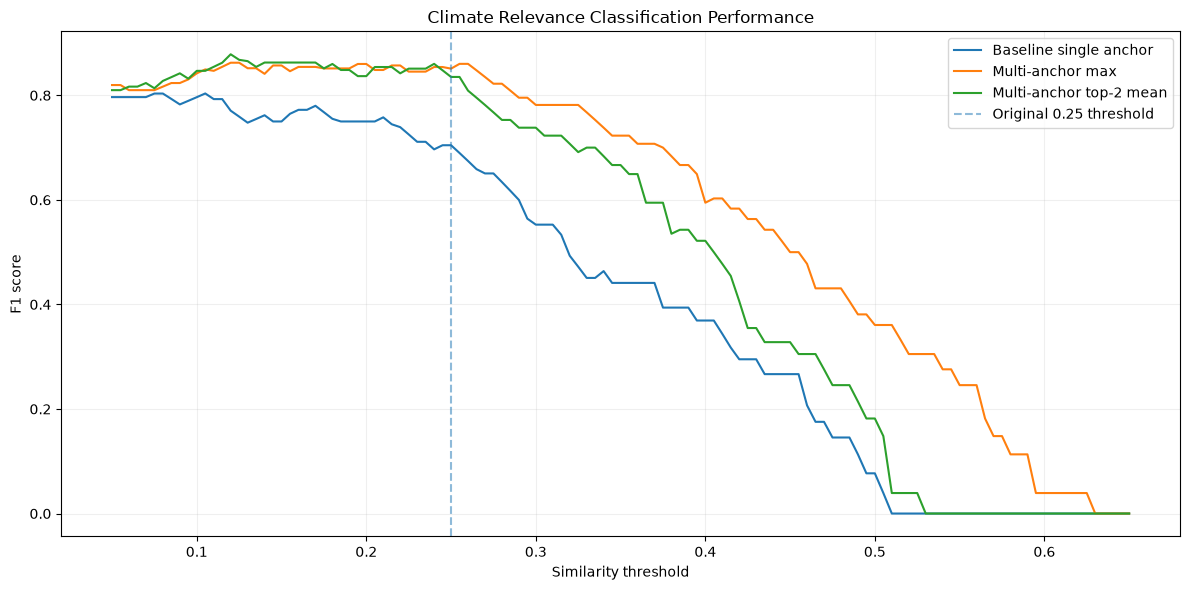


ROUND 1 WINNING MODEL
Method:     Multi-anchor top-2 mean
Threshold:  0.120
Mistakes:   13

Misclassified headlines:


,headline,outlet,label,climate_multi_top2_mean,error_type
27,The U.S. Struggle Over Climate-Change Disclosu...,forbes.com,0,0.450506,false_positive
43,A Climate-Conscious Lent: Coral reefs are dying,ncronline.org,0,0.380468,false_positive
15,Significant' questions buried in EPA proposal,politico.com,0,0.328507,false_positive
45,"Environmental, Social, Governance…and Violence",townhall.com,0,0.238357,false_positive
3,Editorial: Young people will prevail globally,pressrepublican.com,0,0.222396,false_positive
28,How to prevent the next COVID-19? Conservation...,mongabay.com,0,0.203530,false_positive
31,"Elephants, zebras, hippos among more than 700 ...",cbsnews.com,0,0.202216,false_positive
8,"After Hurricane Michael, Orlando’s vision is p...",orlandosentinel.com,0,0.177294,false_positive
22,New Mexico electric vehicle mandates to remain...,abcnews.go.com,0,0.138984,false_positive
77,Five Corporate Social Responsibility Trends Fo...,forbes.com,0,0.129695,false_positive



MANUALLY AMBIGUOUS HEADLINES


,headline,outlet,climate_similarity,climate_multi_max,climate_multi_top2_mean,climate_best_anchor
2,Big Oil’s Grip on California,thenation.com,0.203181,0.226670,0.212754,emissions_fossil_fuels
7,"What do midterms mean for … climate change, th...",theguardian.com,0.549397,0.405626,0.340533,climate_science
11,The Latest: Trump expected to roll back fuel e...,abcnews.go.com,0.325124,0.335982,0.335891,climate_policy
12,Hoyer: House priorities for 2020 include healt...,rollcall.com,0.439550,0.226198,0.222238,climate_science
35,Yale Alums' Fossil Fuel Divestment Movement Ov...,newsmax.com,0.220381,0.321098,0.228812,emissions_fossil_fuels
36,How Leaders Can Rethink What They Know And Emb...,forbes.com,0.478181,0.261454,0.257446,climate_policy


In [33]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

# ---------------------------------------------------------
# Locate labeled validation file
# ---------------------------------------------------------

possible_label_paths = [
    Path("data/interim/climate_relevance_validation_round1_labeled.csv"),
    Path("../data/interim/climate_relevance_validation_round1_labeled.csv"),
]

LABEL_PATH = next(
    (p for p in possible_label_paths if p.exists()),
    None
)

if LABEL_PATH is None:
    raise FileNotFoundError(
        "Could not find "
        "climate_relevance_validation_round1_labeled.csv "
        "under data/interim/"
    )

print("=" * 75)
print("LOAD LABELED VALIDATION DATA")
print("=" * 75)

print(f"File: {LABEL_PATH.resolve()}")

labels_df = pd.read_csv(
    LABEL_PATH,
    dtype={"id": str, "label": str},
)

required_columns = {
    "id",
    "headline",
    "outlet",
    "publish_date",
    "label",
}

missing_columns = (
    required_columns
    - set(labels_df.columns)
)

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )

# ---------------------------------------------------------
# Normalize manual labels
# ---------------------------------------------------------

labels_df["label"] = (
    labels_df["label"]
    .fillna("")
    .astype(str)
    .str.strip()
)

# Accommodate spreadsheet conversions like 1.0 / 0.0
labels_df["label"] = labels_df["label"].replace({
    "1.0": "1",
    "0.0": "0",
})

valid_labels = {"0", "1", "?"}

invalid_labels = sorted(
    set(labels_df["label"])
    - valid_labels
)

if invalid_labels:
    raise ValueError(
        f"Unexpected labels found: {invalid_labels}"
    )

print(f"Rows loaded: {len(labels_df):,}")

print("\nManual label distribution:")

display(
    labels_df["label"]
    .value_counts(dropna=False)
    .rename_axis("label")
    .to_frame("rows")
)

# ---------------------------------------------------------
# Recover semantic scores using article IDs
# ---------------------------------------------------------

score_columns = [
    "id",
    "climate_similarity",
    "climate_multi_max",
    "climate_multi_top2_mean",
    "climate_best_anchor",
]

scored_articles = (
    embedding_sample[
        score_columns
    ]
    .drop_duplicates("id")
)

validation_eval = labels_df.merge(
    scored_articles,
    on="id",
    how="left",
    validate="one_to_one",
)

missing_scores = (
    validation_eval["climate_similarity"]
    .isna()
    .sum()
)

print(
    f"\nRows missing semantic scores: "
    f"{missing_scores:,}"
)

if missing_scores:
    raise ValueError(
        "Some labeled IDs could not be matched to "
        "the benchmark embedding sample."
    )

# ---------------------------------------------------------
# Separate ambiguous records
# ---------------------------------------------------------

ambiguous_df = validation_eval[
    validation_eval["label"] == "?"
].copy()

evaluation_df = validation_eval[
    validation_eval["label"].isin(["0", "1"])
].copy()

evaluation_df["y_true"] = (
    evaluation_df["label"]
    .astype(int)
)

print("\n" + "=" * 75)
print("EVALUATION SET")
print("=" * 75)

print(
    f"Usable labeled records: "
    f"{len(evaluation_df):,}"
)

print(
    f"Ambiguous records excluded: "
    f"{len(ambiguous_df):,}"
)

print(
    f"Climate relevant (1): "
    f"{(evaluation_df['y_true'] == 1).sum():,}"
)

print(
    f"Not climate relevant (0): "
    f"{(evaluation_df['y_true'] == 0).sum():,}"
)

# ---------------------------------------------------------
# Models to compare
# ---------------------------------------------------------

METHODS = {
    "Baseline single anchor":
        "climate_similarity",

    "Multi-anchor max":
        "climate_multi_max",

    "Multi-anchor top-2 mean":
        "climate_multi_top2_mean",
}

# ---------------------------------------------------------
# Threshold-independent ranking metric
# ---------------------------------------------------------

auc_results = []

for method_name, score_col in METHODS.items():

    auc = roc_auc_score(
        evaluation_df["y_true"],
        evaluation_df[score_col],
    )

    auc_results.append({
        "method": method_name,
        "roc_auc": auc,
    })

auc_results = (
    pd.DataFrame(auc_results)
    .set_index("method")
    .sort_values(
        "roc_auc",
        ascending=False
    )
)

print("\n" + "=" * 75)
print("THRESHOLD-INDEPENDENT COMPARISON")
print("=" * 75)

display(
    auc_results.round(4)
)

# ---------------------------------------------------------
# Sweep candidate thresholds
# ---------------------------------------------------------

threshold_grid = np.round(
    np.arange(
        0.05,
        0.651,
        0.005
    ),
    3
)

metric_rows = []

for method_name, score_col in METHODS.items():

    y_true = (
        evaluation_df["y_true"]
        .to_numpy()
    )

    scores = (
        evaluation_df[score_col]
        .to_numpy()
    )

    for threshold in threshold_grid:

        y_pred = (
            scores >= threshold
        ).astype(int)

        tn, fp, fn, tp = confusion_matrix(
            y_true,
            y_pred,
            labels=[0, 1],
        ).ravel()

        specificity = (
            tn / (tn + fp)
            if (tn + fp) > 0
            else np.nan
        )

        metric_rows.append({
            "method": method_name,
            "threshold": threshold,
            "precision": precision_score(
                y_true,
                y_pred,
                zero_division=0,
            ),
            "recall": recall_score(
                y_true,
                y_pred,
                zero_division=0,
            ),
            "f1": f1_score(
                y_true,
                y_pred,
                zero_division=0,
            ),
            "accuracy": accuracy_score(
                y_true,
                y_pred,
            ),
            "balanced_accuracy":
                balanced_accuracy_score(
                    y_true,
                    y_pred,
                ),
            "specificity": specificity,
            "tp": tp,
            "fp": fp,
            "tn": tn,
            "fn": fn,
        })


threshold_metrics = pd.DataFrame(
    metric_rows
)

# ---------------------------------------------------------
# Best F1 threshold for each method
# ---------------------------------------------------------

best_f1_rows = (
    threshold_metrics
    .sort_values(
        [
            "method",
            "f1",
            "balanced_accuracy",
        ],
        ascending=[
            True,
            False,
            False,
        ],
    )
    .groupby("method")
    .head(1)
    .set_index("method")
)

print("\n" + "=" * 75)
print("BEST THRESHOLD BY F1")
print("=" * 75)

display(
    best_f1_rows[
        [
            "threshold",
            "precision",
            "recall",
            "f1",
            "specificity",
            "balanced_accuracy",
            "tp",
            "fp",
            "tn",
            "fn",
        ]
    ].round(4)
)

# ---------------------------------------------------------
# Best balanced-accuracy threshold
# ---------------------------------------------------------

best_balanced_rows = (
    threshold_metrics
    .sort_values(
        [
            "method",
            "balanced_accuracy",
            "f1",
        ],
        ascending=[
            True,
            False,
            False,
        ],
    )
    .groupby("method")
    .head(1)
    .set_index("method")
)

print("\n" + "=" * 75)
print("BEST THRESHOLD BY BALANCED ACCURACY")
print("=" * 75)

display(
    best_balanced_rows[
        [
            "threshold",
            "precision",
            "recall",
            "f1",
            "specificity",
            "balanced_accuracy",
        ]
    ].round(4)
)

# ---------------------------------------------------------
# Original project's 0.25 baseline
# ---------------------------------------------------------

baseline_025 = threshold_metrics[
    (threshold_metrics["method"]
        == "Baseline single anchor")
    &
    (threshold_metrics["threshold"]
        == 0.25)
]

print("\n" + "=" * 75)
print("ORIGINAL BASELINE @ 0.25")
print("=" * 75)

display(
    baseline_025[
        [
            "threshold",
            "precision",
            "recall",
            "f1",
            "specificity",
            "balanced_accuracy",
            "tp",
            "fp",
            "tn",
            "fn",
        ]
    ].round(4)
)

# ---------------------------------------------------------
# Plot F1 across thresholds
# ---------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(12, 6)
)

for method_name in METHODS:

    plot_df = threshold_metrics[
        threshold_metrics["method"]
        == method_name
    ]

    ax.plot(
        plot_df["threshold"],
        plot_df["f1"],
        label=method_name,
    )

ax.axvline(
    0.25,
    linestyle="--",
    alpha=0.5,
    label="Original 0.25 threshold",
)

ax.set_title(
    "Climate Relevance Classification Performance"
)

ax.set_xlabel(
    "Similarity threshold"
)

ax.set_ylabel(
    "F1 score"
)

ax.legend()

ax.grid(
    alpha=0.2
)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Examine mistakes for the best-F1 model
# ---------------------------------------------------------

winning_method = (
    best_f1_rows["f1"]
    .idxmax()
)

winning_score_col = METHODS[
    winning_method
]

winning_threshold = (
    best_f1_rows.loc[
        winning_method,
        "threshold"
    ]
)

evaluation_df["predicted_label"] = (
    evaluation_df[
        winning_score_col
    ]
    >= winning_threshold
).astype(int)

mistakes = evaluation_df[
    evaluation_df["predicted_label"]
    != evaluation_df["y_true"]
].copy()

mistakes["error_type"] = np.where(
    mistakes["predicted_label"] == 1,
    "false_positive",
    "false_negative",
)

print("\n" + "=" * 75)
print("ROUND 1 WINNING MODEL")
print("=" * 75)

print(
    f"Method:     {winning_method}"
)

print(
    f"Threshold:  {winning_threshold:.3f}"
)

print(
    f"Mistakes:   {len(mistakes):,}"
)

print("\nMisclassified headlines:")

display(
    mistakes[
        [
            "headline",
            "outlet",
            "label",
            winning_score_col,
            "error_type",
        ]
    ]
    .sort_values(
        winning_score_col,
        ascending=False,
    )
)

# ---------------------------------------------------------
# Ambiguous manual labels
# ---------------------------------------------------------

if len(ambiguous_df) > 0:

    print("\n" + "=" * 75)
    print("MANUALLY AMBIGUOUS HEADLINES")
    print("=" * 75)

    display(
        ambiguous_df[
            [
                "headline",
                "outlet",
                "climate_similarity",
                "climate_multi_max",
                "climate_multi_top2_mean",
                "climate_best_anchor",
            ]
        ]
    )

## 17. Round 1 Label Audit

Round 1 shows a clear improvement from multi-anchor climate representations, but several apparent classification errors may reflect ambiguity or inconsistency in manual labeling.

Before selecting a final model or threshold, only the difficult records are re-reviewed using a stricter headline-only annotation rule.

The audit includes:

- Round 1 misclassifications
- manually ambiguous records

No similarity scores are shown during re-labeling.

In [34]:
# ---------------------------------------------------------
# Build a small blinded audit set
# ---------------------------------------------------------

audit_ids = set(
    mistakes["id"].tolist()
) | set(
    ambiguous_df["id"].tolist()
)

round1_audit = (
    validation_eval[
        validation_eval["id"].isin(audit_ids)
    ][
        [
            "id",
            "headline",
            "outlet",
            "publish_date",
            "label",
            "notes",
        ]
    ]
    .copy()
)

round1_audit = round1_audit.rename(
    columns={
        "label": "original_label",
        "notes": "original_notes",
    }
)

round1_audit["reviewed_label"] = ""
round1_audit["review_notes"] = ""

# Shuffle so original error type/order is hidden
round1_audit = (
    round1_audit
    .sample(
        frac=1,
        random_state=RANDOM_SEED
    )
    .reset_index(drop=True)
)

AUDIT_FILE = (
    VALIDATION_DIR
    / "climate_relevance_round1_label_audit.csv"
)

round1_audit.to_csv(
    AUDIT_FILE,
    index=False
)

print("=" * 75)
print("ROUND 1 LABEL AUDIT")
print("=" * 75)

print(f"Rows to review: {len(round1_audit):,}")
print(f"Saved to:      {AUDIT_FILE.resolve()}")

display(round1_audit)

ROUND 1 LABEL AUDIT
Rows to review: 19
Saved to:      /Users/lasya/Documents/projects/media-polarization-lab/data/interim/climate_relevance_round1_label_audit.csv


,id,headline,outlet,publish_date,original_label,original_notes,reviewed_label,review_notes
0,88b7232989a3e1ee644fec5d74b19fceef2113f4e04035...,Farmers bring central Dublin to a halt with tr...,reuters.com,2019-11-27 00:00:00+00:00,1,NaN,,
1,454a458c1f73bd0229bc046cecc328c5438db8d854cb77...,The Latest: Trump expected to roll back fuel e...,abcnews.go.com,2017-03-14 00:00:00+00:00,?,NaN,,
2,b0f65a5d320d90b9506930cdc2bdfffdc01ed8f41e51cf...,How to prevent the next COVID-19? Conservation...,mongabay.com,2020-04-17 00:00:00+00:00,0,NaN,,
3,69436d143843ae3b298b49c3a4853d95dff08bad836e6a...,Big Oil’s Grip on California,thenation.com,2017-02-13 00:00:00+00:00,?,NaN,,
4,ab59bba5e75597ea5d64cf01db2a28a5778fc35ed77bf7...,"WHERE THEY STAND: Clinton, Trump on the issues",chron.com,2016-10-24 00:00:00+00:00,1,NaN,,
5,3111edd224f8f18608b0f6c19d3e3403520d8b243f7bdf...,A Climate-Conscious Lent: Coral reefs are dying,ncronline.org,2021-03-03 00:00:00+00:00,0,NaN,,
6,5c39022bfe523e63a2592b7ddf835335abd74a4b9340e8...,"What do midterms mean for … climate change, th...",theguardian.com,2018-11-07 00:00:00+00:00,?,NaN,,
7,b242e0f8d9bf56b5cc0b18d4fa82dcc30d3badfc94601f...,"Milwaukee area's household income is down, and...",jsonline.com,2020-10-30 00:00:00+00:00,1,NaN,,
8,f5171ed32660de2eb72a90c05aa81bf1859d10acd5a916...,How Leaders Can Rethink What They Know And Emb...,forbes.com,2022-07-29 00:00:00+00:00,?,NaN,,
9,d672ead251dc5b860c154d2a8dfe27fa5ee39088de4117...,"Environmental, Social, Governance…and Violence",townhall.com,2025-04-10 00:00:00+00:00,0,NaN,,


In [35]:
# ---------------------------------------------------------
# Create truly blinded audit file
# ---------------------------------------------------------

round1_audit_blind = round1_audit[
    [
        "id",
        "headline",
        "outlet",
        "publish_date",
    ]
].copy()

round1_audit_blind["reviewed_label"] = ""
round1_audit_blind["review_notes"] = ""

BLIND_AUDIT_FILE = (
    VALIDATION_DIR
    / "climate_relevance_round1_label_audit_blind.csv"
)

round1_audit_blind.to_csv(
    BLIND_AUDIT_FILE,
    index=False
)

print("=" * 75)
print("BLINDED ROUND 1 AUDIT")
print("=" * 75)

print(f"Rows to review: {len(round1_audit_blind):,}")
print(f"Saved to: {BLIND_AUDIT_FILE.resolve()}")

display(round1_audit_blind)

BLINDED ROUND 1 AUDIT
Rows to review: 19
Saved to: /Users/lasya/Documents/projects/media-polarization-lab/data/interim/climate_relevance_round1_label_audit_blind.csv


,id,headline,outlet,publish_date,reviewed_label,review_notes
0,88b7232989a3e1ee644fec5d74b19fceef2113f4e04035...,Farmers bring central Dublin to a halt with tr...,reuters.com,2019-11-27 00:00:00+00:00,,
1,454a458c1f73bd0229bc046cecc328c5438db8d854cb77...,The Latest: Trump expected to roll back fuel e...,abcnews.go.com,2017-03-14 00:00:00+00:00,,
2,b0f65a5d320d90b9506930cdc2bdfffdc01ed8f41e51cf...,How to prevent the next COVID-19? Conservation...,mongabay.com,2020-04-17 00:00:00+00:00,,
3,69436d143843ae3b298b49c3a4853d95dff08bad836e6a...,Big Oil’s Grip on California,thenation.com,2017-02-13 00:00:00+00:00,,
4,ab59bba5e75597ea5d64cf01db2a28a5778fc35ed77bf7...,"WHERE THEY STAND: Clinton, Trump on the issues",chron.com,2016-10-24 00:00:00+00:00,,
5,3111edd224f8f18608b0f6c19d3e3403520d8b243f7bdf...,A Climate-Conscious Lent: Coral reefs are dying,ncronline.org,2021-03-03 00:00:00+00:00,,
6,5c39022bfe523e63a2592b7ddf835335abd74a4b9340e8...,"What do midterms mean for … climate change, th...",theguardian.com,2018-11-07 00:00:00+00:00,,
7,b242e0f8d9bf56b5cc0b18d4fa82dcc30d3badfc94601f...,"Milwaukee area's household income is down, and...",jsonline.com,2020-10-30 00:00:00+00:00,,
8,f5171ed32660de2eb72a90c05aa81bf1859d10acd5a916...,How Leaders Can Rethink What They Know And Emb...,forbes.com,2022-07-29 00:00:00+00:00,,
9,d672ead251dc5b860c154d2a8dfe27fa5ee39088de4117...,"Environmental, Social, Governance…and Violence",townhall.com,2025-04-10 00:00:00+00:00,,


## 18. Round 1 Validation After Label Audit

The difficult Round 1 cases were independently re-reviewed using a stricter headline-only labeling rule.

For audited records, the reviewed label replaces the original annotation. All other Round 1 labels remain unchanged.

The corrected validation set is then used to recompute:

- ROC-AUC
- precision
- recall
- F1
- specificity
- balanced accuracy
- optimal thresholds
- classification errors

This produces the final Round 1 comparison used to design targeted Round 2 validation.

LOAD COMPLETED LABEL AUDIT
File:        /Users/lasya/Documents/projects/media-polarization-lab/data/interim/climate_relevance_round1_label_audit_completed.csv
Audit rows:  19

Reviewed label distribution:


,rows
label,
0,12
1,7



LABEL AUDIT IMPACT
Labels reviewed:      19
Labels changed:       14

Corrected label distribution:


,rows
label,
1,54
0,26



CORRECTED ROUND 1 EVALUATION SET
Usable labels:        80
Ambiguous labels:     0
Climate relevant:     54
Not climate relevant: 26

CORRECTED ROC-AUC


...

,threshold,precision,recall,f1,specificity,balanced_accuracy,tp,fp,tn,fn
method,,,,,,,,,,
Baseline single anchor,0.210,0.8200,0.7593,0.7885,0.6538,0.7066,41,9,17,13
Multi-anchor max,0.265,0.9556,0.7963,0.8687,0.9231,0.8597,43,2,24,11
Multi-anchor top-2 mean,0.240,0.9348,0.7963,0.8600,0.8846,0.8405,43,3,23,11



ORIGINAL BASELINE @ 0.25 — CORRECTED LABELS


,threshold,precision,recall,f1,specificity,balanced_accuracy,tp,fp,tn,fn
40,0.25,0.8095,0.6296,0.7083,0.6923,0.661,34,8,18,20



CORRECTED ROUND 1 WINNER
Method:             Multi-anchor top-2 mean
Threshold:          0.120
Precision:          0.857
Recall:             1.000
F1:                 0.923
Specificity:        0.654
Balanced accuracy:  0.827

Misclassifications: 9


,headline,outlet,label,climate_multi_top2_mean,error_type
7,"What do midterms mean for … climate change, th...",theguardian.com,0,0.340533,false_positive
11,The Latest: Trump expected to roll back fuel e...,abcnews.go.com,0,0.335891,false_positive
36,How Leaders Can Rethink What They Know And Emb...,forbes.com,0,0.257446,false_positive
45,"Environmental, Social, Governance…and Violence",townhall.com,0,0.238357,false_positive
3,Editorial: Young people will prevail globally,pressrepublican.com,0,0.222396,false_positive
2,Big Oil’s Grip on California,thenation.com,0,0.212754,false_positive
28,How to prevent the next COVID-19? Conservation...,mongabay.com,0,0.203530,false_positive
22,New Mexico electric vehicle mandates to remain...,abcnews.go.com,0,0.138984,false_positive
77,Five Corporate Social Responsibility Trends Fo...,forbes.com,0,0.129695,false_positive


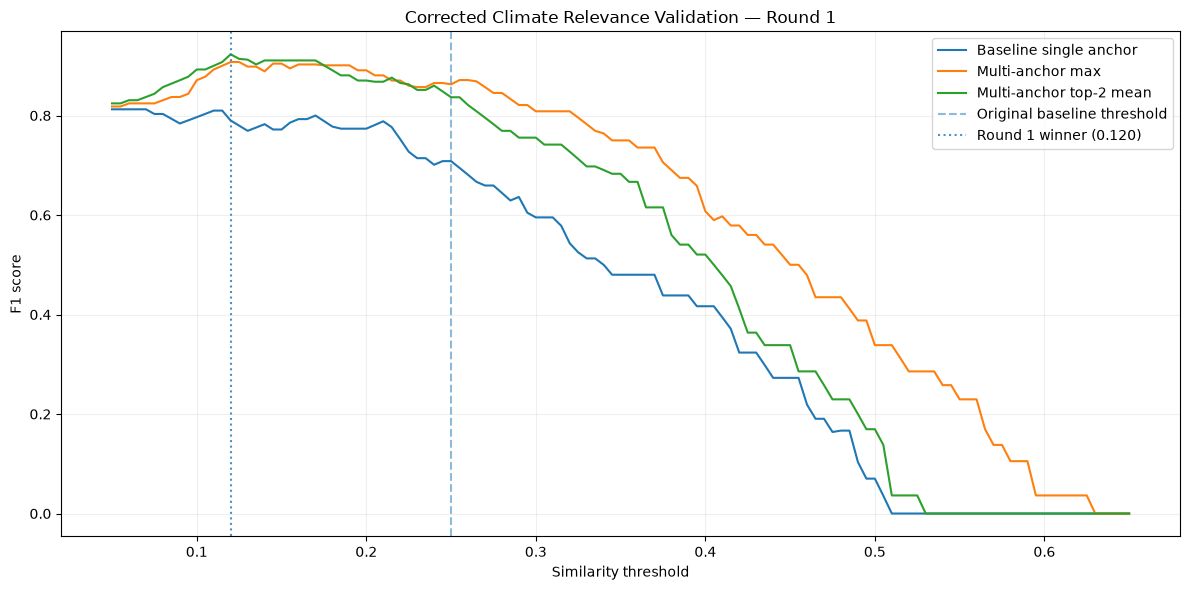

In [36]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

# ---------------------------------------------------------
# Locate completed audit
# ---------------------------------------------------------

possible_audit_paths = [
    Path(
        "data/interim/"
        "climate_relevance_round1_label_audit_completed.csv"
    ),
    Path(
        "../data/interim/"
        "climate_relevance_round1_label_audit_completed.csv"
    ),
]

AUDIT_PATH = next(
    (p for p in possible_audit_paths if p.exists()),
    None
)

if AUDIT_PATH is None:
    raise FileNotFoundError(
        "Could not find "
        "climate_relevance_round1_label_audit_completed.csv"
    )

audit_completed = pd.read_csv(
    AUDIT_PATH,
    dtype={
        "id": str,
        "reviewed_label": str,
    },
)

print("=" * 75)
print("LOAD COMPLETED LABEL AUDIT")
print("=" * 75)

print(f"File:        {AUDIT_PATH.resolve()}")
print(f"Audit rows:  {len(audit_completed):,}")

# ---------------------------------------------------------
# Normalize reviewed labels
# ---------------------------------------------------------

audit_completed["reviewed_label"] = (
    audit_completed["reviewed_label"]
    .fillna("")
    .astype(str)
    .str.strip()
    .replace({
        "1.0": "1",
        "0.0": "0",
    })
)

valid_labels = {"0", "1", "?"}

invalid_review_labels = sorted(
    set(audit_completed["reviewed_label"])
    - valid_labels
)

if invalid_review_labels:
    raise ValueError(
        f"Unexpected reviewed labels: "
        f"{invalid_review_labels}"
    )

print("\nReviewed label distribution:")

display(
    audit_completed[
        "reviewed_label"
    ]
    .value_counts()
    .rename_axis("label")
    .to_frame("rows")
)

# ---------------------------------------------------------
# Rebuild corrected Round 1 validation set
# ---------------------------------------------------------

round1_corrected = (
    validation_eval
    .copy()
)

review_map = (
    audit_completed
    .set_index("id")[
        "reviewed_label"
    ]
    .to_dict()
)

round1_corrected["original_label"] = (
    round1_corrected["label"]
)

round1_corrected["label"] = (
    round1_corrected.apply(
        lambda row:
            review_map.get(
                row["id"],
                row["label"]
            ),
        axis=1,
    )
)

round1_corrected["label_changed"] = (
    round1_corrected["label"]
    != round1_corrected["original_label"]
)

print("\n" + "=" * 75)
print("LABEL AUDIT IMPACT")
print("=" * 75)

print(
    f"Labels reviewed:      "
    f"{len(audit_completed):,}"
)

print(
    f"Labels changed:       "
    f"{round1_corrected['label_changed'].sum():,}"
)

print("\nCorrected label distribution:")

display(
    round1_corrected["label"]
    .value_counts()
    .rename_axis("label")
    .to_frame("rows")
)

# ---------------------------------------------------------
# Quantitative evaluation set
# ---------------------------------------------------------

round1_ambiguous = (
    round1_corrected[
        round1_corrected["label"] == "?"
    ]
    .copy()
)

round1_eval = (
    round1_corrected[
        round1_corrected["label"].isin(
            ["0", "1"]
        )
    ]
    .copy()
)

round1_eval["y_true"] = (
    round1_eval["label"]
    .astype(int)
)

print("\n" + "=" * 75)
print("CORRECTED ROUND 1 EVALUATION SET")
print("=" * 75)

print(
    f"Usable labels:        "
    f"{len(round1_eval):,}"
)

print(
    f"Ambiguous labels:     "
    f"{len(round1_ambiguous):,}"
)

print(
    f"Climate relevant:     "
    f"{(round1_eval['y_true'] == 1).sum():,}"
)

print(
    f"Not climate relevant: "
    f"{(round1_eval['y_true'] == 0).sum():,}"
)

# ---------------------------------------------------------
# Methods
# ---------------------------------------------------------

METHODS = {
    "Baseline single anchor":
        "climate_similarity",

    "Multi-anchor max":
        "climate_multi_max",

    "Multi-anchor top-2 mean":
        "climate_multi_top2_mean",
}

# ---------------------------------------------------------
# ROC-AUC
# ---------------------------------------------------------

auc_rows = []

for method_name, score_col in METHODS.items():

    auc_rows.append({
        "method": method_name,
        "roc_auc": roc_auc_score(
            round1_eval["y_true"],
            round1_eval[score_col],
        ),
    })

corrected_auc = (
    pd.DataFrame(auc_rows)
    .set_index("method")
    .sort_values(
        "roc_auc",
        ascending=False
    )
)

print("\n" + "=" * 75)
print("CORRECTED ROC-AUC")
print("=" * 75)

display(
    corrected_auc.round(4)
)

# ---------------------------------------------------------
# Threshold sweep
# ---------------------------------------------------------

threshold_grid = np.round(
    np.arange(
        0.05,
        0.651,
        0.005
    ),
    3
)

metric_rows = []

for method_name, score_col in METHODS.items():

    y_true = (
        round1_eval["y_true"]
        .to_numpy()
    )

    scores = (
        round1_eval[score_col]
        .to_numpy()
    )

    for threshold in threshold_grid:

        y_pred = (
            scores >= threshold
        ).astype(int)

        tn, fp, fn, tp = confusion_matrix(
            y_true,
            y_pred,
            labels=[0, 1],
        ).ravel()

        specificity = (
            tn / (tn + fp)
            if (tn + fp) > 0
            else np.nan
        )

        metric_rows.append({
            "method": method_name,
            "threshold": threshold,

            "precision": precision_score(
                y_true,
                y_pred,
                zero_division=0,
            ),

            "recall": recall_score(
                y_true,
                y_pred,
                zero_division=0,
            ),

            "f1": f1_score(
                y_true,
                y_pred,
                zero_division=0,
            ),

            "accuracy": accuracy_score(
                y_true,
                y_pred,
            ),

            "balanced_accuracy":
                balanced_accuracy_score(
                    y_true,
                    y_pred,
                ),

            "specificity":
                specificity,

            "tp": tp,
            "fp": fp,
            "tn": tn,
            "fn": fn,
        })


corrected_threshold_metrics = (
    pd.DataFrame(metric_rows)
)

# ---------------------------------------------------------
# Best F1 threshold
# ---------------------------------------------------------

corrected_best_f1 = (
    corrected_threshold_metrics
    .sort_values(
        [
            "method",
            "f1",
            "balanced_accuracy",
            "precision",
        ],
        ascending=[
            True,
            False,
            False,
            False,
        ],
    )
    .groupby("method")
    .head(1)
    .set_index("method")
)

print("\n" + "=" * 75)
print("BEST THRESHOLD BY F1 — CORRECTED")
print("=" * 75)

display(
    corrected_best_f1[
        [
            "threshold",
            "precision",
            "recall",
            "f1",
            "specificity",
            "balanced_accuracy",
            "tp",
            "fp",
            "tn",
            "fn",
        ]
    ]
    .round(4)
)

# ---------------------------------------------------------
# Best balanced accuracy
# ---------------------------------------------------------

corrected_best_balanced = (
    corrected_threshold_metrics
    .sort_values(
        [
            "method",
            "balanced_accuracy",
            "f1",
            "precision",
        ],
        ascending=[
            True,
            False,
            False,
            False,
        ],
    )
    .groupby("method")
    .head(1)
    .set_index("method")
)

print("\n" + "=" * 75)
print("BEST THRESHOLD BY BALANCED ACCURACY — CORRECTED")
print("=" * 75)

display(
    corrected_best_balanced[
        [
            "threshold",
            "precision",
            "recall",
            "f1",
            "specificity",
            "balanced_accuracy",
            "tp",
            "fp",
            "tn",
            "fn",
        ]
    ]
    .round(4)
)

# ---------------------------------------------------------
# Original baseline threshold = 0.25
# ---------------------------------------------------------

corrected_baseline_025 = (
    corrected_threshold_metrics[
        (
            corrected_threshold_metrics["method"]
            == "Baseline single anchor"
        )
        &
        (
            corrected_threshold_metrics["threshold"]
            == 0.25
        )
    ]
)

print("\n" + "=" * 75)
print("ORIGINAL BASELINE @ 0.25 — CORRECTED LABELS")
print("=" * 75)

display(
    corrected_baseline_025[
        [
            "threshold",
            "precision",
            "recall",
            "f1",
            "specificity",
            "balanced_accuracy",
            "tp",
            "fp",
            "tn",
            "fn",
        ]
    ]
    .round(4)
)

# ---------------------------------------------------------
# Winner
# ---------------------------------------------------------

winning_method = (
    corrected_best_f1["f1"]
    .idxmax()
)

winning_score_col = (
    METHODS[winning_method]
)

winning_threshold = (
    corrected_best_f1.loc[
        winning_method,
        "threshold"
    ]
)

winning_metrics = (
    corrected_best_f1.loc[
        winning_method
    ]
)

print("\n" + "=" * 75)
print("CORRECTED ROUND 1 WINNER")
print("=" * 75)

print(
    f"Method:             "
    f"{winning_method}"
)

print(
    f"Threshold:          "
    f"{winning_threshold:.3f}"
)

print(
    f"Precision:          "
    f"{winning_metrics['precision']:.3f}"
)

print(
    f"Recall:             "
    f"{winning_metrics['recall']:.3f}"
)

print(
    f"F1:                 "
    f"{winning_metrics['f1']:.3f}"
)

print(
    f"Specificity:        "
    f"{winning_metrics['specificity']:.3f}"
)

print(
    f"Balanced accuracy:  "
    f"{winning_metrics['balanced_accuracy']:.3f}"
)

# ---------------------------------------------------------
# Corrected mistakes
# ---------------------------------------------------------

round1_eval["predicted_label"] = (
    round1_eval[
        winning_score_col
    ]
    >= winning_threshold
).astype(int)

corrected_mistakes = (
    round1_eval[
        round1_eval["predicted_label"]
        != round1_eval["y_true"]
    ]
    .copy()
)

corrected_mistakes["error_type"] = np.where(
    corrected_mistakes[
        "predicted_label"
    ] == 1,
    "false_positive",
    "false_negative",
)

print(
    f"\nMisclassifications: "
    f"{len(corrected_mistakes):,}"
)

display(
    corrected_mistakes[
        [
            "headline",
            "outlet",
            "label",
            winning_score_col,
            "error_type",
        ]
    ]
    .sort_values(
        winning_score_col,
        ascending=False,
    )
)

# ---------------------------------------------------------
# Plot corrected F1 curves
# ---------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(12, 6)
)

for method_name in METHODS:

    plot_df = (
        corrected_threshold_metrics[
            corrected_threshold_metrics["method"]
            == method_name
        ]
    )

    ax.plot(
        plot_df["threshold"],
        plot_df["f1"],
        label=method_name,
    )

ax.axvline(
    0.25,
    linestyle="--",
    alpha=0.5,
    label="Original baseline threshold",
)

ax.axvline(
    winning_threshold,
    linestyle=":",
    alpha=0.8,
    label=(
        f"Round 1 winner "
        f"({winning_threshold:.3f})"
    ),
)

ax.set_title(
    "Corrected Climate Relevance Validation — Round 1"
)

ax.set_xlabel(
    "Similarity threshold"
)

ax.set_ylabel(
    "F1 score"
)

ax.legend()

ax.grid(
    alpha=0.2
)

plt.tight_layout()
plt.show()

## 19. Targeted Climate Relevance Validation — Round 2

Round 1 strongly favors the multi-anchor semantic representation over the original single climate anchor.

For the downstream polarization analysis, false-positive climate classifications are especially undesirable because unrelated headlines would directly influence outlet-month semantic centroids.

The multi-anchor maximum score therefore becomes the leading candidate for final validation.

Round 2 focuses only on the difficult decision region surrounding the provisional threshold near `0.265`.

A new blinded set of headlines is sampled from narrow similarity bands around this boundary. Records already used in Round 1 are excluded.

The objective is to determine where human judgments transition from predominantly non-climate to predominantly climate-related content.

In [37]:
# ---------------------------------------------------------
# Round 2 — targeted boundary validation
# ---------------------------------------------------------

ROUND2_TARGET = 24

# Never reuse a Round 1 article
round1_ids = set(
    round1_corrected["id"]
)

round2_pool = (
    embedding_sample[
        ~embedding_sample["id"].isin(round1_ids)
    ]
    .copy()
)

# Narrow bands around the promising
# multi-anchor-max decision region.
round2_bands = [
    ("0.20–0.23", 0.20, 0.23),
    ("0.23–0.25", 0.23, 0.25),
    ("0.25–0.27", 0.25, 0.27),
    ("0.27–0.29", 0.27, 0.29),
    ("0.29–0.32", 0.29, 0.32),
    ("0.32–0.36", 0.32, 0.36),
]

round2_parts = []

for i, (label, lower, upper) in enumerate(round2_bands):

    band = round2_pool[
        (
            round2_pool["climate_multi_max"]
            >= lower
        )
        &
        (
            round2_pool["climate_multi_max"]
            < upper
        )
    ]

    n = min(
        4,
        len(band)
    )

    if n == 0:
        continue

    sampled = (
        band.sample(
            n=n,
            random_state=RANDOM_SEED + 100 + i
        )
        .copy()
    )

    sampled["round2_band"] = label

    round2_parts.append(
        sampled
    )

round2_full = (
    pd.concat(
        round2_parts,
        ignore_index=True
    )
    .drop_duplicates("id")
)

# ---------------------------------------------------------
# Ensure exactly 24 where possible
# ---------------------------------------------------------

if len(round2_full) < ROUND2_TARGET:

    needed = (
        ROUND2_TARGET
        - len(round2_full)
    )

    remaining_pool = round2_pool[
        ~round2_pool["id"].isin(
            round2_full["id"]
        )
        &
        round2_pool[
            "climate_multi_max"
        ].between(
            0.20,
            0.36,
            inclusive="left"
        )
    ]

    topup = (
        remaining_pool.sample(
            n=min(
                needed,
                len(remaining_pool)
            ),
            random_state=RANDOM_SEED + 9999
        )
        .copy()
    )

    topup["round2_band"] = "boundary_topup"

    round2_full = pd.concat(
        [
            round2_full,
            topup
        ],
        ignore_index=True
    )

# ---------------------------------------------------------
# Shuffle for blinded labeling
# ---------------------------------------------------------

round2_full = (
    round2_full
    .sample(
        frac=1,
        random_state=RANDOM_SEED + 200
    )
    .reset_index(drop=True)
)

# ---------------------------------------------------------
# Create blinded file
# ---------------------------------------------------------

round2_to_label = (
    round2_full[
        [
            "id",
            "title_nlp_candidate",
            "media_name",
            "publish_dt",
        ]
    ]
    .rename(
        columns={
            "title_nlp_candidate": "headline",
            "media_name": "outlet",
            "publish_dt": "publish_date",
        }
    )
    .copy()
)

round2_to_label["label"] = ""
round2_to_label["notes"] = ""

ROUND2_FILE = (
    VALIDATION_DIR
    / "climate_relevance_validation_round2.csv"
)

round2_to_label.to_csv(
    ROUND2_FILE,
    index=False
)

print("=" * 75)
print("ROUND 2 BOUNDARY VALIDATION")
print("=" * 75)

print(
    f"Rows to label:       "
    f"{len(round2_to_label):,}"
)

print(
    f"Unique outlets:      "
    f"{round2_to_label['outlet'].nunique():,}"
)

print(
    f"Round 1 overlap:     "
    f"{round2_to_label['id'].isin(round1_ids).sum():,}"
)

print(
    f"Saved to:            "
    f"{ROUND2_FILE.resolve()}"
)

print("\nInternal sampling bands:")

display(
    round2_full[
        "round2_band"
    ]
    .value_counts()
    .sort_index()
    .rename("rows")
    .to_frame()
)

print("\nBlinded preview:")

display(
    round2_to_label
)

ROUND 2 BOUNDARY VALIDATION
Rows to label:       24
Unique outlets:      20
Round 1 overlap:     0
Saved to:            /Users/lasya/Documents/projects/media-polarization-lab/data/interim/climate_relevance_validation_round2.csv

Internal sampling bands:


,rows
round2_band,
0.20–0.23,4
0.23–0.25,4
0.25–0.27,4
0.27–0.29,4
0.29–0.32,4
0.32–0.36,4



Blinded preview:


,id,headline,outlet,publish_date,label,notes
0,763b1d1b6374fd810dbb48cc1260c16c458ed05cadeeec...,Storm decimates 2 Alaskan villages and drives ...,twincities.com,2025-10-15 00:00:00+00:00,,
1,93683c67e6c705bbca2d70e3448bf5a0ce556e0972c34c...,‘We are getting ready to welcome the public ba...,sun-sentinel.com,2024-05-07 00:00:00+00:00,,
2,30f5e08ce835c5c2848a8fc863c0479c38cf75d51070f6...,Cheeky climate protest stops Senate after acti...,orlandosentinel.com,2023-06-15 00:00:00+00:00,,
3,8aa741aa8d0c94dc888f4bacf1a0a65d2569ef5b438326...,Green Technology and Sustainability Market Wor...,benzinga.com,2024-03-15 00:00:00+00:00,,
4,a704b94370cc42825c766165ba2637ecfc576fd5a5fe20...,E.P.A. Takes a Major Step to Roll Back Clean C...,nytimes.com,2018-05-31 00:00:00+00:00,,
5,5829941c5d05e10e9261c8224da6d15d5c074c703e1807...,How to Construct Buildings That Have a Positiv...,scientificamerican.com,2022-12-13 00:00:00+00:00,,
6,eb257a050bc2854f429397d09beab54ad64aed3c38f002...,Another freshwater mussel could get federal pr...,sfgate.com,2018-10-10 00:00:00+00:00,,
7,ec9acc72eac71d624c4be8d4e4791999c482282def99c7...,The 1 Trillion-Euro Fight: EU Leaders Wrangle ...,usnews.com,2020-02-20 00:00:00+00:00,,
8,5a771cdb6f50fe4096bb5caaef4f01cfd7804c963257c5...,Pakistan scrambles to deliver aid as flood dea...,abcnews.go.com,2022-09-13 00:00:00+00:00,,
9,3e9b2563fff1d92560747e29a653e55106ed807d5f6036...,Southern Africa facing its worst hunger crisis...,pbs.org,2024-10-15 00:00:00+00:00,,


## 20. Final Climate Relevance Validation

Round 2 provides targeted human judgments around the decision boundary identified in Round 1.

The final validation combines:

- corrected Round 1 labels
- targeted Round 2 boundary labels

Because both validation rounds intentionally oversample difficult semantic regions, the labeled sample is not used to estimate the prevalence of climate coverage in the full corpus.

The validation is used only to:

- compare semantic scoring methods
- inspect the transition around the decision boundary
- measure classification errors
- select a conservative operating threshold

For downstream centroid analysis, false-positive climate classifications are especially undesirable. Therefore, threshold selection prioritizes specificity while retaining reasonable recall.

ROUND 2 LABELED DATA
File: /Users/lasya/Documents/projects/media-polarization-lab/data/interim/climate_relevance_validation_round2_labeled.csv
Rows loaded: 24

Round 2 label distribution:


,rows
label,
1,19
0,5



Rows missing scores: 0

ROUND 2 BOUNDARY LABELS


,rows,climate_relevant,not_climate,ambiguous,usable_labels,positive_rate
round2_band,,,,,,
0.20–0.23,4,2,2,0,4,0.50
0.23–0.25,4,4,0,0,4,1.00
0.25–0.27,4,3,1,0,4,0.75
0.27–0.29,4,3,1,0,4,0.75
0.29–0.32,4,3,1,0,4,0.75
0.32–0.36,4,4,0,0,4,1.00



FINAL HUMAN-LABELED VALIDATION SET
Total labeled rows:       104
Usable binary labels:     104
Ambiguous labels:         0
Climate relevant:         73
Not climate relevant:     31

FINAL ROC-AUC COMPARISON


...

,threshold,precision,recall,f1,f0_5,specificity,balanced_accuracy,tp,fp,tn,fn
method,,,,,,,,,,,
Baseline single anchor,0.340,0.8846,0.3151,0.4646,0.6497,0.9032,0.6091,23,3,28,50
Multi-anchor max,0.275,0.9434,0.6849,0.7937,0.8772,0.9032,0.7941,50,3,28,23
Multi-anchor top-2 mean,0.240,0.9474,0.7397,0.8308,0.8970,0.9032,0.8215,54,3,28,19



MULTI-ANCHOR BOUNDARY COMPARISON


,method,threshold,precision,recall,f1,specificity,balanced_accuracy
85,Multi-anchor max,0.220,0.8667,0.8904,0.8784,0.6774,0.7839
86,Multi-anchor max,0.225,0.8630,0.8630,0.8630,0.6774,0.7702
87,Multi-anchor max,0.230,0.8732,0.8493,0.8611,0.7097,0.7795
88,Multi-anchor max,0.235,0.8696,0.8219,0.8451,0.7097,0.7658
89,Multi-anchor max,0.240,0.8824,0.8219,0.8511,0.7419,0.7819
90,Multi-anchor max,0.245,0.8824,0.8219,0.8511,0.7419,0.7819
91,Multi-anchor max,0.250,0.8906,0.7808,0.8321,0.7742,0.7775
92,Multi-anchor max,0.255,0.9180,0.7671,0.8358,0.8387,0.8029
93,Multi-anchor max,0.260,0.9153,0.7397,0.8182,0.8387,0.7892
94,Multi-anchor max,0.265,0.9298,0.7260,0.8154,0.8710,0.7985



PROVISIONAL FINAL CLIMATE CLASSIFIER
Method:             Multi-anchor top-2 mean
Threshold:          0.240
Precision:          0.947
Recall:             0.740
Specificity:        0.903
F1:                 0.831
Balanced accuracy:  0.821

Errors at provisional final threshold: 22


,headline,outlet,validation_round,label,climate_multi_top2_mean,error_type
7,"What do midterms mean for … climate change, th...",theguardian.com,round1,0,0.340533,false_positive
11,The Latest: Trump expected to roll back fuel e...,abcnews.go.com,round1,0,0.335891,false_positive
36,How Leaders Can Rethink What They Know And Emb...,forbes.com,round1,0,0.257446,false_positive
35,Yale Alums' Fossil Fuel Divestment Movement Ov...,newsmax.com,round1,1,0.228812,false_negative
12,Hoyer: House priorities for 2020 include healt...,rollcall.com,round1,1,0.222238,false_negative
102,"Weeks after floods, Vermont businesses struggl...",abcnews.go.com,round2,1,0.222200,false_negative
88,Pakistan scrambles to deliver aid as flood dea...,abcnews.go.com,round2,1,0.220228,false_negative
86,Another freshwater mussel could get federal pr...,sfgate.com,round2,1,0.219866,false_negative
39,Duke Energy urges customers to prepare for sno...,benzinga.com,round1,1,0.215579,false_negative
84,E.P.A. Takes a Major Step to Roll Back Clean C...,nytimes.com,round2,1,0.214575,false_negative


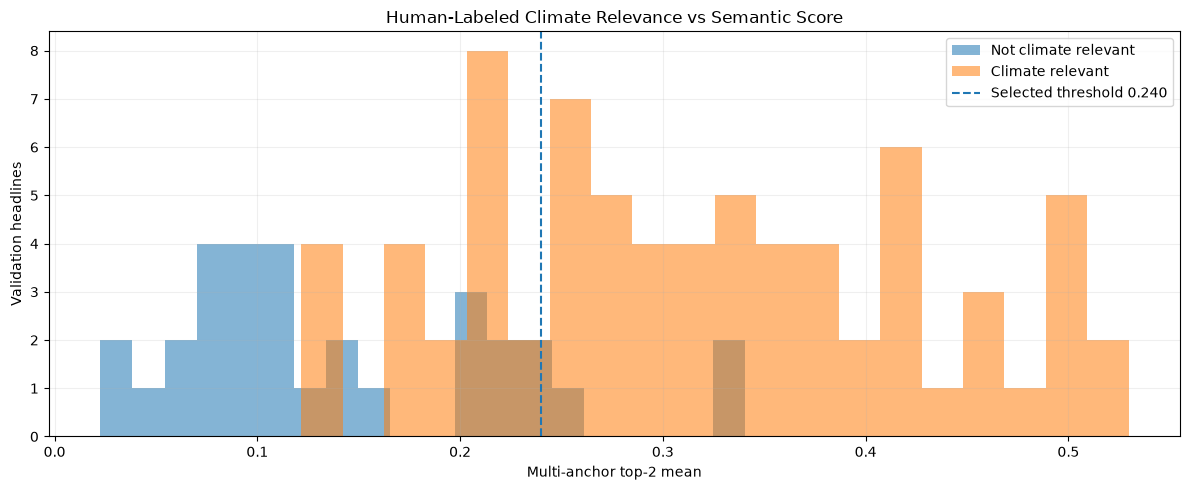

In [38]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.metrics import (
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

# ---------------------------------------------------------
# Locate Round 2 labeled file
# ---------------------------------------------------------

possible_round2_paths = [
    Path(
        "data/interim/"
        "climate_relevance_validation_round2_labeled.csv"
    ),
    Path(
        "../data/interim/"
        "climate_relevance_validation_round2_labeled.csv"
    ),
]

ROUND2_LABEL_PATH = next(
    (p for p in possible_round2_paths if p.exists()),
    None
)

if ROUND2_LABEL_PATH is None:
    raise FileNotFoundError(
        "Could not find "
        "climate_relevance_validation_round2_labeled.csv"
    )

round2_labels = pd.read_csv(
    ROUND2_LABEL_PATH,
    dtype={
        "id": str,
        "label": str,
    },
)

print("=" * 75)
print("ROUND 2 LABELED DATA")
print("=" * 75)

print(
    f"File: "
    f"{ROUND2_LABEL_PATH.resolve()}"
)

print(
    f"Rows loaded: "
    f"{len(round2_labels):,}"
)

# ---------------------------------------------------------
# Normalize labels
# ---------------------------------------------------------

round2_labels["label"] = (
    round2_labels["label"]
    .fillna("")
    .astype(str)
    .str.strip()
    .replace({
        "1.0": "1",
        "0.0": "0",
    })
)

valid_labels = {"0", "1", "?"}

unexpected = (
    set(round2_labels["label"])
    - valid_labels
)

if unexpected:
    raise ValueError(
        f"Unexpected Round 2 labels: "
        f"{sorted(unexpected)}"
    )

print("\nRound 2 label distribution:")

display(
    round2_labels[
        "label"
    ]
    .value_counts()
    .rename_axis("label")
    .to_frame("rows")
)

# ---------------------------------------------------------
# Recover hidden Round 2 score information
# ---------------------------------------------------------

round2_scores = (
    round2_full[
        [
            "id",
            "round2_band",
            "climate_similarity",
            "climate_multi_max",
            "climate_multi_top2_mean",
            "climate_best_anchor",
        ]
    ]
    .drop_duplicates("id")
)

round2_eval_full = (
    round2_labels
    .merge(
        round2_scores,
        on="id",
        how="left",
        validate="one_to_one",
    )
)

missing_scores = (
    round2_eval_full[
        "climate_multi_max"
    ]
    .isna()
    .sum()
)

print(
    f"\nRows missing scores: "
    f"{missing_scores:,}"
)

if missing_scores:
    raise ValueError(
        "Some Round 2 IDs could not be matched "
        "to their semantic scores."
    )

# ---------------------------------------------------------
# Round 2 boundary composition
# ---------------------------------------------------------

round2_numeric = (
    round2_eval_full[
        round2_eval_full["label"]
        .isin(["0", "1"])
    ]
    .copy()
)

round2_numeric["y_true"] = (
    round2_numeric["label"]
    .astype(int)
)

band_summary = (
    round2_eval_full
    .groupby(
        "round2_band",
        observed=True
    )
    .agg(
        rows=("id", "size"),
        climate_relevant=(
            "label",
            lambda x: (x == "1").sum()
        ),
        not_climate=(
            "label",
            lambda x: (x == "0").sum()
        ),
        ambiguous=(
            "label",
            lambda x: (x == "?").sum()
        ),
    )
)

band_summary[
    "usable_labels"
] = (
    band_summary["climate_relevant"]
    + band_summary["not_climate"]
)

band_summary[
    "positive_rate"
] = np.where(
    band_summary["usable_labels"] > 0,
    band_summary["climate_relevant"]
    / band_summary["usable_labels"],
    np.nan,
)

print("\n" + "=" * 75)
print("ROUND 2 BOUNDARY LABELS")
print("=" * 75)

display(
    band_summary.round(3)
)

# ---------------------------------------------------------
# Prepare corrected Round 1 scores
# ---------------------------------------------------------

round1_final = (
    round1_corrected[
        [
            "id",
            "headline",
            "outlet",
            "publish_date",
            "label",
            "climate_similarity",
            "climate_multi_max",
            "climate_multi_top2_mean",
            "climate_best_anchor",
        ]
    ]
    .copy()
)

round1_final["validation_round"] = (
    "round1"
)

round2_final = (
    round2_eval_full[
        [
            "id",
            "headline",
            "outlet",
            "publish_date",
            "label",
            "climate_similarity",
            "climate_multi_max",
            "climate_multi_top2_mean",
            "climate_best_anchor",
        ]
    ]
    .copy()
)

round2_final["validation_round"] = (
    "round2"
)

# ---------------------------------------------------------
# Combine both rounds
# ---------------------------------------------------------

final_validation = (
    pd.concat(
        [
            round1_final,
            round2_final,
        ],
        ignore_index=True,
    )
    .drop_duplicates(
        subset="id",
        keep="first",
    )
)

final_numeric = (
    final_validation[
        final_validation["label"]
        .isin(["0", "1"])
    ]
    .copy()
)

final_numeric["y_true"] = (
    final_numeric["label"]
    .astype(int)
)

print("\n" + "=" * 75)
print("FINAL HUMAN-LABELED VALIDATION SET")
print("=" * 75)

print(
    f"Total labeled rows:       "
    f"{len(final_validation):,}"
)

print(
    f"Usable binary labels:     "
    f"{len(final_numeric):,}"
)

print(
    f"Ambiguous labels:         "
    f"{(final_validation['label'] == '?').sum():,}"
)

print(
    f"Climate relevant:         "
    f"{(final_numeric['y_true'] == 1).sum():,}"
)

print(
    f"Not climate relevant:     "
    f"{(final_numeric['y_true'] == 0).sum():,}"
)

# ---------------------------------------------------------
# Compare scoring methods
# ---------------------------------------------------------

METHODS = {
    "Baseline single anchor":
        "climate_similarity",

    "Multi-anchor max":
        "climate_multi_max",

    "Multi-anchor top-2 mean":
        "climate_multi_top2_mean",
}

auc_rows = []

for method_name, score_col in METHODS.items():

    auc_rows.append({
        "method": method_name,

        "roc_auc": roc_auc_score(
            final_numeric["y_true"],
            final_numeric[score_col],
        ),
    })

final_auc = (
    pd.DataFrame(auc_rows)
    .set_index("method")
    .sort_values(
        "roc_auc",
        ascending=False,
    )
)

print("\n" + "=" * 75)
print("FINAL ROC-AUC COMPARISON")
print("=" * 75)

display(
    final_auc.round(4)
)

# ---------------------------------------------------------
# Threshold sweep
# ---------------------------------------------------------

threshold_grid = np.round(
    np.arange(
        0.10,
        0.401,
        0.005,
    ),
    3,
)

metric_rows = []

for method_name, score_col in METHODS.items():

    y_true = (
        final_numeric["y_true"]
        .to_numpy()
    )

    scores = (
        final_numeric[score_col]
        .to_numpy()
    )

    for threshold in threshold_grid:

        y_pred = (
            scores >= threshold
        ).astype(int)

        tn, fp, fn, tp = confusion_matrix(
            y_true,
            y_pred,
            labels=[0, 1],
        ).ravel()

        specificity = (
            tn / (tn + fp)
            if (tn + fp)
            else np.nan
        )

        precision = precision_score(
            y_true,
            y_pred,
            zero_division=0,
        )

        recall = recall_score(
            y_true,
            y_pred,
            zero_division=0,
        )

        f1 = f1_score(
            y_true,
            y_pred,
            zero_division=0,
        )

        # F0.5 weights precision more than recall
        beta = 0.5

        if precision == 0 and recall == 0:
            f05 = 0.0
        else:
            f05 = (
                (1 + beta ** 2)
                * precision
                * recall
                / (
                    beta ** 2
                    * precision
                    + recall
                )
            )

        metric_rows.append({
            "method": method_name,
            "threshold": threshold,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "f0_5": f05,
            "specificity": specificity,
            "balanced_accuracy":
                balanced_accuracy_score(
                    y_true,
                    y_pred,
                ),
            "tp": tp,
            "fp": fp,
            "tn": tn,
            "fn": fn,
        })


final_threshold_metrics = pd.DataFrame(
    metric_rows
)

# ---------------------------------------------------------
# Best overall F1
# ---------------------------------------------------------

best_f1 = (
    final_threshold_metrics
    .sort_values(
        [
            "method",
            "f1",
            "balanced_accuracy",
        ],
        ascending=[
            True,
            False,
            False,
        ],
    )
    .groupby("method")
    .head(1)
    .set_index("method")
)

print("\n" + "=" * 75)
print("BEST THRESHOLD BY F1")
print("=" * 75)

display(
    best_f1[
        [
            "threshold",
            "precision",
            "recall",
            "f1",
            "specificity",
            "balanced_accuracy",
        ]
    ]
    .round(4)
)

# ---------------------------------------------------------
# Precision-oriented F0.5
# ---------------------------------------------------------

best_f05 = (
    final_threshold_metrics
    .sort_values(
        [
            "method",
            "f0_5",
            "balanced_accuracy",
        ],
        ascending=[
            True,
            False,
            False,
        ],
    )
    .groupby("method")
    .head(1)
    .set_index("method")
)

print("\n" + "=" * 75)
print("BEST THRESHOLD BY F0.5")
print("=" * 75)

display(
    best_f05[
        [
            "threshold",
            "precision",
            "recall",
            "f0_5",
            "specificity",
            "balanced_accuracy",
        ]
    ]
    .round(4)
)

# ---------------------------------------------------------
# Conservative operating point:
#
# Require >= 90% specificity and then maximize recall.
#
# This is more aligned with our downstream objective:
# avoid contaminating climate centroids with unrelated news.
# ---------------------------------------------------------

specificity_floor = 0.90

conservative_candidates = (
    final_threshold_metrics[
        final_threshold_metrics[
            "specificity"
        ] >= specificity_floor
    ]
)

conservative_best = (
    conservative_candidates
    .sort_values(
        [
            "method",
            "recall",
            "balanced_accuracy",
            "precision",
            "threshold",
        ],
        ascending=[
            True,
            False,
            False,
            False,
            True,
        ],
    )
    .groupby("method")
    .head(1)
    .set_index("method")
)

print("\n" + "=" * 75)
print(
    "CONSERVATIVE THRESHOLD "
    "(SPECIFICITY >= 0.90)"
)
print("=" * 75)

display(
    conservative_best[
        [
            "threshold",
            "precision",
            "recall",
            "f1",
            "f0_5",
            "specificity",
            "balanced_accuracy",
            "tp",
            "fp",
            "tn",
            "fn",
        ]
    ]
    .round(4)
)

# ---------------------------------------------------------
# Compare multi-anchor candidates near boundary
# ---------------------------------------------------------

boundary_comparison = (
    final_threshold_metrics[
        (
            final_threshold_metrics["method"]
            .isin([
                "Multi-anchor max",
                "Multi-anchor top-2 mean",
            ])
        )
        &
        (
            final_threshold_metrics["threshold"]
            .between(
                0.22,
                0.30,
            )
        )
    ]
)

print("\n" + "=" * 75)
print("MULTI-ANCHOR BOUNDARY COMPARISON")
print("=" * 75)

display(
    boundary_comparison[
        [
            "method",
            "threshold",
            "precision",
            "recall",
            "f1",
            "specificity",
            "balanced_accuracy",
        ]
    ]
    .round(4)
)

# ---------------------------------------------------------
# Select provisional final method
#
# Among conservative candidates, maximize balanced accuracy.
# ---------------------------------------------------------

final_choice_method = (
    conservative_best[
        "balanced_accuracy"
    ]
    .idxmax()
)

final_choice_threshold = (
    conservative_best.loc[
        final_choice_method,
        "threshold"
    ]
)

final_choice_score_col = (
    METHODS[
        final_choice_method
    ]
)

final_choice_metrics = (
    conservative_best.loc[
        final_choice_method
    ]
)

print("\n" + "=" * 75)
print("PROVISIONAL FINAL CLIMATE CLASSIFIER")
print("=" * 75)

print(
    f"Method:             "
    f"{final_choice_method}"
)

print(
    f"Threshold:          "
    f"{final_choice_threshold:.3f}"
)

print(
    f"Precision:          "
    f"{final_choice_metrics['precision']:.3f}"
)

print(
    f"Recall:             "
    f"{final_choice_metrics['recall']:.3f}"
)

print(
    f"Specificity:        "
    f"{final_choice_metrics['specificity']:.3f}"
)

print(
    f"F1:                 "
    f"{final_choice_metrics['f1']:.3f}"
)

print(
    f"Balanced accuracy:  "
    f"{final_choice_metrics['balanced_accuracy']:.3f}"
)

# ---------------------------------------------------------
# Inspect remaining errors
# ---------------------------------------------------------

final_numeric[
    "final_prediction"
] = (
    final_numeric[
        final_choice_score_col
    ]
    >= final_choice_threshold
).astype(int)

final_errors = (
    final_numeric[
        final_numeric[
            "final_prediction"
        ]
        != final_numeric["y_true"]
    ]
    .copy()
)

final_errors["error_type"] = np.where(
    final_errors[
        "final_prediction"
    ] == 1,
    "false_positive",
    "false_negative",
)

print(
    f"\nErrors at provisional final threshold: "
    f"{len(final_errors):,}"
)

display(
    final_errors[
        [
            "headline",
            "outlet",
            "validation_round",
            "label",
            final_choice_score_col,
            "error_type",
        ]
    ]
    .sort_values(
        final_choice_score_col,
        ascending=False,
    )
)

# ---------------------------------------------------------
# Plot score vs human label
# ---------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(12, 5)
)

negative_scores = final_numeric.loc[
    final_numeric["y_true"] == 0,
    final_choice_score_col,
]

positive_scores = final_numeric.loc[
    final_numeric["y_true"] == 1,
    final_choice_score_col,
]

ax.hist(
    negative_scores,
    bins=20,
    alpha=0.55,
    label="Not climate relevant",
)

ax.hist(
    positive_scores,
    bins=20,
    alpha=0.55,
    label="Climate relevant",
)

ax.axvline(
    final_choice_threshold,
    linestyle="--",
    label=(
        f"Selected threshold "
        f"{final_choice_threshold:.3f}"
    ),
)

ax.set_title(
    "Human-Labeled Climate Relevance vs Semantic Score"
)

ax.set_xlabel(
    final_choice_method
)

ax.set_ylabel(
    "Validation headlines"
)

ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## 21. Full-Corpus Embedding and Climate Classification

The validated semantic relevance methodology is now applied to the complete NLP candidate corpus.

### Final relevance configuration

- Model: `sentence-transformers/all-MiniLM-L6-v2`
- Embedding dimension: 384
- Embeddings: L2-normalized
- Climate representation: six semantic anchors
- Climate relevance score: mean of the two strongest anchor similarities
- Classification threshold: `0.240`

The full embedding matrix is written directly to disk in chunks rather than retained entirely in memory.

This stage produces:

1. a persistent article embedding matrix
2. an article-to-embedding index
3. anchor similarity scores
4. climate relevance scores
5. climate relevance classifications
6. a climate-specific analytical corpus
7. a reproducibility manifest

These artifacts will later support centroid calculation, semantic retrieval, dimensionality reduction, and the production application.

In [39]:
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import shutil
import time

import numpy as np
import pandas as pd
from tqdm.auto import tqdm


# =========================================================
# CONFIGURATION
# =========================================================

FINAL_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"

FINAL_CLIMATE_METHOD = "multi_anchor_top2_mean"

FINAL_CLIMATE_THRESHOLD = 0.240

EMBEDDING_DIM = 384

CHUNK_SIZE = 10_000

BATCH_SIZE = 128 if DEVICE == "mps" else 64

# Set True ONLY if you intentionally want to recompute
FORCE_REBUILD = False


# =========================================================
# OUTPUT DIRECTORIES
# =========================================================

possible_processed_dirs = [
    Path("data/processed"),
    Path("../data/processed"),
]

PROCESSED_DIR = next(
    (p for p in possible_processed_dirs if p.exists()),
    possible_processed_dirs[0],
)

PROCESSED_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

EMBEDDING_DIR = (
    PROCESSED_DIR
    / "embeddings"
)

EMBEDDING_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

EMBEDDING_FILE = (
    EMBEDDING_DIR
    / "all_minilm_l6_v2_384d.npy"
)

ARTICLE_FEATURE_FILE = (
    PROCESSED_DIR
    / "article_semantic_features.parquet"
)

CLIMATE_CORPUS_FILE = (
    PROCESSED_DIR
    / "climate_articles.parquet"
)

MANIFEST_FILE = (
    PROCESSED_DIR
    / "semantic_pipeline_manifest.json"
)


# =========================================================
# CHECK DISK SPACE
# =========================================================

disk = shutil.disk_usage(
    PROCESSED_DIR
)

free_gb = (
    disk.free
    / (1024 ** 3)
)

expected_embedding_gb = (
    len(df_nlp)
    * EMBEDDING_DIM
    * 4
    / (1024 ** 3)
)

print("=" * 75)
print("FULL-CORPUS SEMANTIC PIPELINE")
print("=" * 75)

print(f"NLP articles:              {len(df_nlp):,}")
print(f"Embedding dimension:       {EMBEDDING_DIM}")
print(f"Device:                    {DEVICE}")
print(f"Chunk size:                {CHUNK_SIZE:,}")
print(f"Batch size:                {BATCH_SIZE:,}")
print(
    f"Expected embedding size:   "
    f"{expected_embedding_gb:.2f} GiB"
)
print(
    f"Free disk space:           "
    f"{free_gb:.2f} GiB"
)

if free_gb < expected_embedding_gb + 1.5:
    raise RuntimeError(
        "Not enough free disk space. "
        "Free at least ~3 GB before continuing."
    )


# =========================================================
# PREPARE CORPUS
# =========================================================

corpus = (
    df_nlp[
        [
            "id",
            "title_nlp_candidate",
            "media_name",
            "media_url",
            "publish_date",
            "url",
            "normalized_url",
        ]
    ]
    .copy()
    .reset_index(drop=True)
)

corpus["embedding_row"] = (
    np.arange(
        len(corpus),
        dtype=np.int64,
    )
)

corpus["publish_dt"] = pd.to_datetime(
    corpus["publish_date"],
    errors="coerce",
    utc=True,
)

corpus["year"] = (
    corpus["publish_dt"]
    .dt.year
)

corpus["month"] = (
    corpus["publish_dt"]
    .dt.month
)

corpus["year_month"] = (
    corpus["publish_dt"]
    .dt.tz_convert(None)
    .dt.to_period("M")
    .astype(str)
)


# =========================================================
# CORPUS FINGERPRINT
#
# Hash IDs in exact embedding order.
# This lets us verify later that row N still corresponds
# to the same article.
# =========================================================

corpus_hash = hashlib.sha256()

for article_id in corpus["id"]:
    corpus_hash.update(
        str(article_id).encode("utf-8")
    )
    corpus_hash.update(b"\n")

CORPUS_SHA256 = (
    corpus_hash.hexdigest()
)

print(
    f"Corpus SHA-256:           "
    f"{CORPUS_SHA256}"
)


# =========================================================
# ENCODE FULL CORPUS
#
# np.lib.format.open_memmap writes directly to .npy
# without holding the full matrix in RAM.
# =========================================================

if (
    EMBEDDING_FILE.exists()
    and not FORCE_REBUILD
):
    print(
        "\nEmbedding cache already exists."
    )

    embeddings_full = np.load(
        EMBEDDING_FILE,
        mmap_mode="r",
    )

    expected_shape = (
        len(corpus),
        EMBEDDING_DIM,
    )

    if embeddings_full.shape != expected_shape:
        raise ValueError(
            "Existing embedding cache has "
            f"shape {embeddings_full.shape}, "
            f"expected {expected_shape}. "
            "Set FORCE_REBUILD=True to recreate it."
        )

else:
    print(
        "\nCreating embedding cache..."
    )

    embeddings_memmap = (
        np.lib.format.open_memmap(
            EMBEDDING_FILE,
            mode="w+",
            dtype=np.float32,
            shape=(
                len(corpus),
                EMBEDDING_DIM,
            ),
        )
    )

    start_time = time.perf_counter()

    total_chunks = (
        len(corpus)
        + CHUNK_SIZE
        - 1
    ) // CHUNK_SIZE

    for start in tqdm(
        range(
            0,
            len(corpus),
            CHUNK_SIZE,
        ),
        total=total_chunks,
        desc="Embedding corpus",
    ):
        end = min(
            start + CHUNK_SIZE,
            len(corpus),
        )

        texts = (
            corpus.loc[
                start:end - 1,
                "title_nlp_candidate",
            ]
            .tolist()
        )

        chunk_embeddings = model.encode(
            texts,
            batch_size=BATCH_SIZE,
            show_progress_bar=False,
            convert_to_numpy=True,
            normalize_embeddings=True,
        )

        embeddings_memmap[
            start:end
        ] = (
            chunk_embeddings
            .astype(np.float32)
        )

        # Persist chunk to disk
        embeddings_memmap.flush()

    elapsed = (
        time.perf_counter()
        - start_time
    )

    del embeddings_memmap

    print(
        f"\nFull corpus encoded in "
        f"{elapsed / 60:.2f} minutes"
    )

    embeddings_full = np.load(
        EMBEDDING_FILE,
        mmap_mode="r",
    )


print(
    f"Embedding matrix:         "
    f"{embeddings_full.shape}"
)

print(
    f"Embedding dtype:          "
    f"{embeddings_full.dtype}"
)


# =========================================================
# VERIFY VECTOR NORMALIZATION
# =========================================================

rng = np.random.default_rng(
    RANDOM_SEED
)

norm_sample_idx = rng.choice(
    len(corpus),
    size=min(
        1000,
        len(corpus),
    ),
    replace=False,
)

sample_norms = np.linalg.norm(
    np.asarray(
        embeddings_full[
            norm_sample_idx
        ],
        dtype=np.float32,
    ),
    axis=1,
)

print(
    f"Mean sampled vector norm: "
    f"{sample_norms.mean():.6f}"
)


# =========================================================
# CLIMATE ANCHOR SCORES
#
# Compute in chunks to avoid creating one very large
# temporary similarity matrix.
# =========================================================

anchor_score_matrix = np.empty(
    (
        len(corpus),
        len(anchor_names),
    ),
    dtype=np.float32,
)

print(
    "\nComputing climate-anchor scores..."
)

for start in tqdm(
    range(
        0,
        len(corpus),
        CHUNK_SIZE,
    ),
    desc="Scoring climate relevance",
):
    end = min(
        start + CHUNK_SIZE,
        len(corpus),
    )

    chunk = np.asarray(
        embeddings_full[
            start:end
        ],
        dtype=np.float32,
    )

    anchor_score_matrix[
        start:end
    ] = (
        chunk
        @ multi_anchor_embeddings.T
    )


# =========================================================
# TOP-2 MEAN CLIMATE SCORE
# =========================================================

sorted_scores = np.sort(
    anchor_score_matrix,
    axis=1,
)

climate_score = (
    sorted_scores[:, -2:]
    .mean(axis=1)
    .astype(np.float32)
)

best_anchor_index = (
    anchor_score_matrix
    .argmax(axis=1)
)

best_anchor = np.array(
    [
        anchor_names[i]
        for i in best_anchor_index
    ],
    dtype=object,
)

is_climate = (
    climate_score
    >= FINAL_CLIMATE_THRESHOLD
)


# =========================================================
# ARTICLE SEMANTIC FEATURES
# =========================================================

semantic_features = corpus[
    [
        "embedding_row",
        "id",
        "title_nlp_candidate",
        "media_name",
        "media_url",
        "publish_date",
        "year",
        "month",
        "year_month",
        "url",
        "normalized_url",
    ]
].copy()

semantic_features[
    "climate_relevance_score"
] = climate_score

semantic_features[
    "climate_relevant"
] = is_climate

semantic_features[
    "climate_best_anchor"
] = best_anchor


# Store each anchor score separately.
for i, anchor_name in enumerate(
    anchor_names
):
    semantic_features[
        f"climate_score_{anchor_name}"
    ] = anchor_score_matrix[:, i]


# =========================================================
# CONFIDENCE BAND
#
# This is descriptive only.
# Classification still uses 0.240.
# =========================================================

semantic_features[
    "climate_confidence"
] = pd.cut(
    semantic_features[
        "climate_relevance_score"
    ],
    bins=[
        -np.inf,
        0.20,
        FINAL_CLIMATE_THRESHOLD,
        0.30,
        np.inf,
    ],
    labels=[
        "low",
        "borderline_below",
        "borderline_above",
        "high",
    ],
)


# =========================================================
# SAVE ARTICLE FEATURES
# =========================================================

semantic_features.to_parquet(
    ARTICLE_FEATURE_FILE,
    index=False,
)


# =========================================================
# CLIMATE CORPUS
# =========================================================

climate_articles = (
    semantic_features[
        semantic_features[
            "climate_relevant"
        ]
    ]
    .copy()
    .reset_index(drop=True)
)

climate_articles.to_parquet(
    CLIMATE_CORPUS_FILE,
    index=False,
)


# =========================================================
# PIPELINE MANIFEST
# =========================================================

manifest = {
    "created_at_utc": (
        datetime.now(timezone.utc)
        .isoformat()
    ),

    "corpus_sha256": (
        CORPUS_SHA256
    ),

    "model": (
        FINAL_MODEL_NAME
    ),

    "embedding_dimension": (
        EMBEDDING_DIM
    ),

    "normalized_embeddings": True,

    "n_nlp_articles": (
        int(len(corpus))
    ),

    "climate_method": (
        FINAL_CLIMATE_METHOD
    ),

    "climate_threshold": (
        FINAL_CLIMATE_THRESHOLD
    ),

    "anchors": (
        CLIMATE_ANCHORS
    ),

    "anchor_names": (
        anchor_names
    ),

    "n_climate_articles": (
        int(is_climate.sum())
    ),

    "climate_article_pct": (
        float(
            is_climate.mean()
            * 100
        )
    ),

    "embedding_file": (
        str(EMBEDDING_FILE)
    ),

    "article_feature_file": (
        str(ARTICLE_FEATURE_FILE)
    ),

    "climate_corpus_file": (
        str(CLIMATE_CORPUS_FILE)
    ),
}

with open(
    MANIFEST_FILE,
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        manifest,
        f,
        indent=2,
    )


# =========================================================
# SUMMARY
# =========================================================

print("\n" + "=" * 75)
print("FULL-CORPUS SEMANTIC PIPELINE COMPLETE")
print("=" * 75)

print(
    f"NLP articles:             "
    f"{len(corpus):,}"
)

print(
    f"Climate articles:         "
    f"{len(climate_articles):,}"
)

print(
    f"Climate share:            "
    f"{len(climate_articles) / len(corpus) * 100:.2f}%"
)

print(
    f"Unique climate outlets:   "
    f"{climate_articles['media_name'].nunique():,}"
)

print(
    f"First climate month:      "
    f"{climate_articles['year_month'].min()}"
)

print(
    f"Last climate month:       "
    f"{climate_articles['year_month'].max()}"
)

print("\nArtifacts:")

print(
    f"Embeddings: "
    f"{EMBEDDING_FILE.resolve()}"
)

print(
    f"Features:   "
    f"{ARTICLE_FEATURE_FILE.resolve()}"
)

print(
    f"Climate:    "
    f"{CLIMATE_CORPUS_FILE.resolve()}"
)

print(
    f"Manifest:   "
    f"{MANIFEST_FILE.resolve()}"
)


# =========================================================
# CLIMATE SCORE DISTRIBUTION
# =========================================================

print("\n" + "=" * 75)
print("FULL-CORPUS CLIMATE SCORE DISTRIBUTION")
print("=" * 75)

display(
    semantic_features[
        "climate_relevance_score"
    ]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
        ]
    )
    .to_frame("score")
    .round(4)
)


# =========================================================
# CLIMATE CONFIDENCE DISTRIBUTION
# =========================================================

print("\n" + "=" * 75)
print("CLIMATE CONFIDENCE BANDS")
print("=" * 75)

confidence_summary = (
    semantic_features[
        "climate_confidence"
    ]
    .value_counts(
        sort=False
    )
    .rename_axis(
        "confidence"
    )
    .to_frame(
        "articles"
    )
)

confidence_summary["pct"] = (
    confidence_summary["articles"]
    / len(semantic_features)
    * 100
).round(2)

display(
    confidence_summary
)


# =========================================================
# BEST ANCHOR DISTRIBUTION AMONG CLIMATE ARTICLES
# =========================================================

print("\n" + "=" * 75)
print("DOMINANT CLIMATE DIMENSIONS")
print("=" * 75)

best_anchor_summary = (
    climate_articles[
        "climate_best_anchor"
    ]
    .value_counts()
    .rename_axis(
        "anchor"
    )
    .to_frame(
        "articles"
    )
)

best_anchor_summary["pct"] = (
    best_anchor_summary["articles"]
    / len(climate_articles)
    * 100
).round(2)

display(
    best_anchor_summary
)


# Free temporary 6-anchor matrix
del anchor_score_matrix

FULL-CORPUS SEMANTIC PIPELINE
NLP articles:              850,409
Embedding dimension:       384
Device:                    mps
Chunk size:                10,000
Batch size:                128
Expected embedding size:   1.22 GiB
Free disk space:           145.31 GiB
Corpus SHA-256:           1fab98de22aa1ac1e4d76a2cd4625b0d316090ac1fdaf67e611d562de163d20b

Creating embedding cache...


Embedding corpus: 100%|█| 86/86 [07:44<00:00,  5.41s/it]



Full corpus encoded in 7.75 minutes
Embedding matrix:         (850409, 384)
Embedding dtype:          float32
Mean sampled vector norm: 1.000000

Computing climate-anchor scores...


Scoring climate relevance: 100%|█| 86/86 [00:00<00:00, 1



FULL-CORPUS SEMANTIC PIPELINE COMPLETE
NLP articles:             850,409
Climate articles:         276,233
Climate share:            32.48%
Unique climate outlets:   230
First climate month:      2016-01
Last climate month:       2026-02

Artifacts:
Embeddings: /Users/lasya/Documents/projects/media-polarization-lab/data/processed/embeddings/all_minilm_l6_v2_384d.npy
Features:   /Users/lasya/Documents/projects/media-polarization-lab/data/processed/article_semantic_features.parquet
Climate:    /Users/lasya/Documents/projects/media-polarization-lab/data/processed/climate_articles.parquet
Manifest:   /Users/lasya/Documents/projects/media-polarization-lab/data/processed/semantic_pipeline_manifest.json

FULL-CORPUS CLIMATE SCORE DISTRIBUTION


,score
count,850409.0000
mean,0.1883
std,0.1344
min,-0.1103
1%,-0.0136
5%,0.0194
10%,0.0405
25%,0.0807
50%,0.1519
75%,0.2887



CLIMATE CONFIDENCE BANDS


,articles,pct
confidence,,
low,514722,60.53
borderline_below,59454,6.99
borderline_above,77464,9.11
high,198769,23.37



DOMINANT CLIMATE DIMENSIONS


,articles,pct
anchor,,
climate_science,112559,40.75
climate_impacts,56559,20.48
climate_policy,52970,19.18
emissions_fossil_fuels,27826,10.07
adaptation_resilience,17252,6.25
clean_energy_transition,9067,3.28


## 22. Climate Corpus Coverage and Threshold Sensitivity

The validated climate relevance model identifies a substantial climate-related subset of the full news corpus.

Before constructing outlet-month semantic centroids, the classified corpus is examined for:

- sensitivity to nearby relevance thresholds
- temporal changes in climate-related article volume
- the share of monthly news classified as climate-related
- outlet representation
- outlet-month sample sizes
- the effect of minimum article-count requirements

This analysis determines whether sufficient climate-specific data exists to construct stable outlet-month representations and whether downstream findings are robust to reasonable changes in the relevance threshold.

CLIMATE RELEVANCE THRESHOLD SENSITIVITY


,articles,pct_of_nlp,outlets,outlet_months,median_articles_per_outlet_month,median_outlets_per_month,min_outlets_per_month,max_outlets_per_month
threshold,,,,,,,,
0.20,335687,39.47,231,16547,8.0,135.5,97,183
0.22,304678,35.83,231,16233,8.0,133.0,95,183
0.24,276233,32.48,230,15903,7.0,130.0,93,179
0.26,249323,29.32,230,15579,7.0,127.0,92,177
0.28,223512,26.28,230,15241,6.0,125.0,90,177
0.30,198769,23.37,229,14890,6.0,122.0,87,177
0.32,174486,20.52,227,14476,5.0,117.5,84,173



FINAL CLIMATE CORPUS
Climate articles:       276,233
Share of NLP corpus:    32.48%
Climate outlets:        230
Outlets with no qualifying climate articles: 4
Missing outlets: dailysource.org, hollywoodweeklymagazine.com, indiancountrynews.com, nationalenquirer.com

MONTHLY CLIMATE COVERAGE


,all_nlp_articles,climate_articles,climate_share_pct,climate_outlets
count,122.00,122.00,122.00,122.00
mean,6970.57,2264.20,32.22,130.35
std,2452.21,965.19,4.67,18.67
min,2732.00,851.00,21.09,93.00
5%,3870.20,1254.10,24.81,102.00
25%,5119.00,1532.25,29.18,117.00
50%,6551.50,1960.50,31.83,130.00
75%,8280.75,2712.00,35.32,144.75
95%,11424.05,4050.95,40.13,160.90
max,15236.00,6313.00,42.58,179.00



Highest climate-share months:


,all_nlp_articles,climate_articles,climate_share_pct,climate_outlets
year_month_period,,,,
2017-11,5556,2366,42.58,142
2018-11,4611,1961,42.53,141
2017-06,14300,5948,41.59,179
2019-09,15236,6313,41.43,167
2018-12,8810,3645,41.37,150
2021-08,8121,3301,40.65,145
2023-08,7971,3199,40.13,129
2023-07,8475,3391,40.01,116
2021-07,7946,3149,39.63,133



Lowest climate-share months:


,all_nlp_articles,climate_articles,climate_share_pct,climate_outlets
year_month_period,,,,
2016-06,7500,1582,21.09,126
2016-07,7097,1539,21.69,134
2020-11,7323,1652,22.56,117
2020-03,6944,1663,23.95,137
2016-01,8164,1960,24.01,134
2016-08,7014,1731,24.68,135
2016-02,7371,1828,24.80,132
2020-10,8674,2167,24.98,138
2019-05,12437,3119,25.08,164


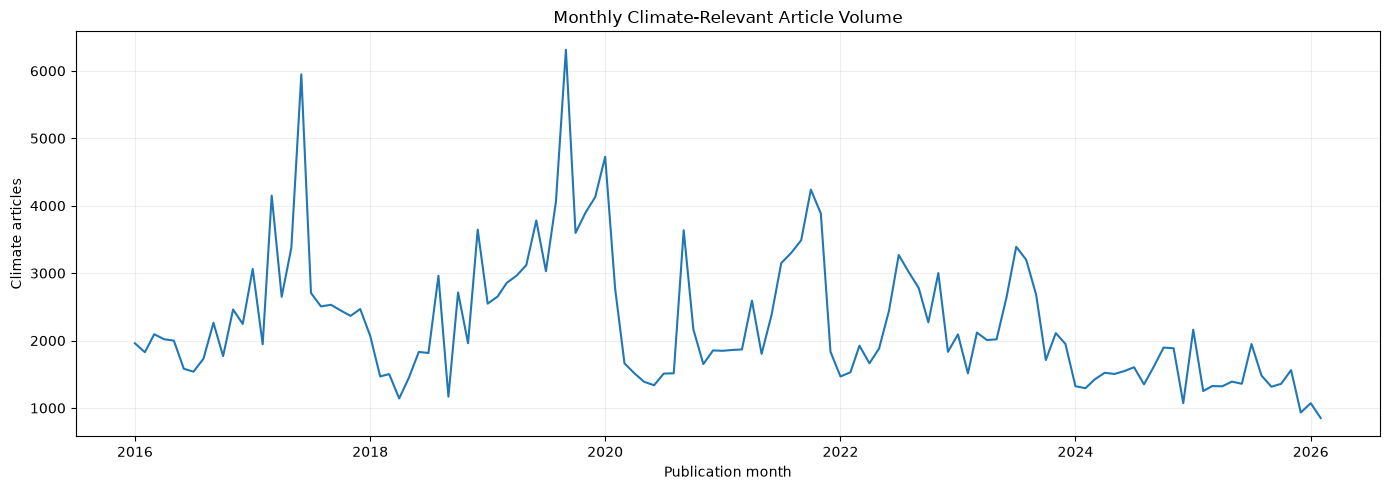

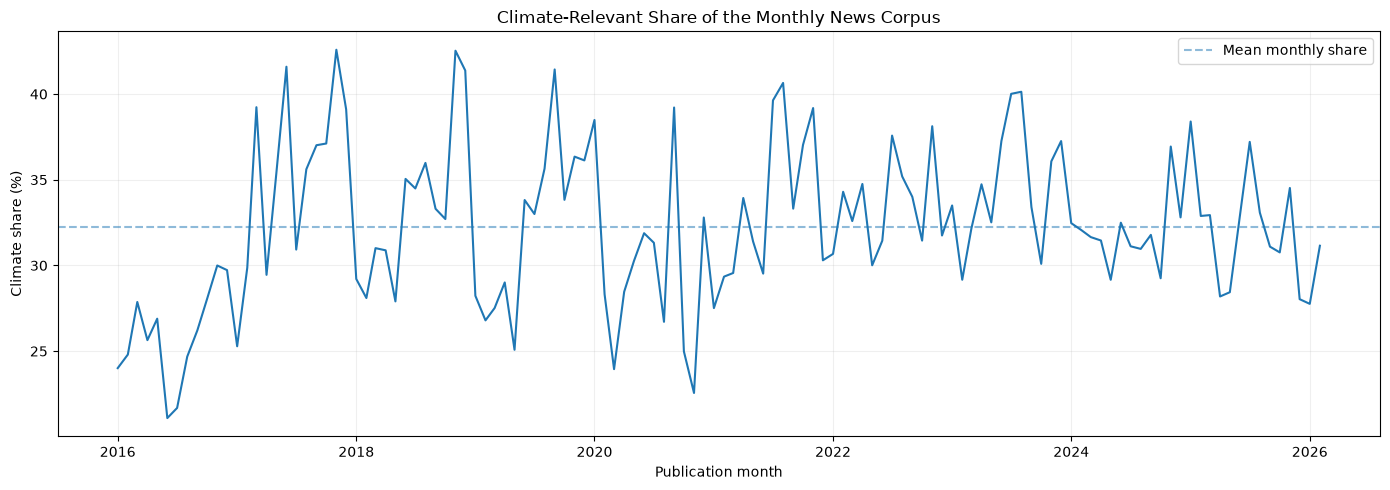


CLIMATE ARTICLES PER OUTLET-MONTH


,climate_articles
count,15903.00
mean,17.37
std,32.52
min,1.00
1%,1.00
5%,1.00
10%,1.00
25%,2.00
50%,7.00
75%,18.00



CLIMATE OUTLET-MONTH SAMPLE-SIZE BANDS


,outlet_months,pct
climate_articles_per_outlet_month,,
1,2505,15.75
2,1513,9.51
3–4,2009,12.63
5–9,3155,19.84
10–19,2934,18.45
20–49,2494,15.68
50–99,917,5.77
100+,376,2.36



CENTROID SAMPLE-SIZE THRESHOLD SENSITIVITY


,qualifying_outlet_months,pct_outlet_months_retained,unique_outlets_retained,median_outlets_per_month,min_outlets_in_any_month,max_outlets_in_any_month
min_climate_articles,,,,,,
1,15903,100.00,230,130.0,93,179
2,13398,84.25,211,108.0,74,162
3,11885,74.73,198,96.0,62,150
5,9876,62.10,175,80.0,46,133
10,6721,42.26,156,52.0,23,108
15,4918,30.92,139,36.0,17,92
20,3787,23.81,123,27.0,10,82
30,2475,15.56,100,16.0,6,62


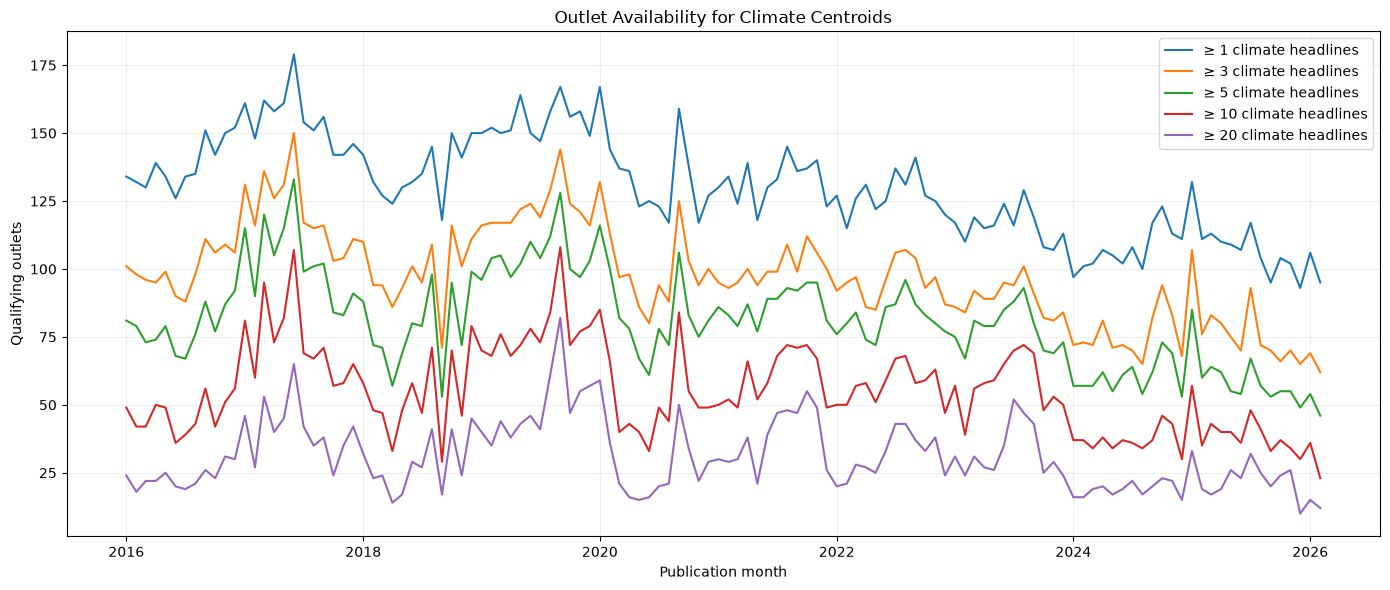


FULL-CORPUS SCORE SANITY CHECK


,score_band,title_nlp_candidate,media_name,year_month,climate_relevance_score,climate_best_anchor
34,high,Global carbon prices too low to combat climate...,reuters.com,2018-09,0.510451,climate_policy
38,high,Study: Global warming means smoggier autumns i...,sfgate.com,2016-08,0.458166,climate_science
33,high,Why climate change makes hurricanes like Ian w...,motherjones.com,2022-09,0.433604,climate_impacts
39,high,The Latest: Rallies focus on danger posed by c...,startribune.com,2017-04,0.433238,climate_science
37,high,"At summit, climate-change fight revs up",arkansasonline.com,2017-12,0.431997,climate_science
31,high,Climate and diet,miamiherald.com,2017-06,0.431871,climate_science
30,high,Scott Pruitt on Irma: Not time to talk climate...,cnn.com,2017-09,0.424299,climate_science
36,high,Washington state youth sue government over cli...,sfgate.com,2016-11,0.421898,climate_science
35,high,Climate change is making Texas hotter — and th...,alternet.org,2021-10,0.415882,climate_science
32,high,"Icon: We’ve Entered The Climate Decade, No Really",forbes.com,2021-05,0.413836,climate_science


In [40]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ---------------------------------------------------------
# Work from persisted semantic features
# ---------------------------------------------------------

climate_audit = semantic_features.copy()

# Ensure chronological month representation
climate_audit["year_month_period"] = pd.PeriodIndex(
    climate_audit["year_month"],
    freq="M"
)

TOTAL_NLP_ARTICLES = len(climate_audit)

# ---------------------------------------------------------
# 1. Classification threshold sensitivity
# ---------------------------------------------------------

candidate_relevance_thresholds = [
    0.20,
    0.22,
    0.24,
    0.26,
    0.28,
    0.30,
    0.32,
]

threshold_rows = []

for threshold in candidate_relevance_thresholds:

    subset = climate_audit[
        climate_audit["climate_relevance_score"]
        >= threshold
    ]

    outlet_month = (
        subset
        .groupby(
            ["media_name", "year_month_period"]
        )
        .size()
        .rename("articles")
        .reset_index()
    )

    monthly_outlets = (
        outlet_month
        .groupby("year_month_period")["media_name"]
        .nunique()
    )

    threshold_rows.append({
        "threshold": threshold,

        "articles":
            len(subset),

        "pct_of_nlp":
            len(subset)
            / TOTAL_NLP_ARTICLES
            * 100,

        "outlets":
            subset["media_name"].nunique(),

        "outlet_months":
            len(outlet_month),

        "median_articles_per_outlet_month":
            outlet_month["articles"].median(),

        "median_outlets_per_month":
            monthly_outlets.median(),

        "min_outlets_per_month":
            monthly_outlets.min(),

        "max_outlets_per_month":
            monthly_outlets.max(),
    })


relevance_threshold_summary = (
    pd.DataFrame(threshold_rows)
    .set_index("threshold")
)

print("=" * 75)
print("CLIMATE RELEVANCE THRESHOLD SENSITIVITY")
print("=" * 75)

display(
    relevance_threshold_summary.round(2)
)

# ---------------------------------------------------------
# 2. Final threshold corpus
# ---------------------------------------------------------

FINAL_THRESHOLD = 0.240

climate_final = (
    climate_audit[
        climate_audit["climate_relevance_score"]
        >= FINAL_THRESHOLD
    ]
    .copy()
)

print("\n" + "=" * 75)
print("FINAL CLIMATE CORPUS")
print("=" * 75)

print(
    f"Climate articles:       "
    f"{len(climate_final):,}"
)

print(
    f"Share of NLP corpus:    "
    f"{len(climate_final) / TOTAL_NLP_ARTICLES * 100:.2f}%"
)

print(
    f"Climate outlets:        "
    f"{climate_final['media_name'].nunique():,}"
)

missing_climate_outlets = sorted(
    set(df_nlp["media_name"].unique())
    - set(climate_final["media_name"].unique())
)

print(
    f"Outlets with no qualifying climate articles: "
    f"{len(missing_climate_outlets):,}"
)

if missing_climate_outlets:
    print(
        "Missing outlets:",
        ", ".join(missing_climate_outlets)
    )

# ---------------------------------------------------------
# 3. Monthly climate volume
# ---------------------------------------------------------

monthly_all = (
    climate_audit
    .groupby("year_month_period")
    .size()
    .rename("all_nlp_articles")
)

monthly_climate = (
    climate_final
    .groupby("year_month_period")
    .agg(
        climate_articles=("id", "size"),
        climate_outlets=("media_name", "nunique"),
    )
)

monthly_climate_summary = (
    pd.concat(
        [
            monthly_all,
            monthly_climate,
        ],
        axis=1,
    )
    .fillna(0)
)

monthly_climate_summary[
    "climate_share_pct"
] = (
    monthly_climate_summary["climate_articles"]
    / monthly_climate_summary["all_nlp_articles"]
    * 100
)

monthly_climate_summary["month"] = (
    monthly_climate_summary
    .index
    .to_timestamp()
)

print("\n" + "=" * 75)
print("MONTHLY CLIMATE COVERAGE")
print("=" * 75)

display(
    monthly_climate_summary[
        [
            "all_nlp_articles",
            "climate_articles",
            "climate_share_pct",
            "climate_outlets",
        ]
    ]
    .describe(
        percentiles=[
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
        ]
    )
    .round(2)
)

print("\nHighest climate-share months:")

display(
    monthly_climate_summary[
        [
            "all_nlp_articles",
            "climate_articles",
            "climate_share_pct",
            "climate_outlets",
        ]
    ]
    .sort_values(
        "climate_share_pct",
        ascending=False
    )
    .head(15)
    .round(2)
)

print("\nLowest climate-share months:")

display(
    monthly_climate_summary[
        [
            "all_nlp_articles",
            "climate_articles",
            "climate_share_pct",
            "climate_outlets",
        ]
    ]
    .sort_values(
        "climate_share_pct"
    )
    .head(15)
    .round(2)
)

# ---------------------------------------------------------
# Plot monthly climate article volume
# ---------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(14, 5)
)

ax.plot(
    monthly_climate_summary["month"],
    monthly_climate_summary["climate_articles"],
)

ax.set_title(
    "Monthly Climate-Relevant Article Volume"
)

ax.set_xlabel(
    "Publication month"
)

ax.set_ylabel(
    "Climate articles"
)

ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Plot climate share of monthly corpus
# ---------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(14, 5)
)

ax.plot(
    monthly_climate_summary["month"],
    monthly_climate_summary["climate_share_pct"],
)

ax.axhline(
    monthly_climate_summary[
        "climate_share_pct"
    ].mean(),
    linestyle="--",
    alpha=0.5,
    label="Mean monthly share",
)

ax.set_title(
    "Climate-Relevant Share of the Monthly News Corpus"
)

ax.set_xlabel(
    "Publication month"
)

ax.set_ylabel(
    "Climate share (%)"
)

ax.legend()

ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 4. Climate outlet-month sample sizes
# ---------------------------------------------------------

climate_outlet_month = (
    climate_final
    .groupby(
        [
            "media_name",
            "year_month_period",
        ]
    )
    .size()
    .rename("climate_articles")
    .reset_index()
)

print("\n" + "=" * 75)
print("CLIMATE ARTICLES PER OUTLET-MONTH")
print("=" * 75)

display(
    climate_outlet_month[
        "climate_articles"
    ]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
        ]
    )
    .to_frame("climate_articles")
    .round(2)
)

# ---------------------------------------------------------
# Sample-size bands
# ---------------------------------------------------------

climate_sample_bins = pd.cut(
    climate_outlet_month[
        "climate_articles"
    ],
    bins=[
        0,
        1,
        2,
        4,
        9,
        19,
        49,
        99,
        float("inf"),
    ],
    labels=[
        "1",
        "2",
        "3–4",
        "5–9",
        "10–19",
        "20–49",
        "50–99",
        "100+",
    ]
)

climate_sample_band_summary = (
    climate_sample_bins
    .value_counts(sort=False)
    .rename_axis(
        "climate_articles_per_outlet_month"
    )
    .to_frame(
        "outlet_months"
    )
)

climate_sample_band_summary["pct"] = (
    climate_sample_band_summary[
        "outlet_months"
    ]
    / len(climate_outlet_month)
    * 100
).round(2)

print("\n" + "=" * 75)
print("CLIMATE OUTLET-MONTH SAMPLE-SIZE BANDS")
print("=" * 75)

display(
    climate_sample_band_summary
)

# ---------------------------------------------------------
# 5. Candidate minimum sample requirements
# ---------------------------------------------------------

candidate_min_articles = [
    1,
    2,
    3,
    5,
    10,
    15,
    20,
    30,
]

minimum_rows = []

for min_articles in candidate_min_articles:

    qualifying = climate_outlet_month[
        climate_outlet_month[
            "climate_articles"
        ] >= min_articles
    ]

    qualifying_monthly = (
        qualifying
        .groupby(
            "year_month_period"
        )["media_name"]
        .nunique()
        .reindex(
            monthly_climate_summary.index,
            fill_value=0,
        )
    )

    minimum_rows.append({
        "min_climate_articles":
            min_articles,

        "qualifying_outlet_months":
            len(qualifying),

        "pct_outlet_months_retained":
            (
                len(qualifying)
                / len(climate_outlet_month)
                * 100
            ),

        "unique_outlets_retained":
            qualifying[
                "media_name"
            ].nunique(),

        "median_outlets_per_month":
            qualifying_monthly.median(),

        "min_outlets_in_any_month":
            qualifying_monthly.min(),

        "max_outlets_in_any_month":
            qualifying_monthly.max(),
    })


climate_minimum_summary = (
    pd.DataFrame(minimum_rows)
    .set_index(
        "min_climate_articles"
    )
)

print("\n" + "=" * 75)
print("CENTROID SAMPLE-SIZE THRESHOLD SENSITIVITY")
print("=" * 75)

display(
    climate_minimum_summary.round(2)
)

# ---------------------------------------------------------
# Plot qualifying outlets over time
# ---------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(14, 6)
)

for min_articles in [
    1,
    3,
    5,
    10,
    20,
]:

    qualifying = (
        climate_outlet_month[
            climate_outlet_month[
                "climate_articles"
            ] >= min_articles
        ]
        .groupby(
            "year_month_period"
        )["media_name"]
        .nunique()
        .reindex(
            monthly_climate_summary.index,
            fill_value=0,
        )
    )

    ax.plot(
        qualifying.index.to_timestamp(),
        qualifying.values,
        label=(
            f"≥ {min_articles} climate headlines"
        ),
    )

ax.set_title(
    "Outlet Availability for Climate Centroids"
)

ax.set_xlabel(
    "Publication month"
)

ax.set_ylabel(
    "Qualifying outlets"
)

ax.legend()

ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 6. Inspect full-corpus examples around threshold
#
# Not another labeling exercise — this is just a sanity check.
# ---------------------------------------------------------

inspection_ranges = [
    ("just_below", 0.225, 0.240),
    ("just_above", 0.240, 0.255),
    ("moderate",   0.280, 0.300),
    ("high",       0.400, 1.000),
]

inspection_parts = []

for label, lower, upper in inspection_ranges:

    band = climate_audit[
        (
            climate_audit[
                "climate_relevance_score"
            ] >= lower
        )
        &
        (
            climate_audit[
                "climate_relevance_score"
            ] < upper
        )
    ]

    if len(band) == 0:
        continue

    sample = band.sample(
        n=min(
            10,
            len(band),
        ),
        random_state=RANDOM_SEED,
    ).copy()

    sample["score_band"] = label

    inspection_parts.append(
        sample
    )


full_corpus_boundary_examples = (
    pd.concat(
        inspection_parts,
        ignore_index=True,
    )
)

print("\n" + "=" * 75)
print("FULL-CORPUS SCORE SANITY CHECK")
print("=" * 75)

display(
    full_corpus_boundary_examples[
        [
            "score_band",
            "title_nlp_candidate",
            "media_name",
            "year_month",
            "climate_relevance_score",
            "climate_best_anchor",
        ]
    ]
    .sort_values(
        [
            "score_band",
            "climate_relevance_score",
        ],
        ascending=[
            True,
            False,
        ],
    )
)

## 23. Empirical Outlet-Month Centroid Stability

Outlet-month semantic representations are constructed by averaging the embeddings of climate-relevant headlines published by an outlet during a month.

However, a centroid estimated from only a few headlines may be highly sensitive to individual stories.

Rather than selecting an arbitrary minimum article count, centroid reliability is evaluated empirically.

For outlet-months with at least 50 climate headlines:

1. the centroid using all available headlines is treated as the reference representation;
2. smaller samples of `n` headlines are repeatedly drawn;
3. each sample centroid is compared with the full-data centroid;
4. two non-overlapping samples of the same size are also compared with each other.

The second measure, replicate agreement, is particularly important because it does not rely on comparing a sample with a reference centroid that contains that same sample.

Candidate sample sizes are:

`1, 2, 3, 5, 7, 10, 15, 20`

The experiment is stratified across publication years so that high-volume periods do not dominate the stability assessment.

CENTROID STABILITY EXPERIMENT
Embedding matrix:          (850409, 384)
Candidate sample sizes:    [1, 2, 3, 5, 7, 10, 15, 20]
Repeated samples / group:  30
Reference minimum size:    50

Eligible high-volume outlet-months: 1,293
Reference groups sampled:  306
Years represented:         11

Reference group size distribution:


,climate_articles
count,306.00
mean,91.79
std,44.31
min,50.00
10%,55.00
25%,62.25
50%,77.00
75%,103.00
90%,150.50
max,341.00


Testing centroid stability: 100%|█| 306/306 [00:02<00:00



Saved raw experiment to:
/Users/lasya/Documents/projects/media-polarization-lab/data/processed/centroid_stability_experiment.parquet

CENTROID STABILITY BY SAMPLE SIZE


,reference_groups,recovery_median,recovery_p10,recovery_p25,replicate_median,replicate_p10,replicate_p25,recovery_ge_0_95_pct,replicate_ge_0_80_pct,replicate_ge_0_90_pct,replicate_ge_0_95_pct
sample_size,,,,,,,,,,,
1,306,0.5286,0.4194,0.4713,0.2574,0.1096,0.1757,0.0000,0.8497,0.7298,0.6863
2,306,0.6636,0.5781,0.6177,0.4212,0.2745,0.3426,0.0000,0.3486,0.0980,0.0763
3,306,0.7390,0.6675,0.7015,0.5267,0.3882,0.4547,0.0000,0.5556,0.0109,0.0000
5,306,0.8206,0.7696,0.7942,0.6530,0.5399,0.5963,0.0000,2.9521,0.0545,0.0000
7,306,0.8648,0.8255,0.8438,0.7240,0.6314,0.6785,0.0109,12.3094,0.1525,0.0000
10,306,0.9031,0.8742,0.8884,0.7905,0.7183,0.7550,0.7190,42.4946,1.1002,0.0218
15,306,0.9368,0.9162,0.9262,0.8497,0.7964,0.8227,19.2266,88.5185,8.3224,0.0980
20,306,0.9553,0.9394,0.9472,0.8829,0.8409,0.8625,66.7865,98.6275,28.3115,0.5229


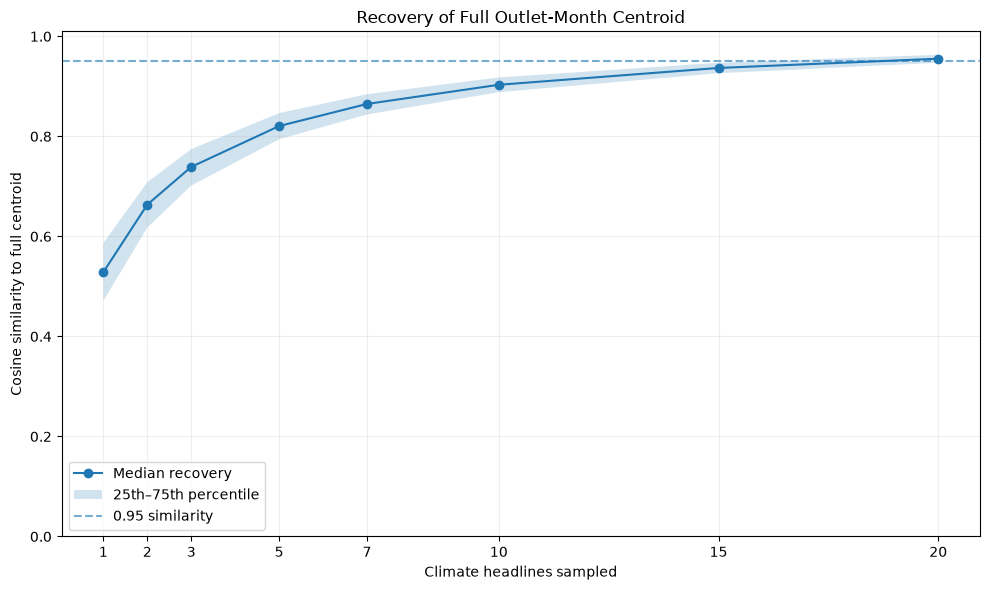

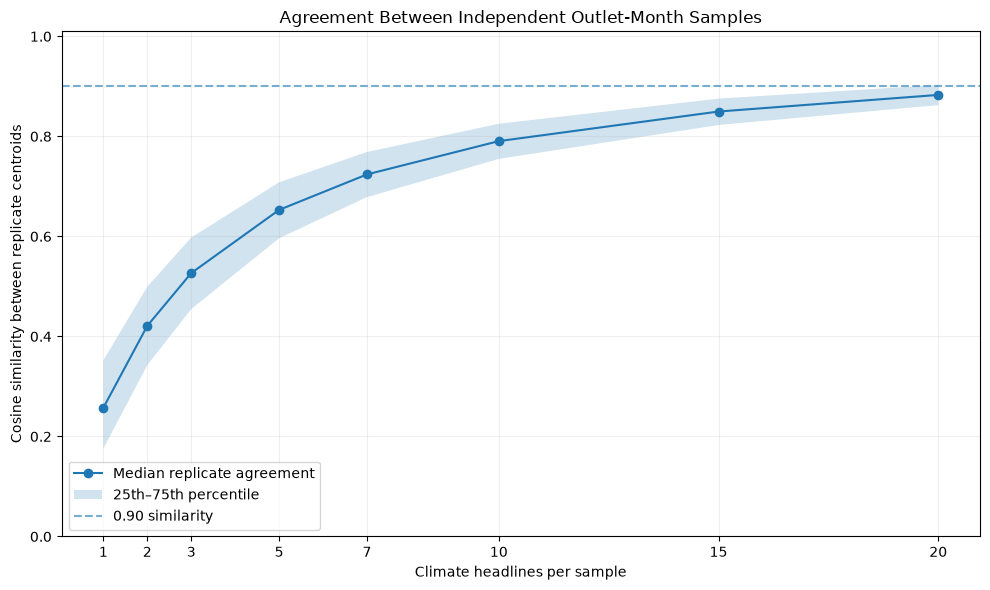

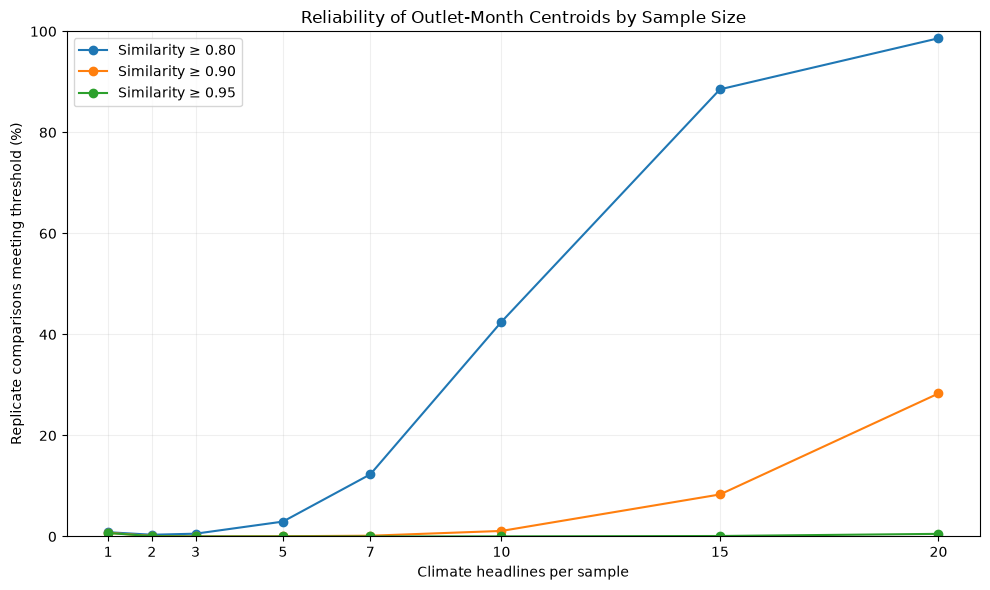

In [41]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm


# =========================================================
# CONFIGURATION
# =========================================================

STABILITY_SAMPLE_SIZES = [
    1,
    2,
    3,
    5,
    7,
    10,
    15,
    20,
]

STABILITY_REPEATS = 30

# Reference outlet-months must contain enough headlines
# that their full centroid is reasonably well estimated.
REFERENCE_MIN_ARTICLES = 50

# Prevent a few high-volume years from dominating.
MAX_REFERENCE_GROUPS_PER_YEAR = 30

STABILITY_RANDOM_SEED = 42


# =========================================================
# ENSURE EMBEDDING CACHE IS AVAILABLE
# =========================================================

if "embeddings_full" not in globals():

    embeddings_full = np.load(
        EMBEDDING_FILE,
        mmap_mode="r",
    )

print("=" * 75)
print("CENTROID STABILITY EXPERIMENT")
print("=" * 75)

print(
    f"Embedding matrix:          "
    f"{embeddings_full.shape}"
)

print(
    f"Candidate sample sizes:    "
    f"{STABILITY_SAMPLE_SIZES}"
)

print(
    f"Repeated samples / group:  "
    f"{STABILITY_REPEATS}"
)

print(
    f"Reference minimum size:    "
    f"{REFERENCE_MIN_ARTICLES}"
)


# =========================================================
# BUILD REFERENCE OUTLET-MONTH POOL
# =========================================================

reference_groups = (
    climate_outlet_month[
        climate_outlet_month[
            "climate_articles"
        ] >= REFERENCE_MIN_ARTICLES
    ]
    .copy()
)

reference_groups["year"] = (
    reference_groups[
        "year_month_period"
    ]
    .map(lambda x: x.year)
)

print(
    f"\nEligible high-volume "
    f"outlet-months: "
    f"{len(reference_groups):,}"
)


# ---------------------------------------------------------
# Stratified sample across years
# ---------------------------------------------------------

sampled_reference_parts = []

for year in sorted(
    reference_groups["year"].unique()
):

    year_groups = (
        reference_groups[
            reference_groups["year"] == year
        ]
    )

    n = min(
        MAX_REFERENCE_GROUPS_PER_YEAR,
        len(year_groups),
    )

    sampled_reference_parts.append(
        year_groups.sample(
            n=n,
            random_state=(
                STABILITY_RANDOM_SEED
                + int(year)
            ),
        )
    )


sampled_reference_groups = (
    pd.concat(
        sampled_reference_parts,
        ignore_index=True,
    )
)

print(
    f"Reference groups sampled:  "
    f"{len(sampled_reference_groups):,}"
)

print(
    f"Years represented:         "
    f"{sampled_reference_groups['year'].nunique():,}"
)


print("\nReference group size distribution:")

display(
    sampled_reference_groups[
        "climate_articles"
    ]
    .describe(
        percentiles=[
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
        ]
    )
    .to_frame(
        "climate_articles"
    )
    .round(2)
)


# =========================================================
# MAP EACH OUTLET-MONTH TO ITS EMBEDDING ROWS
# =========================================================

group_embedding_rows = (
    climate_final
    .groupby(
        [
            "media_name",
            "year_month_period",
        ]
    )[
        "embedding_row"
    ]
    .apply(
        lambda x: x.to_numpy(
            dtype=np.int64
        )
    )
    .to_dict()
)


# =========================================================
# HELPER
# =========================================================

def normalize_vector(vector):
    norm = np.linalg.norm(vector)

    if norm == 0:
        return vector

    return vector / norm


# =========================================================
# RUN SUBSAMPLING EXPERIMENT
# =========================================================

rng = np.random.default_rng(
    STABILITY_RANDOM_SEED
)

stability_rows = []


for group_row in tqdm(
    sampled_reference_groups.itertuples(
        index=False
    ),
    total=len(sampled_reference_groups),
    desc="Testing centroid stability",
):

    group_key = (
        group_row.media_name,
        group_row.year_month_period,
    )

    embedding_rows = (
        group_embedding_rows[
            group_key
        ]
    )

    # Load this outlet-month into memory once.
    group_vectors = np.asarray(
        embeddings_full[
            embedding_rows
        ],
        dtype=np.float32,
    )

    group_size = len(
        group_vectors
    )

    # Full-data reference centroid.
    full_centroid = normalize_vector(
        group_vectors.mean(
            axis=0
        )
    )

    # Norm before final normalization can be interpreted
    # as semantic concentration of the month's headlines.
    raw_full_centroid = (
        group_vectors.mean(
            axis=0
        )
    )

    centroid_concentration = (
        np.linalg.norm(
            raw_full_centroid
        )
    )

    for sample_size in (
        STABILITY_SAMPLE_SIZES
    ):

        # Need two non-overlapping samples.
        if (
            group_size
            < 2 * sample_size
        ):
            continue

        for repeat in range(
            STABILITY_REPEATS
        ):

            # Draw 2n unique headlines.
            sampled_idx = rng.choice(
                group_size,
                size=(
                    2
                    * sample_size
                ),
                replace=False,
            )

            sample_a_idx = (
                sampled_idx[
                    :sample_size
                ]
            )

            sample_b_idx = (
                sampled_idx[
                    sample_size:
                ]
            )

            centroid_a = (
                normalize_vector(
                    group_vectors[
                        sample_a_idx
                    ]
                    .mean(axis=0)
                )
            )

            centroid_b = (
                normalize_vector(
                    group_vectors[
                        sample_b_idx
                    ]
                    .mean(axis=0)
                )
            )

            # -------------------------------------------------
            # Metric 1:
            # subset vs full-data reference centroid
            # -------------------------------------------------

            recovery_a = float(
                np.dot(
                    centroid_a,
                    full_centroid,
                )
            )

            recovery_b = float(
                np.dot(
                    centroid_b,
                    full_centroid,
                )
            )

            mean_recovery = (
                recovery_a
                + recovery_b
            ) / 2

            # -------------------------------------------------
            # Metric 2:
            # independent replicate agreement
            # -------------------------------------------------

            replicate_similarity = float(
                np.dot(
                    centroid_a,
                    centroid_b,
                )
            )

            stability_rows.append({
                "media_name":
                    group_row.media_name,

                "year_month":
                    str(
                        group_row.year_month_period
                    ),

                "year":
                    group_row.year,

                "group_size":
                    group_size,

                "sample_size":
                    sample_size,

                "repeat":
                    repeat,

                "recovery_similarity":
                    mean_recovery,

                "replicate_similarity":
                    replicate_similarity,

                "full_centroid_concentration":
                    centroid_concentration,
            })


centroid_stability = pd.DataFrame(
    stability_rows
)


# =========================================================
# SAVE RAW EXPERIMENT
# =========================================================

CENTROID_STABILITY_FILE = (
    PROCESSED_DIR
    / "centroid_stability_experiment.parquet"
)

centroid_stability.to_parquet(
    CENTROID_STABILITY_FILE,
    index=False,
)

print(
    f"\nSaved raw experiment to:\n"
    f"{CENTROID_STABILITY_FILE.resolve()}"
)


# =========================================================
# SUMMARY BY SAMPLE SIZE
# =========================================================

def percentile_10(series):
    return series.quantile(0.10)


def percentile_25(series):
    return series.quantile(0.25)


def percentile_75(series):
    return series.quantile(0.75)


def percentile_90(series):
    return series.quantile(0.90)


stability_summary = (
    centroid_stability
    .groupby(
        "sample_size"
    )
    .agg(
        experiments=(
            "replicate_similarity",
            "size",
        ),

        groups=(
            "media_name",
            "size",
        ),

        recovery_median=(
            "recovery_similarity",
            "median",
        ),

        recovery_p10=(
            "recovery_similarity",
            percentile_10,
        ),

        recovery_p25=(
            "recovery_similarity",
            percentile_25,
        ),

        recovery_p75=(
            "recovery_similarity",
            percentile_75,
        ),

        replicate_median=(
            "replicate_similarity",
            "median",
        ),

        replicate_p10=(
            "replicate_similarity",
            percentile_10,
        ),

        replicate_p25=(
            "replicate_similarity",
            percentile_25,
        ),

        replicate_p75=(
            "replicate_similarity",
            percentile_75,
        ),
    )
)


# Number of distinct outlet-month groups
groups_per_n = (
    centroid_stability
    .groupby(
        "sample_size"
    )
    .apply(
        lambda x:
            x[
                [
                    "media_name",
                    "year_month",
                ]
            ]
            .drop_duplicates()
            .shape[0],
        include_groups=False,
    )
)

stability_summary[
    "reference_groups"
] = groups_per_n


# =========================================================
# RELIABILITY RATES
# =========================================================

reliability_rows = []

for sample_size, group in (
    centroid_stability.groupby(
        "sample_size"
    )
):

    reliability_rows.append({
        "sample_size":
            sample_size,

        "recovery_ge_0_90_pct":
            (
                group[
                    "recovery_similarity"
                ]
                .ge(0.90)
                .mean()
                * 100
            ),

        "recovery_ge_0_95_pct":
            (
                group[
                    "recovery_similarity"
                ]
                .ge(0.95)
                .mean()
                * 100
            ),

        "replicate_ge_0_80_pct":
            (
                group[
                    "replicate_similarity"
                ]
                .ge(0.80)
                .mean()
                * 100
            ),

        "replicate_ge_0_90_pct":
            (
                group[
                    "replicate_similarity"
                ]
                .ge(0.90)
                .mean()
                * 100
            ),

        "replicate_ge_0_95_pct":
            (
                group[
                    "replicate_similarity"
                ]
                .ge(0.95)
                .mean()
                * 100
            ),
    })


reliability_summary = (
    pd.DataFrame(
        reliability_rows
    )
    .set_index(
        "sample_size"
    )
)


stability_summary = (
    stability_summary
    .join(
        reliability_summary
    )
)


# =========================================================
# DISPLAY
# =========================================================

print("\n" + "=" * 75)
print("CENTROID STABILITY BY SAMPLE SIZE")
print("=" * 75)

display(
    stability_summary[
        [
            "reference_groups",

            "recovery_median",
            "recovery_p10",
            "recovery_p25",

            "replicate_median",
            "replicate_p10",
            "replicate_p25",

            "recovery_ge_0_95_pct",
            "replicate_ge_0_80_pct",
            "replicate_ge_0_90_pct",
            "replicate_ge_0_95_pct",
        ]
    ]
    .round(4)
)


# =========================================================
# PLOT 1 — CENTROID RECOVERY
# =========================================================

plot_summary = (
    stability_summary
    .reset_index()
)

fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.plot(
    plot_summary[
        "sample_size"
    ],
    plot_summary[
        "recovery_median"
    ],
    marker="o",
    label="Median recovery",
)

ax.fill_between(
    plot_summary[
        "sample_size"
    ],
    plot_summary[
        "recovery_p25"
    ],
    plot_summary[
        "recovery_p75"
    ],
    alpha=0.2,
    label="25th–75th percentile",
)

ax.axhline(
    0.95,
    linestyle="--",
    alpha=0.6,
    label="0.95 similarity",
)

ax.set_title(
    "Recovery of Full Outlet-Month Centroid"
)

ax.set_xlabel(
    "Climate headlines sampled"
)

ax.set_ylabel(
    "Cosine similarity to full centroid"
)

ax.set_xticks(
    STABILITY_SAMPLE_SIZES
)

ax.set_ylim(
    0,
    1.01,
)

ax.legend()

ax.grid(
    alpha=0.2
)

plt.tight_layout()
plt.show()


# =========================================================
# PLOT 2 — INDEPENDENT REPLICATE AGREEMENT
# =========================================================

fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.plot(
    plot_summary[
        "sample_size"
    ],
    plot_summary[
        "replicate_median"
    ],
    marker="o",
    label="Median replicate agreement",
)

ax.fill_between(
    plot_summary[
        "sample_size"
    ],
    plot_summary[
        "replicate_p25"
    ],
    plot_summary[
        "replicate_p75"
    ],
    alpha=0.2,
    label="25th–75th percentile",
)

ax.axhline(
    0.90,
    linestyle="--",
    alpha=0.6,
    label="0.90 similarity",
)

ax.set_title(
    "Agreement Between Independent Outlet-Month Samples"
)

ax.set_xlabel(
    "Climate headlines per sample"
)

ax.set_ylabel(
    "Cosine similarity between replicate centroids"
)

ax.set_xticks(
    STABILITY_SAMPLE_SIZES
)

ax.set_ylim(
    0,
    1.01,
)

ax.legend()

ax.grid(
    alpha=0.2
)

plt.tight_layout()
plt.show()


# =========================================================
# PLOT 3 — SHARE OF RELIABLE REPLICATES
# =========================================================

fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.plot(
    reliability_summary.index,
    reliability_summary[
        "replicate_ge_0_80_pct"
    ],
    marker="o",
    label="Similarity ≥ 0.80",
)

ax.plot(
    reliability_summary.index,
    reliability_summary[
        "replicate_ge_0_90_pct"
    ],
    marker="o",
    label="Similarity ≥ 0.90",
)

ax.plot(
    reliability_summary.index,
    reliability_summary[
        "replicate_ge_0_95_pct"
    ],
    marker="o",
    label="Similarity ≥ 0.95",
)

ax.set_title(
    "Reliability of Outlet-Month Centroids by Sample Size"
)

ax.set_xlabel(
    "Climate headlines per sample"
)

ax.set_ylabel(
    "Replicate comparisons meeting threshold (%)"
)

ax.set_xticks(
    STABILITY_SAMPLE_SIZES
)

ax.set_ylim(
    0,
    100,
)

ax.legend()

ax.grid(
    alpha=0.2
)

plt.tight_layout()
plt.show()

## 24. Temporal Pooling and Rolling Centroid Stability

The monthly centroid experiment shows that climate coverage within an outlet-month is semantically heterogeneous.

Even with twenty sampled headlines, independent centroid estimates do not consistently reach high agreement.

This suggests that a single calendar month may be too narrow a unit for estimating a stable outlet-level semantic position.

To reduce sampling noise while preserving temporal resolution, three trailing semantic windows are evaluated:

- 1 month
- 3 months
- 6 months

For each target month, only the current and preceding months are used. Future data are never included.

The analysis evaluates:

- article volume available per outlet-window
- outlet coverage under alternative minimum sample requirements
- split-half centroid agreement
- stability across article-count bands
- the tradeoff between temporal resolution and semantic reliability

The goal is to select the shortest window that produces sufficiently stable semantic representations while retaining broad outlet coverage.

ROLLING SEMANTIC WINDOW EXPERIMENT
Climate articles:      276,233
Climate outlets:       230
Study months:          122
Windows tested:        [1, 3, 6]


Building rolling windows: 100%|█| 3/3 [00:00<00:00,  6.3


Rolling outlet-window groups: 55,355

ARTICLE AVAILABILITY BY WINDOW


,outlet_windows,unique_outlets,median_articles,mean_articles,p25_articles,p75_articles,p90_articles
window_months,,,,,,,
1,15903,230,7.0,17.37,2.0,18.0,42.0
3,18848,230,16.0,43.82,4.0,46.0,109.0
6,20604,230,27.0,79.67,5.0,83.0,200.0



ROLLING WINDOW COVERAGE


...

Testing rolling stability: 100%|█| 825/825 [00:01<00:00,


Saved:
/Users/lasya/Documents/projects/media-polarization-lab/data/processed/rolling_centroid_stability.parquet

ROLLING CENTROID STABILITY


,comparisons,median_articles,median_half_size,replicate_median,replicate_p10,replicate_p25,replicate_p75,recovery_median,recovery_p10,replicate_ge_0_80_pct,replicate_ge_0_90_pct,replicate_ge_0_95_pct
window_months,,,,,,,,,,,,
1,5500,33.0,16.0,0.8751,0.7839,0.8278,0.9162,0.9678,0.9433,85.3455,34.4364,9.8909
3,5500,48.0,24.0,0.9057,0.8027,0.8580,0.9482,0.9758,0.9481,90.3636,53.1818,23.8182
6,5500,71.0,35.0,0.9363,0.8401,0.8877,0.9691,0.9838,0.9581,96.5273,69.5818,41.1273



STABILITY BY ARTICLE-COUNT BAND


comparisons  median_articles  \
window_months article_count_band                                 
1             20–29                      1980             24.0   
              30–49                      1840             34.5   
              50–74                      1020             64.0   
              75–99                       240             92.0   
              100–149                     200            118.5   
              150+                        220            178.0   
3             20–29                      1560             24.0   
              30–49                      1240             39.0   
              50–74                       860             63.0   
              75–99                       480             87.0   
              100–149                     560            118.5   
              150+                        800            206.5   
6             20–29                       900             24.0   
              30–49                       980             36.0   
              50–74                       960             59.0   
              75–99                       440             87.0   
              100–149                     660            115.0   
              150+                       1560            243.5   

                                  replicate_median  replicate_p10  \
window_months article_count_band                                    
1             20–29                         0.8178         0.7492   
              30–49                         0.8742         0.8226   
              50–74                         0.9165         0.8834   
              75–99                         0.9465         0.9276   
              100–149                       0.9633         0.9506   
              150+                          0.9700         0.9572   
3             20–29                         0.8292         0.7520   
              30–49                         0.8807         0.8369   
              50–74                         0.9204         0.8923   
              75–99                         0.9400         0.9198   
              100–149                       0.9547         0.9376   
              150+                          0.9744         0.9605   
6             20–29                         0.8435         0.7785   
              30–49                         0.8851         0.8332   
              50–74                         0.9237         0.8920   
              75–99                         0.9473         0.9258   
              100–149                       0.9559         0.9391   
              150+                          0.9789         0.9661   

                                  replicate_p25  
window_months article_count_band                 
1             20–29                      0.7822  
              30–49                      0.8476  
              50–74                      0.9007  
              75–99                      0.9364  
              100–149                    0.9564  
              150+                       0.9638  
3             20–29                      0.7878  
              30–49                      0.8591  
              50–74                      0.9053  
              75–99                      0.9294  
              100–149                    0.9454  
              150+                       0.9675  
6             20–29                      0.8110  
              30–49                      0.8586  
              50–74                      0.9075  
              75–99                      0.9365  
              100–149                    0.9481  
              150+                       0.9723

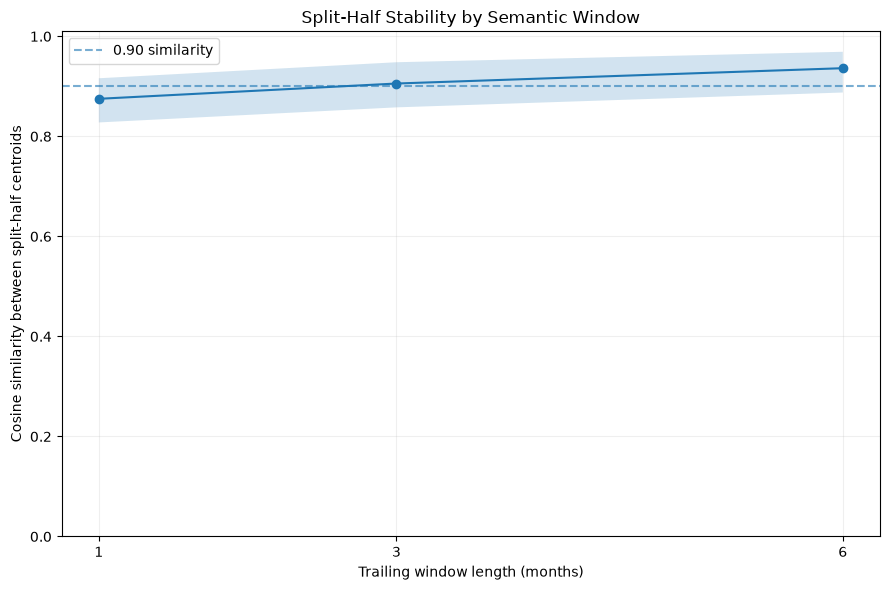

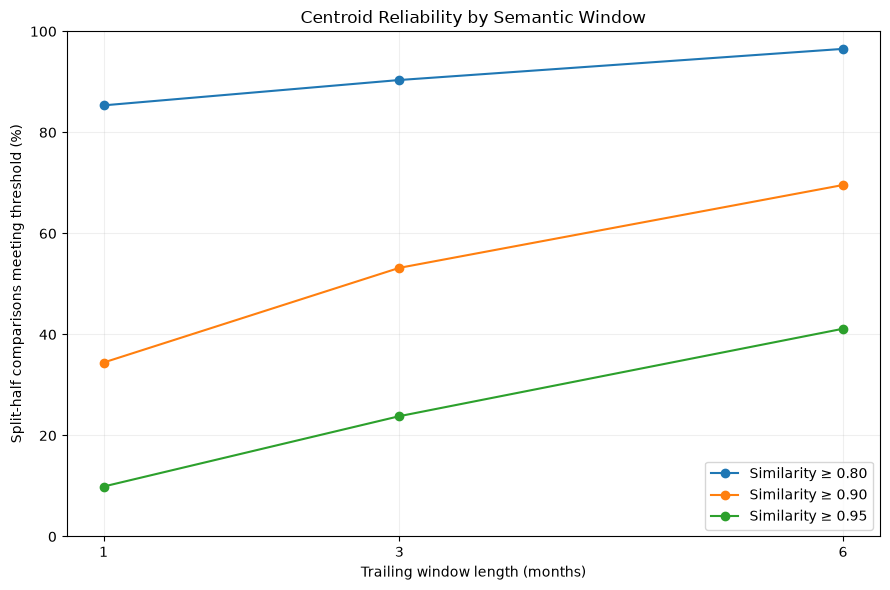

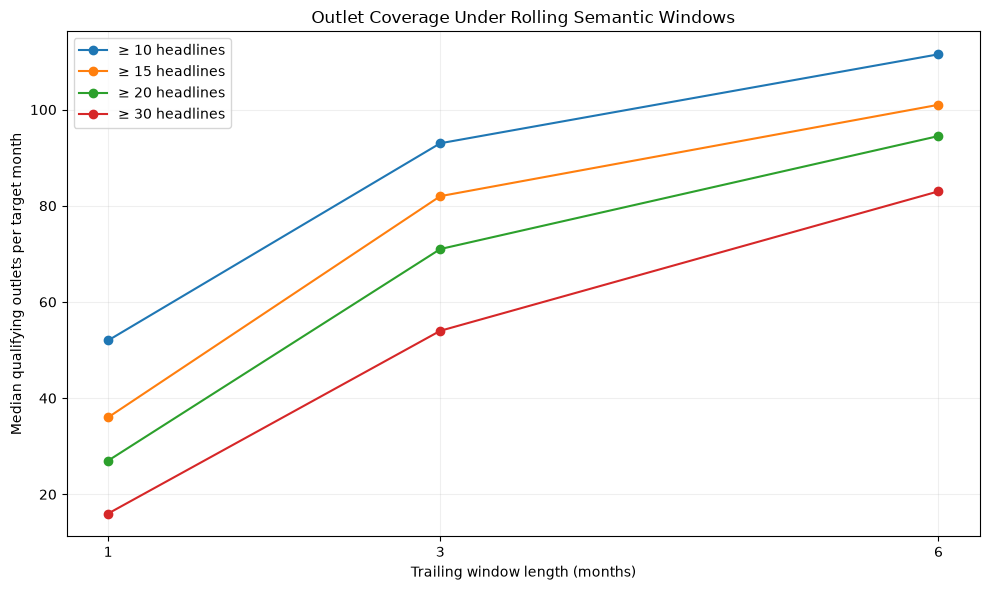

In [42]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm


# =========================================================
# CONFIGURATION
# =========================================================

ROLLING_WINDOWS = [1, 3, 6]

ROLLING_MIN_COUNTS = [
    5,
    10,
    15,
    20,
    30,
    50,
]

ROLLING_STABILITY_REPEATS = 20

# Need enough total articles to split meaningfully.
ROLLING_STABILITY_MIN_ARTICLES = 20

# Prevent high-volume periods from dominating.
MAX_STABILITY_GROUPS_PER_YEAR = 25

ROLLING_RANDOM_SEED = 42


# =========================================================
# ENSURE EMBEDDINGS AVAILABLE
# =========================================================

if "embeddings_full" not in globals():
    embeddings_full = np.load(
        EMBEDDING_FILE,
        mmap_mode="r",
    )


# =========================================================
# MONTH RANGE
# =========================================================

all_months = pd.period_range(
    start=climate_final["year_month_period"].min(),
    end=climate_final["year_month_period"].max(),
    freq="M",
)

all_outlets = sorted(
    climate_final["media_name"].unique()
)

print("=" * 75)
print("ROLLING SEMANTIC WINDOW EXPERIMENT")
print("=" * 75)

print(
    f"Climate articles:      "
    f"{len(climate_final):,}"
)

print(
    f"Climate outlets:       "
    f"{len(all_outlets):,}"
)

print(
    f"Study months:          "
    f"{len(all_months):,}"
)

print(
    f"Windows tested:        "
    f"{ROLLING_WINDOWS}"
)


# =========================================================
# MAP OUTLET-MONTH -> EMBEDDING ROWS
# =========================================================

monthly_embedding_rows = (
    climate_final
    .groupby(
        [
            "media_name",
            "year_month_period",
        ]
    )["embedding_row"]
    .apply(
        lambda x: x.to_numpy(
            dtype=np.int64
        )
    )
    .to_dict()
)


# =========================================================
# BUILD ALL OUTLET / TARGET-MONTH / WINDOW GROUPS
# =========================================================

rolling_group_rows = []

rolling_embedding_rows = {}


for window_size in tqdm(
    ROLLING_WINDOWS,
    desc="Building rolling windows",
):

    for outlet in all_outlets:

        for target_month in all_months:

            months_in_window = [
                target_month - offset
                for offset in range(
                    window_size
                )
            ]

            row_parts = []

            observed_months = 0

            for month in months_in_window:

                rows = monthly_embedding_rows.get(
                    (
                        outlet,
                        month,
                    )
                )

                if rows is not None:
                    row_parts.append(
                        rows
                    )

                    observed_months += 1

            if not row_parts:
                continue

            embedding_rows = np.concatenate(
                row_parts
            )

            key = (
                window_size,
                outlet,
                target_month,
            )

            rolling_embedding_rows[key] = (
                embedding_rows
            )

            rolling_group_rows.append({
                "window_months":
                    window_size,

                "media_name":
                    outlet,

                "target_month":
                    target_month,

                "year":
                    target_month.year,

                "article_count":
                    len(
                        embedding_rows
                    ),

                "observed_months":
                    observed_months,
            })


rolling_groups = pd.DataFrame(
    rolling_group_rows
)


print(
    f"\nRolling outlet-window groups: "
    f"{len(rolling_groups):,}"
)


# =========================================================
# BASIC VOLUME SUMMARY
# =========================================================

rolling_volume_summary = (
    rolling_groups
    .groupby(
        "window_months"
    )
    .agg(
        outlet_windows=(
            "article_count",
            "size",
        ),

        unique_outlets=(
            "media_name",
            "nunique",
        ),

        median_articles=(
            "article_count",
            "median",
        ),

        mean_articles=(
            "article_count",
            "mean",
        ),

        p25_articles=(
            "article_count",
            lambda x:
                x.quantile(0.25),
        ),

        p75_articles=(
            "article_count",
            lambda x:
                x.quantile(0.75),
        ),

        p90_articles=(
            "article_count",
            lambda x:
                x.quantile(0.90),
        ),
    )
)


print("\n" + "=" * 75)
print("ARTICLE AVAILABILITY BY WINDOW")
print("=" * 75)

display(
    rolling_volume_summary.round(2)
)


# =========================================================
# COVERAGE UNDER MINIMUM SAMPLE REQUIREMENTS
# =========================================================

coverage_rows = []


for window_size in ROLLING_WINDOWS:

    window_groups = rolling_groups[
        rolling_groups[
            "window_months"
        ] == window_size
    ]

    for min_articles in (
        ROLLING_MIN_COUNTS
    ):

        qualifying = window_groups[
            window_groups[
                "article_count"
            ] >= min_articles
        ]

        monthly_outlets = (
            qualifying
            .groupby(
                "target_month"
            )["media_name"]
            .nunique()
            .reindex(
                all_months,
                fill_value=0,
            )
        )

        coverage_rows.append({
            "window_months":
                window_size,

            "min_articles":
                min_articles,

            "qualifying_outlet_windows":
                len(
                    qualifying
                ),

            "pct_windows_retained":
                (
                    len(qualifying)
                    / len(window_groups)
                    * 100
                ),

            "unique_outlets":
                qualifying[
                    "media_name"
                ].nunique(),

            "median_outlets_per_month":
                monthly_outlets.median(),

            "min_outlets_per_month":
                monthly_outlets.min(),

            "max_outlets_per_month":
                monthly_outlets.max(),
        })


rolling_coverage_summary = (
    pd.DataFrame(
        coverage_rows
    )
)


print("\n" + "=" * 75)
print("ROLLING WINDOW COVERAGE")
print("=" * 75)

display(
    rolling_coverage_summary
    .set_index(
        [
            "window_months",
            "min_articles",
        ]
    )
    .round(2)
)


# =========================================================
# SELECT GROUPS FOR SPLIT-HALF STABILITY TEST
# =========================================================

eligible_stability_groups = (
    rolling_groups[
        rolling_groups[
            "article_count"
        ] >= ROLLING_STABILITY_MIN_ARTICLES
    ]
    .copy()
)


sampled_parts = []


for window_size in ROLLING_WINDOWS:

    window_groups = (
        eligible_stability_groups[
            eligible_stability_groups[
                "window_months"
            ] == window_size
        ]
    )

    for year in sorted(
        window_groups["year"].unique()
    ):

        year_groups = (
            window_groups[
                window_groups["year"]
                == year
            ]
        )

        n = min(
            MAX_STABILITY_GROUPS_PER_YEAR,
            len(
                year_groups
            ),
        )

        if n == 0:
            continue

        sampled_parts.append(
            year_groups.sample(
                n=n,
                random_state=(
                    ROLLING_RANDOM_SEED
                    + window_size * 100
                    + int(year)
                ),
            )
        )


rolling_stability_groups = (
    pd.concat(
        sampled_parts,
        ignore_index=True,
    )
)


print("\n" + "=" * 75)
print("ROLLING STABILITY SAMPLE")
print("=" * 75)

display(
    rolling_stability_groups
    .groupby(
        "window_months"
    )
    .agg(
        groups=(
            "article_count",
            "size",
        ),

        median_articles=(
            "article_count",
            "median",
        ),

        p25_articles=(
            "article_count",
            lambda x:
                x.quantile(0.25),
        ),

        p75_articles=(
            "article_count",
            lambda x:
                x.quantile(0.75),
        ),
    )
    .round(2)
)


# =========================================================
# HELPER
# =========================================================

def normalize_centroid(vector):

    norm = np.linalg.norm(
        vector
    )

    if norm == 0:
        return vector

    return (
        vector
        / norm
    )


# =========================================================
# SPLIT-HALF STABILITY
#
# Randomly divide the AVAILABLE headlines in each
# outlet-window into two independent halves.
#
# This is conservative:
# each replicate uses only roughly half of the data that
# the final production centroid will actually use.
# =========================================================

rolling_stability_rows = []

rng = np.random.default_rng(
    ROLLING_RANDOM_SEED
)


for row in tqdm(
    rolling_stability_groups.itertuples(
        index=False
    ),
    total=len(
        rolling_stability_groups
    ),
    desc="Testing rolling stability",
):

    key = (
        row.window_months,
        row.media_name,
        row.target_month,
    )

    embedding_rows = (
        rolling_embedding_rows[
            key
        ]
    )

    vectors = np.asarray(
        embeddings_full[
            embedding_rows
        ],
        dtype=np.float32,
    )

    total_articles = len(
        vectors
    )

    # Equal halves.
    half_size = (
        total_articles
        // 2
    )

    if half_size < 2:
        continue

    # Full centroid for recovery diagnostic.
    full_centroid = (
        normalize_centroid(
            vectors.mean(
                axis=0
            )
        )
    )

    for repeat in range(
        ROLLING_STABILITY_REPEATS
    ):

        permutation = rng.permutation(
            total_articles
        )

        idx_a = permutation[
            :half_size
        ]

        idx_b = permutation[
            half_size:
            half_size * 2
        ]

        centroid_a = (
            normalize_centroid(
                vectors[
                    idx_a
                ].mean(
                    axis=0
                )
            )
        )

        centroid_b = (
            normalize_centroid(
                vectors[
                    idx_b
                ].mean(
                    axis=0
                )
            )
        )

        replicate_similarity = float(
            np.dot(
                centroid_a,
                centroid_b,
            )
        )

        recovery_similarity = (
            (
                float(
                    np.dot(
                        centroid_a,
                        full_centroid,
                    )
                )
                +
                float(
                    np.dot(
                        centroid_b,
                        full_centroid,
                    )
                )
            )
            / 2
        )

        rolling_stability_rows.append({
            "window_months":
                row.window_months,

            "media_name":
                row.media_name,

            "target_month":
                str(
                    row.target_month
                ),

            "year":
                row.year,

            "article_count":
                total_articles,

            "half_sample_size":
                half_size,

            "repeat":
                repeat,

            "replicate_similarity":
                replicate_similarity,

            "recovery_similarity":
                recovery_similarity,
        })


rolling_stability = pd.DataFrame(
    rolling_stability_rows
)


# =========================================================
# SAVE EXPERIMENT
# =========================================================

ROLLING_STABILITY_FILE = (
    PROCESSED_DIR
    / "rolling_centroid_stability.parquet"
)

rolling_stability.to_parquet(
    ROLLING_STABILITY_FILE,
    index=False,
)

print(
    f"\nSaved:\n"
    f"{ROLLING_STABILITY_FILE.resolve()}"
)


# =========================================================
# SUMMARY BY WINDOW
# =========================================================

rolling_stability_summary = (
    rolling_stability
    .groupby(
        "window_months"
    )
    .agg(
        comparisons=(
            "replicate_similarity",
            "size",
        ),

        median_articles=(
            "article_count",
            "median",
        ),

        median_half_size=(
            "half_sample_size",
            "median",
        ),

        replicate_median=(
            "replicate_similarity",
            "median",
        ),

        replicate_p10=(
            "replicate_similarity",
            lambda x:
                x.quantile(0.10),
        ),

        replicate_p25=(
            "replicate_similarity",
            lambda x:
                x.quantile(0.25),
        ),

        replicate_p75=(
            "replicate_similarity",
            lambda x:
                x.quantile(0.75),
        ),

        recovery_median=(
            "recovery_similarity",
            "median",
        ),

        recovery_p10=(
            "recovery_similarity",
            lambda x:
                x.quantile(0.10),
        ),
    )
)


rolling_stability_summary[
    "replicate_ge_0_80_pct"
] = (
    rolling_stability
    .assign(
        passed=lambda x:
            x[
                "replicate_similarity"
            ] >= 0.80
    )
    .groupby(
        "window_months"
    )["passed"]
    .mean()
    * 100
)


rolling_stability_summary[
    "replicate_ge_0_90_pct"
] = (
    rolling_stability
    .assign(
        passed=lambda x:
            x[
                "replicate_similarity"
            ] >= 0.90
    )
    .groupby(
        "window_months"
    )["passed"]
    .mean()
    * 100
)


rolling_stability_summary[
    "replicate_ge_0_95_pct"
] = (
    rolling_stability
    .assign(
        passed=lambda x:
            x[
                "replicate_similarity"
            ] >= 0.95
    )
    .groupby(
        "window_months"
    )["passed"]
    .mean()
    * 100
)


print("\n" + "=" * 75)
print("ROLLING CENTROID STABILITY")
print("=" * 75)

display(
    rolling_stability_summary
    .round(4)
)


# =========================================================
# ARTICLE-COUNT BANDS
# =========================================================

rolling_stability[
    "article_count_band"
] = pd.cut(
    rolling_stability[
        "article_count"
    ],
    bins=[
        19,
        29,
        49,
        74,
        99,
        149,
        float("inf"),
    ],
    labels=[
        "20–29",
        "30–49",
        "50–74",
        "75–99",
        "100–149",
        "150+",
    ],
)


stability_by_count_band = (
    rolling_stability
    .groupby(
        [
            "window_months",
            "article_count_band",
        ],
        observed=True,
    )
    .agg(
        comparisons=(
            "replicate_similarity",
            "size",
        ),

        median_articles=(
            "article_count",
            "median",
        ),

        replicate_median=(
            "replicate_similarity",
            "median",
        ),

        replicate_p10=(
            "replicate_similarity",
            lambda x:
                x.quantile(0.10),
        ),

        replicate_p25=(
            "replicate_similarity",
            lambda x:
                x.quantile(0.25),
        ),
    )
)


print("\n" + "=" * 75)
print("STABILITY BY ARTICLE-COUNT BAND")
print("=" * 75)

display(
    stability_by_count_band.round(4)
)


# =========================================================
# PLOT 1 — MEDIAN SPLIT-HALF STABILITY
# =========================================================

plot_df = (
    rolling_stability_summary
    .reset_index()
)

fig, ax = plt.subplots(
    figsize=(9, 6)
)

ax.plot(
    plot_df[
        "window_months"
    ],
    plot_df[
        "replicate_median"
    ],
    marker="o",
)

ax.fill_between(
    plot_df[
        "window_months"
    ],
    plot_df[
        "replicate_p25"
    ],
    plot_df[
        "replicate_p75"
    ],
    alpha=0.2,
)

ax.axhline(
    0.90,
    linestyle="--",
    alpha=0.6,
    label="0.90 similarity",
)

ax.set_title(
    "Split-Half Stability by Semantic Window"
)

ax.set_xlabel(
    "Trailing window length (months)"
)

ax.set_ylabel(
    "Cosine similarity between split-half centroids"
)

ax.set_xticks(
    ROLLING_WINDOWS
)

ax.set_ylim(
    0,
    1.01,
)

ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()


# =========================================================
# PLOT 2 — RELIABLE COMPARISONS
# =========================================================

fig, ax = plt.subplots(
    figsize=(9, 6)
)

ax.plot(
    plot_df[
        "window_months"
    ],
    plot_df[
        "replicate_ge_0_80_pct"
    ],
    marker="o",
    label="Similarity ≥ 0.80",
)

ax.plot(
    plot_df[
        "window_months"
    ],
    plot_df[
        "replicate_ge_0_90_pct"
    ],
    marker="o",
    label="Similarity ≥ 0.90",
)

ax.plot(
    plot_df[
        "window_months"
    ],
    plot_df[
        "replicate_ge_0_95_pct"
    ],
    marker="o",
    label="Similarity ≥ 0.95",
)

ax.set_title(
    "Centroid Reliability by Semantic Window"
)

ax.set_xlabel(
    "Trailing window length (months)"
)

ax.set_ylabel(
    "Split-half comparisons meeting threshold (%)"
)

ax.set_xticks(
    ROLLING_WINDOWS
)

ax.set_ylim(
    0,
    100,
)

ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()


# =========================================================
# PLOT 3 — COVERAGE AT PRACTICAL THRESHOLDS
# =========================================================

fig, ax = plt.subplots(
    figsize=(10, 6)
)

for min_articles in [
    10,
    15,
    20,
    30,
]:

    temp = (
        rolling_coverage_summary[
            rolling_coverage_summary[
                "min_articles"
            ] == min_articles
        ]
    )

    ax.plot(
        temp[
            "window_months"
        ],
        temp[
            "median_outlets_per_month"
        ],
        marker="o",
        label=(
            f"≥ {min_articles} headlines"
        ),
    )

ax.set_title(
    "Outlet Coverage Under Rolling Semantic Windows"
)

ax.set_xlabel(
    "Trailing window length (months)"
)

ax.set_ylabel(
    "Median qualifying outlets per target month"
)

ax.set_xticks(
    ROLLING_WINDOWS
)

ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## 25. Freshness of Rolling Semantic Representations

A six-month trailing window substantially improves centroid stability and outlet coverage.

However, a rolling representation can remain available even when an outlet publishes no climate-relevant headlines in the target month. Such observations may represent stale semantic positions rather than current editorial behavior.

Before constructing the final centroid dataset, qualifying six-month windows are therefore audited for:

- climate articles published in the target month
- overall outlet activity in the target month
- time since the most recent climate-relevant headline
- coverage effects of alternative freshness requirements

This determines whether production centroids should require contemporary climate coverage in addition to sufficient six-month sample size.

ROLLING CENTROID FRESHNESS AUDIT
Qualifying 6-month windows: 7,587

CURRENT-MONTH FRESHNESS
Windows with >=1 climate article in target month:
7,506 (98.93%)

Windows with zero climate articles in target month:
81 (1.07%)

Zero-climate windows where outlet was still active in the NLP corpus:
24

TARGET-MONTH CLIMATE ARTICLE DISTRIBUTION


,current_month_climate_articles
count,7587.00
mean,31.99
std,42.35
min,0.00
10%,7.00
25%,11.00
50%,19.00
75%,36.00
90%,70.00
95%,99.00



MONTHS SINCE MOST RECENT CLIMATE COVERAGE


,outlet_windows,pct
months_since_recent_climate,,
0,7506,98.93
1,41,0.54
2,22,0.29
3,13,0.17
4,4,0.05
5,1,0.01



FRESHNESS REQUIREMENT SENSITIVITY


,qualifying_windows,pct_of_6m50_windows,unique_outlets,median_outlets_per_month,min_outlets_per_month,max_outlets_per_month
min_current_month_climate_articles,,,,,,
0,7587,100.00,136,63.0,7,98
1,7506,98.93,136,61.0,7,95
3,7394,97.46,136,60.5,7,95
5,7182,94.66,136,59.5,7,95
10,6089,80.26,133,48.5,7,92



EXAMPLE HIGH-VOLUME BUT STALE WINDOWS


,media_name,target_month,article_count,current_month_climate_articles,current_month_nlp_articles,months_since_recent_climate
7269,usnews.com,2020-04,588,0,0,1
6718,thestreet.com,2022-03,463,0,10,1
7270,usnews.com,2020-05,457,0,0,2
5817,seattletimes.com,2024-08,342,0,0,1
7271,usnews.com,2020-06,295,0,0,3
5818,seattletimes.com,2024-09,272,0,0,2
3029,ledger-enquirer.com,2020-04,239,0,0,1
7198,usatoday.com,2023-10,227,0,0,1
7527,washingtonpost.com,2024-04,222,0,0,1
579,bloomberg.com,2020-11,208,0,0,1


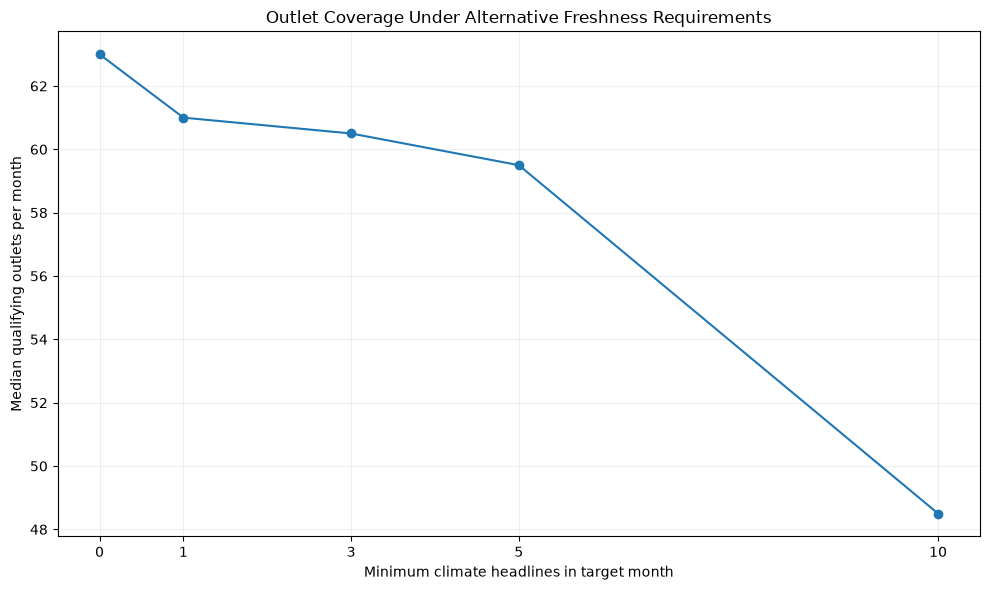

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =========================================================
# FINAL PROVISIONAL CONFIGURATION
# =========================================================

FINAL_WINDOW_MONTHS = 6
FINAL_MIN_CLIMATE_ARTICLES = 50


# =========================================================
# START WITH QUALIFYING 6-MONTH WINDOWS
# =========================================================

freshness_audit = (
    rolling_groups[
        (rolling_groups["window_months"] == FINAL_WINDOW_MONTHS)
        &
        (
            rolling_groups["article_count"]
            >= FINAL_MIN_CLIMATE_ARTICLES
        )
    ]
    .copy()
    .reset_index(drop=True)
)

print("=" * 75)
print("ROLLING CENTROID FRESHNESS AUDIT")
print("=" * 75)

print(
    f"Qualifying 6-month windows: "
    f"{len(freshness_audit):,}"
)


# =========================================================
# CURRENT-MONTH CLIMATE ARTICLE COUNTS
# =========================================================

monthly_climate_count_map = (
    climate_final
    .groupby(
        [
            "media_name",
            "year_month_period",
        ]
    )
    .size()
    .to_dict()
)

freshness_audit[
    "current_month_climate_articles"
] = [
    monthly_climate_count_map.get(
        (
            outlet,
            month,
        ),
        0,
    )
    for outlet, month in zip(
        freshness_audit["media_name"],
        freshness_audit["target_month"],
    )
]


# =========================================================
# CURRENT-MONTH ALL-NLP ARTICLE COUNTS
#
# This distinguishes:
#
# "outlet was active but had no climate headlines"
#
# from:
#
# "outlet appears absent from the source data this month"
# =========================================================

nlp_monthly_counts = (
    df_nlp
    .assign(
        year_month_period=pd.to_datetime(
            df_nlp["publish_date"],
            utc=True,
        )
        .dt.tz_convert(None)
        .dt.to_period("M")
    )
    .groupby(
        [
            "media_name",
            "year_month_period",
        ]
    )
    .size()
    .to_dict()
)

freshness_audit[
    "current_month_nlp_articles"
] = [
    nlp_monthly_counts.get(
        (
            outlet,
            month,
        ),
        0,
    )
    for outlet, month in zip(
        freshness_audit["media_name"],
        freshness_audit["target_month"],
    )
]

freshness_audit[
    "outlet_active_current_month"
] = (
    freshness_audit[
        "current_month_nlp_articles"
    ] > 0
)


# =========================================================
# MONTHS SINCE MOST RECENT CLIMATE HEADLINE
# =========================================================

def months_since_recent_climate(
    outlet,
    target_month,
    window_months=6,
):

    for offset in range(
        window_months
    ):

        month = (
            target_month
            - offset
        )

        count = (
            monthly_climate_count_map.get(
                (
                    outlet,
                    month,
                ),
                0,
            )
        )

        if count > 0:
            return offset

    return np.nan


freshness_audit[
    "months_since_recent_climate"
] = [
    months_since_recent_climate(
        outlet,
        month,
        FINAL_WINDOW_MONTHS,
    )
    for outlet, month in zip(
        freshness_audit["media_name"],
        freshness_audit["target_month"],
    )
]


# =========================================================
# SUMMARY
# =========================================================

print("\n" + "=" * 75)
print("CURRENT-MONTH FRESHNESS")
print("=" * 75)

print(
    "Windows with >=1 climate article "
    "in target month:"
)

has_one = (
    freshness_audit[
        "current_month_climate_articles"
    ] >= 1
)

print(
    f"{has_one.sum():,} "
    f"({has_one.mean() * 100:.2f}%)"
)

print(
    "\nWindows with zero climate articles "
    "in target month:"
)

has_zero = (
    freshness_audit[
        "current_month_climate_articles"
    ] == 0
)

print(
    f"{has_zero.sum():,} "
    f"({has_zero.mean() * 100:.2f}%)"
)

print(
    "\nZero-climate windows where outlet "
    "was still active in the NLP corpus:"
)

zero_but_active = (
    has_zero
    &
    freshness_audit[
        "outlet_active_current_month"
    ]
)

print(
    f"{zero_but_active.sum():,}"
)


# =========================================================
# CURRENT-MONTH CLIMATE COUNT DISTRIBUTION
# =========================================================

print("\n" + "=" * 75)
print("TARGET-MONTH CLIMATE ARTICLE DISTRIBUTION")
print("=" * 75)

display(
    freshness_audit[
        "current_month_climate_articles"
    ]
    .describe(
        percentiles=[
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
        ]
    )
    .to_frame(
        "current_month_climate_articles"
    )
    .round(2)
)


# =========================================================
# RECENCY DISTRIBUTION
# =========================================================

print("\n" + "=" * 75)
print("MONTHS SINCE MOST RECENT CLIMATE COVERAGE")
print("=" * 75)

recency_summary = (
    freshness_audit[
        "months_since_recent_climate"
    ]
    .value_counts()
    .sort_index()
    .rename_axis(
        "months_since_recent_climate"
    )
    .to_frame(
        "outlet_windows"
    )
)

recency_summary[
    "pct"
] = (
    recency_summary[
        "outlet_windows"
    ]
    / len(freshness_audit)
    * 100
)

display(
    recency_summary.round(2)
)


# =========================================================
# FRESHNESS REQUIREMENT SENSITIVITY
# =========================================================

freshness_rules = [
    0,
    1,
    3,
    5,
    10,
]

freshness_rows = []

for min_current_articles in freshness_rules:

    qualifying = (
        freshness_audit[
            freshness_audit[
                "current_month_climate_articles"
            ] >= min_current_articles
        ]
    )

    monthly_outlets = (
        qualifying
        .groupby(
            "target_month"
        )[
            "media_name"
        ]
        .nunique()
        .reindex(
            all_months,
            fill_value=0,
        )
    )

    freshness_rows.append({
        "min_current_month_climate_articles":
            min_current_articles,

        "qualifying_windows":
            len(
                qualifying
            ),

        "pct_of_6m50_windows":
            (
                len(qualifying)
                / len(freshness_audit)
                * 100
            ),

        "unique_outlets":
            qualifying[
                "media_name"
            ].nunique(),

        "median_outlets_per_month":
            monthly_outlets.median(),

        "min_outlets_per_month":
            monthly_outlets.min(),

        "max_outlets_per_month":
            monthly_outlets.max(),
    })


freshness_rule_summary = (
    pd.DataFrame(
        freshness_rows
    )
    .set_index(
        "min_current_month_climate_articles"
    )
)


print("\n" + "=" * 75)
print("FRESHNESS REQUIREMENT SENSITIVITY")
print("=" * 75)

display(
    freshness_rule_summary.round(2)
)


# =========================================================
# EXAMPLES OF POTENTIALLY STALE WINDOWS
# =========================================================

stale_examples = (
    freshness_audit[
        freshness_audit[
            "current_month_climate_articles"
        ] == 0
    ]
    .sort_values(
        [
            "article_count",
            "months_since_recent_climate",
        ],
        ascending=[
            False,
            False,
        ],
    )
    .head(30)
)


print("\n" + "=" * 75)
print("EXAMPLE HIGH-VOLUME BUT STALE WINDOWS")
print("=" * 75)

display(
    stale_examples[
        [
            "media_name",
            "target_month",
            "article_count",
            "current_month_climate_articles",
            "current_month_nlp_articles",
            "months_since_recent_climate",
        ]
    ]
)


# =========================================================
# COVERAGE PLOT
# =========================================================

fig, ax = plt.subplots(
    figsize=(10, 6)
)

temp = (
    freshness_rule_summary
    .reset_index()
)

ax.plot(
    temp[
        "min_current_month_climate_articles"
    ],
    temp[
        "median_outlets_per_month"
    ],
    marker="o",
)

ax.set_title(
    "Outlet Coverage Under Alternative Freshness Requirements"
)

ax.set_xlabel(
    "Minimum climate headlines in target month"
)

ax.set_ylabel(
    "Median qualifying outlets per month"
)

ax.set_xticks(
    freshness_rules
)

ax.grid(
    alpha=0.2
)

plt.tight_layout()
plt.show()

## 26. Production Outlet-Month Semantic Centroids

The empirical validation stages establish the final semantic representation used by the project.

### Final configuration

**Climate relevance**

- Sentence Transformer: `all-MiniLM-L6-v2`
- 384-dimensional normalized headline embeddings
- six climate semantic anchors
- relevance score: mean of the two strongest anchor similarities
- climate threshold: `0.240`

**Outlet-month representation**

Each observation corresponds to an outlet in a target calendar month.

Its semantic position is estimated using climate-relevant headlines from the trailing six-month window ending in that month.

A representation is retained only when:

- at least `50` climate-relevant headlines occur in the six-month window, and
- at least `1` climate-relevant headline occurs in the target month.

The article embeddings are averaged and the resulting centroid is normalized to unit length.

This produces a dynamic monthly panel: outlets appear only during months for which sufficient and sufficiently recent evidence exists.

In [44]:
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json

import numpy as np
import pandas as pd
from tqdm.auto import tqdm


# =========================================================
# FINAL LOCKED CONFIGURATION
# =========================================================

FINAL_WINDOW_MONTHS = 6
FINAL_MIN_WINDOW_ARTICLES = 50
FINAL_MIN_CURRENT_MONTH_ARTICLES = 1

FINAL_CLIMATE_THRESHOLD = 0.240
FINAL_EMBEDDING_DIM = 384


# =========================================================
# OUTPUT FILES
# =========================================================

CENTROID_VECTOR_FILE = (
    PROCESSED_DIR
    / "outlet_month_centroids.npy"
)

CENTROID_METADATA_FILE = (
    PROCESSED_DIR
    / "outlet_month_centroid_metadata.parquet"
)

CENTROID_COVERAGE_FILE = (
    PROCESSED_DIR
    / "outlet_centroid_coverage.parquet"
)

CENTROID_MANIFEST_FILE = (
    PROCESSED_DIR
    / "centroid_pipeline_manifest.json"
)


# =========================================================
# LOAD EMBEDDING CACHE IF NECESSARY
# =========================================================

if "embeddings_full" not in globals():

    embeddings_full = np.load(
        EMBEDDING_FILE,
        mmap_mode="r",
    )


print("=" * 75)
print("PRODUCTION OUTLET-MONTH CENTROID PIPELINE")
print("=" * 75)

print(
    f"Climate threshold:           "
    f"{FINAL_CLIMATE_THRESHOLD:.3f}"
)

print(
    f"Trailing window:             "
    f"{FINAL_WINDOW_MONTHS} months"
)

print(
    f"Minimum window headlines:    "
    f"{FINAL_MIN_WINDOW_ARTICLES}"
)

print(
    f"Minimum current headlines:   "
    f"{FINAL_MIN_CURRENT_MONTH_ARTICLES}"
)

print(
    f"Embedding dimension:         "
    f"{FINAL_EMBEDDING_DIM}"
)


# =========================================================
# CLIMATE DATA
# =========================================================

production_climate = (
    climate_final
    .copy()
)

production_climate[
    "year_month_period"
] = pd.PeriodIndex(
    production_climate[
        "year_month"
    ],
    freq="M",
)


# =========================================================
# MONTHLY ARTICLE COUNTS
# =========================================================

monthly_climate_counts = (
    production_climate
    .groupby(
        [
            "media_name",
            "year_month_period",
        ]
    )
    .size()
    .rename(
        "current_month_climate_articles"
    )
    .reset_index()
)


# =========================================================
# MONTHLY EMBEDDING SUMS
#
# Important:
# Rather than repeatedly reading the same article embeddings
# for every overlapping six-month window, first calculate the
# vector SUM for every outlet-month.
#
# Six-month centroids can then be formed by summing six
# outlet-month vectors.
# =========================================================

monthly_vector_sums = {}

monthly_metadata_rows = []


grouped_months = (
    production_climate
    .groupby(
        [
            "media_name",
            "year_month_period",
        ],
        sort=True,
    )
)


print(
    f"\nBuilding monthly semantic aggregates "
    f"for {grouped_months.ngroups:,} outlet-months..."
)


for (
    outlet,
    month
), group in tqdm(
    grouped_months,
    total=grouped_months.ngroups,
    desc="Monthly aggregates",
):

    rows = (
        group[
            "embedding_row"
        ]
        .to_numpy(
            dtype=np.int64
        )
    )

    vectors = np.asarray(
        embeddings_full[
            rows
        ],
        dtype=np.float32,
    )

    vector_sum = (
        vectors
        .sum(
            axis=0,
            dtype=np.float64,
        )
    )

    key = (
        outlet,
        month,
    )

    monthly_vector_sums[
        key
    ] = vector_sum

    # -----------------------------------------------------
    # Useful metadata for later analysis / web app
    # -----------------------------------------------------

    anchor_counts = (
        group[
            "climate_best_anchor"
        ]
        .value_counts()
    )

    dominant_anchor = (
        anchor_counts.index[0]
        if len(anchor_counts)
        else None
    )

    monthly_metadata_rows.append({
        "media_name":
            outlet,

        "year_month_period":
            month,

        "climate_articles":
            len(group),

        "mean_climate_relevance":
            group[
                "climate_relevance_score"
            ].mean(),

        "median_climate_relevance":
            group[
                "climate_relevance_score"
            ].median(),

        "dominant_climate_anchor":
            dominant_anchor,
    })


monthly_semantic_metadata = (
    pd.DataFrame(
        monthly_metadata_rows
    )
)


# =========================================================
# BUILD FINAL SIX-MONTH WINDOWS
# =========================================================

all_months = pd.period_range(
    start=production_climate[
        "year_month_period"
    ].min(),

    end=production_climate[
        "year_month_period"
    ].max(),

    freq="M",
)

all_outlets = sorted(
    production_climate[
        "media_name"
    ].unique()
)


centroid_vectors = []

centroid_metadata_rows = []


print(
    "\nConstructing production centroids..."
)


for outlet in tqdm(
    all_outlets,
    desc="Outlets",
):

    for target_month in all_months:

        # -------------------------------------------------
        # Freshness:
        # target month itself must contain climate coverage.
        # -------------------------------------------------

        current_key = (
            outlet,
            target_month,
        )

        current_count = (
            monthly_climate_counts
            .loc[
                (
                    monthly_climate_counts[
                        "media_name"
                    ] == outlet
                )
                &
                (
                    monthly_climate_counts[
                        "year_month_period"
                    ] == target_month
                ),
                "current_month_climate_articles",
            ]
        )

        current_count = (
            int(
                current_count.iloc[0]
            )
            if len(current_count)
            else 0
        )

        if (
            current_count
            < FINAL_MIN_CURRENT_MONTH_ARTICLES
        ):
            continue


        # -------------------------------------------------
        # Trailing six calendar months
        # -------------------------------------------------

        months_in_window = [
            target_month - offset
            for offset in range(
                FINAL_WINDOW_MONTHS
            )
        ]


        vector_sum = np.zeros(
            FINAL_EMBEDDING_DIM,
            dtype=np.float64,
        )

        window_article_count = 0

        observed_months = 0

        relevance_values = []

        anchor_values = []


        for month in months_in_window:

            key = (
                outlet,
                month,
            )

            if key not in monthly_vector_sums:
                continue

            vector_sum += (
                monthly_vector_sums[
                    key
                ]
            )

            month_meta = (
                monthly_semantic_metadata[
                    (
                        monthly_semantic_metadata[
                            "media_name"
                        ] == outlet
                    )
                    &
                    (
                        monthly_semantic_metadata[
                            "year_month_period"
                        ] == month
                    )
                ]
            )

            month_count = int(
                month_meta[
                    "climate_articles"
                ].iloc[0]
            )

            window_article_count += (
                month_count
            )

            observed_months += 1


        # -------------------------------------------------
        # Minimum evidence requirement
        # -------------------------------------------------

        if (
            window_article_count
            < FINAL_MIN_WINDOW_ARTICLES
        ):
            continue


        # -------------------------------------------------
        # Raw average centroid
        # -------------------------------------------------

        raw_centroid = (
            vector_sum
            / window_article_count
        )

        # Norm before final normalization.
        #
        # Higher values mean the article embeddings are
        # more semantically concentrated.
        centroid_concentration = float(
            np.linalg.norm(
                raw_centroid
            )
        )

        if centroid_concentration == 0:
            continue


        # -------------------------------------------------
        # Unit-normalized production centroid
        # -------------------------------------------------

        centroid = (
            raw_centroid
            / centroid_concentration
        ).astype(
            np.float32
        )

        centroid_row = len(
            centroid_vectors
        )

        centroid_vectors.append(
            centroid
        )


        # -------------------------------------------------
        # Recover article-level rows for window metadata
        # -------------------------------------------------

        window_mask = (
            (
                production_climate[
                    "media_name"
                ] == outlet
            )
            &
            (
                production_climate[
                    "year_month_period"
                ].isin(
                    months_in_window
                )
            )
        )

        window_articles = (
            production_climate[
                window_mask
            ]
        )


        # -------------------------------------------------
        # Window-level relevance statistics
        # -------------------------------------------------

        mean_relevance = float(
            window_articles[
                "climate_relevance_score"
            ].mean()
        )

        median_relevance = float(
            window_articles[
                "climate_relevance_score"
            ].median()
        )


        # -------------------------------------------------
        # Climate anchor composition
        # -------------------------------------------------

        anchor_counts = (
            window_articles[
                "climate_best_anchor"
            ]
            .value_counts()
        )

        dominant_anchor = (
            anchor_counts.index[0]
            if len(anchor_counts)
            else None
        )


        # -------------------------------------------------
        # Metadata row
        # -------------------------------------------------

        centroid_metadata_rows.append({
            "centroid_row":
                centroid_row,

            "media_name":
                outlet,

            "target_month":
                str(
                    target_month
                ),

            "target_year":
                int(
                    target_month.year
                ),

            "target_month_number":
                int(
                    target_month.month
                ),

            "window_start":
                str(
                    target_month
                    - (
                        FINAL_WINDOW_MONTHS
                        - 1
                    )
                ),

            "window_end":
                str(
                    target_month
                ),

            "window_months":
                FINAL_WINDOW_MONTHS,

            "window_climate_articles":
                int(
                    window_article_count
                ),

            "current_month_climate_articles":
                int(
                    current_count
                ),

            "observed_months_in_window":
                int(
                    observed_months
                ),

            "centroid_concentration":
                centroid_concentration,

            "mean_climate_relevance":
                mean_relevance,

            "median_climate_relevance":
                median_relevance,

            "dominant_climate_anchor":
                dominant_anchor,
        })


# =========================================================
# FINAL MATRICES
# =========================================================

centroid_matrix = np.vstack(
    centroid_vectors
).astype(
    np.float32
)

centroid_metadata = pd.DataFrame(
    centroid_metadata_rows
)


print("\n" + "=" * 75)
print("PRODUCTION CENTROID MATRIX")
print("=" * 75)

print(
    f"Centroid matrix shape: "
    f"{centroid_matrix.shape}"
)

print(
    f"Metadata rows:         "
    f"{len(centroid_metadata):,}"
)

print(
    f"Unique outlets:        "
    f"{centroid_metadata['media_name'].nunique():,}"
)

print(
    f"First target month:    "
    f"{centroid_metadata['target_month'].min()}"
)

print(
    f"Last target month:     "
    f"{centroid_metadata['target_month'].max()}"
)


# =========================================================
# VALIDATE UNIT NORMS
# =========================================================

centroid_norms = np.linalg.norm(
    centroid_matrix,
    axis=1,
)

print(
    f"\nMinimum centroid norm: "
    f"{centroid_norms.min():.6f}"
)

print(
    f"Mean centroid norm:    "
    f"{centroid_norms.mean():.6f}"
)

print(
    f"Maximum centroid norm: "
    f"{centroid_norms.max():.6f}"
)

if not np.allclose(
    centroid_norms,
    1.0,
    atol=1e-5,
):
    raise ValueError(
        "Production centroids are not unit normalized."
    )


# =========================================================
# ENSURE UNIQUE OUTLET × TARGET MONTH
# =========================================================

duplicate_centroids = (
    centroid_metadata
    .duplicated(
        subset=[
            "media_name",
            "target_month",
        ]
    )
    .sum()
)

print(
    f"Duplicate outlet-month rows: "
    f"{duplicate_centroids:,}"
)

if duplicate_centroids:
    raise ValueError(
        "Duplicate production outlet-month centroids found."
    )


# =========================================================
# SAVE VECTORS
# =========================================================

np.save(
    CENTROID_VECTOR_FILE,
    centroid_matrix,
)


# =========================================================
# SAVE METADATA
# =========================================================

centroid_metadata.to_parquet(
    CENTROID_METADATA_FILE,
    index=False,
)


# =========================================================
# OUTLET COVERAGE TABLE
# =========================================================

total_study_months = len(
    all_months
)


outlet_coverage = (
    centroid_metadata
    .groupby(
        "media_name"
    )
    .agg(
        centroid_months=(
            "target_month",
            "nunique",
        ),

        first_centroid_month=(
            "target_month",
            "min",
        ),

        last_centroid_month=(
            "target_month",
            "max",
        ),

        total_window_articles=(
            "window_climate_articles",
            "sum",
        ),

        median_window_articles=(
            "window_climate_articles",
            "median",
        ),

        median_current_month_articles=(
            "current_month_climate_articles",
            "median",
        ),

        median_centroid_concentration=(
            "centroid_concentration",
            "median",
        ),
    )
)


outlet_coverage[
    "study_coverage_pct"
] = (
    outlet_coverage[
        "centroid_months"
    ]
    / total_study_months
    * 100
)


# ---------------------------------------------------------
# Continuity within the outlet's own centroid lifespan
# ---------------------------------------------------------

def month_distance(
    start_month,
    end_month,
):

    start = pd.Period(
        start_month,
        freq="M",
    )

    end = pd.Period(
        end_month,
        freq="M",
    )

    return (
        (
            end.year
            - start.year
        )
        * 12
        +
        (
            end.month
            - start.month
        )
        + 1
    )


outlet_coverage[
    "possible_months_between_first_last"
] = [
    month_distance(
        first,
        last,
    )
    for first, last in zip(
        outlet_coverage[
            "first_centroid_month"
        ],
        outlet_coverage[
            "last_centroid_month"
        ],
    )
]


outlet_coverage[
    "within_lifespan_continuity_pct"
] = (
    outlet_coverage[
        "centroid_months"
    ]
    / outlet_coverage[
        "possible_months_between_first_last"
    ]
    * 100
)


outlet_coverage.to_parquet(
    CENTROID_COVERAGE_FILE
)


# =========================================================
# VECTOR / METADATA FINGERPRINT
# =========================================================

centroid_hash = hashlib.sha256()

for row in centroid_metadata.itertuples(
    index=False
):

    centroid_hash.update(
        (
            f"{row.centroid_row}|"
            f"{row.media_name}|"
            f"{row.target_month}\n"
        )
        .encode(
            "utf-8"
        )
    )

CENTROID_INDEX_SHA256 = (
    centroid_hash.hexdigest()
)


# =========================================================
# MANIFEST
# =========================================================

centroid_manifest = {
    "created_at_utc":
        datetime.now(
            timezone.utc
        ).isoformat(),

    "embedding_model":
        FINAL_MODEL_NAME,

    "embedding_dimension":
        FINAL_EMBEDDING_DIM,

    "headline_embedding_normalized":
        True,

    "climate_method":
        FINAL_CLIMATE_METHOD,

    "climate_threshold":
        FINAL_CLIMATE_THRESHOLD,

    "rolling_window_months":
        FINAL_WINDOW_MONTHS,

    "minimum_window_climate_articles":
        FINAL_MIN_WINDOW_ARTICLES,

    "minimum_current_month_climate_articles":
        FINAL_MIN_CURRENT_MONTH_ARTICLES,

    "centroid_method":
        (
            "mean of normalized headline embeddings, "
            "followed by L2 normalization"
        ),

    "n_centroids":
        int(
            len(
                centroid_metadata
            )
        ),

    "n_outlets":
        int(
            centroid_metadata[
                "media_name"
            ].nunique()
        ),

    "first_target_month":
        centroid_metadata[
            "target_month"
        ].min(),

    "last_target_month":
        centroid_metadata[
            "target_month"
        ].max(),

    "centroid_index_sha256":
        CENTROID_INDEX_SHA256,

    "centroid_vector_file":
        str(
            CENTROID_VECTOR_FILE
        ),

    "centroid_metadata_file":
        str(
            CENTROID_METADATA_FILE
        ),

    "coverage_file":
        str(
            CENTROID_COVERAGE_FILE
        ),
}


with open(
    CENTROID_MANIFEST_FILE,
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        centroid_manifest,
        f,
        indent=2,
    )


# =========================================================
# OUTPUT SUMMARY
# =========================================================

print("\n" + "=" * 75)
print("CENTROID DATASET COMPLETE")
print("=" * 75)

print(
    f"Production centroids:       "
    f"{len(centroid_metadata):,}"
)

print(
    f"Unique outlets:             "
    f"{centroid_metadata['media_name'].nunique():,}"
)

monthly_centroid_counts = (
    centroid_metadata
    .groupby(
        "target_month"
    )[
        "media_name"
    ]
    .nunique()
)

print(
    f"Median outlets / month:     "
    f"{monthly_centroid_counts.median():.1f}"
)

print(
    f"Minimum outlets / month:    "
    f"{monthly_centroid_counts.min():,}"
)

print(
    f"Maximum outlets / month:    "
    f"{monthly_centroid_counts.max():,}"
)

print("\nArtifacts:")

print(
    f"Vectors:   "
    f"{CENTROID_VECTOR_FILE.resolve()}"
)

print(
    f"Metadata:  "
    f"{CENTROID_METADATA_FILE.resolve()}"
)

print(
    f"Coverage:  "
    f"{CENTROID_COVERAGE_FILE.resolve()}"
)

print(
    f"Manifest:  "
    f"{CENTROID_MANIFEST_FILE.resolve()}"
)


# =========================================================
# CENTROID EVIDENCE SUMMARY
# =========================================================

print("\n" + "=" * 75)
print("CENTROID EVIDENCE DISTRIBUTION")
print("=" * 75)

display(
    centroid_metadata[
        [
            "window_climate_articles",
            "current_month_climate_articles",
            "observed_months_in_window",
            "centroid_concentration",
            "mean_climate_relevance",
        ]
    ]
    .describe(
        percentiles=[
            0.05,
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
        ]
    )
    .round(4)
)


# =========================================================
# OUTLET COVERAGE SUMMARY
# =========================================================

print("\n" + "=" * 75)
print("OUTLET CENTROID COVERAGE")
print("=" * 75)

display(
    outlet_coverage[
        [
            "centroid_months",
            "study_coverage_pct",
            "within_lifespan_continuity_pct",
            "median_window_articles",
            "median_current_month_articles",
            "median_centroid_concentration",
        ]
    ]
    .describe(
        percentiles=[
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
        ]
    )
    .round(2)
)


print("\nHighest-coverage outlets:")

display(
    outlet_coverage[
        [
            "centroid_months",
            "study_coverage_pct",
            "within_lifespan_continuity_pct",
            "median_window_articles",
        ]
    ]
    .sort_values(
        [
            "centroid_months",
            "median_window_articles",
        ],
        ascending=False,
    )
    .head(25)
    .round(2)
)


# =========================================================
# MONTHLY PANEL SIZE
# =========================================================

monthly_panel = (
    centroid_metadata
    .groupby(
        "target_month"
    )
    .agg(
        outlets=(
            "media_name",
            "nunique",
        ),

        centroids=(
            "centroid_row",
            "size",
        ),

        median_window_articles=(
            "window_climate_articles",
            "median",
        ),

        median_concentration=(
            "centroid_concentration",
            "median",
        ),
    )
)


print("\n" + "=" * 75)
print("MONTHLY PRODUCTION PANEL")
print("=" * 75)

display(
    monthly_panel
    .describe()
    .round(2)
)

PRODUCTION OUTLET-MONTH CENTROID PIPELINE
Climate threshold:           0.240
Trailing window:             6 months
Minimum window headlines:    50
Minimum current headlines:   1
Embedding dimension:         384

Building monthly semantic aggregates for 15,903 outlet-months...


Monthly aggregates: 100%|█| 15903/15903 [00:05<00:00, 29



Constructing production centroids...


Outlets: 100%|████████| 230/230 [00:37<00:00,  6.12it/s]


PRODUCTION CENTROID MATRIX
Centroid matrix shape: (7506, 384)
Metadata rows:         7,506
Unique outlets:        136
First target month:    2016-01
Last target month:     2026-02

Minimum centroid norm: 1.000000
Mean centroid norm:    1.000000
Maximum centroid norm: 1.000000
Duplicate outlet-month rows: 0

CENTROID DATASET COMPLETE
Production centroids:       7,506
Unique outlets:             136
Median outlets / month:     61.0
Minimum outlets / month:    7
Maximum outlets / month:    95

Artifacts:
Vectors:   /Users/lasya/Documents/projects/media-polarization-lab/data/processed/outlet_month_centroids.npy
Metadata:  /Users/lasya/Documents/projects/media-polarization-lab/data/processed/outlet_month_centroid_metadata.parquet
Coverage:  /Users/lasya/Documents/projects/media-polarization-lab/data/processed/outlet_centroid_coverage.parquet
Manifest:  /Users/lasya/Documents/projects/media-polarization-lab/data/processed/centroid_pipeline_manifest.json

CENTROID EVIDENCE DISTRIBUTION


...

,centroid_months,study_coverage_pct,within_lifespan_continuity_pct,median_window_articles,median_current_month_articles,median_centroid_concentration
count,136.00,136.00,136.00,136.00,136.00,136.00
mean,55.19,45.24,81.16,137.55,21.71,0.53
std,39.59,32.45,24.24,137.04,21.58,0.03
min,1.00,0.82,9.09,50.00,3.50,0.47
10%,7.00,5.74,37.20,57.25,8.00,0.50
25%,19.00,15.57,71.33,64.00,10.00,0.51
50%,49.00,40.16,90.82,88.75,14.50,0.53
75%,93.00,76.23,100.00,140.12,23.00,0.55
90%,113.00,92.62,100.00,293.00,45.00,0.58
max,122.00,100.00,100.00,854.50,129.00,0.63



Highest-coverage outlets:


,centroid_months,study_coverage_pct,within_lifespan_continuity_pct,median_window_articles
media_name,,,,
theguardian.com,122,100.00,100.00,800.5
latimes.com,122,100.00,100.00,300.0
grist.org,122,100.00,100.00,197.0
nytimes.com,120,98.36,100.00,472.5
abcnews.go.com,120,98.36,100.00,258.0
theconversation.com,119,97.54,100.00,389.0
cbsnews.com,119,97.54,100.00,299.0
foxnews.com,119,97.54,99.17,155.0
scientificamerican.com,117,95.90,100.00,126.0



MONTHLY PRODUCTION PANEL


,outlets,centroids,median_window_articles,median_concentration
count,122.00,122.00,122.00,122.00
mean,61.52,61.52,116.87,0.52
std,16.40,16.40,17.31,0.02
min,7.00,7.00,88.00,0.49
25%,50.00,50.00,105.00,0.51
50%,61.00,61.00,115.00,0.52
75%,70.75,70.75,125.25,0.53
max,95.00,95.00,171.00,0.57


## 27. Final Analysis Panel and Monthly Semantic Dispersion

Production outlet-month centroids use a trailing six-month semantic window.

Because the source corpus begins in January 2016, observations from January through May 2016 do not have a complete six-month historical window. These initial observations are therefore excluded from the analytical panel.

The final analysis period begins in June 2016.

### Semantic distance

All outlet centroids are L2-normalized. Therefore, cosine similarity between two outlet centroids can be calculated directly using their dot product.

For outlets \(i\) and \(j\):

\[
d_{ij,t} = 1 - \cos(c_{i,t}, c_{j,t})
\]

where \(c_{i,t}\) is the six-month semantic centroid for outlet \(i\) in target month \(t\).

### Monthly semantic dispersion

For each month, pairwise cosine distances are calculated across all qualifying outlets.

The primary monthly dispersion statistic is the mean pairwise cosine distance.

Additional diagnostics include:

- median pairwise distance
- 25th and 75th percentiles
- 90th percentile
- maximum pairwise distance
- number of outlet pairs
- number of qualifying outlets

This measure captures divergence in climate-related semantic coverage and framing. It should not yet be interpreted as ideological polarization.

FINAL ANALYSIS PANEL
Original centroids:      7,506
Original first month:    2016-01
Original last month:     2026-02

Analysis centroids:      7,378
Centroids removed:       128
Unique outlets:          136
Analysis first month:    2016-06
Analysis last month:     2026-02

ANALYTICAL PANEL COVERAGE


,outlets,median_window_articles,median_current_articles,median_concentration
count,117.00,117.00,117.00,117.00
mean,63.06,118.07,19.86,0.52
std,14.64,16.65,6.18,0.02
min,38.00,92.50,9.00,0.50
25%,51.00,105.00,15.50,0.51
50%,62.00,115.00,19.00,0.52
75%,71.00,126.00,23.50,0.53
max,95.00,171.00,41.00,0.57



MONTHLY SEMANTIC DISPERSION


,outlets,pairs,mean_pairwise_distance,median_pairwise_distance,p25_pairwise_distance,p75_pairwise_distance,p90_pairwise_distance,max_pairwise_distance
count,117.0000,117.0000,117.0000,117.0000,117.0000,117.0000,117.0000,117.0000
mean,63.0598,2062.9231,0.0948,0.0834,0.0601,0.1175,0.1622,0.3390
std,14.6354,962.3855,0.0140,0.0120,0.0084,0.0197,0.0301,0.0413
min,38.0000,703.0000,0.0678,0.0584,0.0442,0.0779,0.1007,0.2417
5%,41.0000,820.0000,0.0726,0.0654,0.0486,0.0882,0.1147,0.2762
25%,51.0000,1275.0000,0.0834,0.0732,0.0535,0.1011,0.1350,0.3090
50%,62.0000,1891.0000,0.0959,0.0845,0.0601,0.1174,0.1628,0.3344
75%,71.0000,2485.0000,0.1039,0.0903,0.0645,0.1317,0.1866,0.3699
95%,92.0000,4186.0000,0.1199,0.1049,0.0770,0.1497,0.2091,0.4073
max,95.0000,4465.0000,0.1266,0.1146,0.0828,0.1574,0.2195,0.4491



MOST SEMANTICALLY DISPERSED MONTHS


...

,target_month,outlets,pairs,mean_pairwise_distance,median_pairwise_distance,p90_pairwise_distance
9,2017-03,77,2926,0.0678,0.0584,0.1064
12,2017-06,95,4465,0.0698,0.0626,0.1069
8,2017-02,65,2080,0.0698,0.0622,0.1007
10,2017-04,80,3160,0.0701,0.0601,0.1111
7,2017-01,63,1953,0.0720,0.0647,0.1043
14,2017-08,94,4371,0.0725,0.0656,0.1140
11,2017-05,88,3828,0.0727,0.0629,0.1149
13,2017-07,95,4465,0.0742,0.0677,0.1164
17,2017-11,84,3486,0.0749,0.0669,0.1169
16,2017-10,84,3486,0.0753,0.0670,0.1192



MOST DIVERGENT OUTLET-MONTH PAIRS


,target_month,outlet_a,outlet_b,cosine_similarity,cosine_distance
219190,2024-03,ncronline.org,newsweek.com,0.5509,0.4491
219557,2024-04,benzinga.com,newsweek.com,0.5659,0.4341
220419,2024-05,benzinga.com,newsweek.com,0.5682,0.4318
221265,2024-06,benzinga.com,newsweek.com,0.5710,0.4290
233993,2025-06,dailycaller.com,livescience.com,0.5824,0.4176
218497,2024-03,benzinga.com,newsweek.com,0.5862,0.4138
221971,2024-07,benzinga.com,newsweek.com,0.5887,0.4113
177398,2022-07,foxbusiness.com,mongabay.com,0.5937,0.4063
175552,2022-06,foxbusiness.com,mongabay.com,0.6010,0.3990
221965,2024-07,benzinga.com,livescience.com,0.6022,0.3978



MOST SIMILAR OUTLET-MONTH PAIRS


,target_month,outlet_a,outlet_b,cosine_similarity,cosine_distance
115838,2020-02,augustachronicle.com,norwichbulletin.com,0.9991,0.0009
111572,2020-01,augustachronicle.com,norwichbulletin.com,0.9991,0.0009
119720,2020-03,augustachronicle.com,norwichbulletin.com,0.9989,0.0011
122787,2020-04,augustachronicle.com,norwichbulletin.com,0.9988,0.0012
107470,2019-12,augustachronicle.com,norwichbulletin.com,0.9986,0.0014
125541,2020-05,augustachronicle.com,norwichbulletin.com,0.9985,0.0015
103286,2019-11,augustachronicle.com,norwichbulletin.com,0.9983,0.0017
127741,2020-06,augustachronicle.com,norwichbulletin.com,0.9983,0.0017
98923,2019-10,augustachronicle.com,norwichbulletin.com,0.9982,0.0018
94730,2019-09,augustachronicle.com,norwichbulletin.com,0.9980,0.0020


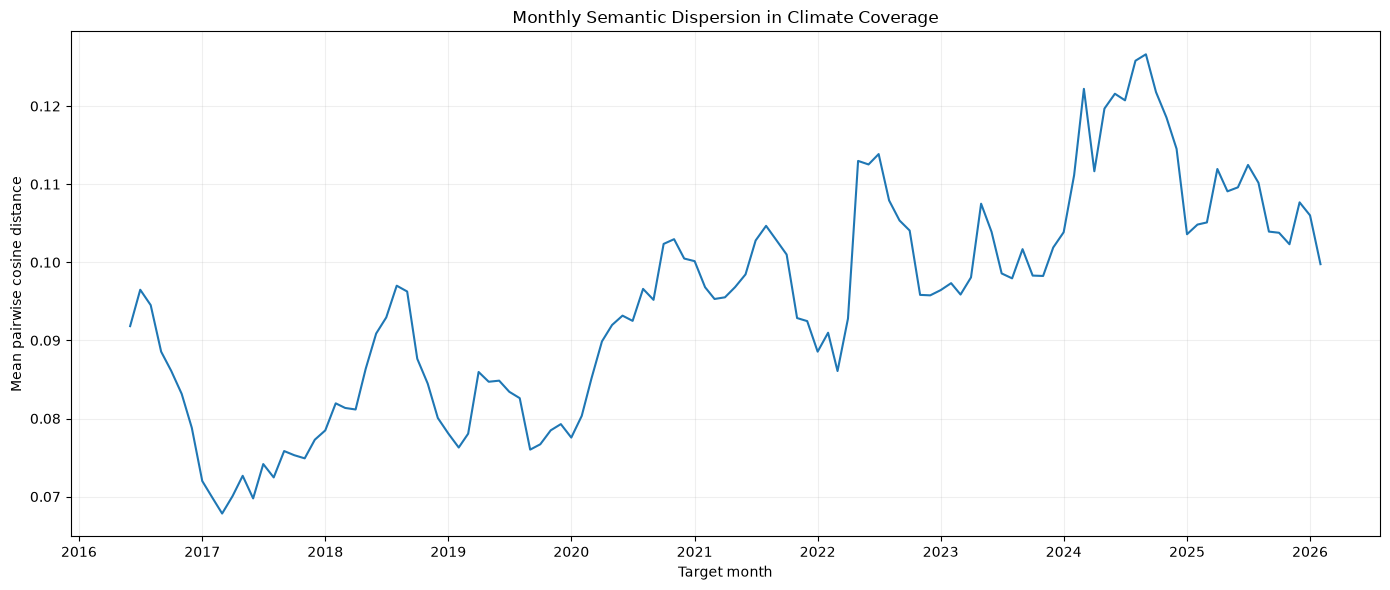

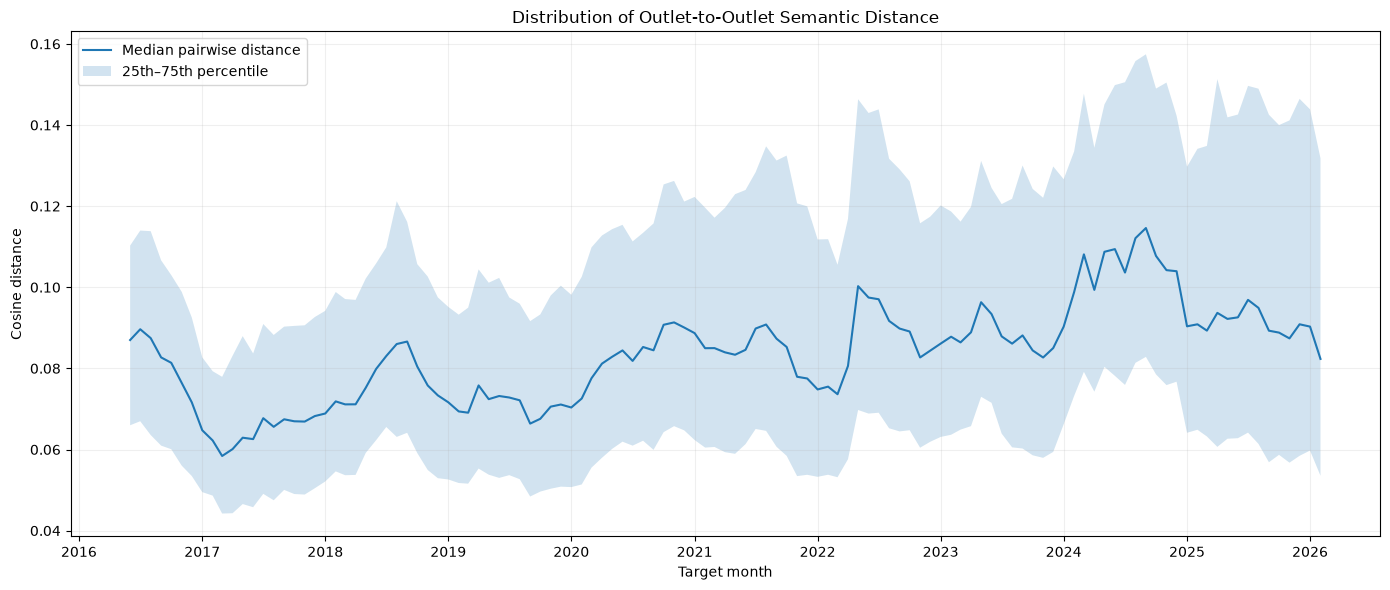

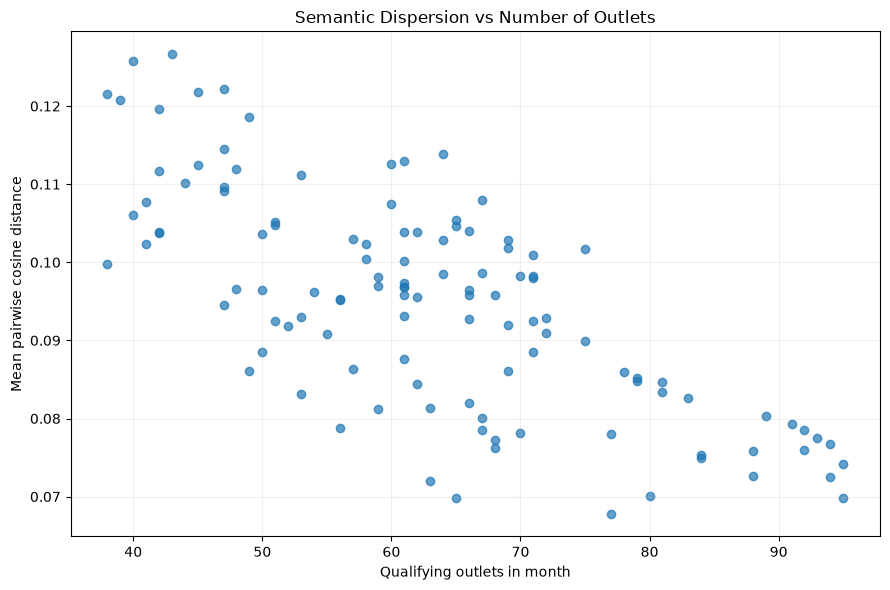


PANEL-SIZE DIAGNOSTIC
Correlation between number of outlets and mean semantic dispersion:
-0.7249

Artifacts:
Analysis vectors: /Users/lasya/Documents/projects/media-polarization-lab/data/processed/analysis_outlet_month_centroids.npy
Analysis metadata: /Users/lasya/Documents/projects/media-polarization-lab/data/processed/analysis_outlet_month_metadata.parquet
Pairwise distances: /Users/lasya/Documents/projects/media-polarization-lab/data/processed/monthly_pairwise_semantic_distances.parquet
Monthly dispersion: /Users/lasya/Documents/projects/media-polarization-lab/data/processed/monthly_semantic_dispersion.parquet


In [45]:
import itertools
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# =========================================================
# ANALYTICAL PANEL CONFIGURATION
# =========================================================

ANALYSIS_START_MONTH = "2016-06"


# =========================================================
# LOAD PRODUCTION ARTIFACTS IF NECESSARY
# =========================================================

if "centroid_matrix" not in globals():
    centroid_matrix = np.load(
        CENTROID_VECTOR_FILE
    )

if "centroid_metadata" not in globals():
    centroid_metadata = pd.read_parquet(
        CENTROID_METADATA_FILE
    )


print("=" * 75)
print("FINAL ANALYSIS PANEL")
print("=" * 75)

print(
    f"Original centroids:      "
    f"{len(centroid_metadata):,}"
)

print(
    f"Original first month:    "
    f"{centroid_metadata['target_month'].min()}"
)

print(
    f"Original last month:     "
    f"{centroid_metadata['target_month'].max()}"
)


# =========================================================
# REMOVE LEFT-CENSORED FIRST FIVE MONTHS
# =========================================================

analysis_mask = (
    centroid_metadata[
        "target_month"
    ] >= ANALYSIS_START_MONTH
)

analysis_metadata = (
    centroid_metadata[
        analysis_mask
    ]
    .copy()
    .reset_index(drop=True)
)


# Pull vectors using ORIGINAL centroid_row before replacing
# the index with a new analysis-row index.
analysis_centroid_matrix = (
    centroid_matrix[
        analysis_metadata[
            "centroid_row"
        ].to_numpy(
            dtype=np.int64
        )
    ]
    .copy()
)


analysis_metadata[
    "source_centroid_row"
] = (
    analysis_metadata[
        "centroid_row"
    ]
)

analysis_metadata[
    "analysis_centroid_row"
] = np.arange(
    len(analysis_metadata),
    dtype=np.int64,
)


# =========================================================
# VALIDATION
# =========================================================

analysis_norms = np.linalg.norm(
    analysis_centroid_matrix,
    axis=1,
)

if not np.allclose(
    analysis_norms,
    1.0,
    atol=1e-5,
):
    raise ValueError(
        "Analysis centroids are not unit normalized."
    )


duplicates = (
    analysis_metadata
    .duplicated(
        [
            "media_name",
            "target_month",
        ]
    )
    .sum()
)

if duplicates:
    raise ValueError(
        "Duplicate outlet-month observations detected."
    )


print(
    f"\nAnalysis centroids:      "
    f"{len(analysis_metadata):,}"
)

print(
    f"Centroids removed:       "
    f"{len(centroid_metadata) - len(analysis_metadata):,}"
)

print(
    f"Unique outlets:          "
    f"{analysis_metadata['media_name'].nunique():,}"
)

print(
    f"Analysis first month:    "
    f"{analysis_metadata['target_month'].min()}"
)

print(
    f"Analysis last month:     "
    f"{analysis_metadata['target_month'].max()}"
)


# =========================================================
# MONTHLY PANEL SIZE
# =========================================================

analysis_panel_size = (
    analysis_metadata
    .groupby(
        "target_month"
    )
    .agg(
        outlets=(
            "media_name",
            "nunique",
        ),

        median_window_articles=(
            "window_climate_articles",
            "median",
        ),

        median_current_articles=(
            "current_month_climate_articles",
            "median",
        ),

        median_concentration=(
            "centroid_concentration",
            "median",
        ),
    )
)


print("\n" + "=" * 75)
print("ANALYTICAL PANEL COVERAGE")
print("=" * 75)

display(
    analysis_panel_size
    .describe()
    .round(2)
)


# =========================================================
# PAIRWISE SEMANTIC DISTANCES
#
# Because centroids are normalized:
#
# cosine similarity = A @ A.T
# cosine distance   = 1 - similarity
# =========================================================

monthly_dispersion_rows = []

pairwise_rows = []


for target_month, month_df in (
    analysis_metadata
    .groupby(
        "target_month",
        sort=True,
    )
):

    month_df = (
        month_df
        .sort_values(
            "media_name"
        )
        .reset_index(drop=True)
    )

    rows = (
        month_df[
            "analysis_centroid_row"
        ]
        .to_numpy(
            dtype=np.int64
        )
    )

    vectors = (
        analysis_centroid_matrix[
            rows
        ]
    )

    outlets = (
        month_df[
            "media_name"
        ]
        .tolist()
    )

    n_outlets = len(
        outlets
    )

    if n_outlets < 2:
        continue


    # -----------------------------------------------------
    # Full cosine similarity matrix
    # -----------------------------------------------------

    similarity_matrix = (
        vectors
        @ vectors.T
    )

    # Numerical safety
    similarity_matrix = np.clip(
        similarity_matrix,
        -1.0,
        1.0,
    )

    distance_matrix = (
        1.0
        - similarity_matrix
    )


    # -----------------------------------------------------
    # Upper triangle = each pair exactly once
    # -----------------------------------------------------

    upper_i, upper_j = np.triu_indices(
        n_outlets,
        k=1,
    )

    pair_distances = (
        distance_matrix[
            upper_i,
            upper_j
        ]
    )

    pair_similarities = (
        similarity_matrix[
            upper_i,
            upper_j
        ]
    )


    # -----------------------------------------------------
    # Monthly dispersion
    # -----------------------------------------------------

    monthly_dispersion_rows.append({
        "target_month":
            target_month,

        "outlets":
            n_outlets,

        "pairs":
            len(
                pair_distances
            ),

        "mean_pairwise_distance":
            float(
                np.mean(
                    pair_distances
                )
            ),

        "median_pairwise_distance":
            float(
                np.median(
                    pair_distances
                )
            ),

        "p25_pairwise_distance":
            float(
                np.quantile(
                    pair_distances,
                    0.25,
                )
            ),

        "p75_pairwise_distance":
            float(
                np.quantile(
                    pair_distances,
                    0.75,
                )
            ),

        "p90_pairwise_distance":
            float(
                np.quantile(
                    pair_distances,
                    0.90,
                )
            ),

        "max_pairwise_distance":
            float(
                np.max(
                    pair_distances
                )
            ),

        "mean_pairwise_similarity":
            float(
                np.mean(
                    pair_similarities
                )
            ),
    })


    # -----------------------------------------------------
    # Persist every outlet pair for later analysis
    # -----------------------------------------------------

    for i, j, distance, similarity in zip(
        upper_i,
        upper_j,
        pair_distances,
        pair_similarities,
    ):

        pairwise_rows.append({
            "target_month":
                target_month,

            "outlet_a":
                outlets[i],

            "outlet_b":
                outlets[j],

            "cosine_similarity":
                float(
                    similarity
                ),

            "cosine_distance":
                float(
                    distance
                ),
        })


monthly_semantic_dispersion = (
    pd.DataFrame(
        monthly_dispersion_rows
    )
    .sort_values(
        "target_month"
    )
    .reset_index(drop=True)
)


pairwise_semantic_distances = (
    pd.DataFrame(
        pairwise_rows
    )
)


# =========================================================
# SAVE RESULT LAYER
# =========================================================

ANALYSIS_CENTROID_FILE = (
    PROCESSED_DIR
    / "analysis_outlet_month_centroids.npy"
)

ANALYSIS_METADATA_FILE = (
    PROCESSED_DIR
    / "analysis_outlet_month_metadata.parquet"
)

PAIRWISE_DISTANCE_FILE = (
    PROCESSED_DIR
    / "monthly_pairwise_semantic_distances.parquet"
)

MONTHLY_DISPERSION_FILE = (
    PROCESSED_DIR
    / "monthly_semantic_dispersion.parquet"
)


np.save(
    ANALYSIS_CENTROID_FILE,
    analysis_centroid_matrix,
)

analysis_metadata.to_parquet(
    ANALYSIS_METADATA_FILE,
    index=False,
)

pairwise_semantic_distances.to_parquet(
    PAIRWISE_DISTANCE_FILE,
    index=False,
)

monthly_semantic_dispersion.to_parquet(
    MONTHLY_DISPERSION_FILE,
    index=False,
)


# =========================================================
# MONTHLY DISPERSION SUMMARY
# =========================================================

print("\n" + "=" * 75)
print("MONTHLY SEMANTIC DISPERSION")
print("=" * 75)

display(
    monthly_semantic_dispersion[
        [
            "outlets",
            "pairs",
            "mean_pairwise_distance",
            "median_pairwise_distance",
            "p25_pairwise_distance",
            "p75_pairwise_distance",
            "p90_pairwise_distance",
            "max_pairwise_distance",
        ]
    ]
    .describe(
        percentiles=[
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
        ]
    )
    .round(4)
)


# =========================================================
# MOST / LEAST DISPERSED MONTHS
# =========================================================

print("\n" + "=" * 75)
print("MOST SEMANTICALLY DISPERSED MONTHS")
print("=" * 75)

display(
    monthly_semantic_dispersion[
        [
            "target_month",
            "outlets",
            "pairs",
            "mean_pairwise_distance",
            "median_pairwise_distance",
            "p90_pairwise_distance",
        ]
    ]
    .sort_values(
        "mean_pairwise_distance",
        ascending=False,
    )
    .head(15)
    .round(4)
)


print("\n" + "=" * 75)
print("LEAST SEMANTICALLY DISPERSED MONTHS")
print("=" * 75)

display(
    monthly_semantic_dispersion[
        [
            "target_month",
            "outlets",
            "pairs",
            "mean_pairwise_distance",
            "median_pairwise_distance",
            "p90_pairwise_distance",
        ]
    ]
    .sort_values(
        "mean_pairwise_distance",
        ascending=True,
    )
    .head(15)
    .round(4)
)


# =========================================================
# EXTREME OUTLET PAIRS
# =========================================================

print("\n" + "=" * 75)
print("MOST DIVERGENT OUTLET-MONTH PAIRS")
print("=" * 75)

display(
    pairwise_semantic_distances[
        [
            "target_month",
            "outlet_a",
            "outlet_b",
            "cosine_similarity",
            "cosine_distance",
        ]
    ]
    .sort_values(
        "cosine_distance",
        ascending=False,
    )
    .head(30)
    .round(4)
)


print("\n" + "=" * 75)
print("MOST SIMILAR OUTLET-MONTH PAIRS")
print("=" * 75)

display(
    pairwise_semantic_distances[
        [
            "target_month",
            "outlet_a",
            "outlet_b",
            "cosine_similarity",
            "cosine_distance",
        ]
    ]
    .sort_values(
        "cosine_distance",
        ascending=True,
    )
    .head(30)
    .round(4)
)


# =========================================================
# TIME AXIS
# =========================================================

monthly_semantic_dispersion[
    "month_dt"
] = pd.to_datetime(
    monthly_semantic_dispersion[
        "target_month"
    ]
)


# =========================================================
# PLOT 1 — PRIMARY SEMANTIC DISPERSION INDEX
# =========================================================

fig, ax = plt.subplots(
    figsize=(14, 6)
)

ax.plot(
    monthly_semantic_dispersion[
        "month_dt"
    ],
    monthly_semantic_dispersion[
        "mean_pairwise_distance"
    ],
)

ax.set_title(
    "Monthly Semantic Dispersion in Climate Coverage"
)

ax.set_xlabel(
    "Target month"
)

ax.set_ylabel(
    "Mean pairwise cosine distance"
)

ax.grid(
    alpha=0.2
)

plt.tight_layout()
plt.show()


# =========================================================
# PLOT 2 — MEDIAN + INTERQUARTILE RANGE
# =========================================================

fig, ax = plt.subplots(
    figsize=(14, 6)
)

ax.plot(
    monthly_semantic_dispersion[
        "month_dt"
    ],
    monthly_semantic_dispersion[
        "median_pairwise_distance"
    ],
    label="Median pairwise distance",
)

ax.fill_between(
    monthly_semantic_dispersion[
        "month_dt"
    ],
    monthly_semantic_dispersion[
        "p25_pairwise_distance"
    ],
    monthly_semantic_dispersion[
        "p75_pairwise_distance"
    ],
    alpha=0.2,
    label="25th–75th percentile",
)

ax.set_title(
    "Distribution of Outlet-to-Outlet Semantic Distance"
)

ax.set_xlabel(
    "Target month"
)

ax.set_ylabel(
    "Cosine distance"
)

ax.legend()

ax.grid(
    alpha=0.2
)

plt.tight_layout()
plt.show()


# =========================================================
# PLOT 3 — DISPERSION VS PANEL SIZE
# =========================================================

fig, ax = plt.subplots(
    figsize=(9, 6)
)

ax.scatter(
    monthly_semantic_dispersion[
        "outlets"
    ],
    monthly_semantic_dispersion[
        "mean_pairwise_distance"
    ],
    alpha=0.7,
)

ax.set_title(
    "Semantic Dispersion vs Number of Outlets"
)

ax.set_xlabel(
    "Qualifying outlets in month"
)

ax.set_ylabel(
    "Mean pairwise cosine distance"
)

ax.grid(
    alpha=0.2
)

plt.tight_layout()
plt.show()


# =========================================================
# PANEL-SIZE CORRELATION
# =========================================================

panel_corr = (
    monthly_semantic_dispersion[
        [
            "outlets",
            "mean_pairwise_distance",
        ]
    ]
    .corr()
    .iloc[
        0,
        1
    ]
)

print("\n" + "=" * 75)
print("PANEL-SIZE DIAGNOSTIC")
print("=" * 75)

print(
    "Correlation between number of outlets "
    "and mean semantic dispersion:"
)

print(
    f"{panel_corr:.4f}"
)


print("\nArtifacts:")

print(
    f"Analysis vectors: "
    f"{ANALYSIS_CENTROID_FILE.resolve()}"
)

print(
    f"Analysis metadata: "
    f"{ANALYSIS_METADATA_FILE.resolve()}"
)

print(
    f"Pairwise distances: "
    f"{PAIRWISE_DISTANCE_FILE.resolve()}"
)

print(
    f"Monthly dispersion: "
    f"{MONTHLY_DISPERSION_FILE.resolve()}"
)

## 28. Panel Composition Robustness

The initial dynamic-panel analysis shows substantial temporal variation in semantic dispersion.

However, monthly panel size is strongly negatively associated with observed dispersion. This raises the possibility that part of the apparent temporal pattern is caused by changing outlet composition rather than changes in semantic relationships among the same outlets.

Three complementary specifications are therefore compared.

### 1. Dynamic panel

The baseline index uses every qualifying outlet available in each target month.

### 2. Stable outlet cohort

A core cohort is defined as outlets represented in at least 90% of analytical months.

Monthly pairwise dispersion is recalculated using only these persistent outlets.

This substantially reduces changes in outlet composition.

### 3. Pair fixed-effect adjustment

For each sufficiently persistent outlet pair, its long-run mean semantic distance is calculated.

A monthly composition-adjusted index is obtained by averaging these within-pair deviations and adding the overall persistent-pair mean for interpretability.

This specification asks whether the same outlet relationships become more or less semantically dispersed over time, rather than allowing changes in outlet membership to drive the result.

PANEL COMPOSITION ROBUSTNESS
Analysis months:             117
Core outlet threshold:       90%
Persistent pair threshold:   90%

OUTLET COVERAGE THRESHOLD SENSITIVITY


,minimum_coverage_pct,minimum_months,qualifying_outlets
0,50.0,59,57
1,75.0,88,37
2,80.0,94,32
3,90.0,106,20
4,95.0,112,12
5,100.0,117,6



STABLE OUTLET COHORT
Core outlets (>=90%):       20
Fully balanced outlets:     6
Minimum core months:        106

Core outlets:


,months_present,first_month,last_month,coverage_pct
media_name,,,,
abcnews.go.com,117,2016-06,2026-02,100.00
cbsnews.com,117,2016-06,2026-02,100.00
grist.org,117,2016-06,2026-02,100.00
latimes.com,117,2016-06,2026-02,100.00
theconversation.com,117,2016-06,2026-02,100.00
theguardian.com,117,2016-06,2026-02,100.00
foxnews.com,116,2016-06,2026-02,99.15
mongabay.com,115,2016-07,2026-02,98.29
nytimes.com,115,2016-06,2025-12,98.29



CORE COHORT MONTHLY AVAILABILITY


...

,specification,composition_measure,correlation_with_dispersion
0,Dynamic panel,monthly outlets,-0.7249
1,Stable outlet cohort,core outlets present,-0.5948
2,Pair fixed-effect adjusted,persistent pairs present,-0.5527



DESCRIPTIVE LINEAR TIME TREND


,specification,annualized_distance_change
0,Dynamic panel,0.003986
1,Stable outlet cohort,0.004547
2,Pair fixed-effect adjusted,0.003898



STUDY-PERIOD COMPARISON


,months,dynamic_dispersion,core_dispersion,adjusted_dispersion,dynamic_outlets,core_outlets
study_period,,,,,,
early,39,0.0816,0.0816,0.0827,68.6667,19.4103
middle,39,0.0951,0.0859,0.0867,68.4359,19.7179
late,39,0.1077,0.1100,0.1067,52.0769,18.6667


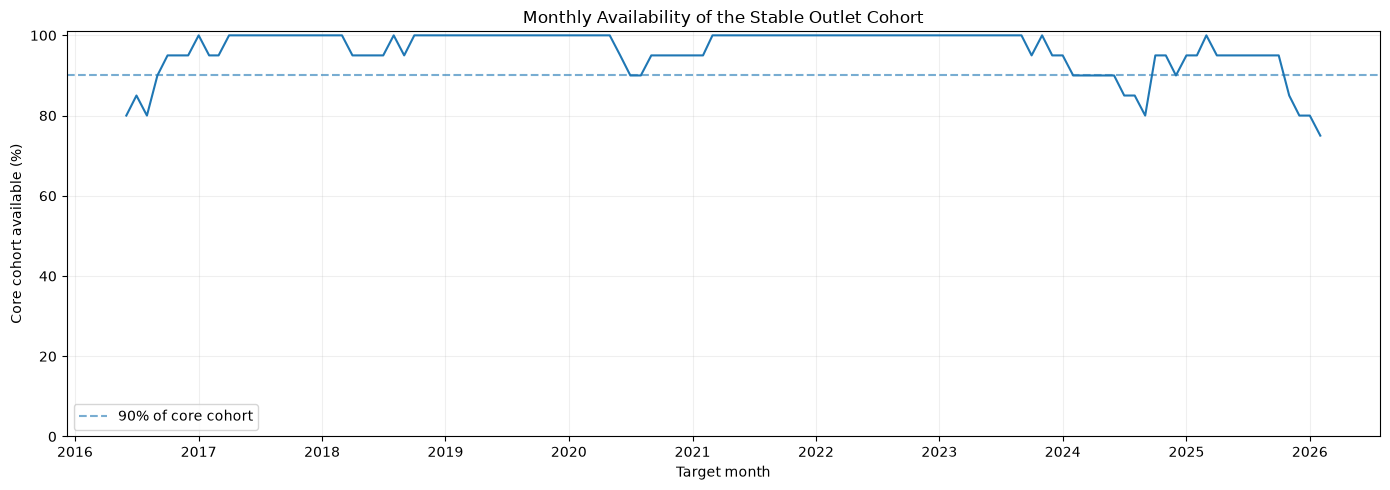

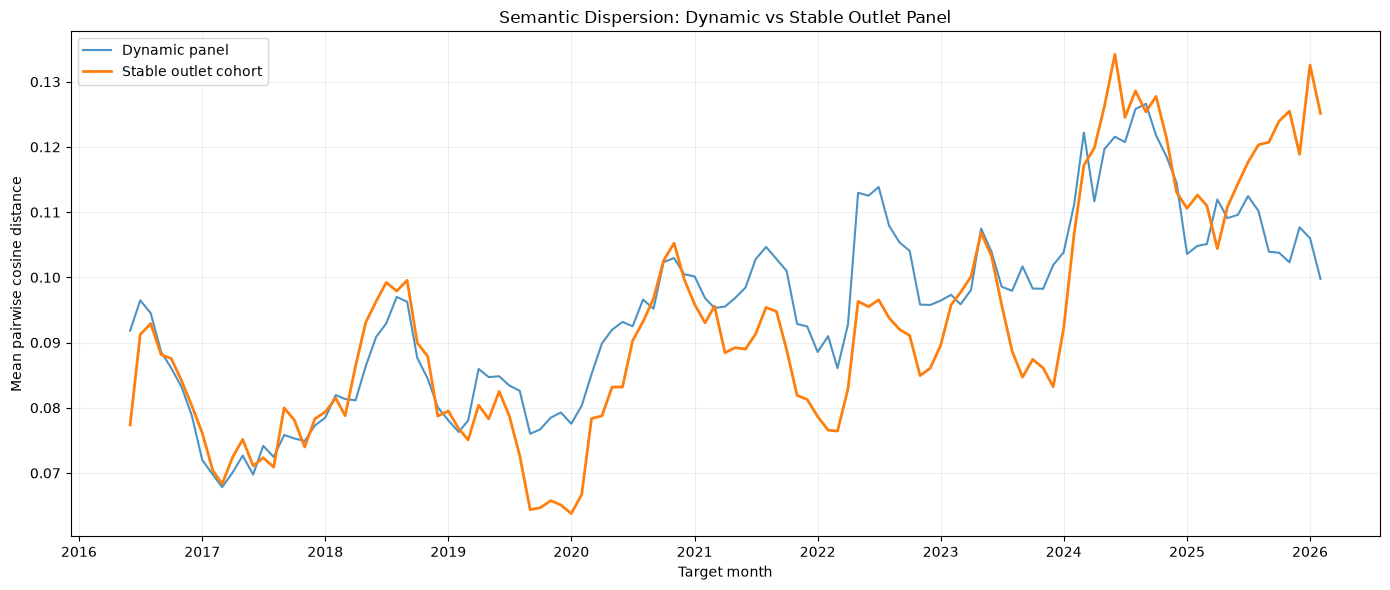

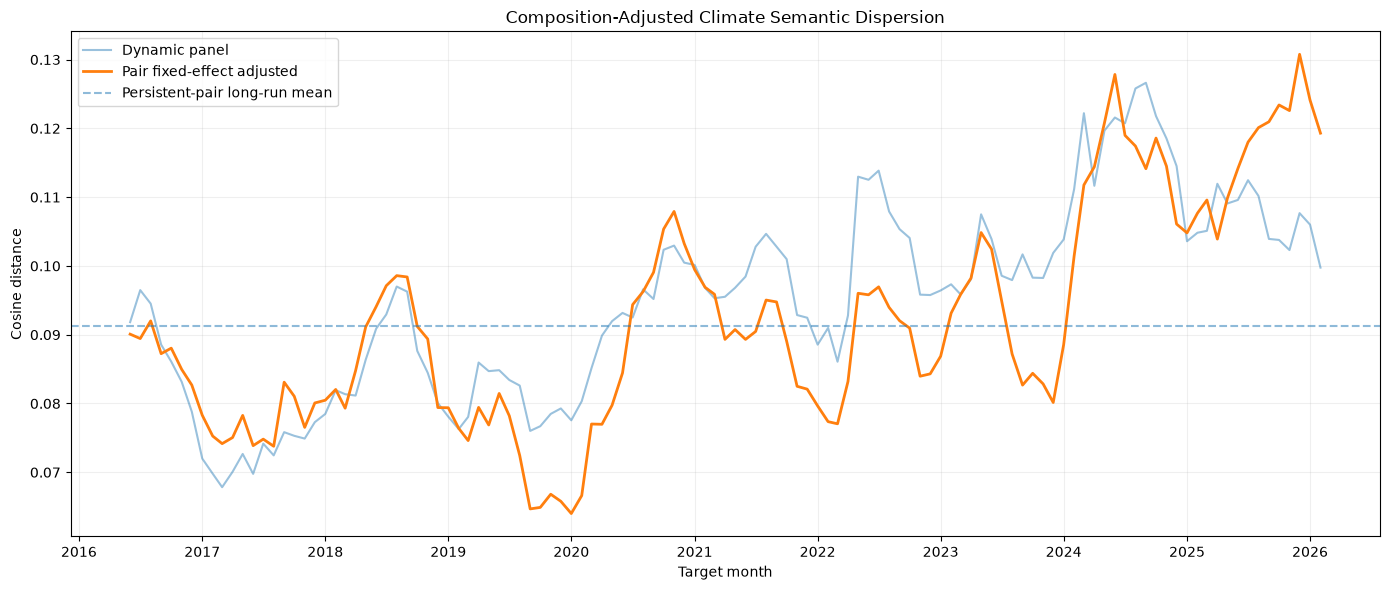

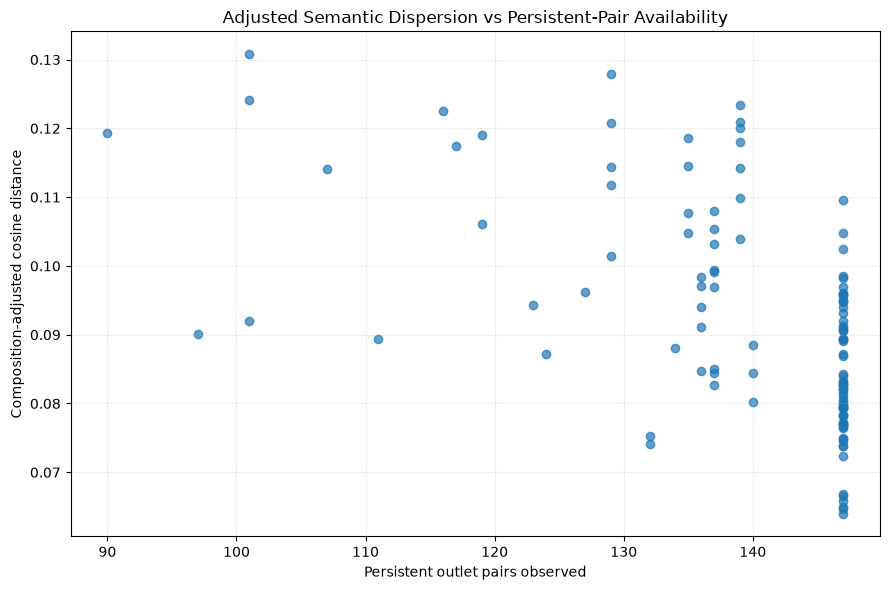


Artifacts:
/Users/lasya/Documents/projects/media-polarization-lab/data/processed/semantic_dispersion_panel_robustness.parquet
/Users/lasya/Documents/projects/media-polarization-lab/data/processed/analysis_outlet_coverage.parquet
/Users/lasya/Documents/projects/media-polarization-lab/data/processed/persistent_pair_coverage.parquet


In [46]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# =========================================================
# CONFIGURATION
# =========================================================

CORE_OUTLET_COVERAGE = 0.90

# Persistent pair must exist in at least this share
# of analytical months.
PAIR_COVERAGE_THRESHOLD = 0.90


# =========================================================
# ANALYSIS MONTHS
# =========================================================

analysis_months = pd.Index(
    sorted(
        analysis_metadata[
            "target_month"
        ].unique()
    )
)

N_ANALYSIS_MONTHS = len(
    analysis_months
)


print("=" * 75)
print("PANEL COMPOSITION ROBUSTNESS")
print("=" * 75)

print(
    f"Analysis months:             "
    f"{N_ANALYSIS_MONTHS}"
)

print(
    f"Core outlet threshold:       "
    f"{CORE_OUTLET_COVERAGE:.0%}"
)

print(
    f"Persistent pair threshold:   "
    f"{PAIR_COVERAGE_THRESHOLD:.0%}"
)


# =========================================================
# OUTLET COVERAGE
# =========================================================

analysis_outlet_coverage = (
    analysis_metadata
    .groupby(
        "media_name"
    )
    .agg(
        months_present=(
            "target_month",
            "nunique",
        ),

        first_month=(
            "target_month",
            "min",
        ),

        last_month=(
            "target_month",
            "max",
        ),
    )
)

analysis_outlet_coverage[
    "coverage_pct"
] = (
    analysis_outlet_coverage[
        "months_present"
    ]
    / N_ANALYSIS_MONTHS
    * 100
)


# =========================================================
# COVERAGE THRESHOLD SENSITIVITY
# =========================================================

coverage_thresholds = [
    0.50,
    0.75,
    0.80,
    0.90,
    0.95,
    1.00,
]

coverage_rows = []

for threshold in coverage_thresholds:

    count = (
        analysis_outlet_coverage[
            "months_present"
        ]
        .ge(
            np.ceil(
                N_ANALYSIS_MONTHS
                * threshold
            )
        )
        .sum()
    )

    coverage_rows.append({
        "minimum_coverage_pct":
            threshold * 100,

        "minimum_months":
            int(
                np.ceil(
                    N_ANALYSIS_MONTHS
                    * threshold
                )
            ),

        "qualifying_outlets":
            int(count),
    })


coverage_threshold_summary = (
    pd.DataFrame(
        coverage_rows
    )
)


print("\n" + "=" * 75)
print("OUTLET COVERAGE THRESHOLD SENSITIVITY")
print("=" * 75)

display(
    coverage_threshold_summary
)


# =========================================================
# CORE OUTLET COHORT
# =========================================================

minimum_core_months = int(
    np.ceil(
        N_ANALYSIS_MONTHS
        * CORE_OUTLET_COVERAGE
    )
)

core_outlets = (
    analysis_outlet_coverage[
        analysis_outlet_coverage[
            "months_present"
        ] >= minimum_core_months
    ]
    .index
    .tolist()
)


complete_outlets = (
    analysis_outlet_coverage[
        analysis_outlet_coverage[
            "months_present"
        ] == N_ANALYSIS_MONTHS
    ]
    .index
    .tolist()
)


print("\n" + "=" * 75)
print("STABLE OUTLET COHORT")
print("=" * 75)

print(
    f"Core outlets (>=90%):       "
    f"{len(core_outlets):,}"
)

print(
    f"Fully balanced outlets:     "
    f"{len(complete_outlets):,}"
)

print(
    f"Minimum core months:        "
    f"{minimum_core_months}"
)


print("\nCore outlets:")

display(
    analysis_outlet_coverage
    .loc[
        core_outlets
    ]
    .sort_values(
        [
            "months_present",
            "media_name",
        ],
        ascending=[
            False,
            True,
        ],
    )
    .round(2)
)


# =========================================================
# CORE COHORT MONTHLY AVAILABILITY
# =========================================================

core_monthly_availability = (
    analysis_metadata[
        analysis_metadata[
            "media_name"
        ].isin(
            core_outlets
        )
    ]
    .groupby(
        "target_month"
    )[
        "media_name"
    ]
    .nunique()
    .reindex(
        analysis_months,
        fill_value=0,
    )
    .rename(
        "core_outlets_present"
    )
    .to_frame()
)


core_monthly_availability[
    "core_presence_pct"
] = (
    core_monthly_availability[
        "core_outlets_present"
    ]
    / len(core_outlets)
    * 100
)


print("\n" + "=" * 75)
print("CORE COHORT MONTHLY AVAILABILITY")
print("=" * 75)

display(
    core_monthly_availability
    .describe()
    .round(2)
)


# =========================================================
# PREPARE PAIR TABLE
# =========================================================

pair_df = (
    pairwise_semantic_distances
    .copy()
)


# Canonical pair identifier.
#
# outlet_a/outlet_b were already created in alphabetical
# outlet order within each month, but explicitly constructing
# this keeps the artifact self-contained.
pair_df[
    "pair_id"
] = (
    pair_df[
        "outlet_a"
    ]
    + " || "
    + pair_df[
        "outlet_b"
    ]
)


# =========================================================
# DYNAMIC PANEL INDEX
# =========================================================

dynamic_index = (
    monthly_semantic_dispersion[
        [
            "target_month",
            "outlets",
            "pairs",
            "mean_pairwise_distance",
        ]
    ]
    .copy()
    .rename(
        columns={
            "mean_pairwise_distance":
                "dynamic_dispersion"
        }
    )
)


# =========================================================
# CORE COHORT PAIRS
# =========================================================

core_pair_df = (
    pair_df[
        pair_df[
            "outlet_a"
        ].isin(
            core_outlets
        )
        &
        pair_df[
            "outlet_b"
        ].isin(
            core_outlets
        )
    ]
    .copy()
)


core_dispersion = (
    core_pair_df
    .groupby(
        "target_month"
    )
    .agg(
        core_pairs=(
            "cosine_distance",
            "size",
        ),

        core_mean_distance=(
            "cosine_distance",
            "mean",
        ),

        core_median_distance=(
            "cosine_distance",
            "median",
        ),

        core_p90_distance=(
            "cosine_distance",
            lambda x:
                x.quantile(
                    0.90
                ),
        ),
    )
    .reset_index()
)


core_dispersion = (
    core_dispersion
    .merge(
        core_monthly_availability
        .reset_index()
        .rename(
            columns={
                "index":
                    "target_month"
            }
        ),
        on="target_month",
        how="left",
    )
)


# =========================================================
# PERSISTENT PAIRS
# =========================================================

pair_coverage = (
    core_pair_df
    .groupby(
        "pair_id"
    )
    .agg(
        months_present=(
            "target_month",
            "nunique",
        ),

        outlet_a=(
            "outlet_a",
            "first",
        ),

        outlet_b=(
            "outlet_b",
            "first",
        ),

        mean_distance=(
            "cosine_distance",
            "mean",
        ),

        std_distance=(
            "cosine_distance",
            "std",
        ),
    )
)


pair_coverage[
    "coverage_pct"
] = (
    pair_coverage[
        "months_present"
    ]
    / N_ANALYSIS_MONTHS
    * 100
)


minimum_pair_months = int(
    np.ceil(
        N_ANALYSIS_MONTHS
        * PAIR_COVERAGE_THRESHOLD
    )
)


persistent_pair_ids = (
    pair_coverage[
        pair_coverage[
            "months_present"
        ] >= minimum_pair_months
    ]
    .index
)


persistent_pairs = (
    core_pair_df[
        core_pair_df[
            "pair_id"
        ].isin(
            persistent_pair_ids
        )
    ]
    .copy()
)


print("\n" + "=" * 75)
print("PERSISTENT PAIR PANEL")
print("=" * 75)

print(
    f"Core cohort pair observations: "
    f"{len(core_pair_df):,}"
)

print(
    f"Unique core pairs:              "
    f"{core_pair_df['pair_id'].nunique():,}"
)

print(
    f"Persistent pairs:               "
    f"{len(persistent_pair_ids):,}"
)

print(
    f"Minimum months per pair:        "
    f"{minimum_pair_months}"
)


# Exact fully balanced pairs — diagnostic only.
fully_balanced_pairs = (
    pair_coverage[
        pair_coverage[
            "months_present"
        ] == N_ANALYSIS_MONTHS
    ]
)

print(
    f"Pairs present every month:      "
    f"{len(fully_balanced_pairs):,}"
)


# =========================================================
# PAIR FIXED EFFECT
#
# Remove each pair's long-run typical distance.
# =========================================================

persistent_pairs[
    "pair_mean_distance"
] = (
    persistent_pairs
    .groupby(
        "pair_id"
    )[
        "cosine_distance"
    ]
    .transform(
        "mean"
    )
)


persistent_pairs[
    "within_pair_deviation"
] = (
    persistent_pairs[
        "cosine_distance"
    ]
    -
    persistent_pairs[
        "pair_mean_distance"
    ]
)


# Overall persistent-pair distance.
#
# Add this after demeaning so adjusted index remains
# interpretable on approximately the original distance scale.
persistent_pair_grand_mean = float(
    persistent_pairs[
        "cosine_distance"
    ].mean()
)


pair_fe_monthly = (
    persistent_pairs
    .groupby(
        "target_month"
    )
    .agg(
        persistent_pairs_present=(
            "pair_id",
            "nunique",
        ),

        mean_within_pair_deviation=(
            "within_pair_deviation",
            "mean",
        ),

        median_within_pair_deviation=(
            "within_pair_deviation",
            "median",
        ),
    )
    .reset_index()
)


pair_fe_monthly[
    "composition_adjusted_dispersion"
] = (
    persistent_pair_grand_mean
    +
    pair_fe_monthly[
        "mean_within_pair_deviation"
    ]
)


pair_fe_monthly[
    "persistent_pair_presence_pct"
] = (
    pair_fe_monthly[
        "persistent_pairs_present"
    ]
    / len(
        persistent_pair_ids
    )
    * 100
)


# =========================================================
# MERGE THREE SPECIFICATIONS
# =========================================================

robustness_monthly = (
    dynamic_index
    .merge(
        core_dispersion,
        on="target_month",
        how="left",
    )
    .merge(
        pair_fe_monthly,
        on="target_month",
        how="left",
    )
)


robustness_monthly[
    "month_dt"
] = pd.to_datetime(
    robustness_monthly[
        "target_month"
    ]
)


# =========================================================
# PANEL-SIZE CORRELATIONS
# =========================================================

dynamic_panel_corr = (
    robustness_monthly[
        [
            "outlets",
            "dynamic_dispersion",
        ]
    ]
    .corr()
    .iloc[
        0,
        1
    ]
)


core_panel_corr = (
    robustness_monthly[
        [
            "core_outlets_present",
            "core_mean_distance",
        ]
    ]
    .corr()
    .iloc[
        0,
        1
    ]
)


pair_presence_corr = (
    robustness_monthly[
        [
            "persistent_pairs_present",
            "composition_adjusted_dispersion",
        ]
    ]
    .corr()
    .iloc[
        0,
        1
    ]
)


print("\n" + "=" * 75)
print("PANEL-COMPOSITION DIAGNOSTICS")
print("=" * 75)

diagnostic_table = pd.DataFrame(
    {
        "specification": [
            "Dynamic panel",
            "Stable outlet cohort",
            "Pair fixed-effect adjusted",
        ],

        "composition_measure": [
            "monthly outlets",
            "core outlets present",
            "persistent pairs present",
        ],

        "correlation_with_dispersion": [
            dynamic_panel_corr,
            core_panel_corr,
            pair_presence_corr,
        ],
    }
)

display(
    diagnostic_table.round(4)
)


# =========================================================
# SIMPLE DESCRIPTIVE TIME TREND
#
# This is NOT being treated as formal causal inference.
# It only describes direction and magnitude.
# =========================================================

def annualized_linear_slope(
    dataframe,
    y_column,
):

    temp = (
        dataframe[
            [
                "month_dt",
                y_column,
            ]
        ]
        .dropna()
        .copy()
    )

    elapsed_years = (
        (
            temp[
                "month_dt"
            ]
            -
            temp[
                "month_dt"
            ].min()
        )
        .dt.days
        / 365.25
    )

    slope = np.polyfit(
        elapsed_years,
        temp[
            y_column
        ],
        1,
    )[0]

    return float(
        slope
    )


trend_table = pd.DataFrame(
    {
        "specification": [
            "Dynamic panel",
            "Stable outlet cohort",
            "Pair fixed-effect adjusted",
        ],

        "annualized_distance_change": [
            annualized_linear_slope(
                robustness_monthly,
                "dynamic_dispersion",
            ),

            annualized_linear_slope(
                robustness_monthly,
                "core_mean_distance",
            ),

            annualized_linear_slope(
                robustness_monthly,
                "composition_adjusted_dispersion",
            ),
        ],
    }
)


print("\n" + "=" * 75)
print("DESCRIPTIVE LINEAR TIME TREND")
print("=" * 75)

display(
    trend_table.round(6)
)


# =========================================================
# EARLY / LATE DESCRIPTIVE SUMMARY
#
# Divide the study mechanically into thirds rather than
# manually choosing politically interesting dates.
# =========================================================

ordered_months = (
    robustness_monthly[
        "target_month"
    ]
    .sort_values()
    .tolist()
)

month_thirds = np.array_split(
    ordered_months,
    3,
)


period_lookup = {}

for label, months in zip(
    [
        "early",
        "middle",
        "late",
    ],
    month_thirds,
):

    for month in months:
        period_lookup[
            month
        ] = label


robustness_monthly[
    "study_period"
] = (
    robustness_monthly[
        "target_month"
    ]
    .map(
        period_lookup
    )
)


period_summary = (
    robustness_monthly
    .groupby(
        "study_period"
    )
    .agg(
        months=(
            "target_month",
            "size",
        ),

        dynamic_dispersion=(
            "dynamic_dispersion",
            "mean",
        ),

        core_dispersion=(
            "core_mean_distance",
            "mean",
        ),

        adjusted_dispersion=(
            "composition_adjusted_dispersion",
            "mean",
        ),

        dynamic_outlets=(
            "outlets",
            "mean",
        ),

        core_outlets=(
            "core_outlets_present",
            "mean",
        ),
    )
)


# Restore logical order.
period_summary = (
    period_summary
    .reindex(
        [
            "early",
            "middle",
            "late",
        ]
    )
)


print("\n" + "=" * 75)
print("STUDY-PERIOD COMPARISON")
print("=" * 75)

display(
    period_summary.round(4)
)


# =========================================================
# SAVE ROBUSTNESS ARTIFACTS
# =========================================================

ROBUSTNESS_MONTHLY_FILE = (
    PROCESSED_DIR
    / "semantic_dispersion_panel_robustness.parquet"
)

OUTLET_COVERAGE_ANALYSIS_FILE = (
    PROCESSED_DIR
    / "analysis_outlet_coverage.parquet"
)

PAIR_COVERAGE_FILE = (
    PROCESSED_DIR
    / "persistent_pair_coverage.parquet"
)


robustness_monthly.to_parquet(
    ROBUSTNESS_MONTHLY_FILE,
    index=False,
)

analysis_outlet_coverage.to_parquet(
    OUTLET_COVERAGE_ANALYSIS_FILE
)

pair_coverage.to_parquet(
    PAIR_COVERAGE_FILE
)


# =========================================================
# PLOT 1 — CORE COHORT AVAILABILITY
# =========================================================

fig, ax = plt.subplots(
    figsize=(14, 5)
)

ax.plot(
    pd.to_datetime(
        core_monthly_availability.index
    ),
    core_monthly_availability[
        "core_presence_pct"
    ],
)

ax.axhline(
    90,
    linestyle="--",
    alpha=0.6,
    label="90% of core cohort",
)

ax.set_title(
    "Monthly Availability of the Stable Outlet Cohort"
)

ax.set_xlabel(
    "Target month"
)

ax.set_ylabel(
    "Core cohort available (%)"
)

ax.set_ylim(
    0,
    101,
)

ax.legend()

ax.grid(
    alpha=0.2
)

plt.tight_layout()
plt.show()


# =========================================================
# PLOT 2 — DYNAMIC VS STABLE COHORT
# =========================================================

fig, ax = plt.subplots(
    figsize=(14, 6)
)

ax.plot(
    robustness_monthly[
        "month_dt"
    ],
    robustness_monthly[
        "dynamic_dispersion"
    ],
    label="Dynamic panel",
    alpha=0.8,
)

ax.plot(
    robustness_monthly[
        "month_dt"
    ],
    robustness_monthly[
        "core_mean_distance"
    ],
    label="Stable outlet cohort",
    linewidth=2,
)

ax.set_title(
    "Semantic Dispersion: Dynamic vs Stable Outlet Panel"
)

ax.set_xlabel(
    "Target month"
)

ax.set_ylabel(
    "Mean pairwise cosine distance"
)

ax.legend()

ax.grid(
    alpha=0.2
)

plt.tight_layout()
plt.show()


# =========================================================
# PLOT 3 — COMPOSITION-ADJUSTED INDEX
# =========================================================

fig, ax = plt.subplots(
    figsize=(14, 6)
)

ax.plot(
    robustness_monthly[
        "month_dt"
    ],
    robustness_monthly[
        "dynamic_dispersion"
    ],
    label="Dynamic panel",
    alpha=0.45,
)

ax.plot(
    robustness_monthly[
        "month_dt"
    ],
    robustness_monthly[
        "composition_adjusted_dispersion"
    ],
    label="Pair fixed-effect adjusted",
    linewidth=2,
)

ax.axhline(
    persistent_pair_grand_mean,
    linestyle="--",
    alpha=0.5,
    label="Persistent-pair long-run mean",
)

ax.set_title(
    "Composition-Adjusted Climate Semantic Dispersion"
)

ax.set_xlabel(
    "Target month"
)

ax.set_ylabel(
    "Cosine distance"
)

ax.legend()

ax.grid(
    alpha=0.2
)

plt.tight_layout()
plt.show()


# =========================================================
# PLOT 4 — PANEL-SIZE RELATION AFTER ADJUSTMENT
# =========================================================

fig, ax = plt.subplots(
    figsize=(9, 6)
)

ax.scatter(
    robustness_monthly[
        "persistent_pairs_present"
    ],
    robustness_monthly[
        "composition_adjusted_dispersion"
    ],
    alpha=0.7,
)

ax.set_title(
    "Adjusted Semantic Dispersion vs Persistent-Pair Availability"
)

ax.set_xlabel(
    "Persistent outlet pairs observed"
)

ax.set_ylabel(
    "Composition-adjusted cosine distance"
)

ax.grid(
    alpha=0.2
)

plt.tight_layout()
plt.show()


print("\nArtifacts:")

print(
    ROBUSTNESS_MONTHLY_FILE.resolve()
)

print(
    OUTLET_COVERAGE_ANALYSIS_FILE.resolve()
)

print(
    PAIR_COVERAGE_FILE.resolve()
)

## 29. Balanced-Panel and Temporal Robustness

The increase in semantic dispersion remains visible after restricting the analysis to persistent outlets and after removing persistent outlet-pair differences.

Two additional concerns remain.

### Perfectly balanced panel

Even a 90%-coverage cohort contains occasional missing observations. A stricter robustness test therefore uses only outlets represented in every analytical month.

This creates a completely balanced panel in which:

- the same outlets are present in every month,
- the same outlet pairs are compared in every month, and
- changes in sample composition cannot affect the dispersion measure.

### Overlapping-window autocorrelation

Outlet-month centroids are constructed from trailing six-month headline windows. Consecutive observations therefore share much of their underlying article data.

Ordinary regression standard errors would incorrectly treat monthly observations as independent.

Linear time trends are consequently estimated using heteroskedasticity- and autocorrelation-consistent (HAC / Newey-West) standard errors.

Results are evaluated across:

- the dynamic panel,
- persistent outlet cohorts,
- the pair fixed-effect index, and
- the completely balanced outlet panel.

A six-month non-overlapping sample is additionally examined as a descriptive sensitivity test.

BALANCED-PANEL AND TEMPORAL ROBUSTNESS
Analysis months: 117

FULLY BALANCED OUTLET PANEL
Outlets present every month: 6
Expected outlet pairs: 15

Balanced outlets:
  abcnews.go.com
  cbsnews.com
  grist.org
  latimes.com
  theconversation.com
  theguardian.com

Pairs present every month: 15
Balanced pair observations: 1,755
Expected observations: 1,755

BALANCED MONTHLY DISPERSION SUMMARY


,balanced_pairs,balanced_mean_distance,balanced_median_distance,balanced_p90_distance
count,117.0,117.0000,117.0000,117.0000
mean,15.0,0.0747,0.0673,0.1168
std,0.0,0.0172,0.0153,0.0363
min,15.0,0.0523,0.0441,0.0766
25%,15.0,0.0621,0.0560,0.0928
50%,15.0,0.0708,0.0646,0.1083
75%,15.0,0.0816,0.0765,0.1290
max,15.0,0.1254,0.1116,0.2572



COHORT DEFINITION SENSITIVITY


,coverage_threshold,minimum_months,outlets,annualized_slope,early_mean,middle_mean,late_mean,early_to_late_change,early_to_late_pct_change
0,0.75,88,37,0.00332,0.08139,0.08328,0.10026,0.01887,23.18804
1,0.90,106,20,0.00455,0.08158,0.08593,0.11002,0.02844,34.86054
2,0.95,112,12,0.00395,0.08853,0.09112,0.11208,0.02356,26.60832
3,1.00,117,6,0.00386,0.06526,0.07189,0.08698,0.02172,33.28567



HAC / NEWEY-WEST LINEAR TREND


...

,months,dynamic,stable_90,pair_fe,fully_balanced
period,,,,,
early,39,0.0816,0.0816,0.0827,0.0653
middle,39,0.0951,0.0859,0.0867,0.0719
late,39,0.1077,0.1100,0.1067,0.0870



EARLY TO LATE CHANGE


,specification,early_mean,late_mean,absolute_change,pct_change
0,Dynamic panel,0.08164,0.10769,0.02605,31.90365
1,Stable 90% cohort,0.08158,0.11002,0.02844,34.86054
2,Pair fixed-effect adjusted,0.08265,0.10671,0.02405,29.10283
3,Fully balanced 6-outlet panel,0.06526,0.08698,0.02172,33.28567



NON-OVERLAPPING SIX-MONTH SNAPSHOTS
Snapshots retained: 20


,specification,annualized_slope,time_correlation
0,Dynamic panel,0.00398,0.83675
1,Stable 90% cohort,0.00445,0.74485
2,Pair fixed-effect adjusted,0.00393,0.67717
3,Fully balanced 6-outlet panel,0.00380,0.64319


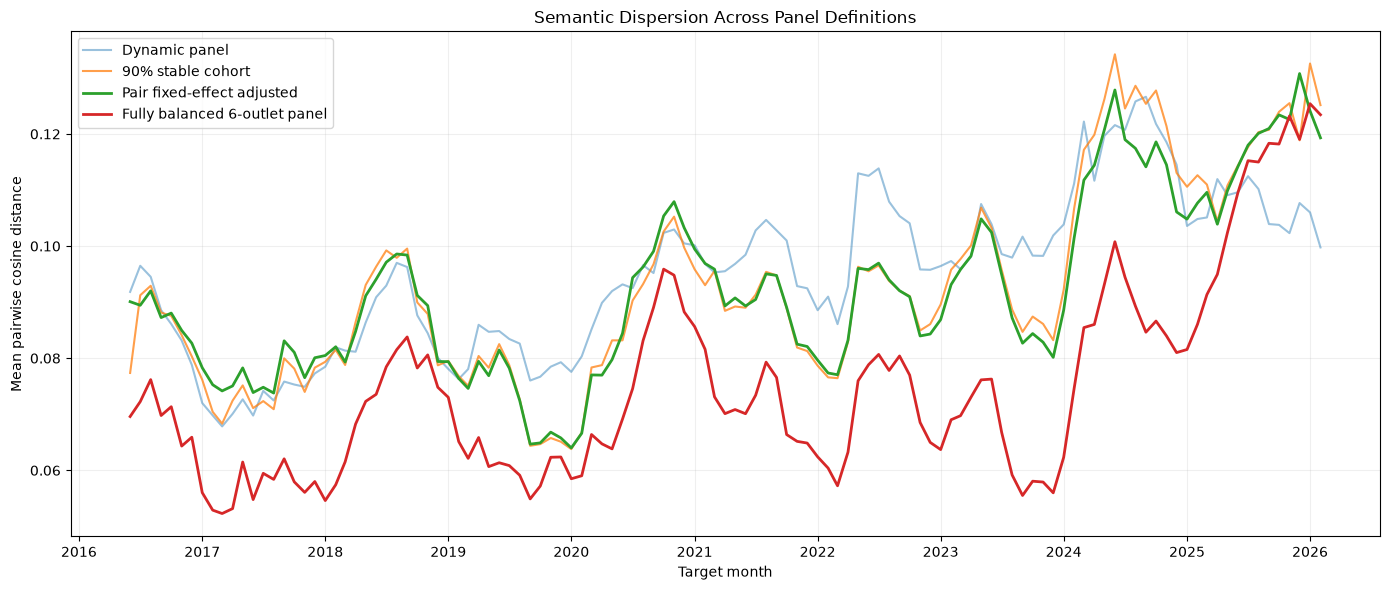

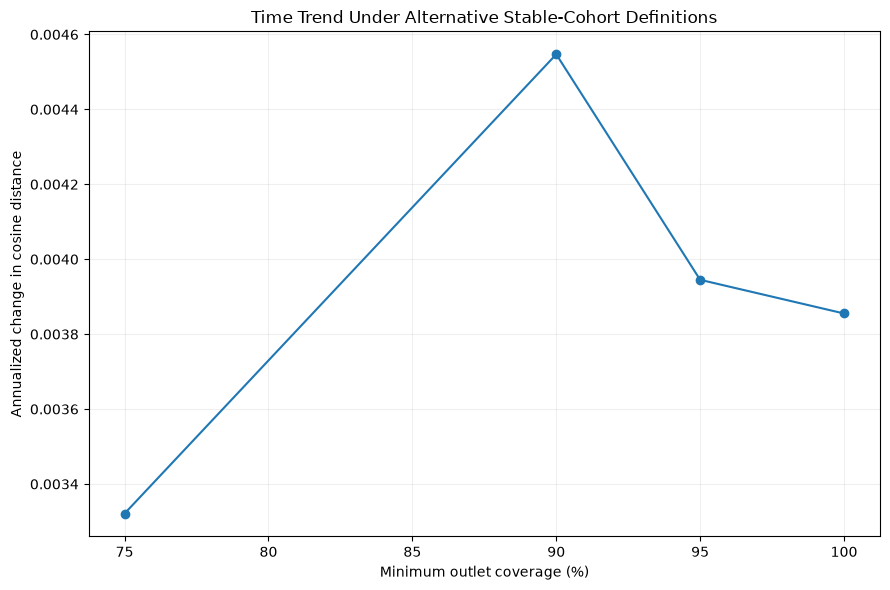

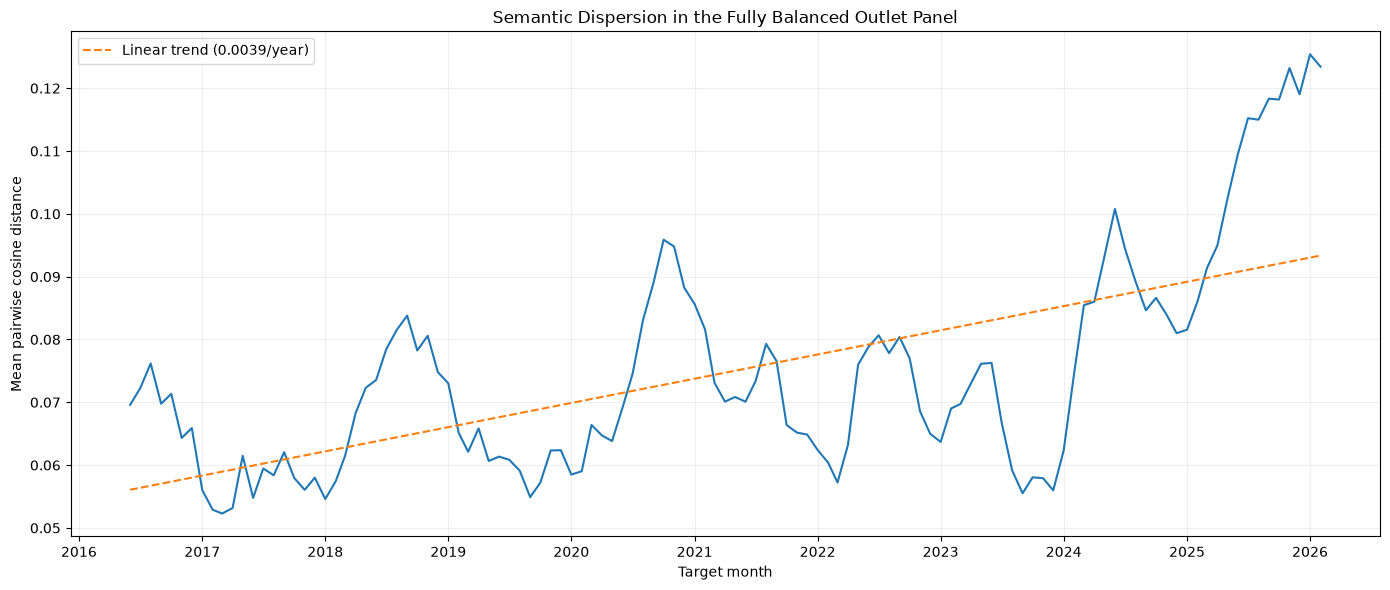

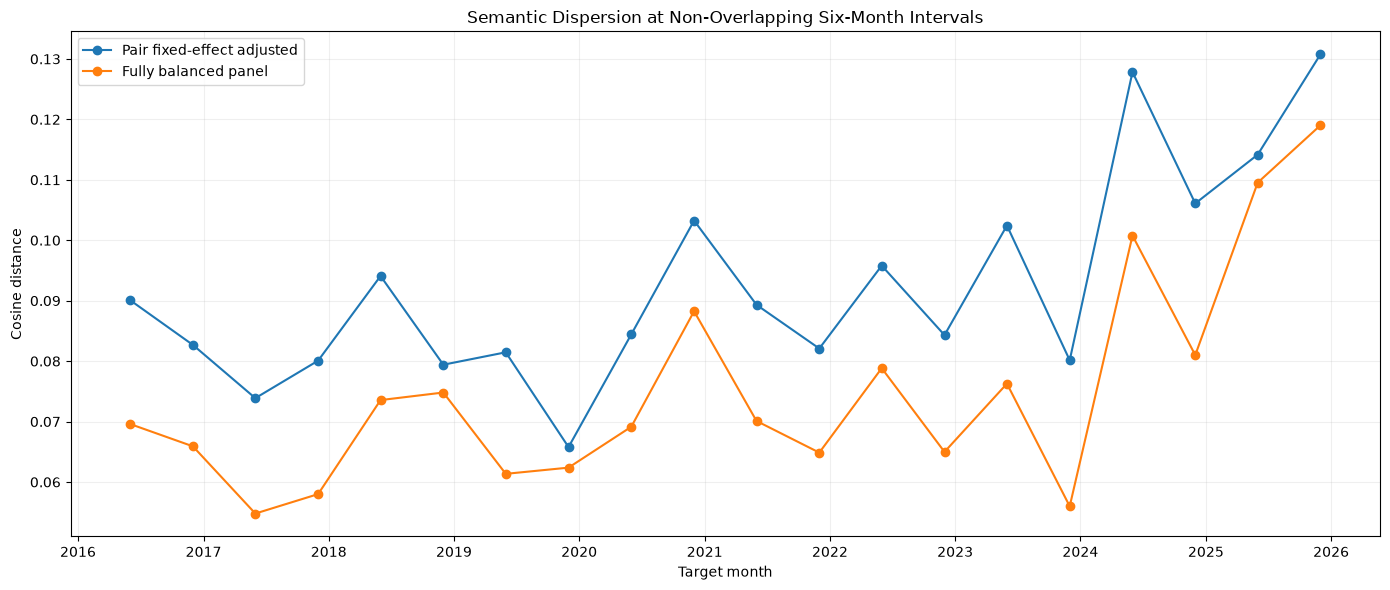


ARTIFACTS
Balanced monthly dispersion:
/Users/lasya/Documents/projects/media-polarization-lab/data/processed/balanced_panel_semantic_dispersion.parquet

Cohort sensitivity:
/Users/lasya/Documents/projects/media-polarization-lab/data/processed/cohort_threshold_sensitivity.parquet

HAC trend results:
/Users/lasya/Documents/projects/media-polarization-lab/data/processed/semantic_dispersion_hac_results.parquet

Non-overlapping snapshots:
/Users/lasya/Documents/projects/media-polarization-lab/data/processed/semantic_dispersion_nonoverlap.parquet

Early/late summary:
/Users/lasya/Documents/projects/media-polarization-lab/data/processed/semantic_dispersion_early_late_summary.parquet


In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import statsmodels.api as sm
except ImportError:
    raise ImportError(
        "statsmodels is required for this cell. "
        "Run: pip install statsmodels"
    )


# =========================================================
# CONFIGURATION
# =========================================================

COHORT_THRESHOLDS = [
    0.75,
    0.90,
    0.95,
    1.00,
]

HAC_LAGS = [
    6,
    12,
]


# =========================================================
# REBUILD BASIC OBJECTS SAFELY
# =========================================================

analysis_months = pd.Index(
    sorted(
        analysis_metadata[
            "target_month"
        ].unique()
    )
)

N_ANALYSIS_MONTHS = len(
    analysis_months
)


pair_df = (
    pairwise_semantic_distances
    .copy()
)

pair_df[
    "pair_id"
] = (
    pair_df["outlet_a"]
    + " || "
    + pair_df["outlet_b"]
)


analysis_outlet_coverage = (
    analysis_metadata
    .groupby(
        "media_name"
    )
    .agg(
        months_present=(
            "target_month",
            "nunique",
        )
    )
)

analysis_outlet_coverage[
    "coverage_fraction"
] = (
    analysis_outlet_coverage[
        "months_present"
    ]
    / N_ANALYSIS_MONTHS
)


print("=" * 75)
print("BALANCED-PANEL AND TEMPORAL ROBUSTNESS")
print("=" * 75)

print(
    f"Analysis months: "
    f"{N_ANALYSIS_MONTHS}"
)


# =========================================================
# FULLY BALANCED OUTLETS
# =========================================================

balanced_outlets = (
    analysis_outlet_coverage[
        analysis_outlet_coverage[
            "months_present"
        ] == N_ANALYSIS_MONTHS
    ]
    .index
    .tolist()
)


print("\n" + "=" * 75)
print("FULLY BALANCED OUTLET PANEL")
print("=" * 75)

print(
    f"Outlets present every month: "
    f"{len(balanced_outlets)}"
)

print(
    f"Expected outlet pairs: "
    f"{len(balanced_outlets) * (len(balanced_outlets) - 1) // 2}"
)

print("\nBalanced outlets:")

for outlet in balanced_outlets:
    print(f"  {outlet}")


# =========================================================
# PERFECTLY BALANCED PAIR TABLE
# =========================================================

balanced_pairs = (
    pair_df[
        pair_df[
            "outlet_a"
        ].isin(
            balanced_outlets
        )
        &
        pair_df[
            "outlet_b"
        ].isin(
            balanced_outlets
        )
    ]
    .copy()
)


balanced_pair_coverage = (
    balanced_pairs
    .groupby(
        "pair_id"
    )[
        "target_month"
    ]
    .nunique()
)


complete_pair_ids = (
    balanced_pair_coverage[
        balanced_pair_coverage
        == N_ANALYSIS_MONTHS
    ]
    .index
)


balanced_pairs = (
    balanced_pairs[
        balanced_pairs[
            "pair_id"
        ].isin(
            complete_pair_ids
        )
    ]
    .copy()
)


print(
    f"\nPairs present every month: "
    f"{len(complete_pair_ids)}"
)

print(
    f"Balanced pair observations: "
    f"{len(balanced_pairs):,}"
)


expected_observations = (
    len(complete_pair_ids)
    * N_ANALYSIS_MONTHS
)

print(
    f"Expected observations: "
    f"{expected_observations:,}"
)

if (
    len(balanced_pairs)
    != expected_observations
):
    raise ValueError(
        "Balanced pair panel is not complete."
    )


# =========================================================
# BALANCED MONTHLY DISPERSION
# =========================================================

balanced_monthly = (
    balanced_pairs
    .groupby(
        "target_month"
    )
    .agg(
        balanced_pairs=(
            "pair_id",
            "nunique",
        ),

        balanced_mean_distance=(
            "cosine_distance",
            "mean",
        ),

        balanced_median_distance=(
            "cosine_distance",
            "median",
        ),

        balanced_p90_distance=(
            "cosine_distance",
            lambda x:
                x.quantile(
                    0.90
                ),
        ),
    )
    .reset_index()
)


if (
    balanced_monthly[
        "balanced_pairs"
    ].nunique()
    != 1
):
    raise ValueError(
        "Number of balanced pairs changes across months."
    )


print("\n" + "=" * 75)
print("BALANCED MONTHLY DISPERSION SUMMARY")
print("=" * 75)

display(
    balanced_monthly[
        [
            "balanced_pairs",
            "balanced_mean_distance",
            "balanced_median_distance",
            "balanced_p90_distance",
        ]
    ]
    .describe()
    .round(4)
)


# =========================================================
# COHORT-THRESHOLD SENSITIVITY
# =========================================================

cohort_series = {}

cohort_summary_rows = []


for threshold in COHORT_THRESHOLDS:

    minimum_months = int(
        np.ceil(
            threshold
            * N_ANALYSIS_MONTHS
        )
    )

    cohort = (
        analysis_outlet_coverage[
            analysis_outlet_coverage[
                "months_present"
            ] >= minimum_months
        ]
        .index
        .tolist()
    )


    cohort_pairs = (
        pair_df[
            pair_df[
                "outlet_a"
            ].isin(
                cohort
            )
            &
            pair_df[
                "outlet_b"
            ].isin(
                cohort
            )
        ]
        .copy()
    )


    monthly = (
        cohort_pairs
        .groupby(
            "target_month"
        )
        .agg(
            mean_distance=(
                "cosine_distance",
                "mean",
            ),

            pairs=(
                "cosine_distance",
                "size",
            ),
        )
        .reset_index()
        .sort_values(
            "target_month"
        )
        .reset_index(
            drop=True
        )
    )


    cohort_series[
        threshold
    ] = monthly


    # -----------------------------------------------------
    # DESCRIPTIVE LINEAR TREND
    # -----------------------------------------------------

    month_dt = pd.to_datetime(
        monthly[
            "target_month"
        ]
    )

    elapsed_years = (
        (
            month_dt
            - month_dt.min()
        )
        .dt.days
        / 365.25
    )

    slope = np.polyfit(
        elapsed_years,
        monthly[
            "mean_distance"
        ],
        1,
    )[0]


    # -----------------------------------------------------
    # EARLY / MIDDLE / LATE THIRDS
    #
    # IMPORTANT:
    # split ROW INDICES, not the DataFrame itself.
    # This avoids NumPy converting the DataFrame to ndarray.
    # -----------------------------------------------------

    third_indices = np.array_split(
        np.arange(
            len(monthly)
        ),
        3,
    )

    early_period = (
        monthly.iloc[
            third_indices[0]
        ]
    )

    middle_period = (
        monthly.iloc[
            third_indices[1]
        ]
    )

    late_period = (
        monthly.iloc[
            third_indices[2]
        ]
    )


    early_mean = float(
        early_period[
            "mean_distance"
        ].mean()
    )

    middle_mean = float(
        middle_period[
            "mean_distance"
        ].mean()
    )

    late_mean = float(
        late_period[
            "mean_distance"
        ].mean()
    )


    pct_change = (
        (
            late_mean
            / early_mean
        )
        - 1
    ) * 100


    cohort_summary_rows.append({
        "coverage_threshold":
            threshold,

        "minimum_months":
            minimum_months,

        "outlets":
            len(cohort),

        "annualized_slope":
            slope,

        "early_mean":
            early_mean,

        "middle_mean":
            middle_mean,

        "late_mean":
            late_mean,

        "early_to_late_change":
            late_mean
            - early_mean,

        "early_to_late_pct_change":
            pct_change,
    })


cohort_sensitivity = (
    pd.DataFrame(
        cohort_summary_rows
    )
)


print("\n" + "=" * 75)
print("COHORT DEFINITION SENSITIVITY")
print("=" * 75)

display(
    cohort_sensitivity
    .round(5)
)


# =========================================================
# MERGE FINAL SERIES
# =========================================================

trend_data = (
    robustness_monthly[
        [
            "target_month",
            "dynamic_dispersion",
            "core_mean_distance",
            "composition_adjusted_dispersion",
        ]
    ]
    .merge(
        balanced_monthly[
            [
                "target_month",
                "balanced_mean_distance",
            ]
        ],
        on="target_month",
        how="inner",
    )
    .sort_values(
        "target_month"
    )
    .reset_index(
        drop=True
    )
)


trend_data[
    "month_dt"
] = pd.to_datetime(
    trend_data[
        "target_month"
    ]
)


trend_data[
    "elapsed_years"
] = (
    (
        trend_data[
            "month_dt"
        ]
        -
        trend_data[
            "month_dt"
        ].min()
    )
    .dt.days
    / 365.25
)


# =========================================================
# HAC REGRESSION FUNCTION
# =========================================================

def hac_trend(
    dataframe,
    y_column,
    maxlags,
):

    temp = (
        dataframe[
            [
                "elapsed_years",
                y_column,
            ]
        ]
        .dropna()
        .copy()
    )

    X = sm.add_constant(
        temp[
            "elapsed_years"
        ]
    )

    model = (
        sm.OLS(
            temp[
                y_column
            ],
            X,
        )
        .fit(
            cov_type="HAC",
            cov_kwds={
                "maxlags":
                    maxlags
            },
        )
    )

    slope = float(
        model.params[
            "elapsed_years"
        ]
    )

    se = float(
        model.bse[
            "elapsed_years"
        ]
    )

    pvalue = float(
        model.pvalues[
            "elapsed_years"
        ]
    )

    ci = (
        model.conf_int()
        .loc[
            "elapsed_years"
        ]
    )

    return {
        "annualized_slope":
            slope,

        "hac_se":
            se,

        "ci_lower":
            float(
                ci.iloc[0]
            ),

        "ci_upper":
            float(
                ci.iloc[1]
            ),

        "p_value":
            pvalue,

        "n_months":
            len(temp),
    }


# =========================================================
# HAC TREND TESTS
# =========================================================

series_map = {
    "Dynamic panel":
        "dynamic_dispersion",

    "Stable 90% cohort":
        "core_mean_distance",

    "Pair fixed-effect adjusted":
        "composition_adjusted_dispersion",

    "Fully balanced 6-outlet panel":
        "balanced_mean_distance",
}


hac_rows = []


for specification, column in (
    series_map.items()
):

    for lag in HAC_LAGS:

        result = hac_trend(
            trend_data,
            column,
            lag,
        )

        hac_rows.append({
            "specification":
                specification,

            "hac_lags":
                lag,

            **result,
        })


hac_results = (
    pd.DataFrame(
        hac_rows
    )
)


print("\n" + "=" * 75)
print("HAC / NEWEY-WEST LINEAR TREND")
print("=" * 75)

display(
    hac_results.round(6)
)


# =========================================================
# STUDY-THIRDS COMPARISON FOR FINAL SERIES
# =========================================================

ordered = (
    trend_data
    .sort_values(
        "target_month"
    )
    .reset_index(
        drop=True
    )
)


third_indices = np.array_split(
    np.arange(
        len(ordered)
    ),
    3,
)


third_rows = []


for name, idx in zip(
    [
        "early",
        "middle",
        "late",
    ],
    third_indices,
):

    subset = (
        ordered
        .iloc[
            idx
        ]
    )

    third_rows.append({
        "period":
            name,

        "months":
            len(subset),

        "dynamic":
            subset[
                "dynamic_dispersion"
            ].mean(),

        "stable_90":
            subset[
                "core_mean_distance"
            ].mean(),

        "pair_fe":
            subset[
                "composition_adjusted_dispersion"
            ].mean(),

        "fully_balanced":
            subset[
                "balanced_mean_distance"
            ].mean(),
    })


final_period_summary = (
    pd.DataFrame(
        third_rows
    )
    .set_index(
        "period"
    )
)


print("\n" + "=" * 75)
print("FINAL STUDY-PERIOD COMPARISON")
print("=" * 75)

display(
    final_period_summary
    .round(4)
)


# =========================================================
# EARLY -> LATE PERCENT CHANGE
# =========================================================

early_late_rows = []

for column_name, label in [
    (
        "dynamic_dispersion",
        "Dynamic panel",
    ),
    (
        "core_mean_distance",
        "Stable 90% cohort",
    ),
    (
        "composition_adjusted_dispersion",
        "Pair fixed-effect adjusted",
    ),
    (
        "balanced_mean_distance",
        "Fully balanced 6-outlet panel",
    ),
]:

    early_value = (
        ordered.iloc[
            third_indices[0]
        ][
            column_name
        ]
        .mean()
    )

    late_value = (
        ordered.iloc[
            third_indices[2]
        ][
            column_name
        ]
        .mean()
    )

    pct_change = (
        (
            late_value
            / early_value
        )
        - 1
    ) * 100

    early_late_rows.append({
        "specification":
            label,

        "early_mean":
            early_value,

        "late_mean":
            late_value,

        "absolute_change":
            late_value
            - early_value,

        "pct_change":
            pct_change,
    })


early_late_summary = (
    pd.DataFrame(
        early_late_rows
    )
)


print("\n" + "=" * 75)
print("EARLY TO LATE CHANGE")
print("=" * 75)

display(
    early_late_summary
    .round(5)
)


# =========================================================
# NON-OVERLAPPING SIX-MONTH SNAPSHOTS
#
# Retain every sixth observation.
#
# Since the underlying centroids use trailing six-month
# windows, this substantially reduces mechanical overlap
# between adjacent observations.
# =========================================================

nonoverlap = (
    ordered
    .iloc[
        ::6
    ]
    .copy()
    .reset_index(
        drop=True
    )
)


print("\n" + "=" * 75)
print("NON-OVERLAPPING SIX-MONTH SNAPSHOTS")
print("=" * 75)

print(
    f"Snapshots retained: "
    f"{len(nonoverlap)}"
)


nonoverlap_rows = []


for specification, column in (
    series_map.items()
):

    x = (
        nonoverlap[
            "elapsed_years"
        ]
        .to_numpy()
    )

    y = (
        nonoverlap[
            column
        ]
        .to_numpy()
    )

    slope = np.polyfit(
        x,
        y,
        1,
    )[0]

    correlation = np.corrcoef(
        x,
        y,
    )[0, 1]

    nonoverlap_rows.append({
        "specification":
            specification,

        "annualized_slope":
            slope,

        "time_correlation":
            correlation,
    })


nonoverlap_summary = (
    pd.DataFrame(
        nonoverlap_rows
    )
)


display(
    nonoverlap_summary
    .round(5)
)


# =========================================================
# SAVE FINAL ROBUSTNESS RESULTS
# =========================================================

BALANCED_MONTHLY_FILE = (
    PROCESSED_DIR
    / "balanced_panel_semantic_dispersion.parquet"
)

COHORT_SENSITIVITY_FILE = (
    PROCESSED_DIR
    / "cohort_threshold_sensitivity.parquet"
)

HAC_RESULTS_FILE = (
    PROCESSED_DIR
    / "semantic_dispersion_hac_results.parquet"
)

NONOVERLAP_FILE = (
    PROCESSED_DIR
    / "semantic_dispersion_nonoverlap.parquet"
)

EARLY_LATE_FILE = (
    PROCESSED_DIR
    / "semantic_dispersion_early_late_summary.parquet"
)


balanced_monthly.to_parquet(
    BALANCED_MONTHLY_FILE,
    index=False,
)

cohort_sensitivity.to_parquet(
    COHORT_SENSITIVITY_FILE,
    index=False,
)

hac_results.to_parquet(
    HAC_RESULTS_FILE,
    index=False,
)

nonoverlap.to_parquet(
    NONOVERLAP_FILE,
    index=False,
)

early_late_summary.to_parquet(
    EARLY_LATE_FILE,
    index=False,
)


# =========================================================
# PLOT 1
# ALL MAJOR PANEL DEFINITIONS
# =========================================================

fig, ax = plt.subplots(
    figsize=(14, 6)
)


ax.plot(
    ordered[
        "month_dt"
    ],
    ordered[
        "dynamic_dispersion"
    ],
    label="Dynamic panel",
    alpha=0.45,
)


ax.plot(
    ordered[
        "month_dt"
    ],
    ordered[
        "core_mean_distance"
    ],
    label="90% stable cohort",
    alpha=0.75,
)


ax.plot(
    ordered[
        "month_dt"
    ],
    ordered[
        "composition_adjusted_dispersion"
    ],
    label="Pair fixed-effect adjusted",
    linewidth=2,
)


ax.plot(
    ordered[
        "month_dt"
    ],
    ordered[
        "balanced_mean_distance"
    ],
    label="Fully balanced 6-outlet panel",
    linewidth=2,
)


ax.set_title(
    "Semantic Dispersion Across Panel Definitions"
)

ax.set_xlabel(
    "Target month"
)

ax.set_ylabel(
    "Mean pairwise cosine distance"
)

ax.legend()

ax.grid(
    alpha=0.2
)

plt.tight_layout()
plt.show()


# =========================================================
# PLOT 2
# COHORT THRESHOLD VS TREND
# =========================================================

fig, ax = plt.subplots(
    figsize=(9, 6)
)


ax.plot(
    cohort_sensitivity[
        "coverage_threshold"
    ] * 100,
    cohort_sensitivity[
        "annualized_slope"
    ],
    marker="o",
)


ax.set_title(
    "Time Trend Under Alternative Stable-Cohort Definitions"
)

ax.set_xlabel(
    "Minimum outlet coverage (%)"
)

ax.set_ylabel(
    "Annualized change in cosine distance"
)

ax.grid(
    alpha=0.2
)

plt.tight_layout()
plt.show()


# =========================================================
# PLOT 3
# FULLY BALANCED PANEL ONLY
# =========================================================

fig, ax = plt.subplots(
    figsize=(14, 6)
)


ax.plot(
    ordered[
        "month_dt"
    ],
    ordered[
        "balanced_mean_distance"
    ],
)


coefficients = np.polyfit(
    ordered[
        "elapsed_years"
    ],
    ordered[
        "balanced_mean_distance"
    ],
    1,
)

trend_line = np.polyval(
    coefficients,
    ordered[
        "elapsed_years"
    ],
)


ax.plot(
    ordered[
        "month_dt"
    ],
    trend_line,
    linestyle="--",
    label=(
        "Linear trend "
        f"({coefficients[0]:.4f}/year)"
    ),
)


ax.set_title(
    "Semantic Dispersion in the Fully Balanced Outlet Panel"
)

ax.set_xlabel(
    "Target month"
)

ax.set_ylabel(
    "Mean pairwise cosine distance"
)

ax.legend()

ax.grid(
    alpha=0.2
)

plt.tight_layout()
plt.show()


# =========================================================
# PLOT 4
# NON-OVERLAPPING SNAPSHOTS
# =========================================================

fig, ax = plt.subplots(
    figsize=(14, 6)
)


ax.plot(
    nonoverlap[
        "month_dt"
    ],
    nonoverlap[
        "composition_adjusted_dispersion"
    ],
    marker="o",
    label="Pair fixed-effect adjusted",
)


ax.plot(
    nonoverlap[
        "month_dt"
    ],
    nonoverlap[
        "balanced_mean_distance"
    ],
    marker="o",
    label="Fully balanced panel",
)


ax.set_title(
    "Semantic Dispersion at Non-Overlapping Six-Month Intervals"
)

ax.set_xlabel(
    "Target month"
)

ax.set_ylabel(
    "Cosine distance"
)

ax.legend()

ax.grid(
    alpha=0.2
)

plt.tight_layout()
plt.show()


# =========================================================
# FINAL OUTPUT PATHS
# =========================================================

print("\n" + "=" * 75)
print("ARTIFACTS")
print("=" * 75)

print(
    f"Balanced monthly dispersion:\n"
    f"{BALANCED_MONTHLY_FILE.resolve()}"
)

print(
    f"\nCohort sensitivity:\n"
    f"{COHORT_SENSITIVITY_FILE.resolve()}"
)

print(
    f"\nHAC trend results:\n"
    f"{HAC_RESULTS_FILE.resolve()}"
)

print(
    f"\nNon-overlapping snapshots:\n"
    f"{NONOVERLAP_FILE.resolve()}"
)

print(
    f"\nEarly/late summary:\n"
    f"{EARLY_LATE_FILE.resolve()}"
)

## 30. Climate-Dimension Profiles

The preceding analysis establishes a robust increase in semantic dispersion
across news outlets.

The next question is what semantic differences are responsible for that
divergence.

Each outlet-month centroid is compared with six interpretable climate anchors:

- climate science
- emissions and fossil fuels
- clean-energy transition
- climate policy
- climate impacts
- adaptation and resilience

Because these semantic anchors are not orthogonal, their cosine similarities
should not be interpreted as statistically independent dimensions.

Two representations are therefore retained:

1. **Raw anchor similarity** — absolute semantic proximity to each theme.
2. **Relative thematic emphasis** — an outlet-month's score for one anchor
   minus its mean score across all six anchors.

The relative score captures whether a theme is unusually emphasized within an
outlet's climate coverage while controlling for its general proximity to
climate-related language.

We then measure how cross-outlet variation in each theme changes through time.

CLIMATE-DIMENSION PROFILE ANALYSIS
Centroid matrix: (7378, 384)
Metadata rows: 7,378
Climate anchors: 6
Anchor matrix: (6, 384)
Centroid norm range after normalization: 1.000000 – 1.000000
Score matrix: (7378, 6)

PROFILE VALIDATION
Maximum absolute relative-score sum: 0.0000005066

RAW ANCHOR SIMILARITY DISTRIBUTION


,count,mean,std,min,25%,50%,75%,max
raw_climate_science,7378.0,0.6203,0.0423,0.4277,0.5951,0.6235,0.6482,0.7533
raw_emissions_fossil_fuels,7378.0,0.4651,0.0448,0.2278,0.4386,0.4673,0.4945,0.6097
raw_clean_energy_transition,7378.0,0.2532,0.0443,0.1218,0.2250,0.2505,0.2755,0.4569
raw_climate_policy,7378.0,0.5543,0.0500,0.3141,0.5241,0.5581,0.5893,0.6893
raw_climate_impacts,7378.0,0.5331,0.0707,0.3224,0.4848,0.5327,0.5825,0.7509
raw_adaptation_resilience,7378.0,0.4429,0.0448,0.2733,0.4150,0.4447,0.4755,0.5825



RELATIVE THEMATIC EMPHASIS DISTRIBUTION


,count,mean,std,min,25%,50%,75%,max
relative_climate_science,7378.0,0.1421,0.0362,0.0093,0.1187,0.1427,0.1673,0.2672
relative_emissions_fossil_fuels,7378.0,-0.0131,0.0372,-0.1597,-0.0359,-0.0131,0.0104,0.1330
relative_clean_energy_transition,7378.0,-0.2250,0.0397,-0.3163,-0.2512,-0.2305,-0.2062,-0.0325
relative_climate_policy,7378.0,0.0762,0.0445,-0.0775,0.0470,0.0766,0.1071,0.2225
relative_climate_impacts,7378.0,0.0550,0.0686,-0.1502,0.0082,0.0475,0.0990,0.2970
relative_adaptation_resilience,7378.0,-0.0353,0.0406,-0.1613,-0.0636,-0.0376,-0.0105,0.1345



RAW ANCHOR SCORE CORRELATIONS


...

,relative_emphasis
media_name,
forbes.com,-0.0429
dailycaller.com,-0.0329
cnbc.com,-0.0203
marketwatch.com,-0.0198
reuters.com,-0.0118
politico.com,-0.0096
breitbart.com,-0.0040
qz.com,-0.0022



------------------------------------------------------------
ADAPTATION_RESILIENCE
------------------------------------------------------------

Highest relative emphasis:


,relative_emphasis
media_name,
sun-sentinel.com,0.0303
staradvertiser.com,0.0246
mercurynews.com,0.0116
sandiegouniontribune.com,0.0098
ocregister.com,0.0062
centralmaine.com,0.0059
azcentral.com,-0.0030
latimes.com,-0.0031


Lowest relative emphasis:


,relative_emphasis
media_name,
dailycaller.com,-0.0997
denverpost.com,-0.0767
stltoday.com,-0.0745
cnbc.com,-0.0744
breitbart.com,-0.0702
newsmax.com,-0.0697
reuters.com,-0.0697
marketwatch.com,-0.0677


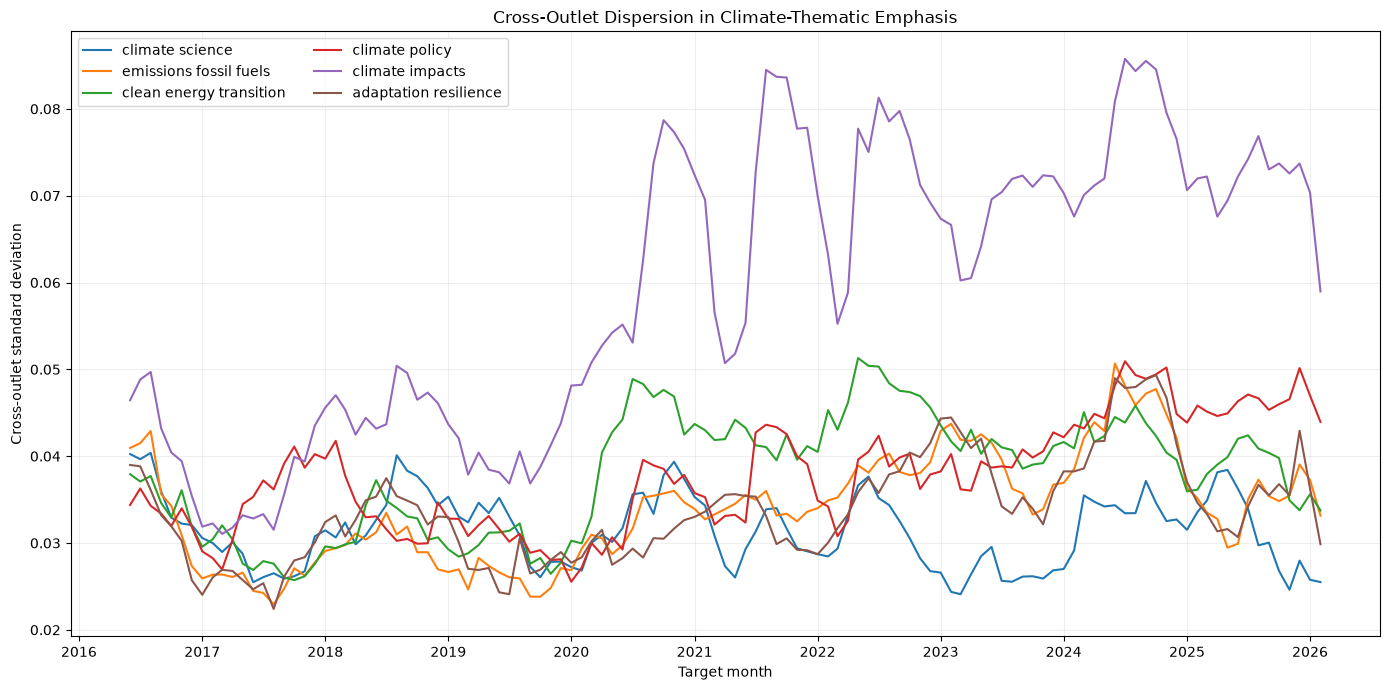

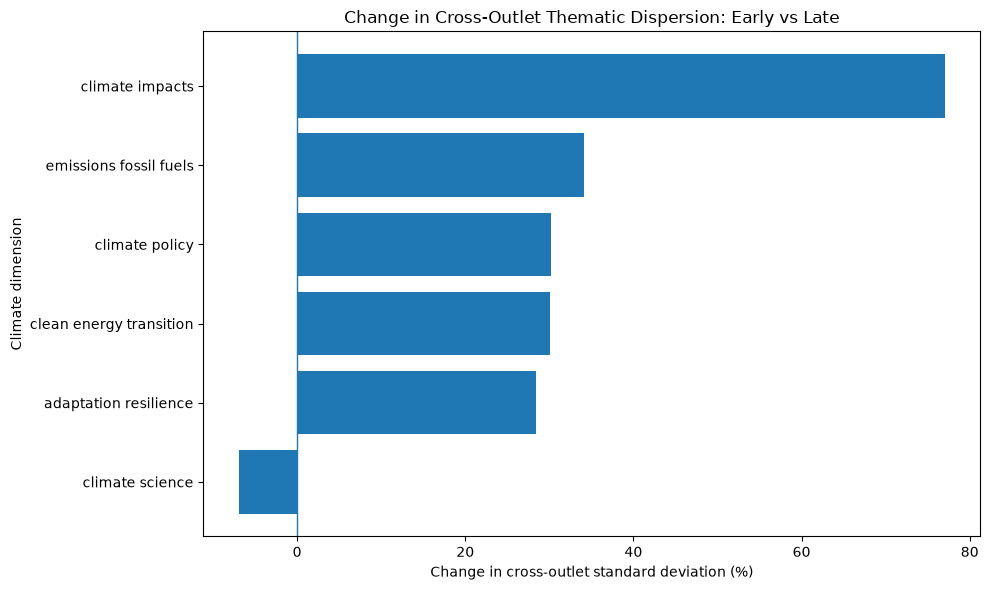

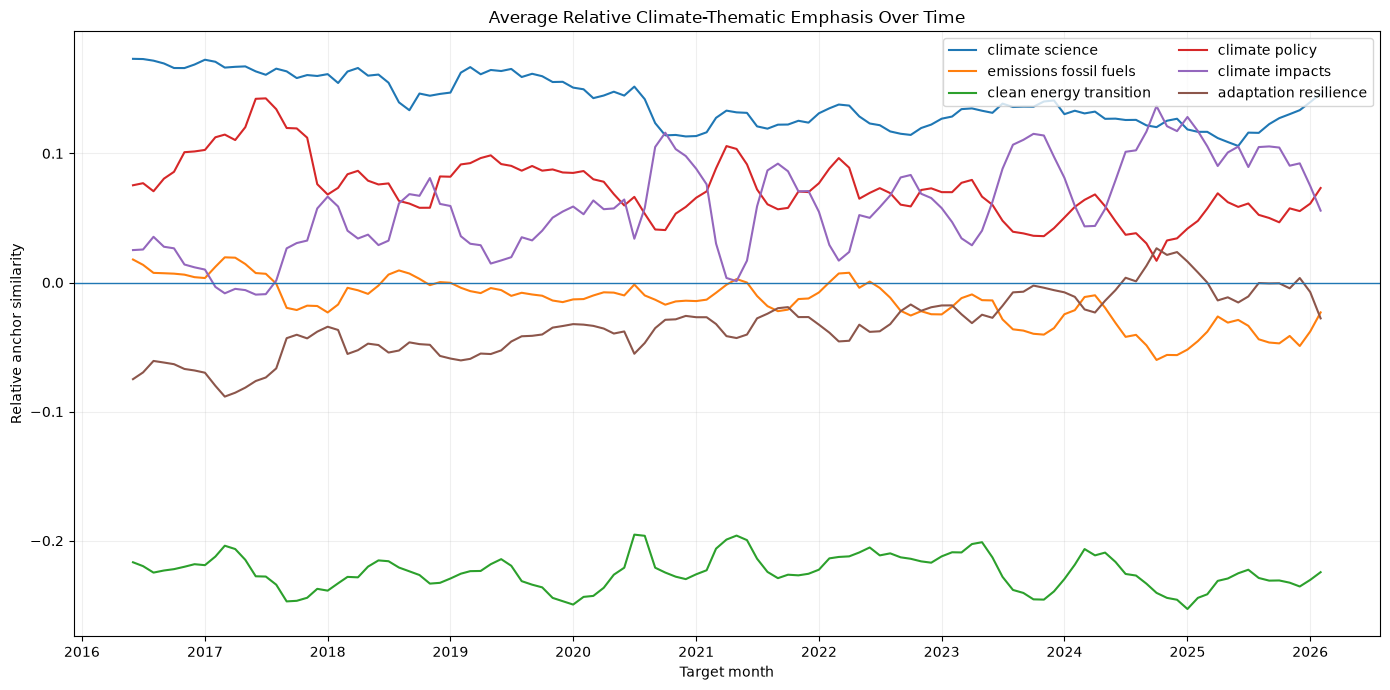


ARTIFACTS

Outlet-month dimension profiles:
/Users/lasya/Documents/projects/media-polarization-lab/data/processed/outlet_month_climate_dimension_profiles.parquet

Monthly thematic dispersion:
/Users/lasya/Documents/projects/media-polarization-lab/data/processed/monthly_climate_dimension_dispersion.parquet

Early/late thematic change:
/Users/lasya/Documents/projects/media-polarization-lab/data/processed/climate_dimension_dispersion_change.parquet

Thematic trend summary:
/Users/lasya/Documents/projects/media-polarization-lab/data/processed/climate_dimension_dispersion_trends.parquet

Long-run outlet profiles:
/Users/lasya/Documents/projects/media-polarization-lab/data/processed/outlet_longrun_climate_profiles.parquet


In [54]:
# ============================================================
# CELL 30 — CLIMATE-DIMENSION PROFILE ANALYSIS
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer


# ============================================================
# PATHS
# ============================================================

if "PROCESSED_DIR" not in globals():
    PROCESSED_DIR = Path("data/processed")

PROCESSED_DIR = Path(PROCESSED_DIR)


CENTROID_VECTOR_FILE = (
    PROCESSED_DIR
    / "analysis_outlet_month_centroids.npy"
)

CENTROID_METADATA_FILE = (
    PROCESSED_DIR
    / "analysis_outlet_month_metadata.parquet"
)


# ============================================================
# CLIMATE SEMANTIC ANCHORS
#
# These correspond to the six interpretable climate dimensions
# developed earlier in the notebook.
#
# Keep these definitions fixed from this point forward.
# ============================================================

ANCHOR_TEXTS = {

    "climate_science": (
        "climate change global warming greenhouse effect "
        "climate science temperature warming scientific evidence "
        "climate research atmospheric science"
    ),

    "emissions_fossil_fuels": (
        "carbon emissions greenhouse gas emissions fossil fuels "
        "coal oil natural gas carbon dioxide methane pollution "
        "decarbonization emissions reduction"
    ),

    "clean_energy_transition": (
        "renewable energy clean energy solar power wind power "
        "electric vehicles batteries energy transition "
        "green technology low carbon energy"
    ),

    "climate_policy": (
        "climate policy Paris Agreement carbon tax climate legislation "
        "environmental regulation government climate action "
        "emissions policy international climate negotiations"
    ),

    "climate_impacts": (
        "climate impacts extreme heat drought wildfires flooding "
        "hurricanes sea level rise melting ice climate disasters "
        "extreme weather"
    ),

    "adaptation_resilience": (
        "climate adaptation climate resilience climate preparedness "
        "disaster resilience infrastructure adaptation "
        "coastal protection water management climate risk"
    ),
}


ANCHOR_NAMES = list(
    ANCHOR_TEXTS.keys()
)


# ============================================================
# LOAD MODEL IF NECESSARY
# ============================================================

if "model" not in globals():

    print(
        "Embedding model not found in notebook memory."
    )

    print(
        "Loading sentence-transformers/all-MiniLM-L6-v2..."
    )

    model = SentenceTransformer(
        "sentence-transformers/all-MiniLM-L6-v2"
    )


# ============================================================
# LOAD PRODUCTION CENTROIDS
# ============================================================

centroid_vectors = np.load(
    CENTROID_VECTOR_FILE
)

centroid_meta = pd.read_parquet(
    CENTROID_METADATA_FILE
)


print("=" * 75)
print("CLIMATE-DIMENSION PROFILE ANALYSIS")
print("=" * 75)

print(
    f"Centroid matrix: "
    f"{centroid_vectors.shape}"
)

print(
    f"Metadata rows: "
    f"{len(centroid_meta):,}"
)

print(
    f"Climate anchors: "
    f"{len(ANCHOR_NAMES)}"
)


# ============================================================
# VALIDATE PRODUCTION ARTIFACTS
# ============================================================

if len(
    centroid_vectors
) != len(
    centroid_meta
):
    raise ValueError(
        "Centroid vectors and metadata are not aligned."
    )


required_columns = {
    "media_name",
    "target_month",
}

missing_columns = (
    required_columns
    - set(
        centroid_meta.columns
    )
)

if missing_columns:
    raise ValueError(
        "Missing metadata columns: "
        f"{sorted(missing_columns)}"
    )


if centroid_vectors.shape[1] != 384:
    raise ValueError(
        "Expected 384-dimensional MiniLM embeddings, "
        f"found {centroid_vectors.shape[1]}."
    )


# ============================================================
# ENCODE CLIMATE ANCHORS
# ============================================================

anchor_text_list = [
    ANCHOR_TEXTS[
        anchor
    ]
    for anchor in ANCHOR_NAMES
]


anchor_vectors = model.encode(
    anchor_text_list,
    normalize_embeddings=True,
    show_progress_bar=False,
)

anchor_vectors = np.asarray(
    anchor_vectors,
    dtype=np.float32,
)


print(
    f"Anchor matrix: "
    f"{anchor_vectors.shape}"
)


if (
    anchor_vectors.shape[1]
    != centroid_vectors.shape[1]
):
    raise ValueError(
        "Anchor and centroid embedding dimensions differ."
    )


# ============================================================
# NORMALIZE CENTROID VECTORS
#
# Production centroids should already be normalized, but this
# guarantees that matrix multiplication below is cosine
# similarity.
# ============================================================

centroid_norms = np.linalg.norm(
    centroid_vectors,
    axis=1,
    keepdims=True,
)

centroid_vectors_norm = (
    centroid_vectors
    / np.clip(
        centroid_norms,
        1e-12,
        None,
    )
)


anchor_norms = np.linalg.norm(
    anchor_vectors,
    axis=1,
    keepdims=True,
)

anchor_vectors_norm = (
    anchor_vectors
    / np.clip(
        anchor_norms,
        1e-12,
        None,
    )
)


print(
    "Centroid norm range after normalization: "
    f"{np.linalg.norm(centroid_vectors_norm, axis=1).min():.6f}"
    " – "
    f"{np.linalg.norm(centroid_vectors_norm, axis=1).max():.6f}"
)


# ============================================================
# OUTLET-MONTH × CLIMATE-ANCHOR SIMILARITY
# ============================================================

anchor_scores = (
    centroid_vectors_norm
    @ anchor_vectors_norm.T
)


print(
    f"Score matrix: "
    f"{anchor_scores.shape}"
)


# ============================================================
# CREATE OUTLET-MONTH DIMENSION PROFILE TABLE
# ============================================================

dimension_profiles = (
    centroid_meta
    .copy()
    .reset_index(
        drop=True
    )
)


for idx, anchor in enumerate(
    ANCHOR_NAMES
):

    dimension_profiles[
        f"raw_{anchor}"
    ] = anchor_scores[
        :,
        idx,
    ]


raw_columns = [
    f"raw_{anchor}"
    for anchor in ANCHOR_NAMES
]


# ============================================================
# RELATIVE THEMATIC EMPHASIS
#
# A centroid may have relatively high similarity to all climate
# anchors simply because it is strongly climate-related.
#
# Therefore:
#
# relative theme score
# =
# anchor similarity
# -
# outlet-month average across all six anchors
#
# This makes the dimensions interpretable as relative thematic
# emphasis within the outlet's climate coverage.
# ============================================================

dimension_profiles[
    "mean_anchor_similarity"
] = (
    dimension_profiles[
        raw_columns
    ]
    .mean(
        axis=1
    )
)


for anchor in ANCHOR_NAMES:

    dimension_profiles[
        f"relative_{anchor}"
    ] = (
        dimension_profiles[
            f"raw_{anchor}"
        ]
        -
        dimension_profiles[
            "mean_anchor_similarity"
        ]
    )


relative_columns = [
    f"relative_{anchor}"
    for anchor in ANCHOR_NAMES
]


# ============================================================
# PROFILE VALIDATION
# ============================================================

relative_sum = (
    dimension_profiles[
        relative_columns
    ]
    .sum(
        axis=1
    )
)


print("\n" + "=" * 75)
print("PROFILE VALIDATION")
print("=" * 75)

print(
    "Maximum absolute relative-score sum: "
    f"{relative_sum.abs().max():.10f}"
)


# ============================================================
# RAW SCORE DISTRIBUTIONS
# ============================================================

print("\n" + "=" * 75)
print("RAW ANCHOR SIMILARITY DISTRIBUTION")
print("=" * 75)

raw_summary = (
    dimension_profiles[
        raw_columns
    ]
    .describe()
    .T
)

display(
    raw_summary.round(4)
)


# ============================================================
# RELATIVE SCORE DISTRIBUTIONS
# ============================================================

print("\n" + "=" * 75)
print("RELATIVE THEMATIC EMPHASIS DISTRIBUTION")
print("=" * 75)

relative_summary = (
    dimension_profiles[
        relative_columns
    ]
    .describe()
    .T
)

display(
    relative_summary.round(4)
)


# ============================================================
# ANCHOR CORRELATIONS
#
# The anchor concepts overlap semantically.
#
# We explicitly measure that overlap rather than treating the
# six anchors as orthogonal latent dimensions.
# ============================================================

anchor_correlations = (
    dimension_profiles[
        raw_columns
    ]
    .corr()
)


print("\n" + "=" * 75)
print("RAW ANCHOR SCORE CORRELATIONS")
print("=" * 75)

display(
    anchor_correlations.round(3)
)


# ============================================================
# MONTHLY CROSS-OUTLET THEMATIC DISPERSION
#
# For each target month and each climate theme:
#
#   mean = average relative emphasis
#   std  = cross-outlet dispersion
#   iqr  = robust cross-outlet dispersion
# ============================================================

monthly_dimension_rows = []


for target_month, group in (
    dimension_profiles
    .groupby(
        "target_month"
    )
):

    row = {

        "target_month":
            target_month,

        "outlets":
            group[
                "media_name"
            ].nunique(),
    }


    for anchor in ANCHOR_NAMES:

        values = (
            group[
                f"relative_{anchor}"
            ]
            .dropna()
        )


        row[
            f"{anchor}_mean"
        ] = values.mean()


        row[
            f"{anchor}_std"
        ] = values.std()


        row[
            f"{anchor}_iqr"
        ] = (
            values.quantile(
                0.75
            )
            -
            values.quantile(
                0.25
            )
        )


    monthly_dimension_rows.append(
        row
    )


monthly_dimension_dispersion = (
    pd.DataFrame(
        monthly_dimension_rows
    )
    .sort_values(
        "target_month"
    )
    .reset_index(
        drop=True
    )
)


print("\n" + "=" * 75)
print("MONTHLY DIMENSION DATASET")
print("=" * 75)

print(
    f"Months: "
    f"{len(monthly_dimension_dispersion)}"
)

print(
    "Outlet range per month: "
    f"{monthly_dimension_dispersion['outlets'].min()}"
    " – "
    f"{monthly_dimension_dispersion['outlets'].max()}"
)


# ============================================================
# STUDY-PERIOD THIRDS
# ============================================================

third_indices = np.array_split(
    np.arange(
        len(
            monthly_dimension_dispersion
        )
    ),
    3,
)


period_rows = []


for period_name, idx in zip(

    [
        "early",
        "middle",
        "late",
    ],

    third_indices,
):

    subset = (
        monthly_dimension_dispersion
        .iloc[
            idx
        ]
    )


    for anchor in ANCHOR_NAMES:

        period_rows.append({

            "period":
                period_name,

            "anchor":
                anchor,

            "mean_cross_outlet_std":
                subset[
                    f"{anchor}_std"
                ].mean(),

            "mean_cross_outlet_iqr":
                subset[
                    f"{anchor}_iqr"
                ].mean(),
        })


dimension_period_summary = (
    pd.DataFrame(
        period_rows
    )
)


print("\n" + "=" * 75)
print("THEMATIC DISPERSION BY STUDY PERIOD")
print("=" * 75)

display(
    dimension_period_summary
    .round(5)
)


# ============================================================
# EARLY → LATE DISPERSION CHANGE
# ============================================================

early_dimension = (
    dimension_period_summary[
        dimension_period_summary[
            "period"
        ] == "early"
    ]
    .set_index(
        "anchor"
    )
)


late_dimension = (
    dimension_period_summary[
        dimension_period_summary[
            "period"
        ] == "late"
    ]
    .set_index(
        "anchor"
    )
)


dimension_change_rows = []


for anchor in ANCHOR_NAMES:

    early_std = float(
        early_dimension.loc[
            anchor,
            "mean_cross_outlet_std",
        ]
    )

    late_std = float(
        late_dimension.loc[
            anchor,
            "mean_cross_outlet_std",
        ]
    )


    early_iqr = float(
        early_dimension.loc[
            anchor,
            "mean_cross_outlet_iqr",
        ]
    )

    late_iqr = float(
        late_dimension.loc[
            anchor,
            "mean_cross_outlet_iqr",
        ]
    )


    dimension_change_rows.append({

        "anchor":
            anchor,

        "early_std":
            early_std,

        "late_std":
            late_std,

        "std_absolute_change":
            late_std
            - early_std,

        "std_pct_change":
            (
                (
                    late_std
                    / early_std
                )
                - 1
            )
            * 100,

        "early_iqr":
            early_iqr,

        "late_iqr":
            late_iqr,

        "iqr_absolute_change":
            late_iqr
            - early_iqr,

        "iqr_pct_change":
            (
                (
                    late_iqr
                    / early_iqr
                )
                - 1
            )
            * 100,
    })


dimension_change_summary = (
    pd.DataFrame(
        dimension_change_rows
    )
    .sort_values(
        "std_pct_change",
        ascending=False,
    )
    .reset_index(
        drop=True
    )
)


print("\n" + "=" * 75)
print("EARLY → LATE THEMATIC DISPERSION CHANGE")
print("=" * 75)

display(
    dimension_change_summary
    .round(4)
)


# ============================================================
# LINEAR TIME TREND FOR EACH THEMATIC DISPERSION SERIES
# ============================================================

month_dt = pd.to_datetime(
    monthly_dimension_dispersion[
        "target_month"
    ]
)


elapsed_years = (
    (
        month_dt
        - month_dt.min()
    )
    .dt.days
    / 365.25
)


dimension_trend_rows = []


for anchor in ANCHOR_NAMES:

    y = (
        monthly_dimension_dispersion[
            f"{anchor}_std"
        ]
        .to_numpy()
    )


    slope = np.polyfit(
        elapsed_years,
        y,
        1,
    )[0]


    correlation = np.corrcoef(
        elapsed_years,
        y,
    )[0, 1]


    dimension_trend_rows.append({

        "anchor":
            anchor,

        "annualized_std_change":
            slope,

        "time_correlation":
            correlation,
    })


dimension_trends = (
    pd.DataFrame(
        dimension_trend_rows
    )
    .sort_values(
        "annualized_std_change",
        ascending=False,
    )
    .reset_index(
        drop=True
    )
)


print("\n" + "=" * 75)
print("THEMATIC DISPERSION TIME TRENDS")
print("=" * 75)

display(
    dimension_trends
    .round(6)
)


# ============================================================
# LONG-RUN OUTLET THEMATIC PROFILES
#
# Require at least 60 outlet-month observations so sparse
# publishers do not dominate the ranking.
# ============================================================

outlet_profile_counts = (
    dimension_profiles
    .groupby(
        "media_name"
    )[
        "target_month"
    ]
    .nunique()
)


well_covered_outlets = (
    outlet_profile_counts[
        outlet_profile_counts
        >= 60
    ]
    .index
)


outlet_longrun_profiles = (
    dimension_profiles[
        dimension_profiles[
            "media_name"
        ].isin(
            well_covered_outlets
        )
    ]
    .groupby(
        "media_name"
    )[
        relative_columns
    ]
    .mean()
)


print("\n" + "=" * 75)
print("LONG-RUN OUTLET PROFILE SAMPLE")
print("=" * 75)

print(
    f"Outlets with >=60 months: "
    f"{len(outlet_longrun_profiles)}"
)


# ============================================================
# THEMATIC EXTREMES
# ============================================================

print("\n" + "=" * 75)
print("LONG-RUN OUTLET THEMATIC EXTREMES")
print("=" * 75)


for anchor in ANCHOR_NAMES:

    column = (
        f"relative_{anchor}"
    )


    print(
        f"\n{'-' * 60}"
    )

    print(
        anchor.upper()
    )

    print(
        "-" * 60
    )


    print(
        "\nHighest relative emphasis:"
    )

    display(
        outlet_longrun_profiles[
            column
        ]
        .sort_values(
            ascending=False
        )
        .head(
            8
        )
        .to_frame(
            "relative_emphasis"
        )
        .round(
            4
        )
    )


    print(
        "Lowest relative emphasis:"
    )

    display(
        outlet_longrun_profiles[
            column
        ]
        .sort_values(
            ascending=True
        )
        .head(
            8
        )
        .to_frame(
            "relative_emphasis"
        )
        .round(
            4
        )
    )


# ============================================================
# SAVE ARTIFACTS
# ============================================================

DIMENSION_PROFILE_FILE = (
    PROCESSED_DIR
    / "outlet_month_climate_dimension_profiles.parquet"
)

MONTHLY_DIMENSION_FILE = (
    PROCESSED_DIR
    / "monthly_climate_dimension_dispersion.parquet"
)

DIMENSION_CHANGE_FILE = (
    PROCESSED_DIR
    / "climate_dimension_dispersion_change.parquet"
)

DIMENSION_TREND_FILE = (
    PROCESSED_DIR
    / "climate_dimension_dispersion_trends.parquet"
)

OUTLET_LONGRUN_FILE = (
    PROCESSED_DIR
    / "outlet_longrun_climate_profiles.parquet"
)


dimension_profiles.to_parquet(
    DIMENSION_PROFILE_FILE,
    index=False,
)


monthly_dimension_dispersion.to_parquet(
    MONTHLY_DIMENSION_FILE,
    index=False,
)


dimension_change_summary.to_parquet(
    DIMENSION_CHANGE_FILE,
    index=False,
)


dimension_trends.to_parquet(
    DIMENSION_TREND_FILE,
    index=False,
)


outlet_longrun_profiles.reset_index().to_parquet(
    OUTLET_LONGRUN_FILE,
    index=False,
)


# ============================================================
# PLOT 1 — THEMATIC DISPERSION OVER TIME
# ============================================================

fig, ax = plt.subplots(
    figsize=(14, 7)
)


for anchor in ANCHOR_NAMES:

    ax.plot(
        month_dt,
        monthly_dimension_dispersion[
            f"{anchor}_std"
        ],
        label=anchor.replace(
            "_",
            " "
        ),
    )


ax.set_title(
    "Cross-Outlet Dispersion in Climate-Thematic Emphasis"
)

ax.set_xlabel(
    "Target month"
)

ax.set_ylabel(
    "Cross-outlet standard deviation"
)

ax.legend(
    ncol=2
)

ax.grid(
    alpha=0.2
)

plt.tight_layout()

plt.show()


# ============================================================
# PLOT 2 — EARLY VS LATE THEMATIC DISPERSION
# ============================================================

plot_change = (
    dimension_change_summary
    .sort_values(
        "std_pct_change"
    )
)


fig, ax = plt.subplots(
    figsize=(10, 6)
)


ax.barh(
    plot_change[
        "anchor"
    ]
    .str.replace(
        "_",
        " "
    ),
    plot_change[
        "std_pct_change"
    ],
)


ax.axvline(
    0,
    linewidth=1,
)


ax.set_title(
    "Change in Cross-Outlet Thematic Dispersion: Early vs Late"
)

ax.set_xlabel(
    "Change in cross-outlet standard deviation (%)"
)

ax.set_ylabel(
    "Climate dimension"
)


plt.tight_layout()

plt.show()


# ============================================================
# PLOT 3 — MEAN THEMATIC EMPHASIS OVER TIME
# ============================================================

monthly_relative_means = (
    dimension_profiles
    .groupby(
        "target_month"
    )[
        relative_columns
    ]
    .mean()
    .reset_index()
)


monthly_mean_dt = pd.to_datetime(
    monthly_relative_means[
        "target_month"
    ]
)


fig, ax = plt.subplots(
    figsize=(14, 7)
)


for anchor in ANCHOR_NAMES:

    ax.plot(
        monthly_mean_dt,
        monthly_relative_means[
            f"relative_{anchor}"
        ],
        label=anchor.replace(
            "_",
            " "
        ),
    )


ax.axhline(
    0,
    linewidth=1,
)


ax.set_title(
    "Average Relative Climate-Thematic Emphasis Over Time"
)

ax.set_xlabel(
    "Target month"
)

ax.set_ylabel(
    "Relative anchor similarity"
)

ax.legend(
    ncol=2
)

ax.grid(
    alpha=0.2
)


plt.tight_layout()

plt.show()


# ============================================================
# FINAL ARTIFACT SUMMARY
# ============================================================

print("\n" + "=" * 75)
print("ARTIFACTS")
print("=" * 75)

print(
    "\nOutlet-month dimension profiles:"
)

print(
    DIMENSION_PROFILE_FILE.resolve()
)


print(
    "\nMonthly thematic dispersion:"
)

print(
    MONTHLY_DIMENSION_FILE.resolve()
)


print(
    "\nEarly/late thematic change:"
)

print(
    DIMENSION_CHANGE_FILE.resolve()
)


print(
    "\nThematic trend summary:"
)

print(
    DIMENSION_TREND_FILE.resolve()
)


print(
    "\nLong-run outlet profiles:"
)

print(
    OUTLET_LONGRUN_FILE.resolve()
)

THEMATIC DISPERSION ROBUSTNESS
Input:  /Users/lasya/Documents/projects/media-polarization-lab/data/processed/outlet_month_climate_dimension_profiles.parquet
Output: /Users/lasya/Documents/projects/media-polarization-lab/data/processed/climate_dimension_panel_robustness.parquet

Rows loaded: 7,378
Columns:
['centroid_row', 'media_name', 'target_month', 'target_year', 'target_month_number', 'window_start', 'window_end', 'window_months', 'window_climate_articles', 'current_month_climate_articles', 'observed_months_in_window', 'centroid_concentration', 'mean_climate_relevance', 'median_climate_relevance', 'dominant_climate_anchor', 'source_centroid_row', 'analysis_centroid_row', 'raw_climate_science', 'raw_emissions_fossil_fuels', 'raw_clean_energy_transition', 'raw_climate_policy', 'raw_climate_impacts', 'raw_adaptation_resilience', 'mean_anchor_similarity', 'relative_climate_science', 'relative_emissions_fossil_fuels', 'relative_clean_energy_transition', 'relative_climate_policy', 'relat

,panel,anchor,early_std,late_std,std_pct_change,annualized_std_change,time_correlation
0,dynamic_panel,adaptation_resilience,0.0302,0.0388,28.4743,0.0012,0.5767
1,fully_balanced,adaptation_resilience,0.0201,0.0288,42.8184,0.0013,0.5102
2,stable_90,adaptation_resilience,0.0298,0.0406,36.4366,0.0016,0.5731
3,dynamic_panel,clean_energy_transition,0.0312,0.0405,30.1022,0.0014,0.5793
4,fully_balanced,clean_energy_transition,0.0211,0.0174,-17.4078,-0.0007,-0.2595
5,stable_90,clean_energy_transition,0.0292,0.0332,13.8028,0.0008,0.3721
6,dynamic_panel,climate_impacts,0.0408,0.0721,77.0242,0.0048,0.8243
7,fully_balanced,climate_impacts,0.0266,0.0597,124.7121,0.0049,0.7620
8,stable_90,climate_impacts,0.0389,0.0764,96.5586,0.0057,0.8656
9,dynamic_panel,climate_policy,0.0337,0.0439,30.2160,0.0016,0.7354



EARLY → LATE % CHANGE BY PANEL


panel,dynamic_panel,fully_balanced,stable_90
anchor,,,
climate_impacts,77.02,124.71,96.56
climate_policy,30.22,97.14,59.98
emissions_fossil_fuels,34.09,163.42,58.66
clean_energy_transition,30.10,-17.41,13.80
adaptation_resilience,28.47,42.82,36.44
climate_science,-6.95,1.74,5.05



ANNUALIZED THEMATIC DISPERSION TREND BY PANEL


panel,dynamic_panel,fully_balanced,stable_90
anchor,,,
climate_impacts,0.004789,0.004926,0.005720
climate_policy,0.001621,0.003196,0.002688
emissions_fossil_fuels,0.001347,0.003746,0.002384
clean_energy_transition,0.001373,-0.000710,0.000765
adaptation_resilience,0.001212,0.001338,0.001601
climate_science,-0.000200,0.000200,0.000421


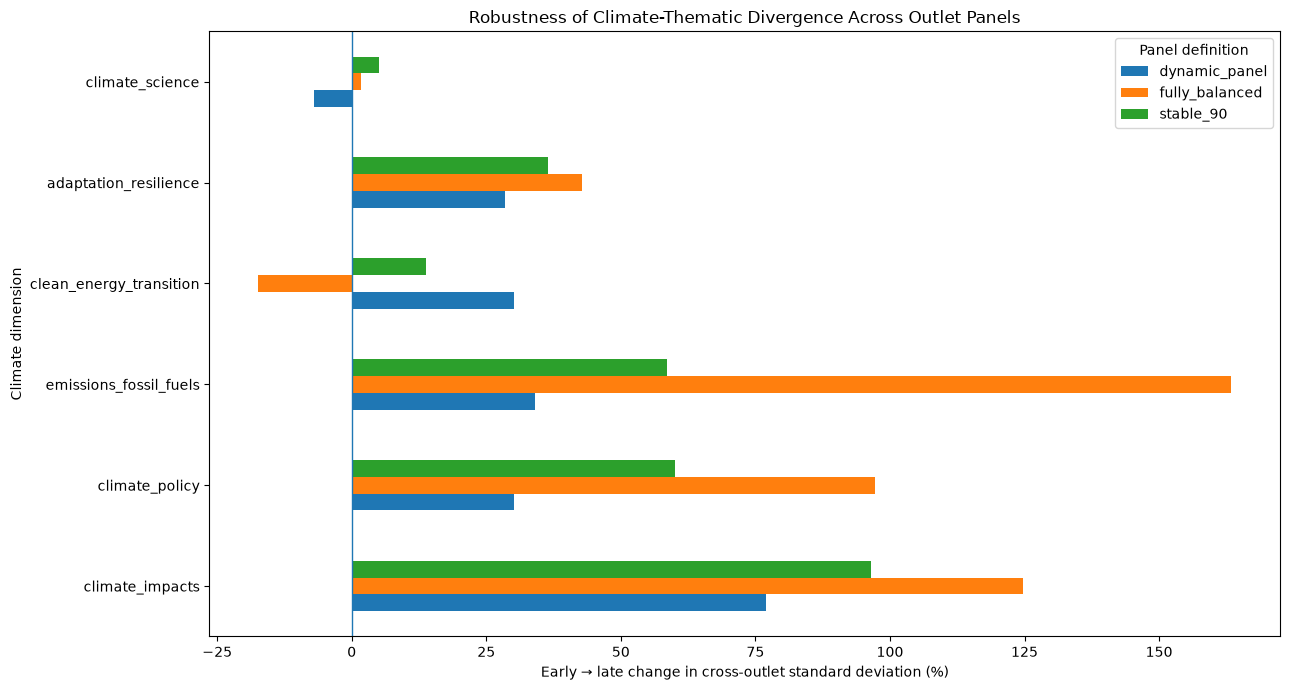

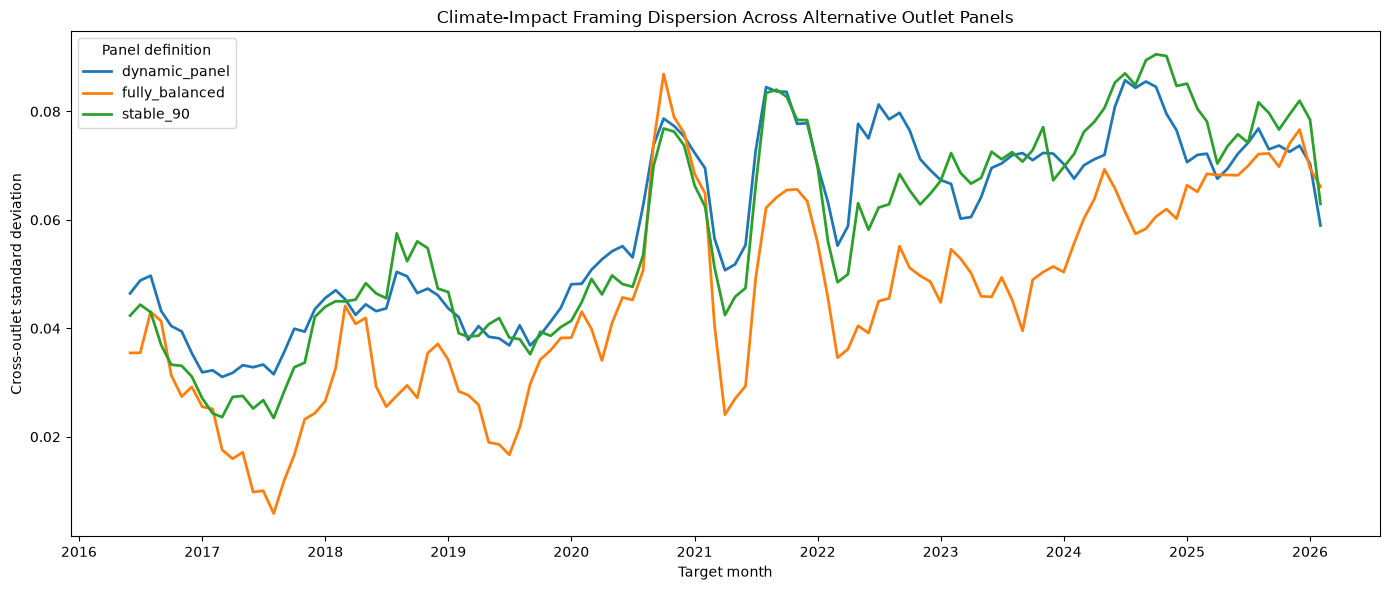


DIMENSIONS RANKED BY EARLY → LATE CHANGE

DYNAMIC_PANEL


,anchor,early_std,late_std,std_pct_change,annualized_std_change,time_correlation
6,climate_impacts,0.0408,0.0721,77.0242,0.0048,0.8243
15,emissions_fossil_fuels,0.0292,0.0391,34.0862,0.0013,0.6146
9,climate_policy,0.0337,0.0439,30.2160,0.0016,0.7354
3,clean_energy_transition,0.0312,0.0405,30.1022,0.0014,0.5793
0,adaptation_resilience,0.0302,0.0388,28.4743,0.0012,0.5767
12,climate_science,0.0325,0.0302,-6.9491,-0.0002,-0.1367



FULLY_BALANCED


,anchor,early_std,late_std,std_pct_change,annualized_std_change,time_correlation
16,emissions_fossil_fuels,0.0166,0.0438,163.4221,0.0037,0.8338
7,climate_impacts,0.0266,0.0597,124.7121,0.0049,0.7620
10,climate_policy,0.0231,0.0456,97.1361,0.0032,0.7616
1,adaptation_resilience,0.0201,0.0288,42.8184,0.0013,0.5102
13,climate_science,0.0289,0.0294,1.7359,0.0002,0.0779
4,clean_energy_transition,0.0211,0.0174,-17.4078,-0.0007,-0.2595



STABLE_90


,anchor,early_std,late_std,std_pct_change,annualized_std_change,time_correlation
8,climate_impacts,0.0389,0.0764,96.5586,0.0057,0.8656
11,climate_policy,0.0304,0.0487,59.9802,0.0027,0.8204
17,emissions_fossil_fuels,0.0290,0.0459,58.6553,0.0024,0.7465
2,adaptation_resilience,0.0298,0.0406,36.4366,0.0016,0.5731
5,clean_energy_transition,0.0292,0.0332,13.8028,0.0008,0.3721
14,climate_science,0.0289,0.0303,5.0532,0.0004,0.2203



ROBUSTNESS VALIDATION
Output rows: 18
Panels: ['dynamic_panel', 'fully_balanced', 'stable_90']
Dimensions: 6
Saved to: /Users/lasya/Documents/projects/media-polarization-lab/data/processed/climate_dimension_panel_robustness.parquet


In [55]:
# ============================================================
# CELL 31 — THEMATIC DISPERSION ROBUSTNESS ACROSS OUTLET PANELS
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

PROJECT_ROOT = Path.cwd()

# Handle notebook being launched from notebooks/ or repo root
if not (PROJECT_ROOT / "data").exists():
    if (PROJECT_ROOT.parent / "data").exists():
        PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

PROFILE_PATH = (
    PROCESSED_DIR
    / "outlet_month_climate_dimension_profiles.parquet"
)

OUTPUT_PATH = (
    PROCESSED_DIR
    / "climate_dimension_panel_robustness.parquet"
)

print("=" * 70)
print("THEMATIC DISPERSION ROBUSTNESS")
print("=" * 70)

print(f"Input:  {PROFILE_PATH}")
print(f"Output: {OUTPUT_PATH}")

# ------------------------------------------------------------
# Load dimension profiles
# ------------------------------------------------------------

profiles = pd.read_parquet(PROFILE_PATH).copy()

print("\nRows loaded:", f"{len(profiles):,}")
print("Columns:")
print(list(profiles.columns))

# ------------------------------------------------------------
# Detect key columns
# ------------------------------------------------------------

possible_outlet_cols = [
    "media_name",
    "outlet",
    "source",
]

possible_month_cols = [
    "target_month",
    "year_month",
    "month",
]

outlet_col = next(
    (c for c in possible_outlet_cols if c in profiles.columns),
    None,
)

month_col = next(
    (c for c in possible_month_cols if c in profiles.columns),
    None,
)

if outlet_col is None:
    raise ValueError(
        "Could not identify outlet column."
    )

if month_col is None:
    raise ValueError(
        "Could not identify month column."
    )

# ------------------------------------------------------------
# Normalize month representation
# ------------------------------------------------------------

profiles[month_col] = (
    pd.to_datetime(profiles[month_col].astype(str))
    .dt.to_period("M")
)

# ------------------------------------------------------------
# Detect the six relative thematic dimensions
# ------------------------------------------------------------

relative_cols = [
    c
    for c in profiles.columns
    if c.startswith("relative_")
]

expected_dimensions = [
    "relative_climate_science",
    "relative_emissions_fossil_fuels",
    "relative_clean_energy_transition",
    "relative_climate_policy",
    "relative_climate_impacts",
    "relative_adaptation_resilience",
]

missing_dimensions = [
    c
    for c in expected_dimensions
    if c not in relative_cols
]

if missing_dimensions:
    raise ValueError(
        "Missing expected relative dimensions: "
        + ", ".join(missing_dimensions)
    )

relative_cols = expected_dimensions

print("\nDetected:")
print("Outlet column:", outlet_col)
print("Month column:", month_col)
print("Dimensions:", len(relative_cols))

# ------------------------------------------------------------
# Study months
# ------------------------------------------------------------

study_months = sorted(
    profiles[month_col].dropna().unique()
)

n_months = len(study_months)

print("\n" + "=" * 70)
print("STUDY PANEL")
print("=" * 70)

print("Study months:", n_months)
print("First month:", study_months[0])
print("Last month:", study_months[-1])

# ------------------------------------------------------------
# Outlet coverage
# ------------------------------------------------------------

coverage = (
    profiles
    .groupby(outlet_col)[month_col]
    .nunique()
    .sort_values(ascending=False)
)

coverage_pct = (
    coverage / n_months * 100
)

coverage_table = pd.DataFrame(
    {
        "months_present": coverage,
        "coverage_pct": coverage_pct,
    }
)

stable_90_outlets = (
    coverage_table[
        coverage_table["coverage_pct"] >= 90
    ]
    .index
    .tolist()
)

balanced_outlets = (
    coverage_table[
        coverage_table["months_present"] == n_months
    ]
    .index
    .tolist()
)

print("\n" + "=" * 70)
print("OUTLET COHORTS")
print("=" * 70)

print(
    f"All outlets:              "
    f"{profiles[outlet_col].nunique():,}"
)

print(
    f"Stable >=90% outlets:     "
    f"{len(stable_90_outlets):,}"
)

print(
    f"Fully balanced outlets:   "
    f"{len(balanced_outlets):,}"
)

if balanced_outlets:
    print("\nFully balanced outlets:")
    for outlet in balanced_outlets:
        print(" ", outlet)

# ------------------------------------------------------------
# Panel definitions
# ------------------------------------------------------------

panel_specs = {
    "dynamic_panel": None,
    "stable_90": stable_90_outlets,
    "fully_balanced": balanced_outlets,
}

# ------------------------------------------------------------
# Helper: calculate monthly cross-outlet dispersion
# ------------------------------------------------------------

def calculate_monthly_dispersion(
    frame,
    panel_name,
):
    records = []

    for month, month_df in frame.groupby(month_col):

        for relative_col in relative_cols:

            values = (
                month_df[relative_col]
                .dropna()
                .astype(float)
            )

            if len(values) < 2:
                continue

            anchor = relative_col.replace(
                "relative_",
                "",
            )

            q25 = values.quantile(0.25)
            q75 = values.quantile(0.75)

            records.append(
                {
                    "panel": panel_name,
                    "target_month": month,
                    "anchor": anchor,
                    "outlets": len(values),
                    "cross_outlet_std": values.std(
                        ddof=1
                    ),
                    "cross_outlet_iqr": (
                        q75 - q25
                    ),
                    "cross_outlet_mean": (
                        values.mean()
                    ),
                }
            )

    return pd.DataFrame(records)

# ------------------------------------------------------------
# Build monthly dispersion datasets
# ------------------------------------------------------------

panel_monthly_parts = []

for panel_name, outlets in panel_specs.items():

    if outlets is None:
        panel_df = profiles.copy()
    else:
        panel_df = profiles[
            profiles[outlet_col].isin(outlets)
        ].copy()

    print(
        f"\nBuilding {panel_name}: "
        f"{panel_df[outlet_col].nunique()} outlets, "
        f"{len(panel_df):,} outlet-month rows"
    )

    result = calculate_monthly_dispersion(
        panel_df,
        panel_name,
    )

    panel_monthly_parts.append(result)

panel_monthly = pd.concat(
    panel_monthly_parts,
    ignore_index=True,
)

# ------------------------------------------------------------
# Assign equal-length early / middle / late periods
# ------------------------------------------------------------

ordered_months = sorted(
    panel_monthly["target_month"].unique()
)

month_chunks = np.array_split(
    ordered_months,
    3,
)

period_lookup = {}

for label, months in zip(
    ["early", "middle", "late"],
    month_chunks,
):
    for month in months:
        period_lookup[month] = label

panel_monthly["period"] = (
    panel_monthly["target_month"]
    .map(period_lookup)
)

# ------------------------------------------------------------
# Early → late change
# ------------------------------------------------------------

period_summary = (
    panel_monthly
    .groupby(
        [
            "panel",
            "period",
            "anchor",
        ]
    )
    .agg(
        mean_std=(
            "cross_outlet_std",
            "mean",
        ),
        mean_iqr=(
            "cross_outlet_iqr",
            "mean",
        ),
        months=(
            "target_month",
            "nunique",
        ),
        mean_outlets=(
            "outlets",
            "mean",
        ),
    )
    .reset_index()
)

early = (
    period_summary[
        period_summary["period"] == "early"
    ]
    .set_index(
        [
            "panel",
            "anchor",
        ]
    )
)

late = (
    period_summary[
        period_summary["period"] == "late"
    ]
    .set_index(
        [
            "panel",
            "anchor",
        ]
    )
)

change = pd.DataFrame(
    {
        "early_std": early["mean_std"],
        "late_std": late["mean_std"],
        "early_iqr": early["mean_iqr"],
        "late_iqr": late["mean_iqr"],
    }
).reset_index()

change["std_absolute_change"] = (
    change["late_std"]
    - change["early_std"]
)

change["std_pct_change"] = (
    change["std_absolute_change"]
    / change["early_std"]
    * 100
)

change["iqr_absolute_change"] = (
    change["late_iqr"]
    - change["early_iqr"]
)

change["iqr_pct_change"] = (
    change["iqr_absolute_change"]
    / change["early_iqr"]
    * 100
)

# ------------------------------------------------------------
# Linear time trends
# ------------------------------------------------------------

trend_records = []

for (
    panel_name,
    anchor,
), group in panel_monthly.groupby(
    [
        "panel",
        "anchor",
    ]
):

    g = (
        group
        .sort_values("target_month")
        .copy()
    )

    if len(g) < 3:
        continue

    x = np.arange(len(g))
    y = g["cross_outlet_std"].to_numpy()

    slope_per_month = np.polyfit(
        x,
        y,
        1,
    )[0]

    correlation = np.corrcoef(
        x,
        y,
    )[0, 1]

    trend_records.append(
        {
            "panel": panel_name,
            "anchor": anchor,
            "months": len(g),
            "monthly_std_change": (
                slope_per_month
            ),
            "annualized_std_change": (
                slope_per_month * 12
            ),
            "time_correlation": (
                correlation
            ),
        }
    )

trend_summary = pd.DataFrame(
    trend_records
)

# ------------------------------------------------------------
# Combined result
# ------------------------------------------------------------

robustness = change.merge(
    trend_summary,
    on=[
        "panel",
        "anchor",
    ],
    how="left",
)

robustness = robustness.sort_values(
    [
        "anchor",
        "panel",
    ]
).reset_index(drop=True)

robustness.to_parquet(
    OUTPUT_PATH,
    index=False,
)

# ------------------------------------------------------------
# Print early → late comparison
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("EARLY → LATE DISPERSION ROBUSTNESS")
print("=" * 70)

display(
    robustness[
        [
            "panel",
            "anchor",
            "early_std",
            "late_std",
            "std_pct_change",
            "annualized_std_change",
            "time_correlation",
        ]
    ]
    .round(4)
)

# ------------------------------------------------------------
# Pivot: percentage change by panel
# ------------------------------------------------------------

pct_pivot = (
    robustness
    .pivot(
        index="anchor",
        columns="panel",
        values="std_pct_change",
    )
)

preferred_order = [
    "climate_impacts",
    "climate_policy",
    "emissions_fossil_fuels",
    "clean_energy_transition",
    "adaptation_resilience",
    "climate_science",
]

pct_pivot = pct_pivot.reindex(
    preferred_order
)

print("\n" + "=" * 70)
print("EARLY → LATE % CHANGE BY PANEL")
print("=" * 70)

display(
    pct_pivot.round(2)
)

# ------------------------------------------------------------
# Pivot: annualized trend by panel
# ------------------------------------------------------------

trend_pivot = (
    robustness
    .pivot(
        index="anchor",
        columns="panel",
        values="annualized_std_change",
    )
    .reindex(preferred_order)
)

print("\n" + "=" * 70)
print("ANNUALIZED THEMATIC DISPERSION TREND BY PANEL")
print("=" * 70)

display(
    trend_pivot.round(6)
)

# ------------------------------------------------------------
# Visualization 1:
# Early → late percentage change by panel
# ------------------------------------------------------------

plot_df = (
    pct_pivot
    .dropna(how="all")
)

ax = plot_df.plot(
    kind="barh",
    figsize=(13, 7),
)

ax.axvline(
    0,
    linewidth=1,
)

ax.set_title(
    "Robustness of Climate-Thematic Divergence "
    "Across Outlet Panels"
)

ax.set_xlabel(
    "Early → late change in cross-outlet "
    "standard deviation (%)"
)

ax.set_ylabel(
    "Climate dimension"
)

ax.legend(
    title="Panel definition"
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Visualization 2:
# Climate impacts specifically
# ------------------------------------------------------------

impact_data = panel_monthly[
    panel_monthly["anchor"]
    == "climate_impacts"
].copy()

plt.figure(
    figsize=(14, 6)
)

for panel_name, group in impact_data.groupby(
    "panel"
):

    g = group.sort_values(
        "target_month"
    )

    x_dates = (
        g["target_month"]
        .dt.to_timestamp()
    )

    plt.plot(
        x_dates,
        g["cross_outlet_std"],
        label=panel_name,
        linewidth=2,
    )

plt.title(
    "Climate-Impact Framing Dispersion "
    "Across Alternative Outlet Panels"
)

plt.xlabel(
    "Target month"
)

plt.ylabel(
    "Cross-outlet standard deviation"
)

plt.legend(
    title="Panel definition"
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Strongest dimensions under each specification
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("DIMENSIONS RANKED BY EARLY → LATE CHANGE")
print("=" * 70)

for panel_name in robustness["panel"].unique():

    print(
        f"\n{panel_name.upper()}"
    )

    display(
        robustness[
            robustness["panel"]
            == panel_name
        ][
            [
                "anchor",
                "early_std",
                "late_std",
                "std_pct_change",
                "annualized_std_change",
                "time_correlation",
            ]
        ]
        .sort_values(
            "std_pct_change",
            ascending=False,
        )
        .round(4)
    )

# ------------------------------------------------------------
# Final validation
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("ROBUSTNESS VALIDATION")
print("=" * 70)

print(
    "Output rows:",
    len(robustness),
)

print(
    "Panels:",
    sorted(
        robustness["panel"]
        .unique()
    ),
)

print(
    "Dimensions:",
    robustness["anchor"]
    .nunique(),
)

print(
    "Saved to:",
    OUTPUT_PATH,
)

CLIMATE-IMPACT DIVERGENCE — OUTLET DRIVERS
Rows: 7,378
Outlets: 136
Months: 117

STABLE COHORT
Stable >=90% outlets: 20
Stable outlet-month rows: 2,254

OUTLET-LEVEL CLIMATE-IMPACT CHANGE


,media_name,coverage_pct,early,middle,late,early_to_late_change,annualized_change,time_correlation
0,cnn.com,93.1624,0.0302,0.1008,0.1640,0.1338,0.0193,0.8141
1,usatoday.com,90.5983,0.0782,0.1492,0.2049,0.1267,0.0194,0.8237
2,newsweek.com,97.4359,0.0530,0.0877,0.1784,0.1254,0.0171,0.5882
3,cbsnews.com,100.0000,0.0577,0.1239,0.1800,0.1223,0.0179,0.8123
4,nytimes.com,98.2906,0.0309,0.1080,0.1460,0.1152,0.0164,0.7562
5,latimes.com,100.0000,0.0511,0.1081,0.1410,0.0899,0.0139,0.7425
6,pbs.org,92.3077,0.0628,0.1248,0.1510,0.0882,0.0151,0.5735
7,abcnews.go.com,100.0000,0.0246,0.0868,0.1050,0.0804,0.0131,0.6845
8,mercurynews.com,97.4359,0.0699,0.1313,0.1489,0.0790,0.0120,0.6995
9,seattletimes.com,94.0171,0.0153,0.0773,0.0818,0.0665,0.0107,0.6466



LARGEST INCREASES IN CLIMATE-IMPACT EMPHASIS


,media_name,early,late,early_to_late_change,annualized_change,time_correlation
0,cnn.com,0.0302,0.1640,0.1338,0.0193,0.8141
1,usatoday.com,0.0782,0.2049,0.1267,0.0194,0.8237
2,newsweek.com,0.0530,0.1784,0.1254,0.0171,0.5882
3,cbsnews.com,0.0577,0.1800,0.1223,0.0179,0.8123
4,nytimes.com,0.0309,0.1460,0.1152,0.0164,0.7562
5,latimes.com,0.0511,0.1410,0.0899,0.0139,0.7425
6,pbs.org,0.0628,0.1510,0.0882,0.0151,0.5735
7,abcnews.go.com,0.0246,0.1050,0.0804,0.0131,0.6845
8,mercurynews.com,0.0699,0.1489,0.0790,0.0120,0.6995
9,seattletimes.com,0.0153,0.0818,0.0665,0.0107,0.6466



LARGEST DECREASES IN CLIMATE-IMPACT EMPHASIS


,media_name,early,late,early_to_late_change,annualized_change,time_correlation
19,foxnews.com,0.0456,0.0380,-0.0076,0.0001,0.0064
18,dailycaller.com,-0.0259,-0.0313,-0.0054,-0.0003,-0.0321
17,forbes.com,-0.0439,-0.0315,0.0124,0.0019,0.2216
16,mongabay.com,0.0018,0.0250,0.0232,0.0042,0.4228
15,upi.com,0.0185,0.0474,0.0290,0.0078,0.5309
14,grist.org,0.0232,0.0539,0.0306,0.0050,0.4977
13,theconversation.com,0.0168,0.0498,0.0330,0.0049,0.6254
12,chicagotribune.com,0.0432,0.0848,0.0416,0.0077,0.3992
11,theguardian.com,-0.0027,0.0417,0.0443,0.0066,0.6624
10,scientificamerican.com,0.0644,0.1184,0.0539,0.0089,0.5660



HIGHEST LATE-PERIOD CLIMATE-IMPACT EMPHASIS


,media_name,early,late,early_to_late_change
1,usatoday.com,0.0782,0.2049,0.1267
3,cbsnews.com,0.0577,0.1800,0.1223
2,newsweek.com,0.0530,0.1784,0.1254
0,cnn.com,0.0302,0.1640,0.1338
6,pbs.org,0.0628,0.1510,0.0882
8,mercurynews.com,0.0699,0.1489,0.0790
4,nytimes.com,0.0309,0.1460,0.1152
5,latimes.com,0.0511,0.1410,0.0899
10,scientificamerican.com,0.0644,0.1184,0.0539
7,abcnews.go.com,0.0246,0.1050,0.0804



LOWEST LATE-PERIOD CLIMATE-IMPACT EMPHASIS


,media_name,early,late,early_to_late_change
17,forbes.com,-0.0439,-0.0315,0.0124
18,dailycaller.com,-0.0259,-0.0313,-0.0054
16,mongabay.com,0.0018,0.0250,0.0232
19,foxnews.com,0.0456,0.0380,-0.0076
11,theguardian.com,-0.0027,0.0417,0.0443
15,upi.com,0.0185,0.0474,0.0290
13,theconversation.com,0.0168,0.0498,0.0330
14,grist.org,0.0232,0.0539,0.0306
9,seattletimes.com,0.0153,0.0818,0.0665
12,chicagotribune.com,0.0432,0.0848,0.0416


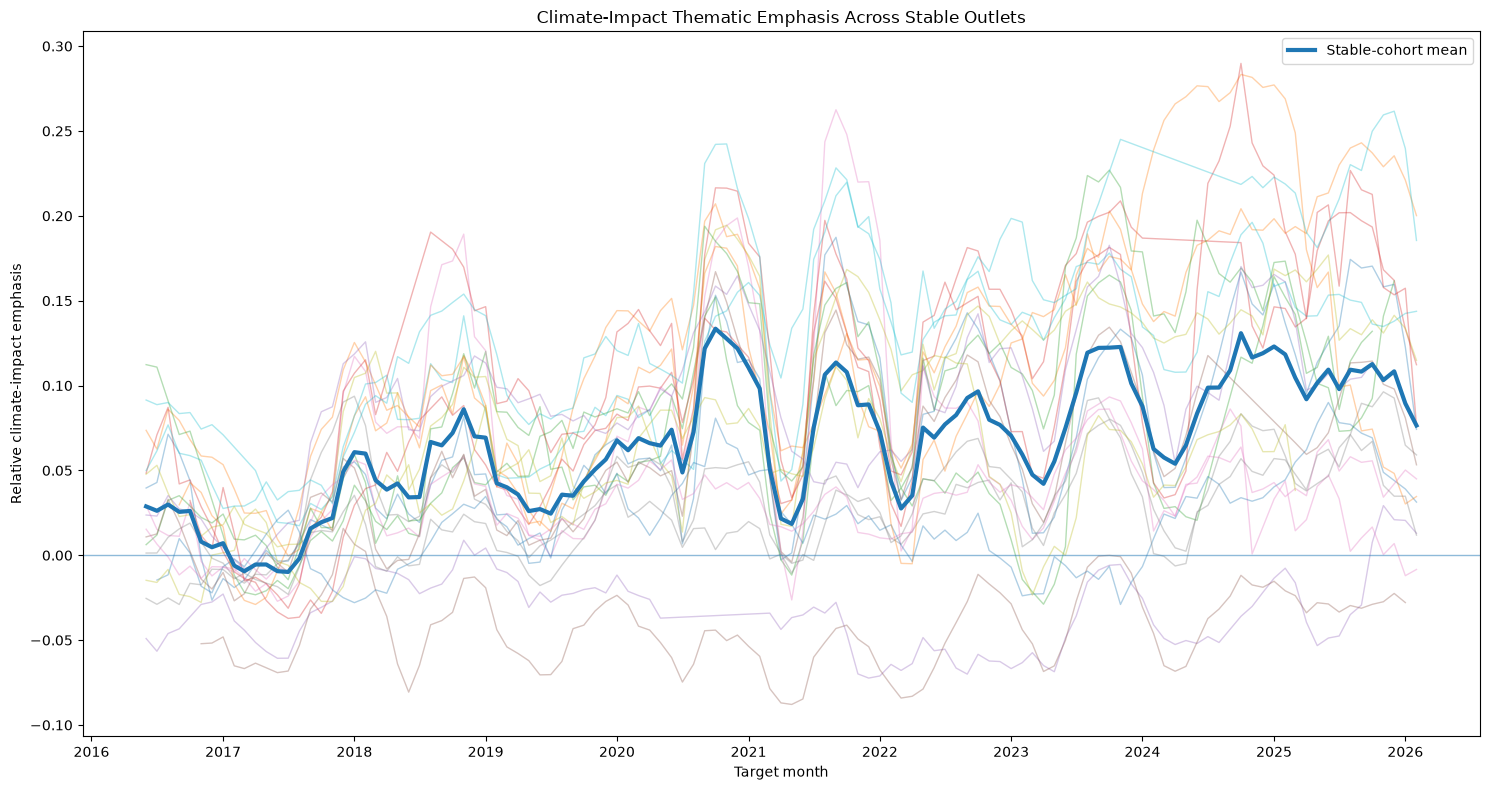

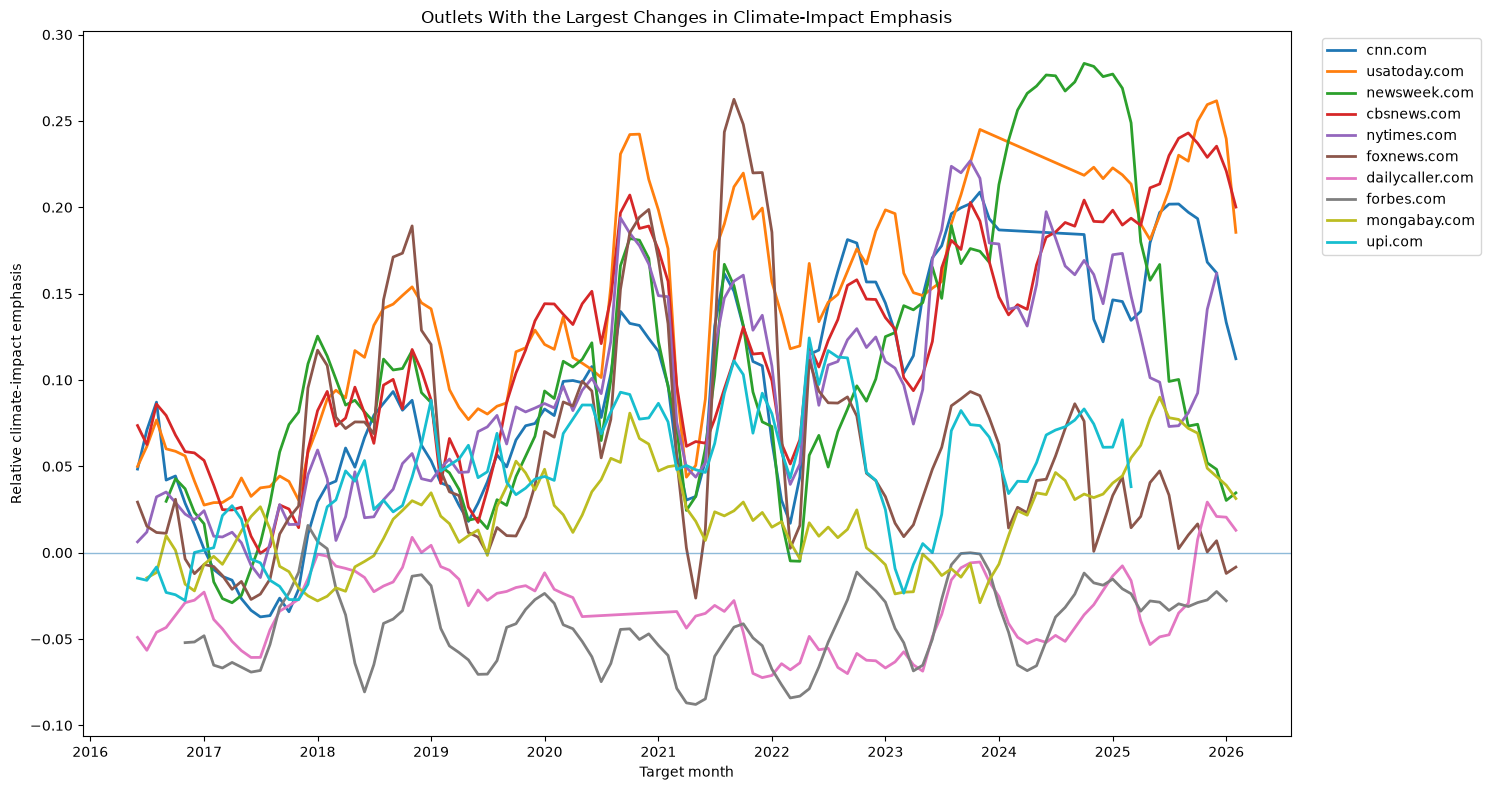

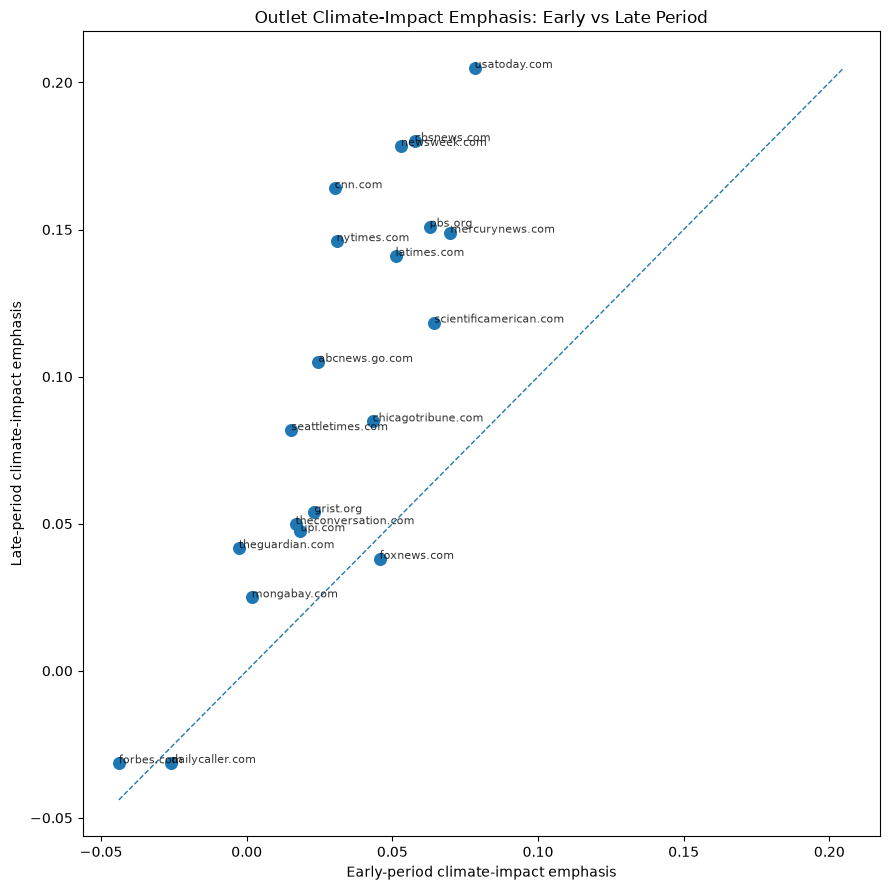

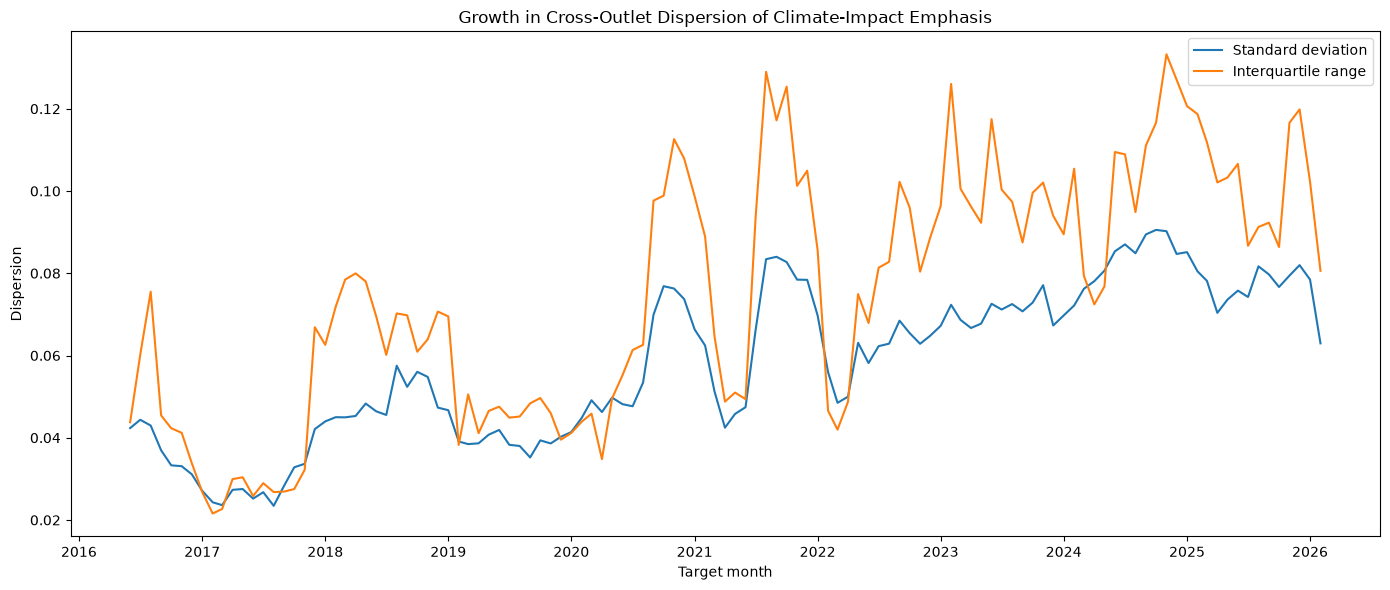


LEAVE-ONE-OUT ROBUSTNESS


,omitted_outlet,early_std,late_std,pct_change
11,newsweek.com,0.0391,0.0729,86.454903
1,cbsnews.com,0.0391,0.0752,92.365700
4,dailycaller.com,0.0373,0.0719,92.615402
12,nytimes.com,0.0397,0.0769,93.849098
3,cnn.com,0.0394,0.0764,93.902802
19,usatoday.com,0.0379,0.0742,95.511002
16,theconversation.com,0.0397,0.0778,95.823997
10,mongabay.com,0.0388,0.0763,96.549500
8,latimes.com,0.0394,0.0776,96.783699
7,grist.org,0.0396,0.0780,96.915398



Minimum early→late increase after dropping any single outlet:
86.45%

Maximum early→late increase after dropping any single outlet:
102.35%

ARTIFACTS
Outlet drivers: /Users/lasya/Documents/projects/media-polarization-lab/data/processed/climate_impact_outlet_drivers.parquet
Leave-one-out robustness: /Users/lasya/Documents/projects/media-polarization-lab/data/processed/climate_impact_leave_one_out.parquet


In [56]:
# ============================================================
# CELL 32 — OUTLET DRIVERS OF CLIMATE-IMPACT DIVERGENCE
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / "data").exists():
    if (PROJECT_ROOT.parent / "data").exists():
        PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

PROFILE_PATH = (
    PROCESSED_DIR
    / "outlet_month_climate_dimension_profiles.parquet"
)

OUTPUT_PATH = (
    PROCESSED_DIR
    / "climate_impact_outlet_drivers.parquet"
)

# ------------------------------------------------------------
# Load profiles
# ------------------------------------------------------------

profiles = pd.read_parquet(PROFILE_PATH).copy()

OUTLET_COL = "media_name"
MONTH_COL = "target_month"
IMPACT_COL = "relative_climate_impacts"

profiles[MONTH_COL] = (
    pd.to_datetime(profiles[MONTH_COL].astype(str))
    .dt.to_period("M")
)

print("=" * 72)
print("CLIMATE-IMPACT DIVERGENCE — OUTLET DRIVERS")
print("=" * 72)

print("Rows:", f"{len(profiles):,}")
print(
    "Outlets:",
    profiles[OUTLET_COL].nunique(),
)
print(
    "Months:",
    profiles[MONTH_COL].nunique(),
)

# ------------------------------------------------------------
# Define stable >=90% cohort
# ------------------------------------------------------------

study_months = sorted(
    profiles[MONTH_COL]
    .dropna()
    .unique()
)

n_months = len(study_months)

coverage = (
    profiles
    .groupby(OUTLET_COL)[MONTH_COL]
    .nunique()
)

stable_outlets = (
    coverage[
        coverage >= np.ceil(0.90 * n_months)
    ]
    .index
    .tolist()
)

stable = (
    profiles[
        profiles[OUTLET_COL]
        .isin(stable_outlets)
    ]
    .copy()
)

print("\n" + "=" * 72)
print("STABLE COHORT")
print("=" * 72)

print(
    "Stable >=90% outlets:",
    len(stable_outlets),
)

print(
    "Stable outlet-month rows:",
    f"{len(stable):,}",
)

# ------------------------------------------------------------
# Equal early / middle / late periods
# ------------------------------------------------------------

month_chunks = np.array_split(
    study_months,
    3,
)

period_lookup = {}

for label, months in zip(
    ["early", "middle", "late"],
    month_chunks,
):
    for month in months:
        period_lookup[month] = label

stable["period"] = (
    stable[MONTH_COL]
    .map(period_lookup)
)

# ------------------------------------------------------------
# Outlet-level early / middle / late means
# ------------------------------------------------------------

period_means = (
    stable
    .groupby(
        [
            OUTLET_COL,
            "period",
        ]
    )[IMPACT_COL]
    .mean()
    .unstack("period")
)

for col in ["early", "middle", "late"]:
    if col not in period_means.columns:
        period_means[col] = np.nan

period_means = period_means[
    ["early", "middle", "late"]
]

period_means["early_to_late_change"] = (
    period_means["late"]
    - period_means["early"]
)

# ------------------------------------------------------------
# Outlet-specific linear trends
# ------------------------------------------------------------

trend_records = []

month_index = {
    m: i
    for i, m in enumerate(study_months)
}

for outlet, g in stable.groupby(OUTLET_COL):

    g = (
        g[
            [MONTH_COL, IMPACT_COL]
        ]
        .dropna()
        .sort_values(MONTH_COL)
        .copy()
    )

    if len(g) < 12:
        continue

    x = (
        g[MONTH_COL]
        .map(month_index)
        .astype(float)
        .to_numpy()
    )

    y = (
        g[IMPACT_COL]
        .astype(float)
        .to_numpy()
    )

    slope_month = np.polyfit(
        x,
        y,
        1,
    )[0]

    corr = np.corrcoef(
        x,
        y,
    )[0, 1]

    trend_records.append(
        {
            OUTLET_COL: outlet,
            "months": len(g),
            "annualized_change": (
                slope_month * 12
            ),
            "time_correlation": corr,
            "mean_impact_emphasis": (
                y.mean()
            ),
        }
    )

trend_df = pd.DataFrame(
    trend_records
).set_index(OUTLET_COL)

# ------------------------------------------------------------
# Combine
# ------------------------------------------------------------

drivers = (
    period_means
    .join(
        trend_df,
        how="left",
    )
    .reset_index()
)

drivers["coverage_months"] = (
    drivers[OUTLET_COL]
    .map(coverage)
)

drivers["coverage_pct"] = (
    drivers["coverage_months"]
    / n_months
    * 100
)

drivers = drivers.sort_values(
    "early_to_late_change",
    ascending=False,
).reset_index(drop=True)

drivers.to_parquet(
    OUTPUT_PATH,
    index=False,
)

# ------------------------------------------------------------
# Main summary
# ------------------------------------------------------------

print("\n" + "=" * 72)
print("OUTLET-LEVEL CLIMATE-IMPACT CHANGE")
print("=" * 72)

display(
    drivers[
        [
            OUTLET_COL,
            "coverage_pct",
            "early",
            "middle",
            "late",
            "early_to_late_change",
            "annualized_change",
            "time_correlation",
        ]
    ]
    .round(4)
)

# ------------------------------------------------------------
# Strongest increases / decreases
# ------------------------------------------------------------

print("\n" + "=" * 72)
print("LARGEST INCREASES IN CLIMATE-IMPACT EMPHASIS")
print("=" * 72)

display(
    drivers[
        [
            OUTLET_COL,
            "early",
            "late",
            "early_to_late_change",
            "annualized_change",
            "time_correlation",
        ]
    ]
    .head(10)
    .round(4)
)

print("\n" + "=" * 72)
print("LARGEST DECREASES IN CLIMATE-IMPACT EMPHASIS")
print("=" * 72)

display(
    drivers[
        [
            OUTLET_COL,
            "early",
            "late",
            "early_to_late_change",
            "annualized_change",
            "time_correlation",
        ]
    ]
    .tail(10)
    .sort_values(
        "early_to_late_change"
    )
    .round(4)
)

# ------------------------------------------------------------
# Rank outlets by late-period impact emphasis
# ------------------------------------------------------------

print("\n" + "=" * 72)
print("HIGHEST LATE-PERIOD CLIMATE-IMPACT EMPHASIS")
print("=" * 72)

display(
    drivers[
        [
            OUTLET_COL,
            "early",
            "late",
            "early_to_late_change",
        ]
    ]
    .sort_values(
        "late",
        ascending=False,
    )
    .head(10)
    .round(4)
)

print("\n" + "=" * 72)
print("LOWEST LATE-PERIOD CLIMATE-IMPACT EMPHASIS")
print("=" * 72)

display(
    drivers[
        [
            OUTLET_COL,
            "early",
            "late",
            "early_to_late_change",
        ]
    ]
    .sort_values(
        "late",
        ascending=True,
    )
    .head(10)
    .round(4)
)

# ------------------------------------------------------------
# Monthly trajectories for all stable outlets
# ------------------------------------------------------------

impact_panel = (
    stable[
        [
            MONTH_COL,
            OUTLET_COL,
            IMPACT_COL,
        ]
    ]
    .dropna()
    .copy()
)

impact_panel["month_ts"] = (
    impact_panel[MONTH_COL]
    .dt.to_timestamp()
)

plt.figure(figsize=(15, 8))

for outlet, g in impact_panel.groupby(
    OUTLET_COL
):
    g = g.sort_values("month_ts")

    plt.plot(
        g["month_ts"],
        g[IMPACT_COL],
        alpha=0.35,
        linewidth=1,
    )

monthly_mean = (
    impact_panel
    .groupby("month_ts")[IMPACT_COL]
    .mean()
)

plt.plot(
    monthly_mean.index,
    monthly_mean.values,
    linewidth=3,
    label="Stable-cohort mean",
)

plt.axhline(
    0,
    linewidth=1,
    alpha=0.5,
)

plt.title(
    "Climate-Impact Thematic Emphasis "
    "Across Stable Outlets"
)

plt.xlabel("Target month")
plt.ylabel(
    "Relative climate-impact emphasis"
)

plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Focus on most divergent outlet trajectories
# ------------------------------------------------------------

top_risers = (
    drivers
    .nlargest(
        5,
        "early_to_late_change",
    )[OUTLET_COL]
    .tolist()
)

top_decliners = (
    drivers
    .nsmallest(
        5,
        "early_to_late_change",
    )[OUTLET_COL]
    .tolist()
)

focus_outlets = list(
    dict.fromkeys(
        top_risers
        + top_decliners
    )
)

plt.figure(figsize=(15, 8))

for outlet in focus_outlets:

    g = (
        impact_panel[
            impact_panel[OUTLET_COL]
            == outlet
        ]
        .sort_values("month_ts")
    )

    plt.plot(
        g["month_ts"],
        g[IMPACT_COL],
        linewidth=2,
        label=outlet,
    )

plt.axhline(
    0,
    linewidth=1,
    alpha=0.5,
)

plt.title(
    "Outlets With the Largest Changes in "
    "Climate-Impact Emphasis"
)

plt.xlabel("Target month")
plt.ylabel(
    "Relative climate-impact emphasis"
)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Early vs late scatter
# ------------------------------------------------------------

scatter_df = drivers.dropna(
    subset=[
        "early",
        "late",
    ]
).copy()

plt.figure(figsize=(9, 9))

plt.scatter(
    scatter_df["early"],
    scatter_df["late"],
    s=70,
)

lims = [
    min(
        scatter_df["early"].min(),
        scatter_df["late"].min(),
    ),
    max(
        scatter_df["early"].max(),
        scatter_df["late"].max(),
    ),
]

plt.plot(
    lims,
    lims,
    linestyle="--",
    linewidth=1,
)

for _, row in scatter_df.iterrows():

    plt.annotate(
        row[OUTLET_COL],
        (
            row["early"],
            row["late"],
        ),
        fontsize=8,
        alpha=0.8,
    )

plt.xlabel(
    "Early-period climate-impact emphasis"
)

plt.ylabel(
    "Late-period climate-impact emphasis"
)

plt.title(
    "Outlet Climate-Impact Emphasis: "
    "Early vs Late Period"
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Cross-sectional range / IQR through time
# ------------------------------------------------------------

monthly_cross_section = (
    impact_panel
    .groupby(MONTH_COL)[IMPACT_COL]
    .agg(
        mean="mean",
        std="std",
        min="min",
        q25=lambda s: s.quantile(0.25),
        median="median",
        q75=lambda s: s.quantile(0.75),
        max="max",
        outlets="count",
    )
    .reset_index()
)

monthly_cross_section["iqr"] = (
    monthly_cross_section["q75"]
    - monthly_cross_section["q25"]
)

monthly_cross_section["range"] = (
    monthly_cross_section["max"]
    - monthly_cross_section["min"]
)

monthly_cross_section["month_ts"] = (
    monthly_cross_section[MONTH_COL]
    .dt.to_timestamp()
)

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_cross_section["month_ts"],
    monthly_cross_section["std"],
    label="Standard deviation",
)

plt.plot(
    monthly_cross_section["month_ts"],
    monthly_cross_section["iqr"],
    label="Interquartile range",
)

plt.title(
    "Growth in Cross-Outlet Dispersion of "
    "Climate-Impact Emphasis"
)

plt.xlabel("Target month")
plt.ylabel("Dispersion")

plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Leave-one-out robustness
# ------------------------------------------------------------

loo_records = []

for omitted_outlet in stable_outlets:

    loo = stable[
        stable[OUTLET_COL]
        != omitted_outlet
    ].copy()

    monthly_std = (
        loo
        .groupby(MONTH_COL)[IMPACT_COL]
        .std()
        .dropna()
    )

    early_months = set(month_chunks[0])
    late_months = set(month_chunks[2])

    early_mean = monthly_std[
        monthly_std.index.isin(
            early_months
        )
    ].mean()

    late_mean = monthly_std[
        monthly_std.index.isin(
            late_months
        )
    ].mean()

    pct_change = (
        (late_mean - early_mean)
        / early_mean
        * 100
    )

    loo_records.append(
        {
            "omitted_outlet": (
                omitted_outlet
            ),
            "early_std": early_mean,
            "late_std": late_mean,
            "pct_change": pct_change,
        }
    )

loo_df = pd.DataFrame(
    loo_records
).sort_values(
    "pct_change"
)

print("\n" + "=" * 72)
print("LEAVE-ONE-OUT ROBUSTNESS")
print("=" * 72)

display(
    loo_df.round(4)
)

print(
    "\nMinimum early→late increase "
    "after dropping any single outlet:"
)

print(
    f"{loo_df['pct_change'].min():.2f}%"
)

print(
    "\nMaximum early→late increase "
    "after dropping any single outlet:"
)

print(
    f"{loo_df['pct_change'].max():.2f}%"
)

# ------------------------------------------------------------
# Save leave-one-out as separate artifact
# ------------------------------------------------------------

LOO_PATH = (
    PROCESSED_DIR
    / "climate_impact_leave_one_out.parquet"
)

loo_df.to_parquet(
    LOO_PATH,
    index=False,
)

# ------------------------------------------------------------
# Final outputs
# ------------------------------------------------------------

print("\n" + "=" * 72)
print("ARTIFACTS")
print("=" * 72)

print(
    "Outlet drivers:",
    OUTPUT_PATH,
)

print(
    "Leave-one-out robustness:",
    LOO_PATH,
)

THEMATIC DIVERGENCE — HAC INFERENCE
Rows: 7,378
Months: 117
Outlets: 136
Dimensions: 6

PANEL SIZES
dynamic_panel      136 outlets 7,378 outlet-month rows
stable_90           20 outlets 2,254 outlet-month rows
fully_balanced       6 outlets 702 outlet-month rows

HAC TREND — CROSS-OUTLET STANDARD DEVIATION


,panel,anchor,annualized_change,hac_se_annualized,ci_lower,ci_upper,p_value,r_squared
17,dynamic_panel,climate_impacts,0.004789,0.000572,0.003669,0.005910,0.000000,0.679459
13,dynamic_panel,climate_policy,0.001621,0.000321,0.000992,0.002249,0.000000,0.540743
9,dynamic_panel,clean_energy_transition,0.001373,0.000416,0.000558,0.002189,0.000962,0.335642
5,dynamic_panel,emissions_fossil_fuels,0.001347,0.000430,0.000504,0.002191,0.001746,0.377684
21,dynamic_panel,adaptation_resilience,0.001212,0.000358,0.000510,0.001914,0.000710,0.332564
1,dynamic_panel,climate_science,-0.000200,0.000304,-0.000795,0.000395,0.509822,0.018680
65,fully_balanced,climate_impacts,0.004926,0.000597,0.003756,0.006095,0.000000,0.580687
53,fully_balanced,emissions_fossil_fuels,0.003746,0.000497,0.002771,0.004720,0.000000,0.695277
61,fully_balanced,climate_policy,0.003196,0.000505,0.002206,0.004185,0.000000,0.580096
69,fully_balanced,adaptation_resilience,0.001338,0.000289,0.000772,0.001903,0.000004,0.260254



HAC TREND — CROSS-OUTLET IQR


,panel,anchor,annualized_change,hac_se_annualized,ci_lower,ci_upper,p_value
19,dynamic_panel,climate_impacts,0.005547,0.001193,0.003209,0.007884,0.000003
7,dynamic_panel,emissions_fossil_fuels,0.001751,0.000676,0.000426,0.003075,0.009572
23,dynamic_panel,adaptation_resilience,0.001534,0.000629,0.000301,0.002766,0.014761
11,dynamic_panel,clean_energy_transition,0.001066,0.000600,-0.000111,0.002243,0.075760
15,dynamic_panel,climate_policy,0.000804,0.000557,-0.000287,0.001895,0.148395
3,dynamic_panel,climate_science,0.000055,0.000479,-0.000883,0.000994,0.908230
67,fully_balanced,climate_impacts,0.008111,0.000955,0.006239,0.009982,0.000000
55,fully_balanced,emissions_fossil_fuels,0.004183,0.001303,0.001630,0.006737,0.001323
51,fully_balanced,climate_science,0.001916,0.000934,0.000086,0.003746,0.040113
63,fully_balanced,climate_policy,0.001585,0.000895,-0.000169,0.003340,0.076604



CLIMATE-IMPACT HAC ROBUSTNESS


,panel,dispersion_measure,hac_lags,annualized_change,ci_lower,ci_upper,p_value,r_squared
18,dynamic_panel,iqr,6,0.005547,0.003431,0.007663,0.000000,0.429281
19,dynamic_panel,iqr,12,0.005547,0.003209,0.007884,0.000003,0.429281
66,fully_balanced,iqr,6,0.008111,0.006228,0.009994,0.000000,0.465089
67,fully_balanced,iqr,12,0.008111,0.006239,0.009982,0.000000,0.465089
42,stable_90,iqr,6,0.007898,0.005897,0.009900,0.000000,0.559779
43,stable_90,iqr,12,0.007898,0.006041,0.009756,0.000000,0.559779
16,dynamic_panel,std,6,0.004789,0.003749,0.005829,0.000000,0.679459
17,dynamic_panel,std,12,0.004789,0.003669,0.005910,0.000000,0.679459
64,fully_balanced,std,6,0.004926,0.003736,0.006116,0.000000,0.580687
65,fully_balanced,std,12,0.004926,0.003756,0.006095,0.000000,0.580687



PRIMARY INFERENCE SUMMARY — HAC(12)


,panel,anchor,annualized_change,ci_lower,ci_upper,p_value,significant_05,significant_01
21,dynamic_panel,adaptation_resilience,0.001212,0.000510,0.001914,0.000710,True,True
69,fully_balanced,adaptation_resilience,0.001338,0.000772,0.001903,0.000004,True,True
45,stable_90,adaptation_resilience,0.001601,0.000660,0.002542,0.000849,True,True
9,dynamic_panel,clean_energy_transition,0.001373,0.000558,0.002189,0.000962,True,True
57,fully_balanced,clean_energy_transition,-0.000710,-0.001887,0.000467,0.237315,False,False
33,stable_90,clean_energy_transition,0.000765,0.000215,0.001315,0.006433,True,True
17,dynamic_panel,climate_impacts,0.004789,0.003669,0.005910,0.000000,True,True
65,fully_balanced,climate_impacts,0.004926,0.003756,0.006095,0.000000,True,True
41,stable_90,climate_impacts,0.005720,0.004652,0.006788,0.000000,True,True
13,dynamic_panel,climate_policy,0.001621,0.000992,0.002249,0.000000,True,True


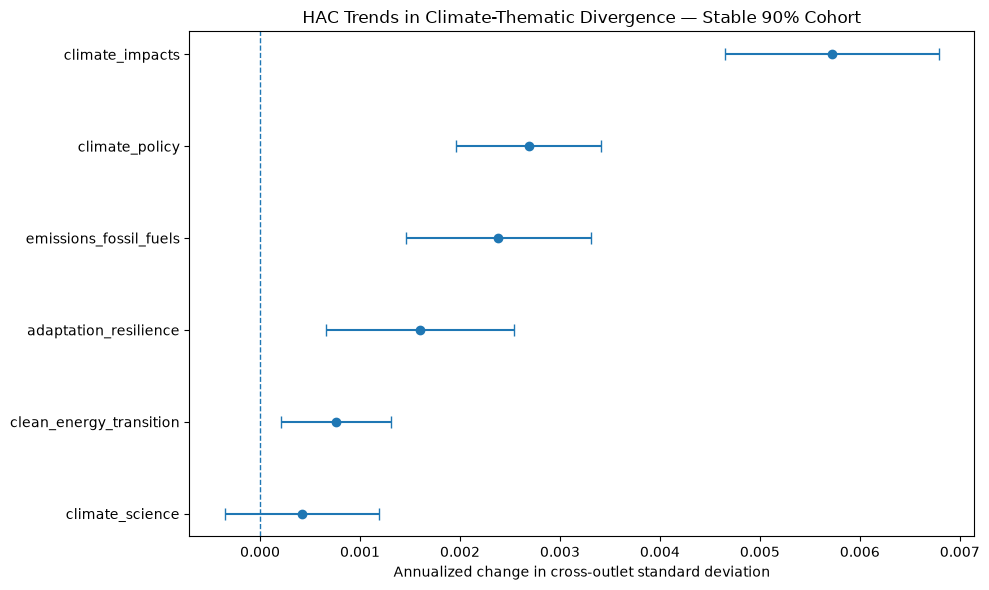

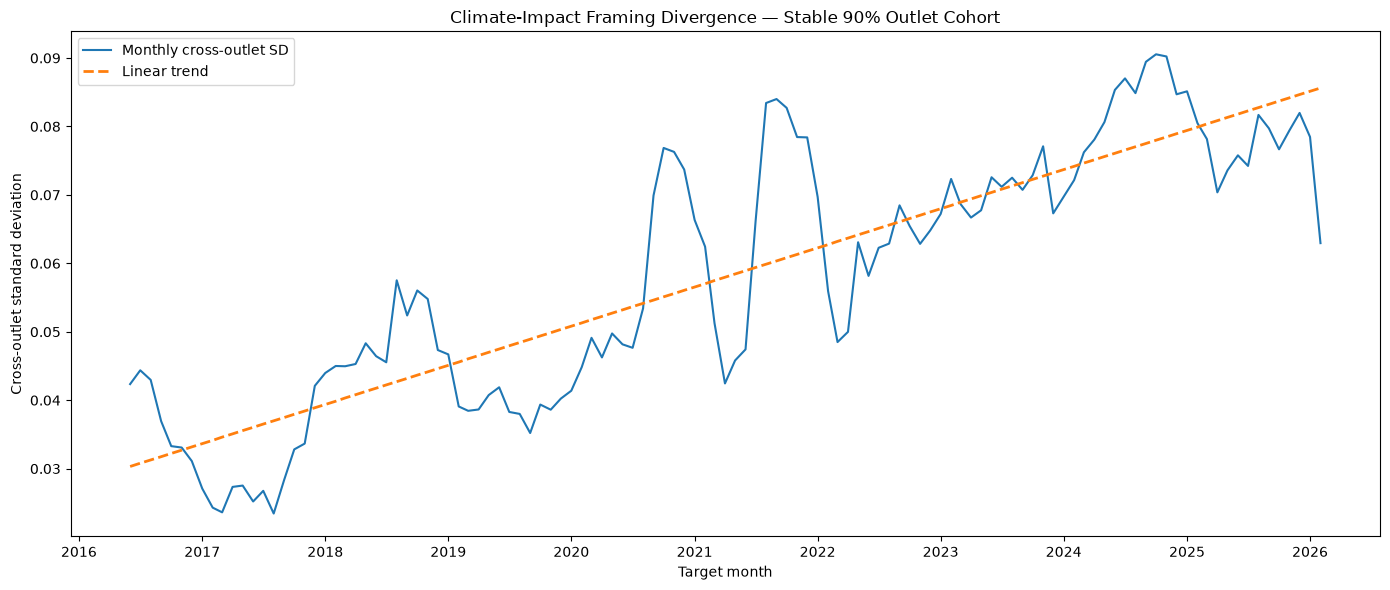


HAC LAG SENSITIVITY — CLIMATE IMPACTS


,panel,hac_lags,annualized_change,hac_se_annualized,ci_lower,ci_upper,p_value
16,dynamic_panel,6,0.004789,0.000531,0.003749,0.005829,0.0
17,dynamic_panel,12,0.004789,0.000572,0.003669,0.005910,0.0
64,fully_balanced,6,0.004926,0.000607,0.003736,0.006116,0.0
65,fully_balanced,12,0.004926,0.000597,0.003756,0.006095,0.0
40,stable_90,6,0.005720,0.000540,0.004663,0.006778,0.0
41,stable_90,12,0.005720,0.000545,0.004652,0.006788,0.0



ARTIFACT
HAC inference: /Users/lasya/Documents/projects/media-polarization-lab/data/processed/climate_dimension_hac_inference.parquet


In [57]:
# ============================================================
# CELL 33 — HAC INFERENCE FOR CLIMATE-THEMATIC DIVERGENCE
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / "data").exists():
    if (PROJECT_ROOT.parent / "data").exists():
        PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

PROFILE_PATH = (
    PROCESSED_DIR
    / "outlet_month_climate_dimension_profiles.parquet"
)

OUTPUT_PATH = (
    PROCESSED_DIR
    / "climate_dimension_hac_inference.parquet"
)

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

OUTLET_COL = "media_name"
MONTH_COL = "target_month"

ANCHORS = [
    "climate_science",
    "emissions_fossil_fuels",
    "clean_energy_transition",
    "climate_policy",
    "climate_impacts",
    "adaptation_resilience",
]

HAC_LAGS = [6, 12]

# ------------------------------------------------------------
# Load
# ------------------------------------------------------------

df = pd.read_parquet(PROFILE_PATH).copy()

df[MONTH_COL] = (
    pd.to_datetime(df[MONTH_COL].astype(str))
    .dt.to_period("M")
)

months = sorted(
    df[MONTH_COL]
    .dropna()
    .unique()
)

n_months = len(months)

month_index = {
    month: i
    for i, month in enumerate(months)
}

df["time_months"] = (
    df[MONTH_COL]
    .map(month_index)
    .astype(float)
)

print("=" * 72)
print("THEMATIC DIVERGENCE — HAC INFERENCE")
print("=" * 72)

print("Rows:", f"{len(df):,}")
print("Months:", n_months)
print("Outlets:", df[OUTLET_COL].nunique())
print("Dimensions:", len(ANCHORS))

# ------------------------------------------------------------
# Cohorts
# ------------------------------------------------------------

coverage = (
    df
    .groupby(OUTLET_COL)[MONTH_COL]
    .nunique()
)

stable_90 = (
    coverage[
        coverage >= np.ceil(
            0.90 * n_months
        )
    ]
    .index
    .tolist()
)

fully_balanced = (
    coverage[
        coverage == n_months
    ]
    .index
    .tolist()
)

panels = {
    "dynamic_panel": df.copy(),
    "stable_90": (
        df[
            df[OUTLET_COL]
            .isin(stable_90)
        ]
        .copy()
    ),
    "fully_balanced": (
        df[
            df[OUTLET_COL]
            .isin(fully_balanced)
        ]
        .copy()
    ),
}

print("\n" + "=" * 72)
print("PANEL SIZES")
print("=" * 72)

for name, panel in panels.items():
    print(
        f"{name:18s}",
        f"{panel[OUTLET_COL].nunique():3d} outlets",
        f"{len(panel):,} outlet-month rows",
    )

# ------------------------------------------------------------
# Build monthly cross-outlet dispersion
# ------------------------------------------------------------

records = []

for panel_name, panel_df in panels.items():

    for anchor in ANCHORS:

        score_col = f"relative_{anchor}"

        if score_col not in panel_df.columns:
            raise KeyError(
                f"Missing column: {score_col}"
            )

        monthly = (
            panel_df
            .groupby(MONTH_COL)[score_col]
            .agg(
                outlets="count",
                std="std",
                iqr=lambda s: (
                    s.quantile(0.75)
                    - s.quantile(0.25)
                ),
                mean="mean",
            )
            .reset_index()
        )

        monthly["panel"] = panel_name
        monthly["anchor"] = anchor

        monthly["time_months"] = (
            monthly[MONTH_COL]
            .map(month_index)
            .astype(float)
        )

        records.append(monthly)

monthly_dispersion = pd.concat(
    records,
    ignore_index=True,
)

# ------------------------------------------------------------
# HAC regression helper
# ------------------------------------------------------------

def hac_trend(
    data,
    outcome,
    lags,
):

    g = (
        data[
            [
                "time_months",
                outcome,
            ]
        ]
        .dropna()
        .sort_values("time_months")
        .copy()
    )

    X = sm.add_constant(
        g["time_months"]
    )

    model = sm.OLS(
        g[outcome],
        X,
    ).fit(
        cov_type="HAC",
        cov_kwds={
            "maxlags": lags
        },
    )

    slope_month = (
        model.params["time_months"]
    )

    annualized = (
        slope_month * 12
    )

    ci = model.conf_int().loc[
        "time_months"
    ]

    ci_lower_annual = (
        ci.iloc[0] * 12
    )

    ci_upper_annual = (
        ci.iloc[1] * 12
    )

    return {
        "n_months": len(g),
        "annualized_change": annualized,
        "hac_se_annualized": (
            model.bse["time_months"]
            * 12
        ),
        "ci_lower": ci_lower_annual,
        "ci_upper": ci_upper_annual,
        "t_value": (
            model.tvalues["time_months"]
        ),
        "p_value": (
            model.pvalues["time_months"]
        ),
        "r_squared": model.rsquared,
    }

# ------------------------------------------------------------
# Run inference
# ------------------------------------------------------------

inference_records = []

for panel_name in panels:

    for anchor in ANCHORS:

        subset = (
            monthly_dispersion[
                (
                    monthly_dispersion["panel"]
                    == panel_name
                )
                &
                (
                    monthly_dispersion["anchor"]
                    == anchor
                )
            ]
            .copy()
        )

        for outcome in ["std", "iqr"]:

            for lags in HAC_LAGS:

                result = hac_trend(
                    subset,
                    outcome,
                    lags,
                )

                inference_records.append(
                    {
                        "panel": panel_name,
                        "anchor": anchor,
                        "dispersion_measure": (
                            outcome
                        ),
                        "hac_lags": lags,
                        **result,
                    }
                )

results = pd.DataFrame(
    inference_records
)

results.to_parquet(
    OUTPUT_PATH,
    index=False,
)

# ------------------------------------------------------------
# Main STD results
# ------------------------------------------------------------

print("\n" + "=" * 72)
print("HAC TREND — CROSS-OUTLET STANDARD DEVIATION")
print("=" * 72)

std_results = (
    results[
        (
            results[
                "dispersion_measure"
            ] == "std"
        )
        &
        (
            results[
                "hac_lags"
            ] == 12
        )
    ]
    .copy()
)

display(
    std_results[
        [
            "panel",
            "anchor",
            "annualized_change",
            "hac_se_annualized",
            "ci_lower",
            "ci_upper",
            "p_value",
            "r_squared",
        ]
    ]
    .sort_values(
        [
            "panel",
            "annualized_change",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .round(6)
)

# ------------------------------------------------------------
# IQR robustness
# ------------------------------------------------------------

print("\n" + "=" * 72)
print("HAC TREND — CROSS-OUTLET IQR")
print("=" * 72)

iqr_results = (
    results[
        (
            results[
                "dispersion_measure"
            ] == "iqr"
        )
        &
        (
            results[
                "hac_lags"
            ] == 12
        )
    ]
    .copy()
)

display(
    iqr_results[
        [
            "panel",
            "anchor",
            "annualized_change",
            "hac_se_annualized",
            "ci_lower",
            "ci_upper",
            "p_value",
        ]
    ]
    .sort_values(
        [
            "panel",
            "annualized_change",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .round(6)
)

# ------------------------------------------------------------
# Climate-impact result specifically
# ------------------------------------------------------------

print("\n" + "=" * 72)
print("CLIMATE-IMPACT HAC ROBUSTNESS")
print("=" * 72)

impact_results = (
    results[
        results["anchor"]
        .eq("climate_impacts")
    ]
    .sort_values(
        [
            "dispersion_measure",
            "panel",
            "hac_lags",
        ]
    )
)

display(
    impact_results[
        [
            "panel",
            "dispersion_measure",
            "hac_lags",
            "annualized_change",
            "ci_lower",
            "ci_upper",
            "p_value",
            "r_squared",
        ]
    ]
    .round(6)
)

# ------------------------------------------------------------
# Significance summary
# ------------------------------------------------------------

primary = std_results.copy()

primary["significant_05"] = (
    primary["p_value"] < 0.05
)

primary["significant_01"] = (
    primary["p_value"] < 0.01
)

print("\n" + "=" * 72)
print("PRIMARY INFERENCE SUMMARY — HAC(12)")
print("=" * 72)

display(
    primary[
        [
            "panel",
            "anchor",
            "annualized_change",
            "ci_lower",
            "ci_upper",
            "p_value",
            "significant_05",
            "significant_01",
        ]
    ]
    .sort_values(
        [
            "anchor",
            "panel",
        ]
    )
    .round(6)
)

# ------------------------------------------------------------
# Plot annualized slopes + 95% confidence intervals
# Stable 90 panel
# ------------------------------------------------------------

plot_df = (
    primary[
        primary["panel"]
        .eq("stable_90")
    ]
    .copy()
    .sort_values(
        "annualized_change"
    )
)

y = np.arange(
    len(plot_df)
)

x = (
    plot_df[
        "annualized_change"
    ]
    .to_numpy()
)

lower = (
    x
    - plot_df[
        "ci_lower"
    ].to_numpy()
)

upper = (
    plot_df[
        "ci_upper"
    ].to_numpy()
    - x
)

plt.figure(
    figsize=(10, 6)
)

plt.errorbar(
    x,
    y,
    xerr=[
        lower,
        upper,
    ],
    fmt="o",
    capsize=4,
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1,
)

plt.yticks(
    y,
    plot_df["anchor"]
)

plt.xlabel(
    "Annualized change in "
    "cross-outlet standard deviation"
)

plt.title(
    "HAC Trends in Climate-Thematic "
    "Divergence — Stable 90% Cohort"
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Climate impact: monthly dispersion and fitted trend
# ------------------------------------------------------------

impact_monthly = (
    monthly_dispersion[
        (
            monthly_dispersion["panel"]
            == "stable_90"
        )
        &
        (
            monthly_dispersion["anchor"]
            == "climate_impacts"
        )
    ]
    .dropna(
        subset=["std"]
    )
    .sort_values(MONTH_COL)
    .copy()
)

x_month = (
    impact_monthly[
        "time_months"
    ]
    .to_numpy()
)

y_std = (
    impact_monthly[
        "std"
    ]
    .to_numpy()
)

coef = np.polyfit(
    x_month,
    y_std,
    1,
)

fitted = (
    coef[0] * x_month
    + coef[1]
)

impact_monthly["month_ts"] = (
    impact_monthly[
        MONTH_COL
    ]
    .dt.to_timestamp()
)

plt.figure(
    figsize=(14, 6)
)

plt.plot(
    impact_monthly["month_ts"],
    y_std,
    label="Monthly cross-outlet SD",
)

plt.plot(
    impact_monthly["month_ts"],
    fitted,
    linestyle="--",
    linewidth=2,
    label="Linear trend",
)

plt.xlabel("Target month")
plt.ylabel(
    "Cross-outlet standard deviation"
)

plt.title(
    "Climate-Impact Framing Divergence "
    "— Stable 90% Outlet Cohort"
)

plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# HAC lag sensitivity
# ------------------------------------------------------------

print("\n" + "=" * 72)
print("HAC LAG SENSITIVITY — CLIMATE IMPACTS")
print("=" * 72)

display(
    results[
        (
            results["anchor"]
            == "climate_impacts"
        )
        &
        (
            results[
                "dispersion_measure"
            ] == "std"
        )
    ][
        [
            "panel",
            "hac_lags",
            "annualized_change",
            "hac_se_annualized",
            "ci_lower",
            "ci_upper",
            "p_value",
        ]
    ]
    .sort_values(
        [
            "panel",
            "hac_lags",
        ]
    )
    .round(6)
)

print("\n" + "=" * 72)
print("ARTIFACT")
print("=" * 72)

print(
    "HAC inference:",
    OUTPUT_PATH,
)

CLIMATE-IMPACT TEMPORAL-SHAPE ROBUSTNESS
Input: /Users/lasya/Documents/projects/media-polarization-lab/data/processed/outlet_month_climate_dimension_profiles.parquet
Rows loaded: 7,378
Outlet column: media_name
Month column:  target_month
Dimension:     relative_climate_impacts

STUDY PERIOD
Months: 117
First month: 2016-06
Last month:  2026-02
Outlets:     136

FROZEN OUTLET COHORTS
Dynamic panel:       136 outlets
Stable >=90% panel:  20 outlets
Fully balanced:      6 outlets

TEMPORAL ROBUSTNESS SUMMARY


/var/folders/w0/3gcyvg0s5dnd4ykcbv1pb2100000gn/T/ipykernel_27110/2430597094.py:515: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  ].round(6)


,panel,sample,months,first_month,last_month,annualized_change,hac_se,ci_lower,ci_upper,p_value,r_squared,spearman_rho,spearman_p_value
0,dynamic_panel,full_sample,117,2016-06,2026-02,0.004789,0.000572,0.003657,0.005922,0.000000,0.679459,0.781707,0.0
1,dynamic_panel,drop_incomplete_2026_02,116,2016-06,2026-01,0.004915,0.000540,0.003846,0.005985,0.000000,0.697409,0.790528,0.0
2,dynamic_panel,exclude_2020_2021,92,2016-06,2026-01,0.006489,0.000766,0.004967,0.008012,0.000000,0.722390,0.803909,0.0
3,dynamic_panel,exclude_2024_plus,91,2016-06,2023-12,0.005906,0.000741,0.004434,0.007378,0.000000,0.666052,0.802166,0.0
4,stable_90,full_sample,117,2016-06,2026-02,0.005720,0.000545,0.004641,0.006799,0.000000,0.749179,0.857970,0.0
5,stable_90,drop_incomplete_2026_02,116,2016-06,2026-01,0.005843,0.000510,0.004832,0.006853,0.000000,0.762164,0.866152,0.0
6,stable_90,exclude_2020_2021,92,2016-06,2026-01,0.007986,0.000803,0.006390,0.009583,0.000000,0.824214,0.903195,0.0
7,stable_90,exclude_2024_plus,91,2016-06,2023-12,0.005947,0.000627,0.004701,0.007194,0.000000,0.647778,0.810065,0.0
8,fully_balanced,full_sample,117,2016-06,2026-02,0.004926,0.000597,0.003744,0.006108,0.000000,0.580687,0.784292,0.0
9,fully_balanced,drop_incomplete_2026_02,116,2016-06,2026-01,0.004941,0.000611,0.003731,0.006151,0.000000,0.576013,0.781855,0.0



EARLY / MIDDLE / LATE CLIMATE-IMPACT DISPERSION


/var/folders/w0/3gcyvg0s5dnd4ykcbv1pb2100000gn/T/ipykernel_27110/2430597094.py:589: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  period_summary.round(5)


...

period,panel,early,middle,late,early_to_late_change,early_to_late_pct_change
0,dynamic_panel,0.04075,0.06447,0.07249,0.03174,77.874496
1,fully_balanced,0.02657,0.04909,0.05954,0.03297,124.074318
2,stable_90,0.03887,0.05864,0.07675,0.03788,97.468727



LEAVE-ONE-YEAR-OUT ROBUSTNESS


,panel,years_tested,min_annualized_change,median_annualized_change,max_annualized_change,max_p_value,min_ci_lower
0,dynamic_panel,11,0.004719,0.005408,0.005745,0.0,0.003444
1,fully_balanced,11,0.004558,0.005501,0.005978,0.0,0.003204
2,stable_90,11,0.005567,0.006429,0.006905,0.0,0.004503



YEARS WHOSE REMOVAL MOST WEAKENS THE TREND


,panel,omitted_year,annualized_change,hac_se,ci_lower,ci_upper,p_value,r_squared
1,dynamic_panel,2017,0.004719,0.000643,0.003444,0.005994,0.0,0.627105
10,dynamic_panel,2026,0.004983,0.000531,0.003930,0.006036,0.0,0.701218
3,dynamic_panel,2019,0.005161,0.000776,0.003622,0.006699,0.0,0.659916
23,fully_balanced,2017,0.004558,0.000660,0.003250,0.005866,0.0,0.495395
31,fully_balanced,2025,0.004611,0.000709,0.003204,0.006018,0.0,0.464821
32,fully_balanced,2026,0.004936,0.000622,0.003704,0.006168,0.0,0.569187
12,stable_90,2017,0.005567,0.000536,0.004503,0.006630,0.0,0.706101
21,stable_90,2026,0.005883,0.000507,0.004879,0.006888,0.0,0.761069
19,stable_90,2024,0.005979,0.000480,0.005028,0.006930,0.0,0.729801


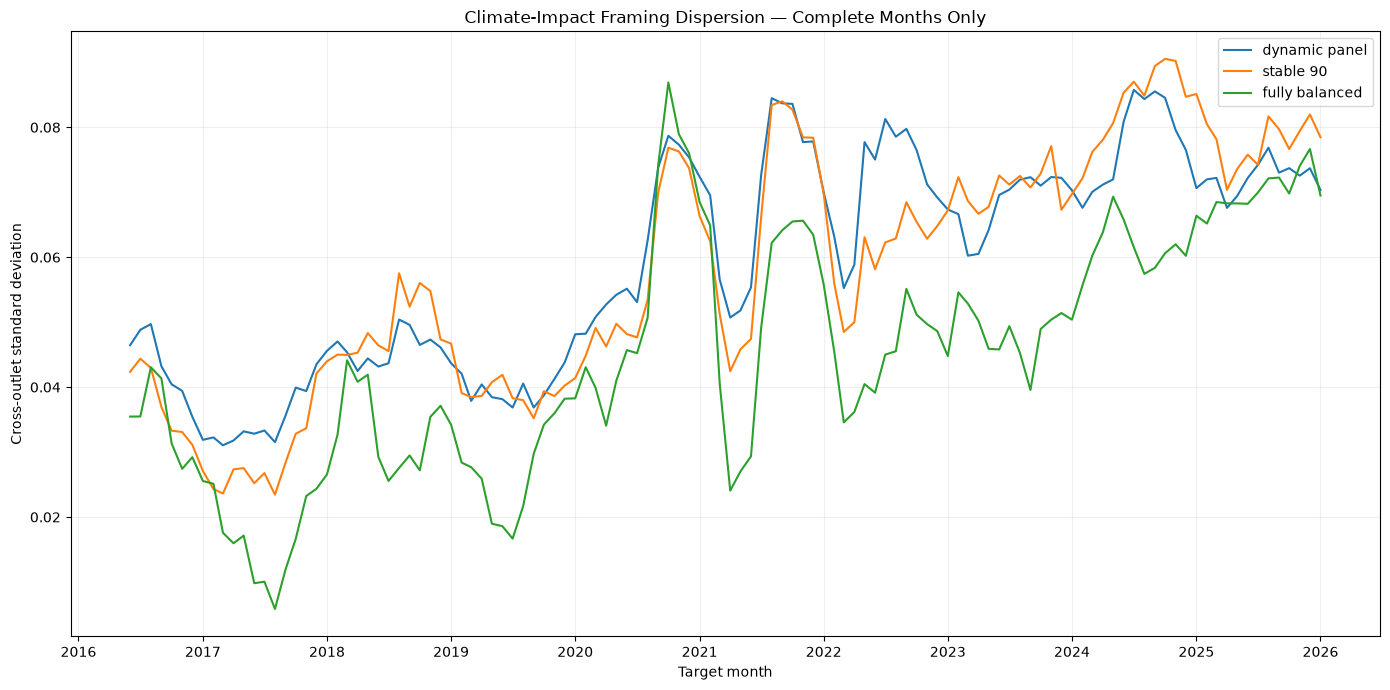

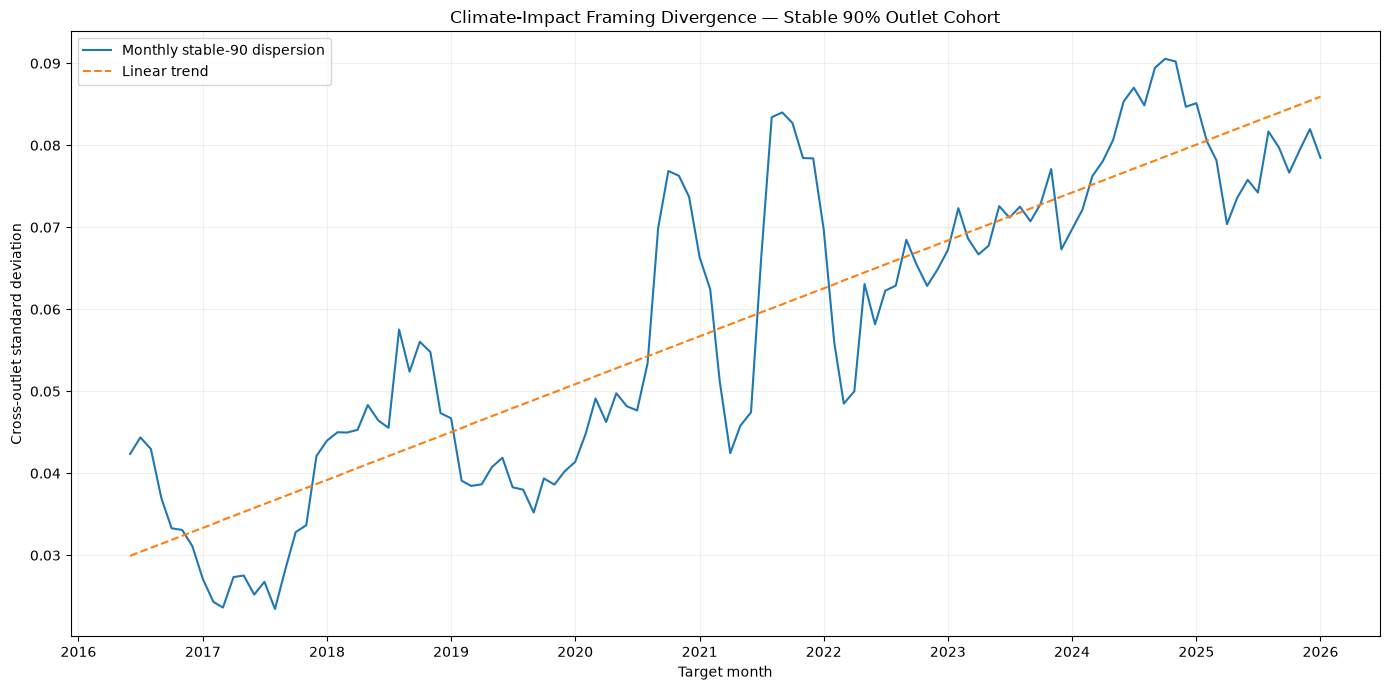

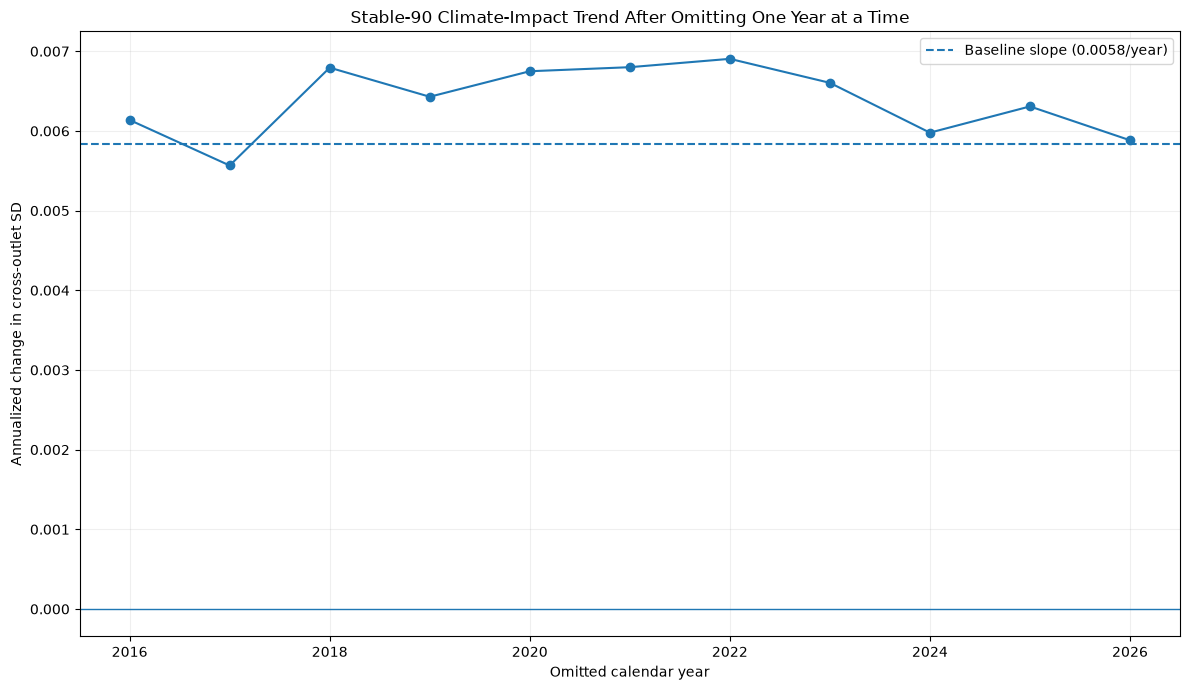

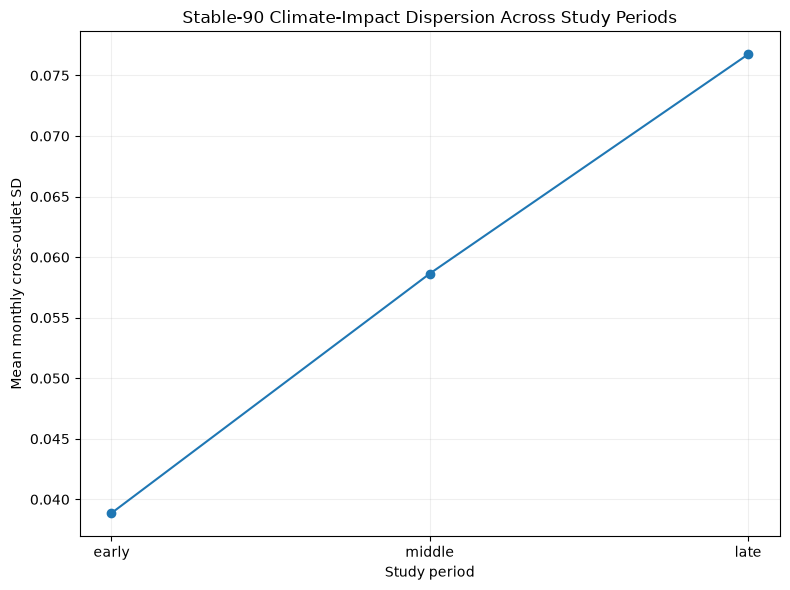


TEMPORAL ROBUSTNESS ARTIFACTS
Summary: /Users/lasya/Documents/projects/media-polarization-lab/data/processed/climate_impact_temporal_robustness.parquet
LOYO:    /Users/lasya/Documents/projects/media-polarization-lab/data/processed/climate_impact_leave_one_year_out.parquet
Periods: /Users/lasya/Documents/projects/media-polarization-lab/data/processed/climate_impact_period_comparison.parquet


In [58]:
# ============================================================
# CELL 34 — TEMPORAL-SHAPE ROBUSTNESS
#
# Purpose:
#   Test whether the long-run rise in climate-impact framing
#   dispersion survives:
#     1. dropping incomplete 2026-02
#     2. non-parametric monotonic trend tests
#     3. early / middle / late comparisons
#     4. leave-one-calendar-year-out analysis
#     5. excluding 2020–2021
#     6. excluding 2024–2026
#
# Primary quantity:
#   Monthly cross-outlet SD of relative_climate_impacts
#
# Important:
#   Outlet cohorts are defined ONCE using the original analysis
#   panel so that robustness checks do not change composition.
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr
import statsmodels.api as sm


# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

PROJECT_ROOT = Path(
    "/Users/lasya/Documents/projects/media-polarization-lab"
)

INPUT_PATH = (
    PROJECT_ROOT
    / "data/processed/outlet_month_climate_dimension_profiles.parquet"
)

OUTPUT_SUMMARY_PATH = (
    PROJECT_ROOT
    / "data/processed/climate_impact_temporal_robustness.parquet"
)

OUTPUT_LOYO_PATH = (
    PROJECT_ROOT
    / "data/processed/climate_impact_leave_one_year_out.parquet"
)

OUTPUT_PERIOD_PATH = (
    PROJECT_ROOT
    / "data/processed/climate_impact_period_comparison.parquet"
)


# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

DIMENSION = "relative_climate_impacts"

STABLE_COVERAGE_THRESHOLD = 0.90

# Our final month is known to be incomplete.
INCOMPLETE_MONTH = pd.Period("2026-02", freq="M")

HAC_LAGS = 12


# ------------------------------------------------------------
# LOAD
# ------------------------------------------------------------

df = pd.read_parquet(INPUT_PATH).copy()

print("=" * 72)
print("CLIMATE-IMPACT TEMPORAL-SHAPE ROBUSTNESS")
print("=" * 72)
print(f"Input: {INPUT_PATH}")
print(f"Rows loaded: {len(df):,}")


# ------------------------------------------------------------
# DETECT COLUMNS
# ------------------------------------------------------------

possible_outlet_cols = [
    "media_name",
    "outlet",
    "source",
]

possible_month_cols = [
    "target_month",
    "year_month",
    "month",
]

outlet_col = next(
    (c for c in possible_outlet_cols if c in df.columns),
    None
)

month_col = next(
    (c for c in possible_month_cols if c in df.columns),
    None
)

if outlet_col is None:
    raise ValueError(
        "Could not identify outlet column. "
        f"Columns found:\n{df.columns.tolist()}"
    )

if month_col is None:
    raise ValueError(
        "Could not identify month column. "
        f"Columns found:\n{df.columns.tolist()}"
    )

if DIMENSION not in df.columns:
    raise ValueError(
        f"Required dimension '{DIMENSION}' not found.\n"
        f"Available columns:\n{df.columns.tolist()}"
    )

print(f"Outlet column: {outlet_col}")
print(f"Month column:  {month_col}")
print(f"Dimension:     {DIMENSION}")


# ------------------------------------------------------------
# NORMALIZE MONTH
# ------------------------------------------------------------

def to_month_period(series):
    """
    Robust conversion of target-month values to monthly Periods.
    """
    if isinstance(series.dtype, pd.PeriodDtype):
        return series.dt.asfreq("M")

    return pd.to_datetime(series).dt.to_period("M")


df["analysis_month"] = to_month_period(df[month_col])

df = (
    df[
        df["analysis_month"].notna()
        & df[outlet_col].notna()
        & df[DIMENSION].notna()
    ]
    .copy()
)

study_months = sorted(df["analysis_month"].unique())

print()
print("=" * 72)
print("STUDY PERIOD")
print("=" * 72)
print(f"Months: {len(study_months)}")
print(f"First month: {min(study_months)}")
print(f"Last month:  {max(study_months)}")
print(f"Outlets:     {df[outlet_col].nunique():,}")


# ------------------------------------------------------------
# DEFINE OUTLET COHORTS ONCE
#
# IMPORTANT:
# These cohorts are frozen using the ORIGINAL study period.
# Dropping 2026-02 later therefore cannot change cohort membership.
# ------------------------------------------------------------

month_count = len(study_months)

outlet_month_counts = (
    df.groupby(outlet_col)["analysis_month"]
    .nunique()
    .sort_values(ascending=False)
)

stable_90_outlets = set(
    outlet_month_counts[
        outlet_month_counts >= np.ceil(
            STABLE_COVERAGE_THRESHOLD * month_count
        )
    ].index
)

fully_balanced_outlets = set(
    outlet_month_counts[
        outlet_month_counts == month_count
    ].index
)

all_outlets = set(df[outlet_col].unique())

print()
print("=" * 72)
print("FROZEN OUTLET COHORTS")
print("=" * 72)
print(f"Dynamic panel:       {len(all_outlets):,} outlets")
print(
    f"Stable >=90% panel:  "
    f"{len(stable_90_outlets):,} outlets"
)
print(
    f"Fully balanced:      "
    f"{len(fully_balanced_outlets):,} outlets"
)


# ------------------------------------------------------------
# MONTHLY CROSS-OUTLET DISPERSION
# ------------------------------------------------------------

def build_monthly_dispersion(data, outlets=None):
    """
    Calculate monthly cross-outlet SD and related diagnostics.
    """

    temp = data.copy()

    if outlets is not None:
        temp = temp[temp[outlet_col].isin(outlets)].copy()

    result = (
        temp.groupby("analysis_month")
        .agg(
            outlets=(outlet_col, "nunique"),
            climate_impact_mean=(DIMENSION, "mean"),
            climate_impact_std=(DIMENSION, "std"),
            climate_impact_iqr=(
                DIMENSION,
                lambda x: x.quantile(0.75) - x.quantile(0.25)
            ),
        )
        .reset_index()
        .sort_values("analysis_month")
        .reset_index(drop=True)
    )

    result["year"] = result["analysis_month"].dt.year

    return result


panel_monthly = {
    "dynamic_panel": build_monthly_dispersion(
        df,
        all_outlets
    ),
    "stable_90": build_monthly_dispersion(
        df,
        stable_90_outlets
    ),
    "fully_balanced": build_monthly_dispersion(
        df,
        fully_balanced_outlets
    ),
}


# ------------------------------------------------------------
# TREND FUNCTION
# ------------------------------------------------------------

def hac_linear_trend(
    monthly_df,
    value_col="climate_impact_std",
    hac_lags=12,
):
    """
    Linear time trend with Newey-West / HAC standard errors.

    Time variable is measured in years so slope is directly
    interpretable as annualized change.
    """

    xdf = (
        monthly_df[
            ["analysis_month", value_col]
        ]
        .dropna()
        .sort_values("analysis_month")
        .reset_index(drop=True)
    )

    if len(xdf) < 3:
        return {
            "months": len(xdf),
            "annualized_change": np.nan,
            "hac_se": np.nan,
            "ci_lower": np.nan,
            "ci_upper": np.nan,
            "p_value": np.nan,
            "r_squared": np.nan,
        }

    # monthly observations expressed in years
    xdf["time_years"] = (
        np.arange(len(xdf), dtype=float) / 12.0
    )

    X = sm.add_constant(xdf["time_years"])
    y = xdf[value_col].astype(float)

    ols = sm.OLS(y, X).fit()

    maxlags = min(
        hac_lags,
        max(1, len(xdf) - 2)
    )

    hac = ols.get_robustcov_results(
        cov_type="HAC",
        maxlags=maxlags
    )

    # params order: constant, time_years
    slope = float(hac.params[1])
    se = float(hac.bse[1])
    p = float(hac.pvalues[1])

    ci = np.asarray(hac.conf_int())
    ci_lower = float(ci[1, 0])
    ci_upper = float(ci[1, 1])

    return {
        "months": len(xdf),
        "annualized_change": slope,
        "hac_se": se,
        "ci_lower": ci_lower,
        "ci_upper": ci_upper,
        "p_value": p,
        "r_squared": float(ols.rsquared),
    }


# ------------------------------------------------------------
# SPEARMAN TREND
# ------------------------------------------------------------

def spearman_time_trend(
    monthly_df,
    value_col="climate_impact_std",
):
    xdf = (
        monthly_df[
            ["analysis_month", value_col]
        ]
        .dropna()
        .sort_values("analysis_month")
        .reset_index(drop=True)
    )

    if len(xdf) < 3:
        return np.nan, np.nan

    time_index = np.arange(len(xdf))

    rho, p = spearmanr(
        time_index,
        xdf[value_col].to_numpy()
    )

    return float(rho), float(p)


# ------------------------------------------------------------
# GENERAL SPECIFICATION RUNNER
# ------------------------------------------------------------

def evaluate_time_sample(
    monthly_df,
    sample_name,
    panel_name,
):
    trend = hac_linear_trend(
        monthly_df,
        value_col="climate_impact_std",
        hac_lags=HAC_LAGS,
    )

    rho, rho_p = spearman_time_trend(
        monthly_df,
        value_col="climate_impact_std",
    )

    out = {
        "panel": panel_name,
        "sample": sample_name,
        "first_month": (
            monthly_df["analysis_month"].min()
            if len(monthly_df)
            else pd.NaT
        ),
        "last_month": (
            monthly_df["analysis_month"].max()
            if len(monthly_df)
            else pd.NaT
        ),
        **trend,
        "spearman_rho": rho,
        "spearman_p_value": rho_p,
        "mean_dispersion": (
            monthly_df["climate_impact_std"].mean()
        ),
    }

    return out


# ------------------------------------------------------------
# MAIN SAMPLE ROBUSTNESS
# ------------------------------------------------------------

summary_rows = []

for panel_name, monthly in panel_monthly.items():

    # --------------------------------------------------------
    # Original full analytical period
    # --------------------------------------------------------

    summary_rows.append(
        evaluate_time_sample(
            monthly,
            "full_sample",
            panel_name,
        )
    )

    # --------------------------------------------------------
    # Remove incomplete February 2026
    # --------------------------------------------------------

    complete_months = monthly[
        monthly["analysis_month"] < INCOMPLETE_MONTH
    ].copy()

    summary_rows.append(
        evaluate_time_sample(
            complete_months,
            "drop_incomplete_2026_02",
            panel_name,
        )
    )

    # --------------------------------------------------------
    # Exclude pandemic-centered period 2020–2021
    # --------------------------------------------------------

    no_2020_21 = complete_months[
        ~complete_months["year"].isin([2020, 2021])
    ].copy()

    summary_rows.append(
        evaluate_time_sample(
            no_2020_21,
            "exclude_2020_2021",
            panel_name,
        )
    )

    # --------------------------------------------------------
    # Exclude recent high-dispersion period 2024+
    # --------------------------------------------------------

    no_2024_plus = complete_months[
        complete_months["year"] < 2024
    ].copy()

    summary_rows.append(
        evaluate_time_sample(
            no_2024_plus,
            "exclude_2024_plus",
            panel_name,
        )
    )


temporal_summary = pd.DataFrame(summary_rows)

print()
print("=" * 72)
print("TEMPORAL ROBUSTNESS SUMMARY")
print("=" * 72)

display(
    temporal_summary[
        [
            "panel",
            "sample",
            "months",
            "first_month",
            "last_month",
            "annualized_change",
            "hac_se",
            "ci_lower",
            "ci_upper",
            "p_value",
            "r_squared",
            "spearman_rho",
            "spearman_p_value",
        ]
    ].round(6)
)


# ------------------------------------------------------------
# EARLY / MIDDLE / LATE PERIOD COMPARISON
#
# Use COMPLETE months only and split chronologically into
# three approximately equal blocks.
# ------------------------------------------------------------

period_rows = []

for panel_name, monthly in panel_monthly.items():

    complete = (
        monthly[
            monthly["analysis_month"] < INCOMPLETE_MONTH
        ]
        .sort_values("analysis_month")
        .reset_index(drop=True)
    )

    n = len(complete)

    # Three chronological blocks as evenly sized as possible
    period_labels = np.array_split(
        np.arange(n),
        3
    )

    names = ["early", "middle", "late"]

    for period_name, idx in zip(
        names,
        period_labels
    ):
        piece = complete.iloc[idx]

        period_rows.append(
            {
                "panel": panel_name,
                "period": period_name,
                "months": len(piece),
                "first_month": piece[
                    "analysis_month"
                ].min(),
                "last_month": piece[
                    "analysis_month"
                ].max(),
                "mean_std": piece[
                    "climate_impact_std"
                ].mean(),
                "median_std": piece[
                    "climate_impact_std"
                ].median(),
                "mean_iqr": piece[
                    "climate_impact_iqr"
                ].mean(),
                "mean_outlets": piece[
                    "outlets"
                ].mean(),
            }
        )


period_summary = pd.DataFrame(period_rows)

print()
print("=" * 72)
print("EARLY / MIDDLE / LATE CLIMATE-IMPACT DISPERSION")
print("=" * 72)

display(
    period_summary.round(5)
)


# ------------------------------------------------------------
# EARLY -> LATE CHANGE
# ------------------------------------------------------------

period_pivot = (
    period_summary
    .pivot(
        index="panel",
        columns="period",
        values="mean_std"
    )
    .reset_index()
)

period_pivot["early_to_late_change"] = (
    period_pivot["late"]
    - period_pivot["early"]
)

period_pivot["early_to_late_pct_change"] = (
    100
    * period_pivot["early_to_late_change"]
    / period_pivot["early"]
)

print()
print("=" * 72)
print("EARLY -> LATE CHANGE")
print("=" * 72)

display(
    period_pivot[
        [
            "panel",
            "early",
            "middle",
            "late",
            "early_to_late_change",
            "early_to_late_pct_change",
        ]
    ].round(5)
)


# ------------------------------------------------------------
# LEAVE-ONE-CALENDAR-YEAR-OUT
#
# Main specification is stable_90.
# We also do dynamic and fully balanced so the result cannot
# be attributed to one particular panel definition.
# ------------------------------------------------------------

loyo_rows = []

for panel_name, monthly in panel_monthly.items():

    complete = monthly[
        monthly["analysis_month"] < INCOMPLETE_MONTH
    ].copy()

    years = sorted(
        complete["year"].dropna().unique()
    )

    baseline = hac_linear_trend(
        complete,
        "climate_impact_std",
        HAC_LAGS,
    )

    for omitted_year in years:

        reduced = complete[
            complete["year"] != omitted_year
        ].copy()

        trend = hac_linear_trend(
            reduced,
            "climate_impact_std",
            HAC_LAGS,
        )

        loyo_rows.append(
            {
                "panel": panel_name,
                "omitted_year": int(
                    omitted_year
                ),
                "baseline_annualized_change":
                    baseline["annualized_change"],
                **trend,
            }
        )


loyo = pd.DataFrame(loyo_rows)

print()
print("=" * 72)
print("LEAVE-ONE-YEAR-OUT ROBUSTNESS")
print("=" * 72)

loyo_summary = (
    loyo
    .groupby("panel")
    .agg(
        years_tested=("omitted_year", "count"),
        min_annualized_change=(
            "annualized_change",
            "min"
        ),
        median_annualized_change=(
            "annualized_change",
            "median"
        ),
        max_annualized_change=(
            "annualized_change",
            "max"
        ),
        max_p_value=("p_value", "max"),
        min_ci_lower=("ci_lower", "min"),
    )
    .reset_index()
)

display(
    loyo_summary.round(6)
)


# ------------------------------------------------------------
# SHOW YEAR MOST CAPABLE OF WEAKENING RESULT
# ------------------------------------------------------------

weakest_by_panel = (
    loyo
    .sort_values(
        ["panel", "annualized_change"]
    )
    .groupby("panel")
    .head(3)
)

print()
print("=" * 72)
print("YEARS WHOSE REMOVAL MOST WEAKENS THE TREND")
print("=" * 72)

display(
    weakest_by_panel[
        [
            "panel",
            "omitted_year",
            "annualized_change",
            "hac_se",
            "ci_lower",
            "ci_upper",
            "p_value",
            "r_squared",
        ]
    ].round(6)
)


# ------------------------------------------------------------
# PLOT 1
# Complete-month climate-impact dispersion by panel
# ------------------------------------------------------------

plt.figure(figsize=(14, 7))

for panel_name, monthly in panel_monthly.items():

    plot_df = monthly[
        monthly["analysis_month"] < INCOMPLETE_MONTH
    ].copy()

    dates = plot_df[
        "analysis_month"
    ].dt.to_timestamp()

    plt.plot(
        dates,
        plot_df["climate_impact_std"],
        label=panel_name.replace("_", " "),
    )

plt.title(
    "Climate-Impact Framing Dispersion — "
    "Complete Months Only"
)
plt.xlabel("Target month")
plt.ylabel("Cross-outlet standard deviation")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# PLOT 2
# Stable-90 linear trend on complete months
# ------------------------------------------------------------

main = (
    panel_monthly["stable_90"][
        panel_monthly["stable_90"][
            "analysis_month"
        ] < INCOMPLETE_MONTH
    ]
    .copy()
    .sort_values("analysis_month")
    .reset_index(drop=True)
)

main["time_years"] = (
    np.arange(len(main)) / 12
)

ols = sm.OLS(
    main["climate_impact_std"],
    sm.add_constant(
        main["time_years"]
    )
).fit()

main["linear_fit"] = ols.predict(
    sm.add_constant(
        main["time_years"]
    )
)

plt.figure(figsize=(14, 7))

dates = main[
    "analysis_month"
].dt.to_timestamp()

plt.plot(
    dates,
    main["climate_impact_std"],
    label="Monthly stable-90 dispersion",
)

plt.plot(
    dates,
    main["linear_fit"],
    linestyle="--",
    label="Linear trend",
)

plt.title(
    "Climate-Impact Framing Divergence — "
    "Stable 90% Outlet Cohort"
)
plt.xlabel("Target month")
plt.ylabel("Cross-outlet standard deviation")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# PLOT 3
# Leave-one-year-out slope distribution
# ------------------------------------------------------------

plt.figure(figsize=(12, 7))

stable_loyo = (
    loyo[
        loyo["panel"] == "stable_90"
    ]
    .sort_values("omitted_year")
)

plt.plot(
    stable_loyo["omitted_year"],
    stable_loyo["annualized_change"],
    marker="o",
)

baseline_slope = float(
    stable_loyo[
        "baseline_annualized_change"
    ].iloc[0]
)

plt.axhline(
    baseline_slope,
    linestyle="--",
    label=(
        f"Baseline slope "
        f"({baseline_slope:.4f}/year)"
    ),
)

plt.axhline(
    0,
    linewidth=1,
)

plt.title(
    "Stable-90 Climate-Impact Trend "
    "After Omitting One Year at a Time"
)
plt.xlabel("Omitted calendar year")
plt.ylabel(
    "Annualized change in cross-outlet SD"
)
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# PLOT 4
# Early / middle / late comparison
# ------------------------------------------------------------

plot_period = (
    period_summary[
        period_summary["panel"]
        == "stable_90"
    ]
    .set_index("period")
    .loc[
        ["early", "middle", "late"]
    ]
)

plt.figure(figsize=(8, 6))

plt.plot(
    plot_period.index,
    plot_period["mean_std"],
    marker="o",
)

plt.title(
    "Stable-90 Climate-Impact Dispersion "
    "Across Study Periods"
)
plt.xlabel("Study period")
plt.ylabel(
    "Mean monthly cross-outlet SD"
)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# SAVE ARTIFACTS
# ------------------------------------------------------------

temporal_summary.to_parquet(
    OUTPUT_SUMMARY_PATH,
    index=False
)

loyo.to_parquet(
    OUTPUT_LOYO_PATH,
    index=False
)

period_summary.to_parquet(
    OUTPUT_PERIOD_PATH,
    index=False
)

print()
print("=" * 72)
print("TEMPORAL ROBUSTNESS ARTIFACTS")
print("=" * 72)
print(f"Summary: {OUTPUT_SUMMARY_PATH}")
print(f"LOYO:    {OUTPUT_LOYO_PATH}")
print(f"Periods: {OUTPUT_PERIOD_PATH}")

THEMATIC TREND CONTRASTS
Input: /Users/lasya/Documents/projects/media-polarization-lab/data/processed/outlet_month_climate_dimension_profiles.parquet
Rows: 7,378

COMPLETE-MONTH STUDY PANEL
Months: 116
First:  2016-06
Last:   2026-01
Outlets observed: 136

FROZEN COHORTS
dynamic_panel      136 outlets
stable_90           20 outlets
fully_balanced       6 outlets

MONTHLY DISPERSION DATASET
Rows: 348
Months per panel: {'dynamic_panel': 116, 'fully_balanced': 116, 'stable_90': 116}

INDIVIDUAL THEMATIC DISPERSION TRENDS


,panel,dimension,annualized_change,hac_se,ci_lower,ci_upper,p_value,r_squared
4,dynamic_panel,climate_impacts,0.004915,0.000540,0.003846,0.005985,0.000000,0.697409
3,dynamic_panel,climate_policy,0.001629,0.000328,0.000979,0.002278,0.000002,0.537115
2,dynamic_panel,clean_energy_transition,0.001431,0.000409,0.000621,0.002242,0.000664,0.356459
1,dynamic_panel,emissions_fossil_fuels,0.001386,0.000432,0.000531,0.002242,0.001723,0.389843
5,dynamic_panel,adaptation_resilience,0.001265,0.000353,0.000565,0.001964,0.000505,0.354058
0,dynamic_panel,climate_science,-0.000173,0.000304,-0.000776,0.000430,0.570295,0.013904
10,fully_balanced,climate_impacts,0.004941,0.000611,0.003731,0.006151,0.000000,0.576013
7,fully_balanced,emissions_fossil_fuels,0.003760,0.000508,0.002754,0.004766,0.000000,0.691684
9,fully_balanced,climate_policy,0.003130,0.000492,0.002156,0.004104,0.000000,0.569183
11,fully_balanced,adaptation_resilience,0.001352,0.000299,0.000760,0.001944,0.000015,0.259674



DIRECT HAC TREND CONTRASTS


,panel,comparison_dimension,annualized_change,hac_se,ci_lower,ci_upper,p_value,r_squared
0,dynamic_panel,climate_science,0.005088,0.000534,0.004031,0.006145,0.000000,0.753927
4,dynamic_panel,adaptation_resilience,0.003650,0.000382,0.002894,0.004407,0.000000,0.575753
1,dynamic_panel,emissions_fossil_fuels,0.003529,0.000320,0.002895,0.004162,0.000000,0.626949
2,dynamic_panel,clean_energy_transition,0.003484,0.000231,0.003027,0.003941,0.000000,0.668704
3,dynamic_panel,climate_policy,0.003286,0.000681,0.001938,0.004635,0.000004,0.543773
7,fully_balanced,clean_energy_transition,0.005570,0.000906,0.003775,0.007365,0.000000,0.555278
5,fully_balanced,climate_science,0.004683,0.000815,0.003068,0.006297,0.000000,0.554001
9,fully_balanced,adaptation_resilience,0.003589,0.000616,0.002369,0.004809,0.000000,0.395394
8,fully_balanced,climate_policy,0.001811,0.000655,0.000514,0.003108,0.006636,0.145380
6,fully_balanced,emissions_fossil_fuels,0.001181,0.000651,-0.000108,0.002470,0.072224,0.083110



PRIMARY CONTRAST — CLIMATE IMPACTS MINUS CLIMATE SCIENCE


,panel,annualized_change,hac_se,ci_lower,ci_upper,p_value,r_squared
0,dynamic_panel,0.005088,0.000534,0.004031,0.006145,0.0,0.753927
5,fully_balanced,0.004683,0.000815,0.003068,0.006297,0.0,0.554001
10,stable_90,0.005383,0.000380,0.004631,0.006135,0.0,0.777297



IMPACTS VS SCIENCE — STUDY PERIODS


,panel,period,impact_std,science_std,impact_minus_science
0,dynamic_panel,early,0.04075,0.03247,0.00828
1,dynamic_panel,middle,0.06447,0.03160,0.03287
2,dynamic_panel,late,0.07249,0.03034,0.04215
3,fully_balanced,early,0.02657,0.02890,-0.00233
4,fully_balanced,middle,0.04909,0.03511,0.01398
5,fully_balanced,late,0.05954,0.02961,0.02992
6,stable_90,early,0.03887,0.02887,0.01000
7,stable_90,middle,0.05864,0.03359,0.02505
8,stable_90,late,0.07675,0.03045,0.04630



EARLY -> LATE CHANGE IN IMPACT-SCIENCE DISPERSION GAP


period,panel,early,middle,late,early_to_late_change
0,dynamic_panel,0.00828,0.03287,0.04215,0.03387
1,fully_balanced,-0.00233,0.01398,0.02992,0.03225
2,stable_90,0.01000,0.02505,0.04630,0.03630


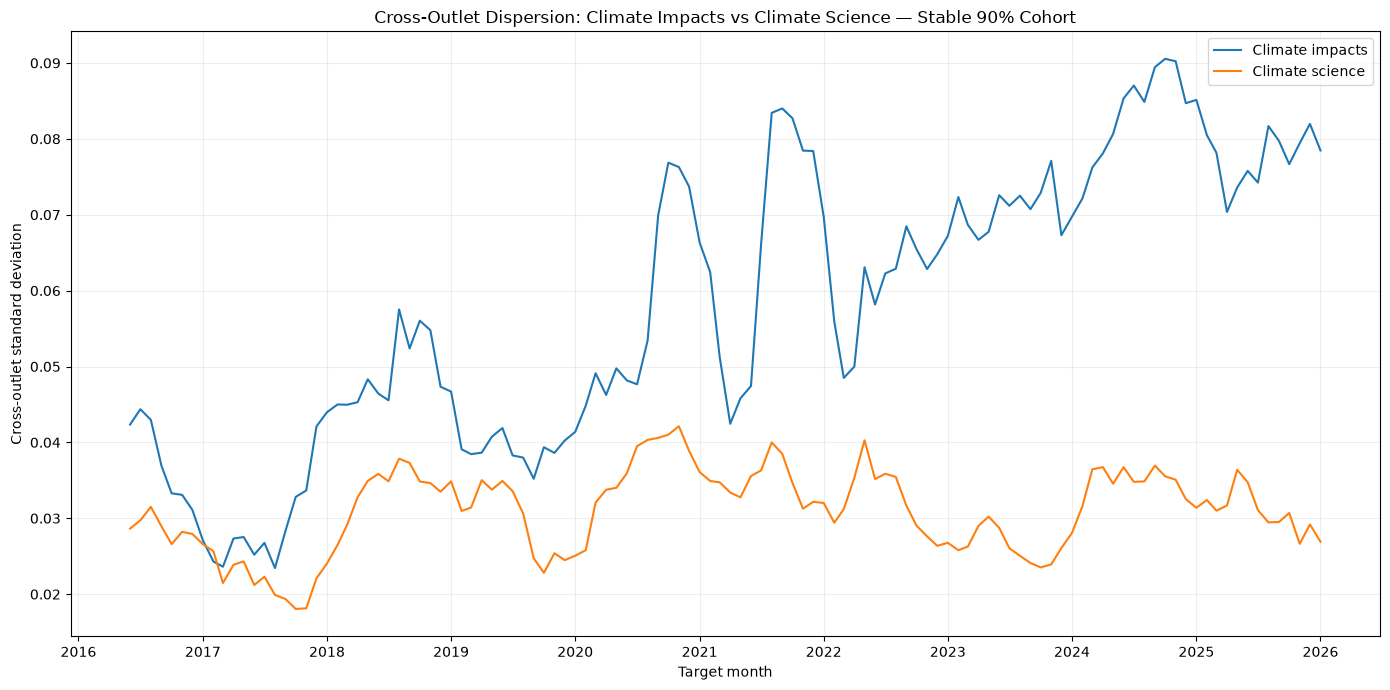

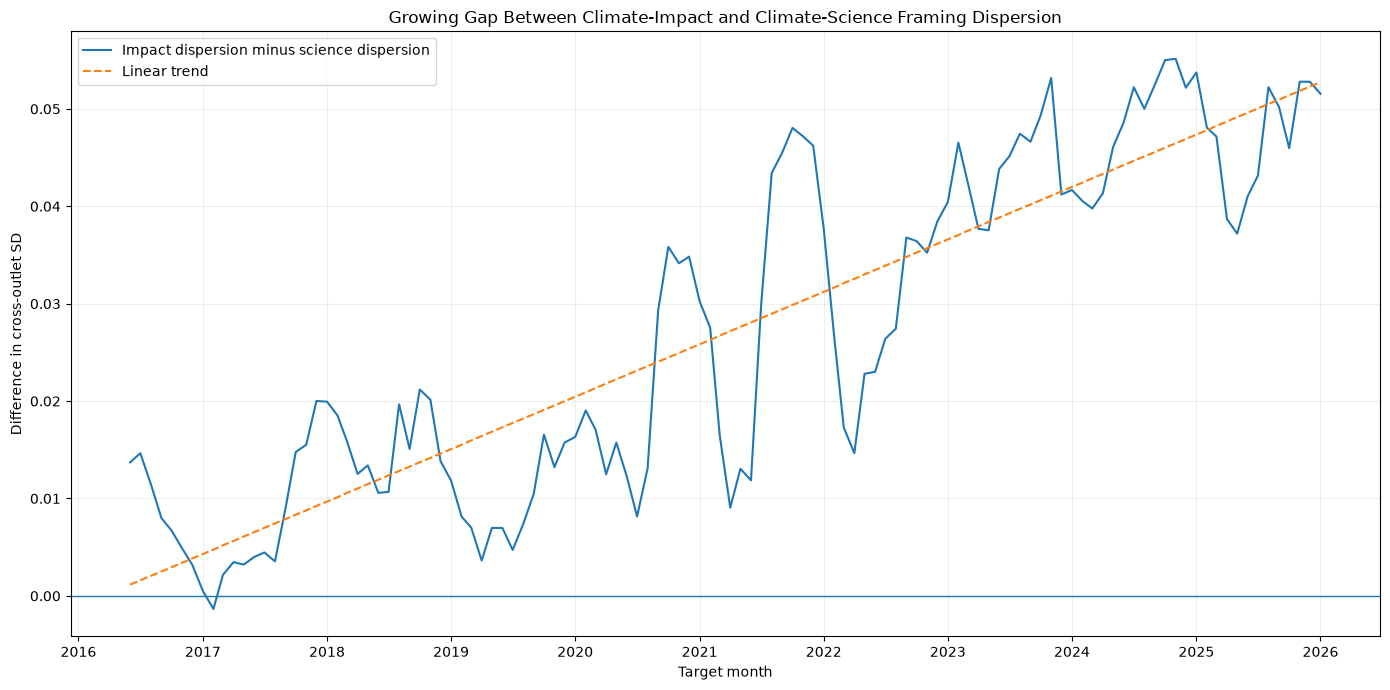

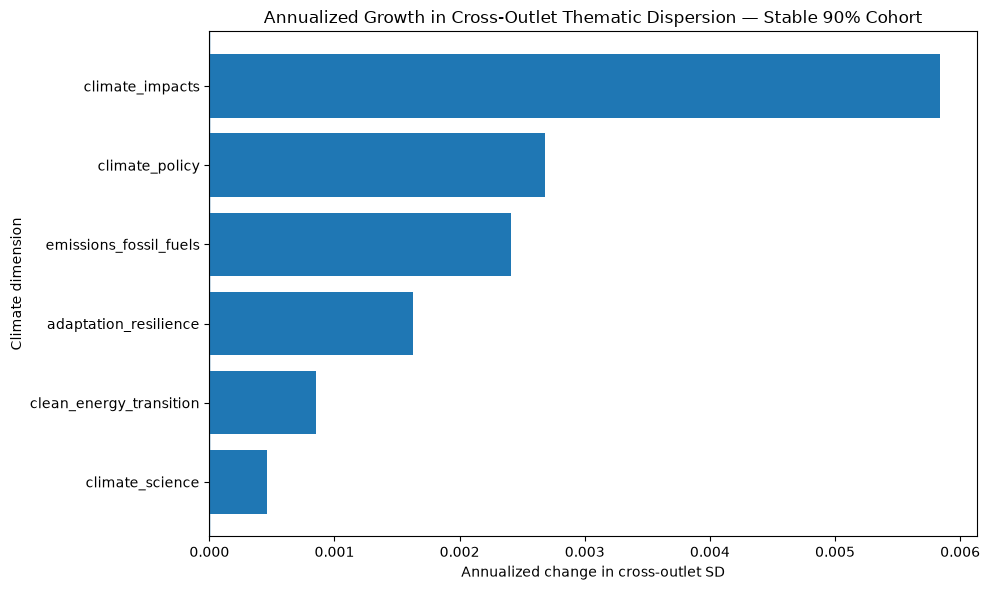


ARTIFACTS
Trend contrasts: /Users/lasya/Documents/projects/media-polarization-lab/data/processed/climate_dimension_trend_contrasts.parquet
Monthly dispersion: /Users/lasya/Documents/projects/media-polarization-lab/data/processed/climate_dimension_monthly_dispersion.parquet


In [59]:
# ============================================================
# CELL 35 — THEMATIC TREND CONTRASTS
#
# Question:
#   Is the increase in climate-impact framing dispersion
#   significantly greater than the increase in other climate
#   dimensions, especially climate science?
#
# Why:
#   Separate significant coefficients are not themselves a
#   statistical test that two trends differ.
#
# Primary contrast:
#   climate impacts - climate science
#
# Secondary contrasts:
#   climate impacts - policy
#   climate impacts - fossil fuels
#   climate impacts - clean energy transition
#   climate impacts - adaptation/resilience
#
# Panel definitions:
#   dynamic_panel
#   stable_90
#   fully_balanced
#
# February 2026 is excluded because it is incomplete.
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm


# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

PROJECT_ROOT = Path(
    "/Users/lasya/Documents/projects/media-polarization-lab"
)

INPUT_PATH = (
    PROJECT_ROOT
    / "data/processed/outlet_month_climate_dimension_profiles.parquet"
)

OUTPUT_CONTRASTS = (
    PROJECT_ROOT
    / "data/processed/climate_dimension_trend_contrasts.parquet"
)

OUTPUT_MONTHLY = (
    PROJECT_ROOT
    / "data/processed/climate_dimension_monthly_dispersion.parquet"
)


# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

DIMENSIONS = {
    "climate_science": "relative_climate_science",
    "emissions_fossil_fuels": "relative_emissions_fossil_fuels",
    "clean_energy_transition": "relative_clean_energy_transition",
    "climate_policy": "relative_climate_policy",
    "climate_impacts": "relative_climate_impacts",
    "adaptation_resilience": "relative_adaptation_resilience",
}

PRIMARY_DIMENSION = "climate_impacts"

REFERENCE_DIMENSION = "climate_science"

STABLE_COVERAGE_THRESHOLD = 0.90

INCOMPLETE_MONTH = pd.Period(
    "2026-02",
    freq="M"
)

HAC_LAGS = 12


# ------------------------------------------------------------
# LOAD
# ------------------------------------------------------------

df = pd.read_parquet(INPUT_PATH).copy()

print("=" * 74)
print("THEMATIC TREND CONTRASTS")
print("=" * 74)
print(f"Input: {INPUT_PATH}")
print(f"Rows: {len(df):,}")


# ------------------------------------------------------------
# IDENTIFY COLUMNS
# ------------------------------------------------------------

possible_outlet_cols = [
    "media_name",
    "outlet",
    "source",
]

possible_month_cols = [
    "target_month",
    "year_month",
    "month",
]

outlet_col = next(
    (
        c for c in possible_outlet_cols
        if c in df.columns
    ),
    None
)

month_col = next(
    (
        c for c in possible_month_cols
        if c in df.columns
    ),
    None
)

if outlet_col is None:
    raise ValueError(
        "Could not detect outlet column."
    )

if month_col is None:
    raise ValueError(
        "Could not detect month column."
    )

missing_dimensions = [
    col
    for col in DIMENSIONS.values()
    if col not in df.columns
]

if missing_dimensions:
    raise ValueError(
        "Missing thematic columns:\n"
        + "\n".join(missing_dimensions)
    )


# ------------------------------------------------------------
# NORMALIZE MONTH
# ------------------------------------------------------------

if isinstance(
    df[month_col].dtype,
    pd.PeriodDtype
):
    df["analysis_month"] = (
        df[month_col]
        .dt.asfreq("M")
    )
else:
    df["analysis_month"] = (
        pd.to_datetime(df[month_col])
        .dt.to_period("M")
    )


# Remove incomplete final month for primary inference
df = df[
    df["analysis_month"] < INCOMPLETE_MONTH
].copy()


study_months = sorted(
    df["analysis_month"].unique()
)

n_months = len(study_months)

print()
print("=" * 74)
print("COMPLETE-MONTH STUDY PANEL")
print("=" * 74)
print(f"Months: {n_months}")
print(f"First:  {min(study_months)}")
print(f"Last:   {max(study_months)}")
print(f"Outlets observed: {df[outlet_col].nunique()}")


# ------------------------------------------------------------
# FREEZE PANEL DEFINITIONS
#
# Recreate cohort membership using the COMPLETE-MONTH panel.
#
# This differs trivially from the prior 117-month definition
# only if an outlet's sole missing month was Feb 2026.
# To remain exactly consistent with previous work, rebuild
# membership using the original 117-month file below.
# ------------------------------------------------------------

df_original = pd.read_parquet(INPUT_PATH).copy()

if isinstance(
    df_original[month_col].dtype,
    pd.PeriodDtype
):
    df_original["analysis_month"] = (
        df_original[month_col]
        .dt.asfreq("M")
    )
else:
    df_original["analysis_month"] = (
        pd.to_datetime(
            df_original[month_col]
        )
        .dt.to_period("M")
    )

original_months = sorted(
    df_original["analysis_month"].unique()
)

original_n_months = len(original_months)

coverage = (
    df_original
    .groupby(outlet_col)["analysis_month"]
    .nunique()
)

all_outlets = set(
    df_original[outlet_col]
    .dropna()
    .unique()
)

stable_90_outlets = set(
    coverage[
        coverage
        >= np.ceil(
            STABLE_COVERAGE_THRESHOLD
            * original_n_months
        )
    ].index
)

fully_balanced_outlets = set(
    coverage[
        coverage == original_n_months
    ].index
)

PANELS = {
    "dynamic_panel": all_outlets,
    "stable_90": stable_90_outlets,
    "fully_balanced": fully_balanced_outlets,
}

print()
print("=" * 74)
print("FROZEN COHORTS")
print("=" * 74)

for name, outlets in PANELS.items():
    print(
        f"{name:<18} "
        f"{len(outlets):>3} outlets"
    )


# ------------------------------------------------------------
# MONTHLY CROSS-OUTLET DISPERSION FOR ALL DIMENSIONS
# ------------------------------------------------------------

monthly_rows = []

for panel_name, outlets in PANELS.items():

    temp = df[
        df[outlet_col].isin(outlets)
    ].copy()

    for month, g in temp.groupby(
        "analysis_month"
    ):

        row = {
            "panel": panel_name,
            "analysis_month": month,
            "outlets": g[
                outlet_col
            ].nunique(),
        }

        for short_name, col in DIMENSIONS.items():

            vals = (
                g[col]
                .dropna()
                .astype(float)
            )

            row[
                f"{short_name}_std"
            ] = vals.std(ddof=1)

            row[
                f"{short_name}_iqr"
            ] = (
                vals.quantile(0.75)
                - vals.quantile(0.25)
            )

        monthly_rows.append(row)


monthly = (
    pd.DataFrame(monthly_rows)
    .sort_values(
        ["panel", "analysis_month"]
    )
    .reset_index(drop=True)
)

print()
print("=" * 74)
print("MONTHLY DISPERSION DATASET")
print("=" * 74)
print(f"Rows: {len(monthly):,}")
print(
    "Months per panel:",
    monthly.groupby("panel")[
        "analysis_month"
    ].nunique().to_dict()
)


# ------------------------------------------------------------
# HAC TREND FUNCTION
# ------------------------------------------------------------

def hac_trend(
    data,
    value_col,
    hac_lags=12,
):

    temp = (
        data[
            ["analysis_month", value_col]
        ]
        .dropna()
        .sort_values("analysis_month")
        .reset_index(drop=True)
    )

    temp["time_years"] = (
        np.arange(len(temp))
        / 12.0
    )

    X = sm.add_constant(
        temp["time_years"]
    )

    y = temp[value_col].astype(float)

    ols = sm.OLS(
        y,
        X
    ).fit()

    maxlags = min(
        hac_lags,
        max(
            1,
            len(temp) - 2
        )
    )

    hac = ols.get_robustcov_results(
        cov_type="HAC",
        maxlags=maxlags,
    )

    ci = np.asarray(
        hac.conf_int()
    )

    return {
        "months": len(temp),

        "annualized_change":
            float(hac.params[1]),

        "hac_se":
            float(hac.bse[1]),

        "ci_lower":
            float(ci[1, 0]),

        "ci_upper":
            float(ci[1, 1]),

        "p_value":
            float(hac.pvalues[1]),

        "r_squared":
            float(ols.rsquared),
    }


# ------------------------------------------------------------
# INDIVIDUAL DIMENSION TRENDS
# ------------------------------------------------------------

dimension_rows = []

for panel_name, panel_df in monthly.groupby(
    "panel"
):

    for dimension in DIMENSIONS:

        result = hac_trend(
            panel_df,
            f"{dimension}_std",
            HAC_LAGS,
        )

        dimension_rows.append(
            {
                "panel": panel_name,
                "dimension": dimension,
                **result,
            }
        )


dimension_trends = pd.DataFrame(
    dimension_rows
)

print()
print("=" * 74)
print("INDIVIDUAL THEMATIC DISPERSION TRENDS")
print("=" * 74)

display(
    dimension_trends[
        [
            "panel",
            "dimension",
            "annualized_change",
            "hac_se",
            "ci_lower",
            "ci_upper",
            "p_value",
            "r_squared",
        ]
    ]
    .sort_values(
        [
            "panel",
            "annualized_change",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .round(6)
)


# ------------------------------------------------------------
# DIRECT CONTRASTS
#
# Example:
#
#   SD(impacts) - SD(science)
#
# If the slope of this difference is > 0, impacts are
# becoming more heterogeneous across outlets faster than
# science framing is.
# ------------------------------------------------------------

contrast_rows = []

for panel_name, panel_df in monthly.groupby(
    "panel"
):

    panel_df = panel_df.copy()

    impact_col = (
        f"{PRIMARY_DIMENSION}_std"
    )

    for comparison in DIMENSIONS:

        if comparison == PRIMARY_DIMENSION:
            continue

        comparison_col = (
            f"{comparison}_std"
        )

        contrast_col = (
            f"impact_minus_{comparison}"
        )

        panel_df[
            contrast_col
        ] = (
            panel_df[impact_col]
            - panel_df[comparison_col]
        )

        result = hac_trend(
            panel_df,
            contrast_col,
            HAC_LAGS,
        )

        contrast_rows.append(
            {
                "panel": panel_name,
                "primary_dimension":
                    PRIMARY_DIMENSION,
                "comparison_dimension":
                    comparison,
                **result,
            }
        )


contrasts = pd.DataFrame(
    contrast_rows
)

print()
print("=" * 74)
print("DIRECT HAC TREND CONTRASTS")
print("=" * 74)

display(
    contrasts[
        [
            "panel",
            "comparison_dimension",
            "annualized_change",
            "hac_se",
            "ci_lower",
            "ci_upper",
            "p_value",
            "r_squared",
        ]
    ]
    .sort_values(
        [
            "panel",
            "annualized_change",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .round(6)
)


# ------------------------------------------------------------
# PRIMARY CONTRAST:
# IMPACTS MINUS CLIMATE SCIENCE
# ------------------------------------------------------------

primary_contrast = (
    contrasts[
        contrasts[
            "comparison_dimension"
        ] == REFERENCE_DIMENSION
    ]
    .copy()
)

print()
print("=" * 74)
print(
    "PRIMARY CONTRAST — "
    "CLIMATE IMPACTS MINUS CLIMATE SCIENCE"
)
print("=" * 74)

display(
    primary_contrast[
        [
            "panel",
            "annualized_change",
            "hac_se",
            "ci_lower",
            "ci_upper",
            "p_value",
            "r_squared",
        ]
    ].round(6)
)


# ------------------------------------------------------------
# EARLY -> LATE CONTRAST CHANGE
# ------------------------------------------------------------

period_rows = []

for panel_name, panel_df in monthly.groupby(
    "panel"
):

    temp = (
        panel_df
        .sort_values("analysis_month")
        .reset_index(drop=True)
        .copy()
    )

    temp[
        "impact_minus_science"
    ] = (
        temp["climate_impacts_std"]
        - temp["climate_science_std"]
    )

    blocks = np.array_split(
        np.arange(len(temp)),
        3,
    )

    for label, idx in zip(
        ["early", "middle", "late"],
        blocks,
    ):

        part = temp.iloc[idx]

        period_rows.append(
            {
                "panel": panel_name,
                "period": label,

                "impact_std":
                    part[
                        "climate_impacts_std"
                    ].mean(),

                "science_std":
                    part[
                        "climate_science_std"
                    ].mean(),

                "impact_minus_science":
                    part[
                        "impact_minus_science"
                    ].mean(),
            }
        )


period_contrast = pd.DataFrame(
    period_rows
)

print()
print("=" * 74)
print("IMPACTS VS SCIENCE — STUDY PERIODS")
print("=" * 74)

display(
    period_contrast.round(5)
)


contrast_pivot = (
    period_contrast
    .pivot(
        index="panel",
        columns="period",
        values="impact_minus_science",
    )
    .reset_index()
)

contrast_pivot[
    "early_to_late_change"
] = (
    contrast_pivot["late"]
    - contrast_pivot["early"]
)

print()
print("=" * 74)
print(
    "EARLY -> LATE CHANGE IN "
    "IMPACT-SCIENCE DISPERSION GAP"
)
print("=" * 74)

display(
    contrast_pivot[
        [
            "panel",
            "early",
            "middle",
            "late",
            "early_to_late_change",
        ]
    ].round(5)
)


# ------------------------------------------------------------
# PLOT 1
# PRIMARY STABLE-90 COMPARISON
# ------------------------------------------------------------

stable = (
    monthly[
        monthly["panel"]
        == "stable_90"
    ]
    .copy()
    .sort_values(
        "analysis_month"
    )
)

dates = stable[
    "analysis_month"
].dt.to_timestamp()

plt.figure(
    figsize=(14, 7)
)

plt.plot(
    dates,
    stable[
        "climate_impacts_std"
    ],
    label="Climate impacts",
)

plt.plot(
    dates,
    stable[
        "climate_science_std"
    ],
    label="Climate science",
)

plt.title(
    "Cross-Outlet Dispersion: "
    "Climate Impacts vs Climate Science "
    "— Stable 90% Cohort"
)

plt.xlabel(
    "Target month"
)

plt.ylabel(
    "Cross-outlet standard deviation"
)

plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# PLOT 2
# IMPACT MINUS SCIENCE DISPERSION GAP
# ------------------------------------------------------------

stable[
    "impact_minus_science"
] = (
    stable[
        "climate_impacts_std"
    ]
    - stable[
        "climate_science_std"
    ]
)

stable[
    "time_years"
] = (
    np.arange(
        len(stable)
    )
    / 12.0
)

fit = sm.OLS(
    stable[
        "impact_minus_science"
    ],
    sm.add_constant(
        stable[
            "time_years"
        ]
    ),
).fit()

stable[
    "contrast_fit"
] = fit.predict(
    sm.add_constant(
        stable[
            "time_years"
        ]
    )
)

plt.figure(
    figsize=(14, 7)
)

plt.plot(
    dates,
    stable[
        "impact_minus_science"
    ],
    label=(
        "Impact dispersion "
        "minus science dispersion"
    ),
)

plt.plot(
    dates,
    stable[
        "contrast_fit"
    ],
    linestyle="--",
    label="Linear trend",
)

plt.axhline(
    0,
    linewidth=1,
)

plt.title(
    "Growing Gap Between Climate-Impact "
    "and Climate-Science Framing Dispersion"
)

plt.xlabel(
    "Target month"
)

plt.ylabel(
    "Difference in cross-outlet SD"
)

plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# PLOT 3
# ALL DIMENSION TRENDS — STABLE 90
# ------------------------------------------------------------

stable_trends = (
    dimension_trends[
        dimension_trends[
            "panel"
        ] == "stable_90"
    ]
    .sort_values(
        "annualized_change"
    )
)

plt.figure(
    figsize=(10, 6)
)

plt.barh(
    stable_trends[
        "dimension"
    ],
    stable_trends[
        "annualized_change"
    ],
)

plt.axvline(
    0,
    linewidth=1,
)

plt.title(
    "Annualized Growth in "
    "Cross-Outlet Thematic Dispersion "
    "— Stable 90% Cohort"
)

plt.xlabel(
    "Annualized change in cross-outlet SD"
)

plt.ylabel(
    "Climate dimension"
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------

contrasts.to_parquet(
    OUTPUT_CONTRASTS,
    index=False,
)

monthly.to_parquet(
    OUTPUT_MONTHLY,
    index=False,
)

print()
print("=" * 74)
print("ARTIFACTS")
print("=" * 74)

print(
    "Trend contrasts:",
    OUTPUT_CONTRASTS,
)

print(
    "Monthly dispersion:",
    OUTPUT_MONTHLY,
)


CLIMATE-IMPACT STRUCTURAL-BREAK ROBUSTNESS
Input: /Users/lasya/Documents/projects/media-polarization-lab/data/processed/outlet_month_climate_dimension_profiles.parquet
Rows loaded: 7,378

COMPLETE-MONTH STUDY PANEL
Months: 116
First: 2016-06
Last: 2026-01
Outlets observed: 136

FROZEN OUTLET COHORTS
Dynamic panel:      136 outlets
Stable >=90% panel: 20 outlets
Fully balanced:     6 outlets

Fully balanced outlets:
  abcnews.go.com
  cbsnews.com
  grist.org
  latimes.com
  theconversation.com
  theguardian.com

MONTHLY DISPERSION SERIES


,panel,months,median_outlets,min_outlets,max_outlets,mean_dispersion
0,dynamic_panel,116,62.0,38,95,0.05913
1,stable_90,116,20.0,16,20,0.05792
2,fully_balanced,116,6.0,6,6,0.04494



SEARCHING FOR STRUCTURAL BREAKS

SELECTED STRUCTURAL BREAKS


/var/folders/w0/3gcyvg0s5dnd4ykcbv1pb2100000gn/T/ipykernel_27110/375548890.py:1741: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  break_results.round(


,panel,months,first_month,last_month,break_idx,break_month,linear_bic,segmented_bic,delta_bic,linear_r_squared,...,pre_break_slope,pre_ci_lower,pre_ci_upper,slope_change,slope_change_ci_lower,slope_change_ci_upper,slope_change_p_value,post_break_slope,post_ci_lower,post_ci_upper
0,dynamic_panel,116,2016-06,2026-01,73,2022-07,-1082.457073,-1097.681731,15.224657,0.697409,...,0.006667,0.005060,0.008274,-0.005756,-0.009422,-0.002090,0.002090,0.000911,-0.001543,0.003365
1,stable_90,116,2016-06,2026-01,97,2024-07,-1080.587256,-1080.685512,0.098256,0.762164,...,0.006301,0.005168,0.007434,-0.006730,-0.011975,-0.001486,0.011893,-0.000429,-0.004812,0.003953
2,fully_balanced,116,2016-06,2026-01,18,2017-12,-1019.928770,-1019.109922,-0.818848,0.576013,...,-0.002409,-0.012298,0.007479,0.007888,-0.002676,0.018451,0.143348,0.005478,0.004226,0.006731


...

,panel,break_month,pre_break_slope,pre_ci_lower,pre_ci_upper,slope_change,slope_change_ci_lower,slope_change_ci_upper,slope_change_p_value,post_break_slope,post_ci_lower,post_ci_upper,bootstrap_p_value
0,dynamic_panel,2022-07,0.006667,0.005060,0.008274,-0.005756,-0.009422,-0.002090,0.002090,0.000911,-0.001543,0.003365,0.171828
1,stable_90,2024-07,0.006301,0.005168,0.007434,-0.006730,-0.011975,-0.001486,0.011893,-0.000429,-0.004812,0.003953,0.618382
2,fully_balanced,2017-12,-0.002409,-0.012298,0.007479,0.007888,-0.002676,0.018451,0.143348,0.005478,0.004226,0.006731,0.768232



LINEAR VS SEGMENTED MODEL FIT


/var/folders/w0/3gcyvg0s5dnd4ykcbv1pb2100000gn/T/ipykernel_27110/375548890.py:2082: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  fit_comparison.round(


,panel,break_month,linear_bic,segmented_bic,delta_bic,linear_r_squared,segmented_r_squared,bootstrap_p_value
0,dynamic_panel,2022-07,-1082.457073,-1097.681731,15.224657,0.697409,0.745283,0.171828
1,stable_90,2024-07,-1080.587256,-1080.685512,0.098256,0.762164,0.771906,0.618382
2,fully_balanced,2017-12,-1019.928770,-1019.109922,-0.818848,0.576013,0.590154,0.768232



PRIMARY SPECIFICATION
Panel:              stable_90
Selected break:     2024-07
Break index:        97
BIC improvement:    0.098
Bootstrap Sup-F p:  0.618382
Pre-break slope:    0.006301/year
Slope change:       -0.006730/year
Post-break slope:   -0.000429/year
Slope-change p:     0.011893


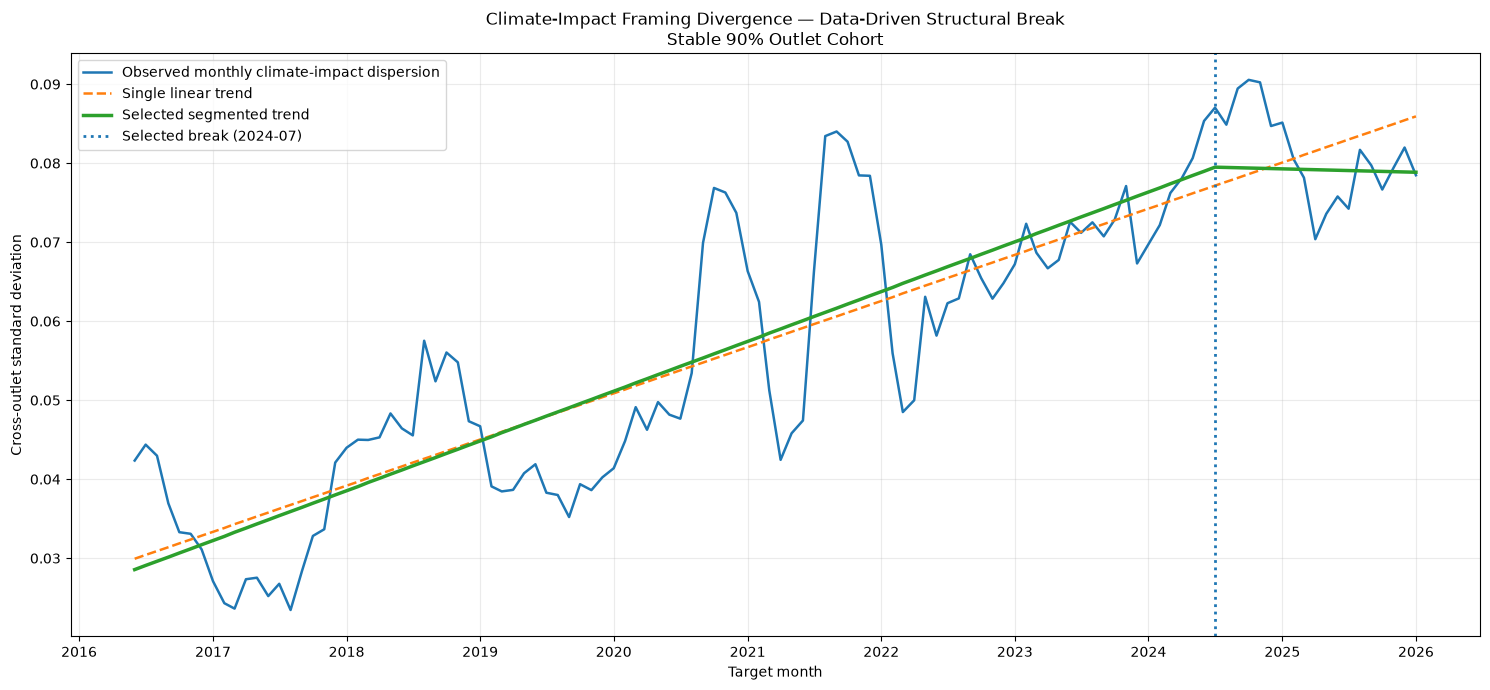

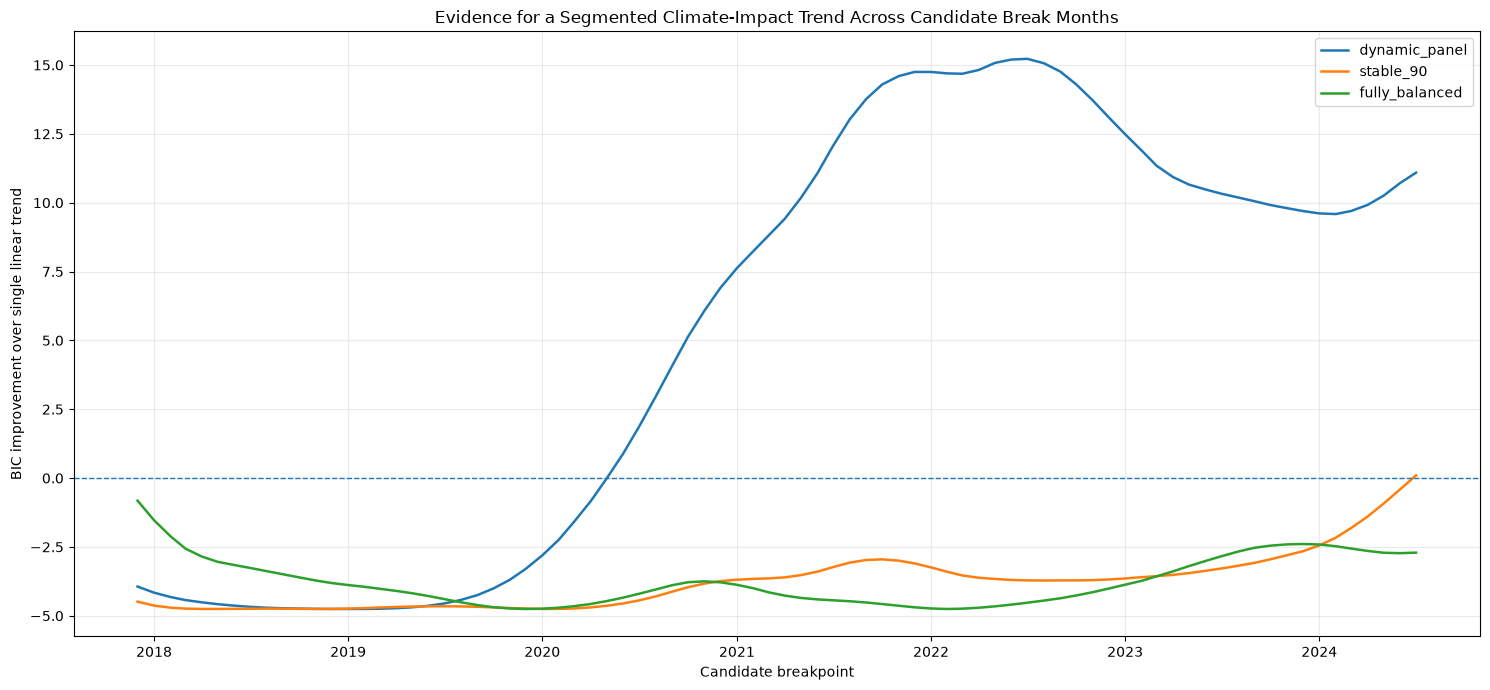

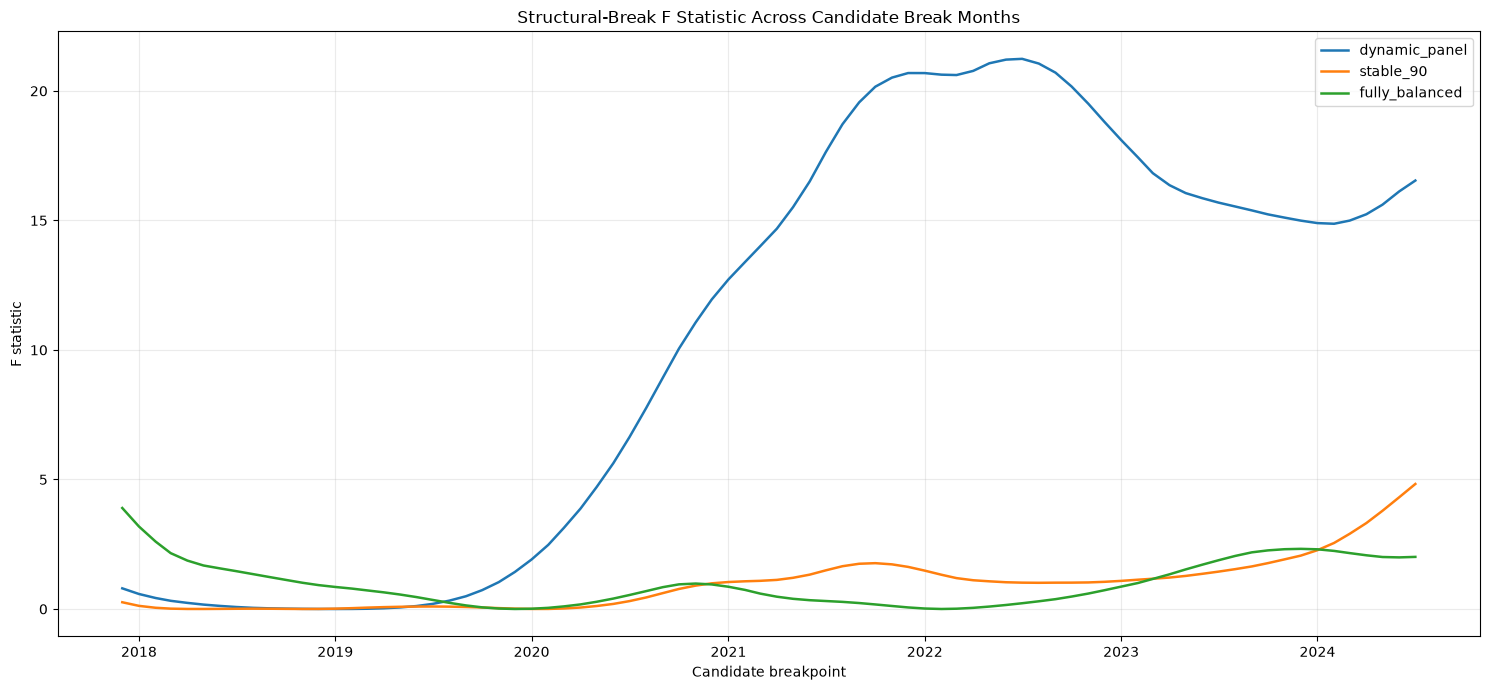

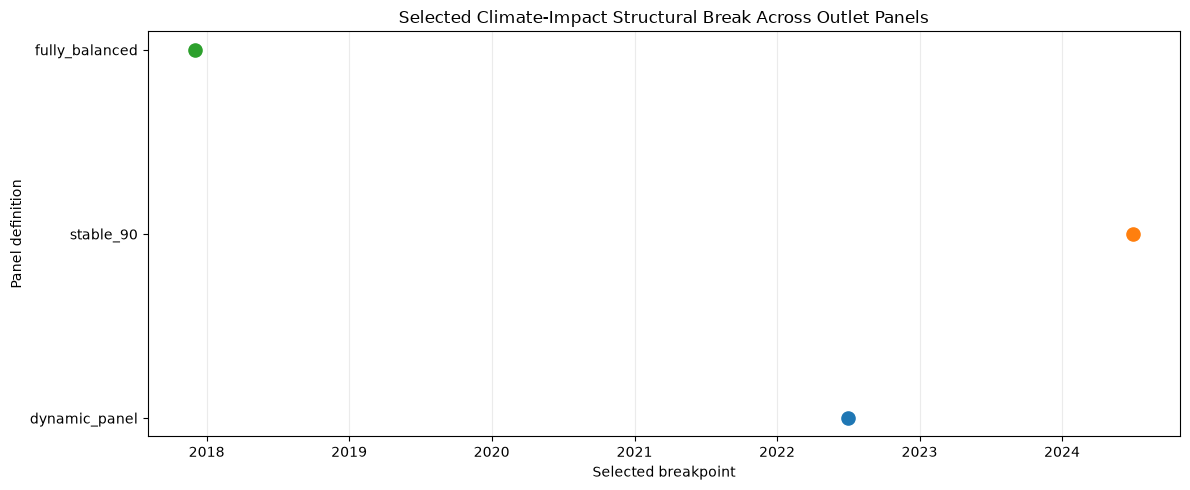


PRIMARY BREAK — DESCRIPTIVE PERIOD SUMMARY


/var/folders/w0/3gcyvg0s5dnd4ykcbv1pb2100000gn/T/ipykernel_27110/375548890.py:2710: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  segment_summary.round(


,segment,months,first_month,last_month,mean_outlets,mean_dispersion,median_dispersion,min_dispersion,max_dispersion
0,post_break,18,2024-08,2026-01,18.277778,0.080860,0.080101,0.070373,0.090543
1,pre_break,98,2016-06,2024-07,19.489796,0.053711,0.049435,0.023444,0.087023



BREAKPOINT ROBUSTNESS ACROSS PANELS


/var/folders/w0/3gcyvg0s5dnd4ykcbv1pb2100000gn/T/ipykernel_27110/375548890.py:2782: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  robustness_table.round(


,panel,break_month,delta_bic,observed_sup_f,bootstrap_p_value,pre_break_slope,post_break_slope,slope_change,slope_change_ci_lower,slope_change_ci_upper,slope_change_p_value,segmented_preferred_bic,strong_bic_evidence,bootstrap_break_significant_05,slope_change_significant_05
0,dynamic_panel,2022-07,15.224657,21.237966,0.171828,0.006667,0.000911,-0.005756,-0.009422,-0.002090,0.002090,True,True,False,True
1,stable_90,2024-07,0.098256,4.826603,0.618382,0.006301,-0.000429,-0.006730,-0.011975,-0.001486,0.011893,True,False,False,True
2,fully_balanced,2017-12,-0.818848,3.898730,0.768232,-0.002409,0.005478,0.007888,-0.002676,0.018451,0.143348,False,False,False,False



INTERNAL VALIDATION
break_results columns:
['panel', 'months', 'first_month', 'last_month', 'break_idx', 'break_month', 'linear_bic', 'segmented_bic', 'delta_bic', 'linear_r_squared', 'segmented_r_squared', 'intercept', 'observed_sup_f', 'classical_f_p_value', 'pre_break_slope', 'pre_ci_lower', 'pre_ci_upper', 'slope_change', 'slope_change_ci_lower', 'slope_change_ci_upper', 'slope_change_p_value', 'post_break_slope', 'post_ci_lower', 'post_ci_upper', 'bootstrap_p_value', 'bootstrap_q90', 'bootstrap_q95', 'bootstrap_q99']

✓ break_idx retained
✓ three panel specifications present
✓ no missing selected breakpoint indices
✓ plotting section can recover selected break

ARTIFACTS
Selected structural breaks:
/Users/lasya/Documents/projects/media-polarization-lab/data/processed/climate_impact_structural_breaks.parquet

Candidate breakpoint search:
/Users/lasya/Documents/projects/media-polarization-lab/data/processed/climate_impact_structural_break_candidates.parquet

Bootstrap distributions

In [66]:
# ============================================================
# CELL 36
# CLIMATE-IMPACT STRUCTURAL-BREAK / SEGMENTED-TREND ROBUSTNESS
# ============================================================
#
# Purpose
# -------
# Test whether the long-run increase in cross-outlet dispersion
# in climate-impact framing is:
#
#   1. approximately gradual / linear, or
#   2. better characterized by a data-driven change in slope.
#
# Robustness panels:
#   - dynamic_panel
#   - stable_90
#   - fully_balanced
#
# Main outcome:
#   Cross-outlet SD of relative_climate_impacts
#
# Inference:
#   - HAC / Newey-West inference for selected segmented model
#   - Sup-F style breakpoint search
#   - moving-block residual bootstrap under linear null
#
# IMPORTANT:
#   This version retains break_idx in ALL output tables and
#   does not depend on variables created by earlier cells.
# ============================================================


# ------------------------------------------------------------
# 0. IMPORTS
# ------------------------------------------------------------

from pathlib import Path
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
from scipy import stats


# ------------------------------------------------------------
# 1. CONFIGURATION
# ------------------------------------------------------------

PROJECT_ROOT = Path(
    "/Users/lasya/Documents/projects/media-polarization-lab"
)

DATA_DIR = PROJECT_ROOT / "data" / "processed"

INPUT_PATH = (
    DATA_DIR
    / "outlet_month_climate_dimension_profiles.parquet"
)

OUTLET_COL = "media_name"
MONTH_COL = "target_month"

DIMENSION_COL = "relative_climate_impacts"

# February 2026 was only a partial month in the source corpus.
# Keep only complete months for temporal inference.
MAX_COMPLETE_MONTH = pd.Period(
    "2026-01",
    freq="M",
)

# Frozen-panel definitions
STABLE_COVERAGE_THRESHOLD = 0.90

# Breakpoint search:
# require this many months on BOTH sides of a candidate break.
MIN_SEGMENT_MONTHS = 18

# HAC / Newey-West
HAC_LAGS = 12

# Moving-block bootstrap for Sup-F inference
BOOTSTRAP_REPS = 1000
BOOTSTRAP_BLOCK_LENGTH = 12
RANDOM_SEED = 42

# Primary specification for interpretation
PRIMARY_PANEL = "stable_90"


# Output artifacts
BREAK_RESULTS_PATH = (
    DATA_DIR
    / "climate_impact_structural_breaks.parquet"
)

BREAK_CANDIDATES_PATH = (
    DATA_DIR
    / "climate_impact_structural_break_candidates.parquet"
)

BREAK_BOOTSTRAP_PATH = (
    DATA_DIR
    / "climate_impact_structural_break_bootstrap.parquet"
)

BREAK_MONTHLY_PATH = (
    DATA_DIR
    / "climate_impact_structural_break_monthly_series.parquet"
)


# ------------------------------------------------------------
# 2. HELPER FUNCTIONS
# ------------------------------------------------------------

def section(title):
    print()
    print("=" * 72)
    print(title)
    print("=" * 72)


def period_to_timestamp(period_value):
    """
    Convert monthly Period to start-of-month Timestamp.
    """
    if isinstance(period_value, pd.Period):
        return period_value.to_timestamp()

    return pd.Period(
        str(period_value),
        freq="M",
    ).to_timestamp()


def safe_bic(rss, n, k):
    """
    Gaussian BIC based on residual sum of squares.
    """
    rss = max(
        float(rss),
        np.finfo(float).eps,
    )

    return (
        n * np.log(rss / n)
        + k * np.log(n)
    )


def linear_design(t):
    """
    Linear trend:
        y = a + b*t
    """
    t = np.asarray(
        t,
        dtype=float,
    )

    return np.column_stack(
        [
            np.ones(len(t)),
            t,
        ]
    )


def segmented_design(t, break_idx):
    """
    Continuous segmented linear trend:

        y = a
            + b1*t
            + delta * max(0, t-break_idx)

    Pre-break slope:
        b1

    Post-break slope:
        b1 + delta
    """
    t = np.asarray(
        t,
        dtype=float,
    )

    hinge = np.maximum(
        0.0,
        t - float(break_idx),
    )

    return np.column_stack(
        [
            np.ones(len(t)),
            t,
            hinge,
        ]
    )


def fit_numpy_ols(y, X):
    """
    Very lightweight OLS used repeatedly during
    breakpoint search/bootstrap.
    """
    y = np.asarray(
        y,
        dtype=float,
    )

    X = np.asarray(
        X,
        dtype=float,
    )

    beta, _, _, _ = np.linalg.lstsq(
        X,
        y,
        rcond=None,
    )

    fitted = X @ beta
    residual = y - fitted

    rss = float(
        residual @ residual
    )

    return {
        "beta": beta,
        "fitted": fitted,
        "residual": residual,
        "rss": rss,
    }


def candidate_break_table(
    months,
    y,
    min_segment_months=18,
):
    """
    Evaluate every admissible single continuous slope break.

    Returns one row for each candidate breakpoint.
    """

    months = pd.PeriodIndex(
        months,
        freq="M",
    )

    y = np.asarray(
        y,
        dtype=float,
    )

    n = len(y)

    if n < (
        2 * min_segment_months
        + 3
    ):
        raise ValueError(
            "Not enough observations for "
            "the requested breakpoint search."
        )

    t = np.arange(
        n,
        dtype=float,
    )

    # Linear null
    X0 = linear_design(t)

    linear_fit = fit_numpy_ols(
        y,
        X0,
    )

    rss0 = linear_fit["rss"]

    bic0 = safe_bic(
        rss=rss0,
        n=n,
        k=2,
    )

    rows = []

    start_k = min_segment_months
    stop_k = n - min_segment_months

    for k in range(
        start_k,
        stop_k,
    ):

        X1 = segmented_design(
            t,
            k,
        )

        seg_fit = fit_numpy_ols(
            y,
            X1,
        )

        rss1 = seg_fit["rss"]

        bic1 = safe_bic(
            rss=rss1,
            n=n,
            k=3,
        )

        # One additional parameter:
        # the slope-change / hinge coefficient.
        df_num = 1
        df_den = n - 3

        rss_improvement = max(
            0.0,
            rss0 - rss1,
        )

        if rss1 > 0:
            f_stat = (
                (rss_improvement / df_num)
                /
                (rss1 / df_den)
            )
        else:
            f_stat = np.inf

        classical_p = float(
            stats.f.sf(
                f_stat,
                df_num,
                df_den,
            )
        )

        beta = seg_fit["beta"]

        pre_slope = float(
            beta[1]
        )

        slope_change = float(
            beta[2]
        )

        post_slope = (
            pre_slope
            + slope_change
        )

        rows.append(
            {
                # IMPORTANT:
                # KEEP THE NUMERICAL BREAK POSITION.
                "break_idx": int(k),

                "break_month": months[k],

                "linear_rss": rss0,
                "segmented_rss": rss1,

                "linear_bic": bic0,
                "segmented_bic": bic1,

                # positive = segmented model favored
                "delta_bic": (
                    bic0
                    - bic1
                ),

                "f_stat": float(
                    f_stat
                ),

                "classical_f_p_value": (
                    classical_p
                ),

                "pre_slope_monthly_raw": (
                    pre_slope
                ),

                "slope_change_monthly_raw": (
                    slope_change
                ),

                "post_slope_monthly_raw": (
                    post_slope
                ),
            }
        )

    return pd.DataFrame(
        rows
    )


def selected_break_hac(
    months,
    y,
    break_idx,
    hac_lags=12,
):
    """
    HAC/Newey-West inference for the selected
    continuous segmented trend.
    """

    months = pd.PeriodIndex(
        months,
        freq="M",
    )

    y = np.asarray(
        y,
        dtype=float,
    )

    n = len(y)

    t = np.arange(
        n,
        dtype=float,
    )

    X = segmented_design(
        t,
        break_idx,
    )

    maxlags = min(
        int(hac_lags),
        max(
            1,
            n // 4,
        ),
    )

    model = sm.OLS(
        y,
        X,
    ).fit(
        cov_type="HAC",
        cov_kwds={
            "maxlags": maxlags,
        },
    )

    beta = np.asarray(
        model.params,
        dtype=float,
    )

    cov = np.asarray(
        model.cov_params(),
        dtype=float,
    )

    intercept = float(
        beta[0]
    )

    pre_slope_month = float(
        beta[1]
    )

    slope_change_month = float(
        beta[2]
    )

    post_slope_month = (
        pre_slope_month
        + slope_change_month
    )

    # --------------------------------------------------------
    # Standard errors
    # --------------------------------------------------------

    pre_var = float(
        cov[1, 1]
    )

    change_var = float(
        cov[2, 2]
    )

    post_var = float(
        cov[1, 1]
        + cov[2, 2]
        + 2 * cov[1, 2]
    )

    pre_se = math.sqrt(
        max(
            pre_var,
            0,
        )
    )

    change_se = math.sqrt(
        max(
            change_var,
            0,
        )
    )

    post_se = math.sqrt(
        max(
            post_var,
            0,
        )
    )

    # Normal approximation is standard here because
    # statsmodels HAC uses asymptotic covariance.
    z = stats.norm.ppf(
        0.975
    )

    pre_ci = (
        pre_slope_month
        - z * pre_se,
        pre_slope_month
        + z * pre_se,
    )

    change_ci = (
        slope_change_month
        - z * change_se,
        slope_change_month
        + z * change_se,
    )

    post_ci = (
        post_slope_month
        - z * post_se,
        post_slope_month
        + z * post_se,
    )

    if change_se > 0:
        z_change = (
            slope_change_month
            / change_se
        )

        change_p = float(
            2
            * stats.norm.sf(
                abs(
                    z_change
                )
            )
        )
    else:
        change_p = np.nan

    fitted = (
        X
        @ beta
    )

    return {
        "intercept": intercept,

        "pre_slope_monthly": (
            pre_slope_month
        ),

        "pre_slope_annualized": (
            pre_slope_month
            * 12
        ),

        "pre_ci_lower": (
            pre_ci[0]
            * 12
        ),

        "pre_ci_upper": (
            pre_ci[1]
            * 12
        ),

        "slope_change_monthly": (
            slope_change_month
        ),

        "slope_change_annualized": (
            slope_change_month
            * 12
        ),

        "slope_change_ci_lower": (
            change_ci[0]
            * 12
        ),

        "slope_change_ci_upper": (
            change_ci[1]
            * 12
        ),

        "slope_change_p_value": (
            change_p
        ),

        "post_slope_monthly": (
            post_slope_month
        ),

        "post_slope_annualized": (
            post_slope_month
            * 12
        ),

        "post_ci_lower": (
            post_ci[0]
            * 12
        ),

        "post_ci_upper": (
            post_ci[1]
            * 12
        ),

        "segmented_r_squared": float(
            model.rsquared
        ),

        "fitted": fitted,

        "model": model,
    }


def max_break_f_stat(
    y,
    candidate_indices,
):
    """
    Sup-F style statistic:
    maximum F statistic over all admissible breaks.
    """

    y = np.asarray(
        y,
        dtype=float,
    )

    n = len(y)

    t = np.arange(
        n,
        dtype=float,
    )

    linear_fit = fit_numpy_ols(
        y,
        linear_design(t),
    )

    rss0 = linear_fit["rss"]

    df_den = n - 3

    max_f = -np.inf
    best_idx = None

    for k in candidate_indices:

        seg_fit = fit_numpy_ols(
            y,
            segmented_design(
                t,
                int(k),
            ),
        )

        rss1 = seg_fit["rss"]

        improvement = max(
            0.0,
            rss0 - rss1,
        )

        if rss1 > 0:
            f_stat = (
                improvement
                /
                (rss1 / df_den)
            )
        else:
            f_stat = np.inf

        if f_stat > max_f:
            max_f = float(
                f_stat
            )

            best_idx = int(
                k
            )

    return (
        max_f,
        best_idx,
    )


def circular_block_resample(
    residuals,
    block_length,
    rng,
):
    """
    Circular moving-block bootstrap.
    """

    residuals = np.asarray(
        residuals,
        dtype=float,
    )

    n = len(
        residuals
    )

    block_length = min(
        int(block_length),
        n,
    )

    n_blocks = math.ceil(
        n
        / block_length
    )

    pieces = []

    for _ in range(
        n_blocks
    ):

        start = int(
            rng.integers(
                0,
                n,
            )
        )

        idx = (
            start
            + np.arange(
                block_length
            )
        ) % n

        pieces.append(
            residuals[idx]
        )

    sampled = np.concatenate(
        pieces
    )[:n]

    return sampled


def sup_f_block_bootstrap(
    y,
    candidate_indices,
    reps=1000,
    block_length=12,
    seed=42,
):
    """
    Bootstrap test of:
        H0 = one linear trend
        H1 = unknown single slope break

    Residuals are sampled in circular blocks to preserve
    short-run temporal dependence.
    """

    y = np.asarray(
        y,
        dtype=float,
    )

    n = len(y)

    t = np.arange(
        n,
        dtype=float,
    )

    X0 = linear_design(
        t
    )

    null_fit = fit_numpy_ols(
        y,
        X0,
    )

    fitted_null = (
        null_fit["fitted"]
    )

    residuals = (
        null_fit["residual"]
    )

    # Center residuals
    residuals = (
        residuals
        - residuals.mean()
    )

    observed_sup_f, observed_idx = (
        max_break_f_stat(
            y,
            candidate_indices,
        )
    )

    rng = np.random.default_rng(
        seed
    )

    boot_stats = np.empty(
        reps,
        dtype=float,
    )

    for b in range(
        reps
    ):

        boot_resid = (
            circular_block_resample(
                residuals=residuals,
                block_length=block_length,
                rng=rng,
            )
        )

        y_star = (
            fitted_null
            + boot_resid
        )

        boot_sup_f, _ = (
            max_break_f_stat(
                y_star,
                candidate_indices,
            )
        )

        boot_stats[b] = (
            boot_sup_f
        )

    bootstrap_p = (
        1
        + np.sum(
            boot_stats
            >= observed_sup_f
        )
    ) / (
        reps
        + 1
    )

    return {
        "observed_sup_f": float(
            observed_sup_f
        ),

        "observed_break_idx": int(
            observed_idx
        ),

        "bootstrap_p_value": float(
            bootstrap_p
        ),

        "bootstrap_q90": float(
            np.quantile(
                boot_stats,
                0.90,
            )
        ),

        "bootstrap_q95": float(
            np.quantile(
                boot_stats,
                0.95,
            )
        ),

        "bootstrap_q99": float(
            np.quantile(
                boot_stats,
                0.99,
            )
        ),

        "bootstrap_stats": (
            boot_stats
        ),
    }


def monthly_dispersion(
    frame,
    outlet_col,
    month_col,
    value_col,
    all_months,
):
    """
    Cross-outlet monthly SD for a specified outlet panel.
    """

    temp = (
        frame[
            [
                outlet_col,
                month_col,
                value_col,
            ]
        ]
        .dropna()
        .copy()
    )

    # One observation per outlet-month.
    # Mean protects against accidental duplicate rows.
    temp = (
        temp
        .groupby(
            [
                month_col,
                outlet_col,
            ],
            as_index=False,
        )[value_col]
        .mean()
    )

    monthly = (
        temp
        .groupby(
            month_col
        )
        .agg(
            outlets=(
                outlet_col,
                "nunique",
            ),

            dispersion=(
                value_col,
                "std",
            ),

            mean_emphasis=(
                value_col,
                "mean",
            ),

            median_emphasis=(
                value_col,
                "median",
            ),
        )
        .reset_index()
    )

    month_frame = pd.DataFrame(
        {
            month_col: (
                pd.PeriodIndex(
                    all_months,
                    freq="M",
                )
            )
        }
    )

    monthly = month_frame.merge(
        monthly,
        on=month_col,
        how="left",
    )

    return monthly


# ------------------------------------------------------------
# 3. LOAD DATA
# ------------------------------------------------------------

section(
    "CLIMATE-IMPACT STRUCTURAL-BREAK ROBUSTNESS"
)

print(
    "Input:",
    INPUT_PATH,
)

profiles = pd.read_parquet(
    INPUT_PATH
)

print(
    f"Rows loaded: {len(profiles):,}"
)

required_cols = {
    OUTLET_COL,
    MONTH_COL,
    DIMENSION_COL,
}

missing_cols = (
    required_cols
    - set(
        profiles.columns
    )
)

if missing_cols:
    raise KeyError(
        "Missing required columns: "
        + ", ".join(
            sorted(
                missing_cols
            )
        )
    )


# ------------------------------------------------------------
# 4. STANDARDIZE MONTH
# ------------------------------------------------------------

profiles = (
    profiles
    .copy()
)

profiles[MONTH_COL] = (
    pd.to_datetime(
        profiles[MONTH_COL].astype(
            str
        ),
        errors="coerce",
    )
    .dt
    .to_period(
        "M"
    )
)

profiles[DIMENSION_COL] = (
    pd.to_numeric(
        profiles[DIMENSION_COL],
        errors="coerce",
    )
)

profiles = (
    profiles
    .dropna(
        subset=[
            OUTLET_COL,
            MONTH_COL,
            DIMENSION_COL,
        ]
    )
    .copy()
)


# ------------------------------------------------------------
# 5. COMPLETE-MONTH STUDY PANEL
# ------------------------------------------------------------

study = (
    profiles[
        profiles[MONTH_COL]
        <= MAX_COMPLETE_MONTH
    ]
    .copy()
)

all_months = (
    pd.period_range(
        start=study[
            MONTH_COL
        ].min(),

        end=study[
            MONTH_COL
        ].max(),

        freq="M",
    )
)

n_months = len(
    all_months
)

section(
    "COMPLETE-MONTH STUDY PANEL"
)

print(
    f"Months: {n_months}"
)

print(
    "First:",
    all_months.min(),
)

print(
    "Last:",
    all_months.max(),
)

print(
    "Outlets observed:",
    study[
        OUTLET_COL
    ].nunique(),
)


# ------------------------------------------------------------
# 6. FROZEN COHORT DEFINITIONS
# ------------------------------------------------------------

outlet_presence = (
    study
    .groupby(
        OUTLET_COL
    )[MONTH_COL]
    .nunique()
    .rename(
        "months_present"
    )
    .reset_index()
)

outlet_presence[
    "coverage_pct"
] = (
    100
    * outlet_presence[
        "months_present"
    ]
    / n_months
)

dynamic_outlets = sorted(
    study[
        OUTLET_COL
    ]
    .dropna()
    .unique()
)

stable_90_outlets = sorted(
    outlet_presence.loc[
        outlet_presence[
            "coverage_pct"
        ]
        >= (
            100
            * STABLE_COVERAGE_THRESHOLD
        ),
        OUTLET_COL,
    ]
    .tolist()
)

fully_balanced_outlets = sorted(
    outlet_presence.loc[
        outlet_presence[
            "months_present"
        ]
        == n_months,
        OUTLET_COL,
    ]
    .tolist()
)

section(
    "FROZEN OUTLET COHORTS"
)

print(
    "Dynamic panel:      "
    f"{len(dynamic_outlets)} outlets"
)

print(
    "Stable >=90% panel: "
    f"{len(stable_90_outlets)} outlets"
)

print(
    "Fully balanced:     "
    f"{len(fully_balanced_outlets)} outlets"
)

print()

print(
    "Fully balanced outlets:"
)

for outlet in (
    fully_balanced_outlets
):
    print(
        f"  {outlet}"
    )


# ------------------------------------------------------------
# 7. BUILD MONTHLY SERIES
# ------------------------------------------------------------

panel_definitions = {
    "dynamic_panel": (
        dynamic_outlets
    ),

    "stable_90": (
        stable_90_outlets
    ),

    "fully_balanced": (
        fully_balanced_outlets
    ),
}

panel_objects = {}

monthly_rows = []

for panel_name, outlets in (
    panel_definitions.items()
):

    panel_data = (
        study[
            study[
                OUTLET_COL
            ].isin(
                outlets
            )
        ]
        .copy()
    )

    monthly = (
        monthly_dispersion(
            frame=panel_data,
            outlet_col=OUTLET_COL,
            month_col=MONTH_COL,
            value_col=DIMENSION_COL,
            all_months=all_months,
        )
    )

    # Structural-break analysis requires one
    # complete dispersion observation per month.
    missing_dispersion = int(
        monthly[
            "dispersion"
        ].isna().sum()
    )

    if missing_dispersion > 0:
        raise RuntimeError(
            f"{panel_name}: "
            f"{missing_dispersion} months have "
            "missing dispersion values."
        )

    monthly[
        "panel"
    ] = panel_name

    monthly_rows.append(
        monthly
    )

    panel_objects[
        panel_name
    ] = {
        "outlets": outlets,
        "data": panel_data,
        "series": monthly,
    }


monthly_all = pd.concat(
    monthly_rows,
    ignore_index=True,
)

monthly_all.to_parquet(
    BREAK_MONTHLY_PATH,
    index=False,
)

section(
    "MONTHLY DISPERSION SERIES"
)

summary_rows = []

for panel_name, obj in (
    panel_objects.items()
):

    s = obj[
        "series"
    ]

    summary_rows.append(
        {
            "panel": panel_name,
            "months": len(
                s
            ),
            "median_outlets": (
                s[
                    "outlets"
                ].median()
            ),
            "min_outlets": (
                s[
                    "outlets"
                ].min()
            ),
            "max_outlets": (
                s[
                    "outlets"
                ].max()
            ),
            "mean_dispersion": (
                s[
                    "dispersion"
                ].mean()
            ),
        }
    )

display(
    pd.DataFrame(
        summary_rows
    ).round(
        5
    )
)


# ------------------------------------------------------------
# 8. BREAKPOINT SEARCH
# ------------------------------------------------------------

section(
    "SEARCHING FOR STRUCTURAL BREAKS"
)

all_candidate_frames = []
break_rows = []

for panel_name, obj in (
    panel_objects.items()
):

    series = (
        obj[
            "series"
        ]
        .copy()
        .reset_index(
            drop=True
        )
    )

    months = (
        pd.PeriodIndex(
            series[
                MONTH_COL
            ],
            freq="M",
        )
    )

    y = (
        series[
            "dispersion"
        ]
        .to_numpy(
            dtype=float
        )
    )

    candidate_df = (
        candidate_break_table(
            months=months,
            y=y,
            min_segment_months=(
                MIN_SEGMENT_MONTHS
            ),
        )
    )

    candidate_df[
        "panel"
    ] = panel_name

    # Place panel first
    candidate_df = candidate_df[
        [
            "panel",
            "break_idx",
            "break_month",
            "linear_rss",
            "segmented_rss",
            "linear_bic",
            "segmented_bic",
            "delta_bic",
            "f_stat",
            "classical_f_p_value",
            "pre_slope_monthly_raw",
            "slope_change_monthly_raw",
            "post_slope_monthly_raw",
        ]
    ]

    all_candidate_frames.append(
        candidate_df
    )

    # Select candidate with strongest BIC improvement.
    best = (
        candidate_df
        .sort_values(
            [
                "segmented_bic",
                "f_stat",
            ],
            ascending=[
                True,
                False,
            ],
        )
        .iloc[0]
    )

    # CRITICAL FIX:
    # break_idx is explicitly retained here.
    best_break_idx = int(
        best[
            "break_idx"
        ]
    )

    hac = (
        selected_break_hac(
            months=months,
            y=y,
            break_idx=best_break_idx,
            hac_lags=HAC_LAGS,
        )
    )

    # Linear R² for comparison
    t = np.arange(
        len(y),
        dtype=float,
    )

    linear_model = sm.OLS(
        y,
        linear_design(
            t
        ),
    ).fit()

    break_rows.append(
        {
            "panel": panel_name,

            "months": len(
                y
            ),

            "first_month": (
                months[0]
            ),

            "last_month": (
                months[-1]
            ),

            "break_idx": (
                best_break_idx
            ),

            "break_month": (
                best[
                    "break_month"
                ]
            ),

            "linear_bic": float(
                best[
                    "linear_bic"
                ]
            ),

            "segmented_bic": float(
                best[
                    "segmented_bic"
                ]
            ),

            "delta_bic": float(
                best[
                    "delta_bic"
                ]
            ),

            "observed_sup_f": float(
                best[
                    "f_stat"
                ]
            ),

            "classical_f_p_value": float(
                best[
                    "classical_f_p_value"
                ]
            ),

            "linear_r_squared": float(
                linear_model.rsquared
            ),

            "segmented_r_squared": (
                hac[
                    "segmented_r_squared"
                ]
            ),

            "intercept": (
                hac[
                    "intercept"
                ]
            ),

            "pre_break_slope": (
                hac[
                    "pre_slope_annualized"
                ]
            ),

            "pre_ci_lower": (
                hac[
                    "pre_ci_lower"
                ]
            ),

            "pre_ci_upper": (
                hac[
                    "pre_ci_upper"
                ]
            ),

            "slope_change": (
                hac[
                    "slope_change_annualized"
                ]
            ),

            "slope_change_ci_lower": (
                hac[
                    "slope_change_ci_lower"
                ]
            ),

            "slope_change_ci_upper": (
                hac[
                    "slope_change_ci_upper"
                ]
            ),

            "slope_change_p_value": (
                hac[
                    "slope_change_p_value"
                ]
            ),

            "post_break_slope": (
                hac[
                    "post_slope_annualized"
                ]
            ),

            "post_ci_lower": (
                hac[
                    "post_ci_lower"
                ]
            ),

            "post_ci_upper": (
                hac[
                    "post_ci_upper"
                ]
            ),
        }
    )

    panel_objects[
        panel_name
    ][
        "candidate_df"
    ] = candidate_df

    panel_objects[
        panel_name
    ][
        "best_break_idx"
    ] = best_break_idx

    panel_objects[
        panel_name
    ][
        "hac_fit"
    ] = hac


break_candidates = pd.concat(
    all_candidate_frames,
    ignore_index=True,
)

break_results = pd.DataFrame(
    break_rows
)


# ------------------------------------------------------------
# 9. EXPLICIT FINAL COLUMN ORDER
# ------------------------------------------------------------
#
# IMPORTANT:
# break_idx MUST remain in this list.
# The previous error occurred because it was discarded before
# the plotting section.
# ------------------------------------------------------------

break_results = break_results[
    [
        "panel",
        "months",
        "first_month",
        "last_month",

        # KEEP
        "break_idx",

        "break_month",

        "linear_bic",
        "segmented_bic",
        "delta_bic",

        "linear_r_squared",
        "segmented_r_squared",

        "intercept",
        "observed_sup_f",
        "classical_f_p_value",

        "pre_break_slope",
        "pre_ci_lower",
        "pre_ci_upper",

        "slope_change",
        "slope_change_ci_lower",
        "slope_change_ci_upper",
        "slope_change_p_value",

        "post_break_slope",
        "post_ci_lower",
        "post_ci_upper",
    ]
]


# ------------------------------------------------------------
# 10. SHOW SELECTED BREAKS BEFORE BOOTSTRAP
# ------------------------------------------------------------

section(
    "SELECTED STRUCTURAL BREAKS"
)

display(
    break_results.round(
        6
    )
)


# ------------------------------------------------------------
# 11. SUP-F MOVING-BLOCK BOOTSTRAP
# ------------------------------------------------------------

section(
    "BOOTSTRAP SUP-F SIGNIFICANCE"
)

print(
    f"Bootstrap repetitions: {BOOTSTRAP_REPS:,}"
)

print(
    f"Block length: {BOOTSTRAP_BLOCK_LENGTH} months"
)

print(
    f"Random seed: {RANDOM_SEED}"
)

bootstrap_summary_rows = []
bootstrap_distribution_rows = []

for panel_number, (
    panel_name,
    obj,
) in enumerate(
    panel_objects.items()
):

    print()
    print(
        f"Bootstrapping {panel_name}..."
    )

    series = (
        obj[
            "series"
        ]
        .copy()
        .reset_index(
            drop=True
        )
    )

    y = (
        series[
            "dispersion"
        ]
        .to_numpy(
            dtype=float
        )
    )

    candidate_indices = (
        obj[
            "candidate_df"
        ][
            "break_idx"
        ]
        .astype(
            int
        )
        .to_numpy()
    )

    bootstrap = (
        sup_f_block_bootstrap(
            y=y,
            candidate_indices=(
                candidate_indices
            ),
            reps=(
                BOOTSTRAP_REPS
            ),
            block_length=(
                BOOTSTRAP_BLOCK_LENGTH
            ),
            seed=(
                RANDOM_SEED
                + panel_number
            ),
        )
    )

    bootstrap_summary_rows.append(
        {
            "panel": panel_name,

            "observed_sup_f": (
                bootstrap[
                    "observed_sup_f"
                ]
            ),

            "bootstrap_p_value": (
                bootstrap[
                    "bootstrap_p_value"
                ]
            ),

            "bootstrap_q90": (
                bootstrap[
                    "bootstrap_q90"
                ]
            ),

            "bootstrap_q95": (
                bootstrap[
                    "bootstrap_q95"
                ]
            ),

            "bootstrap_q99": (
                bootstrap[
                    "bootstrap_q99"
                ]
            ),
        }
    )

    for rep_idx, stat_value in enumerate(
        bootstrap[
            "bootstrap_stats"
        ]
    ):

        bootstrap_distribution_rows.append(
            {
                "panel": panel_name,
                "bootstrap_rep": int(
                    rep_idx
                ),
                "sup_f": float(
                    stat_value
                ),
            }
        )

    panel_objects[
        panel_name
    ][
        "bootstrap"
    ] = bootstrap


bootstrap_summary = pd.DataFrame(
    bootstrap_summary_rows
)

bootstrap_distribution = (
    pd.DataFrame(
        bootstrap_distribution_rows
    )
)

display(
    bootstrap_summary.round(
        6
    )
)


# ------------------------------------------------------------
# 12. MERGE BOOTSTRAP RESULTS
# ------------------------------------------------------------

break_results = (
    break_results
    .merge(
        bootstrap_summary,
        on=[
            "panel",
            "observed_sup_f",
        ],
        how="left",
        validate="one_to_one",
    )
)


# ------------------------------------------------------------
# 13. VERIFY BREAK_IDX SURVIVED
# ------------------------------------------------------------

if (
    "break_idx"
    not in break_results.columns
):
    raise RuntimeError(
        "Internal error: break_idx was lost "
        "from break_results."
    )

if (
    break_results[
        "break_idx"
    ]
    .isna()
    .any()
):
    raise RuntimeError(
        "Internal error: one or more "
        "break_idx values are missing."
    )

break_results[
    "break_idx"
] = (
    break_results[
        "break_idx"
    ]
    .astype(
        int
    )
)


# ------------------------------------------------------------
# 14. SAVE ARTIFACTS
# ------------------------------------------------------------

break_results.to_parquet(
    BREAK_RESULTS_PATH,
    index=False,
)

break_candidates.to_parquet(
    BREAK_CANDIDATES_PATH,
    index=False,
)

bootstrap_distribution.to_parquet(
    BREAK_BOOTSTRAP_PATH,
    index=False,
)


# ------------------------------------------------------------
# 15. FINAL STRUCTURAL-BREAK TABLE
# ------------------------------------------------------------

section(
    "FINAL STRUCTURAL-BREAK RESULTS"
)

display_cols = [
    "panel",
    "break_idx",
    "break_month",
    "delta_bic",
    "observed_sup_f",
    "bootstrap_p_value",
    "pre_break_slope",
    "slope_change",
    "slope_change_p_value",
    "post_break_slope",
    "linear_r_squared",
    "segmented_r_squared",
]

display(
    break_results[
        display_cols
    ].round(
        6
    )
)


# ------------------------------------------------------------
# 16. SLOPE INTERPRETATION TABLE
# ------------------------------------------------------------

section(
    "PRE-BREAK VS POST-BREAK TREND"
)

slope_table = (
    break_results[
        [
            "panel",
            "break_month",

            "pre_break_slope",
            "pre_ci_lower",
            "pre_ci_upper",

            "slope_change",
            "slope_change_ci_lower",
            "slope_change_ci_upper",
            "slope_change_p_value",

            "post_break_slope",
            "post_ci_lower",
            "post_ci_upper",

            "bootstrap_p_value",
        ]
    ]
    .copy()
)

display(
    slope_table.round(
        6
    )
)


# ------------------------------------------------------------
# 17. MODEL-FIT IMPROVEMENT
# ------------------------------------------------------------

section(
    "LINEAR VS SEGMENTED MODEL FIT"
)

fit_comparison = (
    break_results[
        [
            "panel",
            "break_month",
            "linear_bic",
            "segmented_bic",
            "delta_bic",
            "linear_r_squared",
            "segmented_r_squared",
            "bootstrap_p_value",
        ]
    ]
    .copy()
)

display(
    fit_comparison.round(
        6
    )
)


# ------------------------------------------------------------
# 18. PRIMARY SPECIFICATION
# ------------------------------------------------------------

primary_match = (
    break_results[
        break_results[
            "panel"
        ]
        == PRIMARY_PANEL
    ]
)

if len(
    primary_match
) != 1:
    raise RuntimeError(
        f"Expected exactly one "
        f"{PRIMARY_PANEL} result, "
        f"found {len(primary_match)}."
    )

primary = (
    primary_match
    .iloc[0]
)


# ------------------------------------------------------------
# 19. ROBUST BREAK_IDX RECOVERY
# ------------------------------------------------------------
#
# Normally this uses break_results["break_idx"].
#
# The fallback is intentionally retained so even if this column
# is accidentally removed during later notebook edits, the plot
# can recover the breakpoint from the candidate table.
# ------------------------------------------------------------

if (
    "break_idx"
    in primary.index
    and pd.notna(
        primary[
            "break_idx"
        ]
    )
):

    primary_break_idx = int(
        primary[
            "break_idx"
        ]
    )

else:

    primary_candidates = (
        panel_objects[
            PRIMARY_PANEL
        ][
            "candidate_df"
        ]
        .copy()
    )

    selected_break_month = str(
        primary[
            "break_month"
        ]
    )

    matched = (
        primary_candidates[
            primary_candidates[
                "break_month"
            ]
            .astype(
                str
            )
            == selected_break_month
        ]
    )

    if len(
        matched
    ) == 0:
        raise RuntimeError(
            "Could not recover break_idx for "
            f"{PRIMARY_PANEL} at "
            f"{selected_break_month}."
        )

    primary_break_idx = int(
        matched
        .iloc[0][
            "break_idx"
        ]
    )


section(
    "PRIMARY SPECIFICATION"
)

print(
    f"Panel:              {PRIMARY_PANEL}"
)

print(
    f"Selected break:     {primary['break_month']}"
)

print(
    f"Break index:        {primary_break_idx}"
)

print(
    "BIC improvement:    "
    f"{primary['delta_bic']:.3f}"
)

print(
    "Bootstrap Sup-F p:  "
    f"{primary['bootstrap_p_value']:.6f}"
)

print(
    "Pre-break slope:    "
    f"{primary['pre_break_slope']:.6f}/year"
)

print(
    "Slope change:       "
    f"{primary['slope_change']:.6f}/year"
)

print(
    "Post-break slope:   "
    f"{primary['post_break_slope']:.6f}/year"
)

print(
    "Slope-change p:     "
    f"{primary['slope_change_p_value']:.6f}"
)


# ------------------------------------------------------------
# 20. PLOT 1 — PRIMARY SEGMENTED TREND
# ------------------------------------------------------------

primary_series = (
    panel_objects[
        PRIMARY_PANEL
    ][
        "series"
    ]
    .copy()
    .reset_index(
        drop=True
    )
)

primary_months = (
    pd.PeriodIndex(
        primary_series[
            MONTH_COL
        ],
        freq="M",
    )
)

primary_dates = (
    primary_months
    .to_timestamp()
)

primary_y = (
    primary_series[
        "dispersion"
    ]
    .to_numpy(
        dtype=float
    )
)

primary_t = np.arange(
    len(
        primary_y
    ),
    dtype=float,
)

primary_X_segmented = (
    segmented_design(
        primary_t,
        primary_break_idx,
    )
)

primary_beta = np.array(
    [
        float(
            primary[
                "intercept"
            ]
        ),

        float(
            primary[
                "pre_break_slope"
            ]
        )
        / 12,

        float(
            primary[
                "slope_change"
            ]
        )
        / 12,
    ],
    dtype=float,
)

primary_segmented_fitted = (
    primary_X_segmented
    @ primary_beta
)

primary_linear_model = sm.OLS(
    primary_y,
    linear_design(
        primary_t
    ),
).fit()

primary_linear_fitted = (
    primary_linear_model.predict(
        linear_design(
            primary_t
        )
    )
)

break_date = (
    primary_months[
        primary_break_idx
    ]
    .to_timestamp()
)

plt.figure(
    figsize=(
        15,
        7,
    )
)

plt.plot(
    primary_dates,
    primary_y,
    linewidth=1.8,
    label=(
        "Observed monthly "
        "climate-impact dispersion"
    ),
)

plt.plot(
    primary_dates,
    primary_linear_fitted,
    linestyle="--",
    linewidth=1.8,
    label="Single linear trend",
)

plt.plot(
    primary_dates,
    primary_segmented_fitted,
    linewidth=2.5,
    label="Selected segmented trend",
)

plt.axvline(
    break_date,
    linestyle=":",
    linewidth=2,
    label=(
        "Selected break "
        f"({primary['break_month']})"
    ),
)

plt.title(
    "Climate-Impact Framing Divergence — "
    "Data-Driven Structural Break\n"
    "Stable 90% Outlet Cohort"
)

plt.xlabel(
    "Target month"
)

plt.ylabel(
    "Cross-outlet standard deviation"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 21. PLOT 2 — BREAKPOINT OBJECTIVE LANDSCAPE
# ------------------------------------------------------------

plt.figure(
    figsize=(
        15,
        7,
    )
)

for panel_name in (
    panel_definitions.keys()
):

    c = (
        break_candidates[
            break_candidates[
                "panel"
            ]
            == panel_name
        ]
        .copy()
    )

    candidate_dates = (
        pd.PeriodIndex(
            c[
                "break_month"
            ],
            freq="M",
        )
        .to_timestamp()
    )

    plt.plot(
        candidate_dates,
        c[
            "delta_bic"
        ],
        linewidth=1.8,
        label=panel_name,
    )

plt.axhline(
    0,
    linestyle="--",
    linewidth=1,
)

plt.title(
    "Evidence for a Segmented Climate-Impact Trend "
    "Across Candidate Break Months"
)

plt.xlabel(
    "Candidate breakpoint"
)

plt.ylabel(
    "BIC improvement over single linear trend"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 22. PLOT 3 — SUP-F LANDSCAPE
# ------------------------------------------------------------

plt.figure(
    figsize=(
        15,
        7,
    )
)

for panel_name in (
    panel_definitions.keys()
):

    c = (
        break_candidates[
            break_candidates[
                "panel"
            ]
            == panel_name
        ]
        .copy()
    )

    candidate_dates = (
        pd.PeriodIndex(
            c[
                "break_month"
            ],
            freq="M",
        )
        .to_timestamp()
    )

    plt.plot(
        candidate_dates,
        c[
            "f_stat"
        ],
        linewidth=1.8,
        label=panel_name,
    )

plt.title(
    "Structural-Break F Statistic Across "
    "Candidate Break Months"
)

plt.xlabel(
    "Candidate breakpoint"
)

plt.ylabel(
    "F statistic"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 23. PLOT 4 — SELECTED BREAKS ACROSS PANELS
# ------------------------------------------------------------

comparison_plot = (
    break_results
    .copy()
)

comparison_plot[
    "break_date"
] = (
    pd.PeriodIndex(
        comparison_plot[
            "break_month"
        ],
        freq="M",
    )
    .to_timestamp()
)

plt.figure(
    figsize=(
        12,
        5,
    )
)

for i, row in (
    comparison_plot
    .reset_index(
        drop=True
    )
    .iterrows()
):

    plt.scatter(
        row[
            "break_date"
        ],
        i,
        s=90,
    )

plt.yticks(
    range(
        len(
            comparison_plot
        )
    ),
    comparison_plot[
        "panel"
    ],
)

plt.title(
    "Selected Climate-Impact Structural Break "
    "Across Outlet Panels"
)

plt.xlabel(
    "Selected breakpoint"
)

plt.ylabel(
    "Panel definition"
)

plt.grid(
    axis="x",
    alpha=0.25,
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 24. PRIMARY BREAK — BEFORE / AFTER DESCRIPTIVE LEVELS
# ------------------------------------------------------------

primary_descriptive = (
    primary_series[
        [
            MONTH_COL,
            "outlets",
            "dispersion",
        ]
    ]
    .copy()
)

primary_descriptive[
    "segment"
] = np.where(
    np.arange(
        len(
            primary_descriptive
        )
    )
    <= primary_break_idx,
    "pre_break",
    "post_break",
)

segment_summary = (
    primary_descriptive
    .groupby(
        "segment"
    )
    .agg(
        months=(
            MONTH_COL,
            "count",
        ),

        first_month=(
            MONTH_COL,
            "min",
        ),

        last_month=(
            MONTH_COL,
            "max",
        ),

        mean_outlets=(
            "outlets",
            "mean",
        ),

        mean_dispersion=(
            "dispersion",
            "mean",
        ),

        median_dispersion=(
            "dispersion",
            "median",
        ),

        min_dispersion=(
            "dispersion",
            "min",
        ),

        max_dispersion=(
            "dispersion",
            "max",
        ),
    )
    .reset_index()
)

section(
    "PRIMARY BREAK — DESCRIPTIVE PERIOD SUMMARY"
)

display(
    segment_summary.round(
        6
    )
)


# ------------------------------------------------------------
# 25. BREAKPOINT ROBUSTNESS SUMMARY
# ------------------------------------------------------------

section(
    "BREAKPOINT ROBUSTNESS ACROSS PANELS"
)

robustness_table = (
    break_results[
        [
            "panel",
            "break_month",
            "delta_bic",
            "observed_sup_f",
            "bootstrap_p_value",

            "pre_break_slope",
            "post_break_slope",

            "slope_change",
            "slope_change_ci_lower",
            "slope_change_ci_upper",
            "slope_change_p_value",
        ]
    ]
    .copy()
)

robustness_table[
    "segmented_preferred_bic"
] = (
    robustness_table[
        "delta_bic"
    ]
    > 0
)

robustness_table[
    "strong_bic_evidence"
] = (
    robustness_table[
        "delta_bic"
    ]
    >= 10
)

robustness_table[
    "bootstrap_break_significant_05"
] = (
    robustness_table[
        "bootstrap_p_value"
    ]
    < 0.05
)

robustness_table[
    "slope_change_significant_05"
] = (
    robustness_table[
        "slope_change_p_value"
    ]
    < 0.05
)

display(
    robustness_table.round(
        6
    )
)


# ------------------------------------------------------------
# 26. CONSISTENCY CHECK
# ------------------------------------------------------------

section(
    "INTERNAL VALIDATION"
)

print(
    "break_results columns:"
)

print(
    list(
        break_results.columns
    )
)

print()

assert (
    "break_idx"
    in break_results.columns
)

assert (
    break_results[
        "break_idx"
    ]
    .notna()
    .all()
)

assert (
    break_results[
        "panel"
    ]
    .nunique()
    == 3
)

assert (
    len(
        break_results
    )
    == 3
)

assert (
    set(
        break_results[
            "panel"
        ]
    )
    == set(
        panel_definitions.keys()
    )
)

print(
    "✓ break_idx retained"
)

print(
    "✓ three panel specifications present"
)

print(
    "✓ no missing selected breakpoint indices"
)

print(
    "✓ plotting section can recover selected break"
)


# ------------------------------------------------------------
# 27. ARTIFACTS
# ------------------------------------------------------------

section(
    "ARTIFACTS"
)

print(
    "Selected structural breaks:"
)

print(
    BREAK_RESULTS_PATH
)

print()

print(
    "Candidate breakpoint search:"
)

print(
    BREAK_CANDIDATES_PATH
)

print()

print(
    "Bootstrap distributions:"
)

print(
    BREAK_BOOTSTRAP_PATH
)

print()

print(
    "Monthly dispersion series:"
)

print(
    BREAK_MONTHLY_PATH
)


# ------------------------------------------------------------
# 28. DONE
# ------------------------------------------------------------

section(
    "CELL 36 COMPLETE"
)

print(
    "Primary panel:",
    PRIMARY_PANEL,
)

print(
    "Primary breakpoint:",
    primary[
        "break_month"
    ],
)

print(
    "Primary breakpoint index:",
    primary_break_idx,
)

print(
    "Bootstrap break p-value:",
    round(
        float(
            primary[
                "bootstrap_p_value"
            ]
        ),
        6,
    ),
)

print(
    "Annualized pre-break slope:",
    round(
        float(
            primary[
                "pre_break_slope"
            ]
        ),
        6,
    ),
)

print(
    "Annualized post-break slope:",
    round(
        float(
            primary[
                "post_break_slope"
            ]
        ),
        6,
    ),
)

print(
    "Annualized slope change:",
    round(
        float(
            primary[
                "slope_change"
            ]
        ),
        6,
    ),
)


CLIMATE-IMPACT TREND SHAPE ANALYSIS
Input: /Users/lasya/Documents/projects/media-polarization-lab/data/processed/climate_dimension_monthly_dispersion.parquet
Rows: 348
Columns: ['panel', 'analysis_month', 'outlets', 'climate_science_std', 'climate_science_iqr', 'emissions_fossil_fuels_std', 'emissions_fossil_fuels_iqr', 'clean_energy_transition_std', 'clean_energy_transition_iqr', 'climate_policy_std', 'climate_policy_iqr', 'climate_impacts_std', 'climate_impacts_iqr', 'adaptation_resilience_std', 'adaptation_resilience_iqr']
Unparseable month rows: 0
Panels: ['dynamic_panel', 'stable_90', 'fully_balanced']
Study period: 2016-06 to 2026-01
Unique months: 116
Duplicate panel-month rows: 0

STUDY PANEL


/var/folders/w0/3gcyvg0s5dnd4ykcbv1pb2100000gn/T/ipykernel_27110/1678895857.py:668: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  study_summary.round(


,panel,months,first_month,last_month,mean_outlets,mean_std,median_std,min_std,max_std
0,dynamic_panel,116,2016-06-01,2026-01-01,63.275862,0.059125,0.061545,0.031046,0.085763
1,stable_90,116,2016-06-01,2026-01-01,19.301724,0.057924,0.057845,0.023444,0.090543
2,fully_balanced,116,2016-06-01,2026-01-01,6.000000,0.044941,0.044893,0.005839,0.086897



LINEAR HAC TREND


/var/folders/w0/3gcyvg0s5dnd4ykcbv1pb2100000gn/T/ipykernel_27110/1678895857.py:734: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  linear_results.round(


...

,panel,comparisons,positive_yoy_pct,negative_yoy_pct,mean_yoy_change,median_yoy_change
0,dynamic_panel,104,56.730769,43.269231,0.003887,0.002299
1,stable_90,104,61.538462,38.461538,0.005159,0.005488
2,fully_balanced,104,66.346154,33.653846,0.004790,0.006852



STRUCTURAL-BREAK CONTEXT


/var/folders/w0/3gcyvg0s5dnd4ykcbv1pb2100000gn/T/ipykernel_27110/1678895857.py:1435: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  .round(


,panel,break_idx,break_month,delta_bic,observed_sup_f,bootstrap_p_value,pre_break_slope,slope_change,slope_change_p_value,post_break_slope,linear_r_squared,segmented_r_squared
0,dynamic_panel,73,2022-07,15.224657,21.237966,0.171828,0.006667,-0.005756,0.002090,0.000911,0.697409,0.745283
1,stable_90,97,2024-07,0.098256,4.826603,0.618382,0.006301,-0.006730,0.011893,-0.000429,0.762164,0.771906
2,fully_balanced,18,2017-12,-0.818848,3.898730,0.768232,-0.002409,0.007888,0.143348,0.005478,0.576013,0.590154



PRIMARY STABLE-90 TREND SHAPE
Primary panel: stable_90
Annualized linear change: 0.005843
95% HAC CI: [0.004843, 0.006842]
Linear trend p-value: 0.000000
Linear R²: 0.7622
Early mean SD: 0.038866
Middle mean SD: 0.058641
Late mean SD: 0.076747
Early -> late change: 0.037882
Early -> late % change: 97.47%
BIC-preferred polynomial degree: 1
Quadratic vs linear delta BIC: -4.157
Quadratic term HAC p-value: 0.661855

Structural-break candidate: 2024-07
Bootstrap break p-value: 0.618382
Slope-change p-value: 0.011893


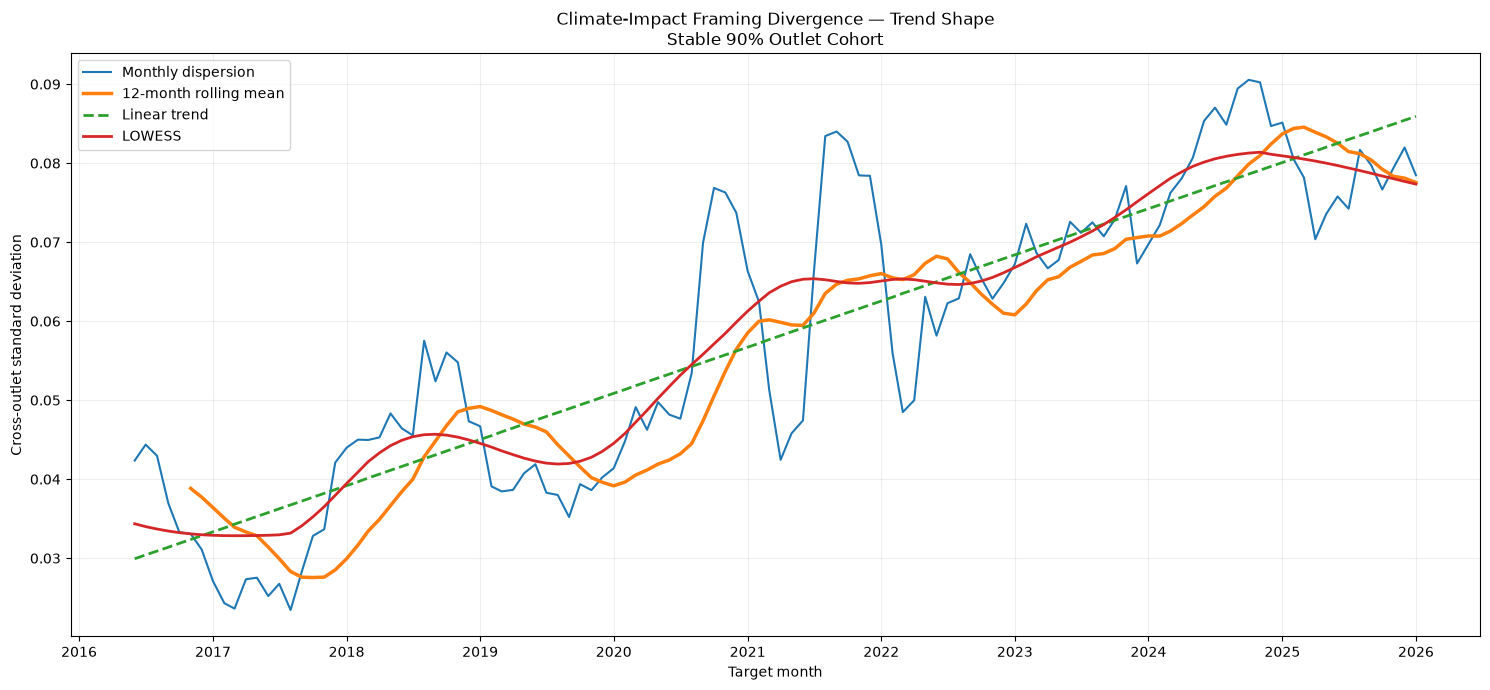

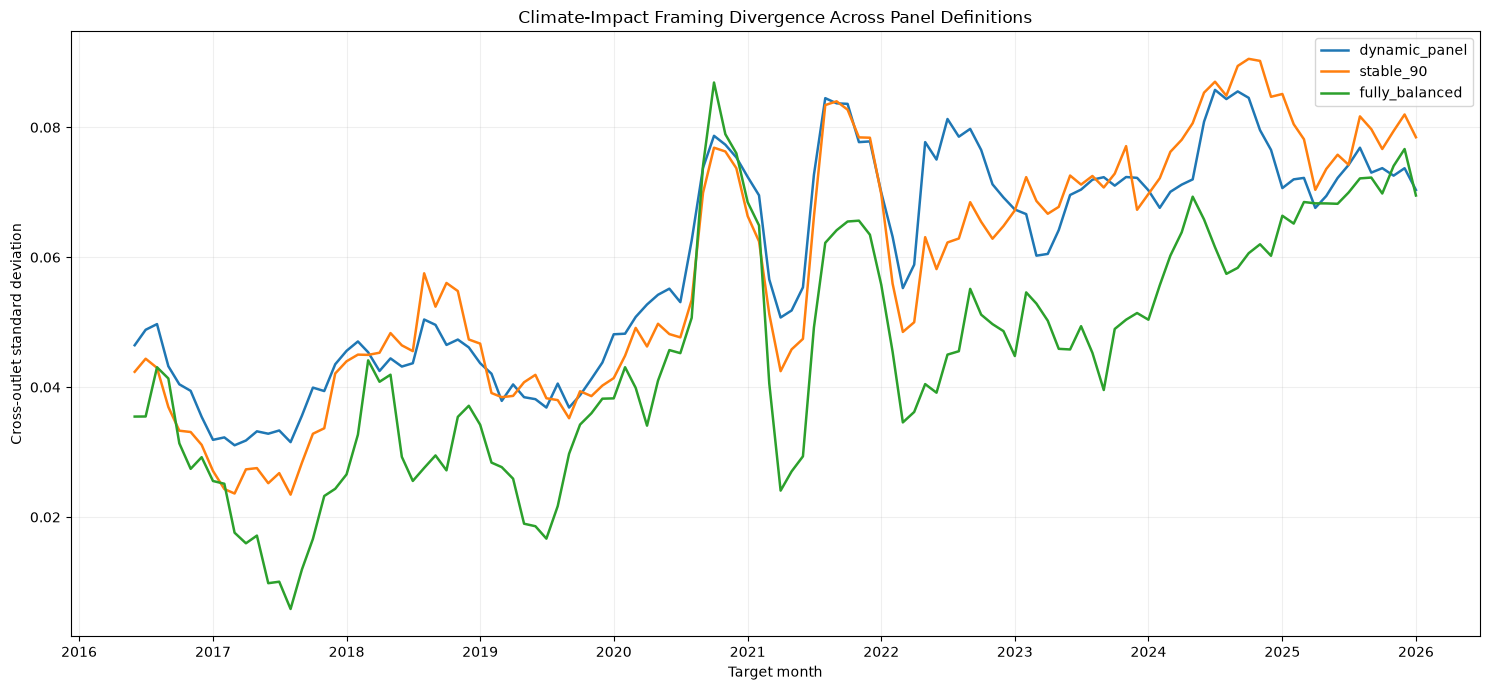

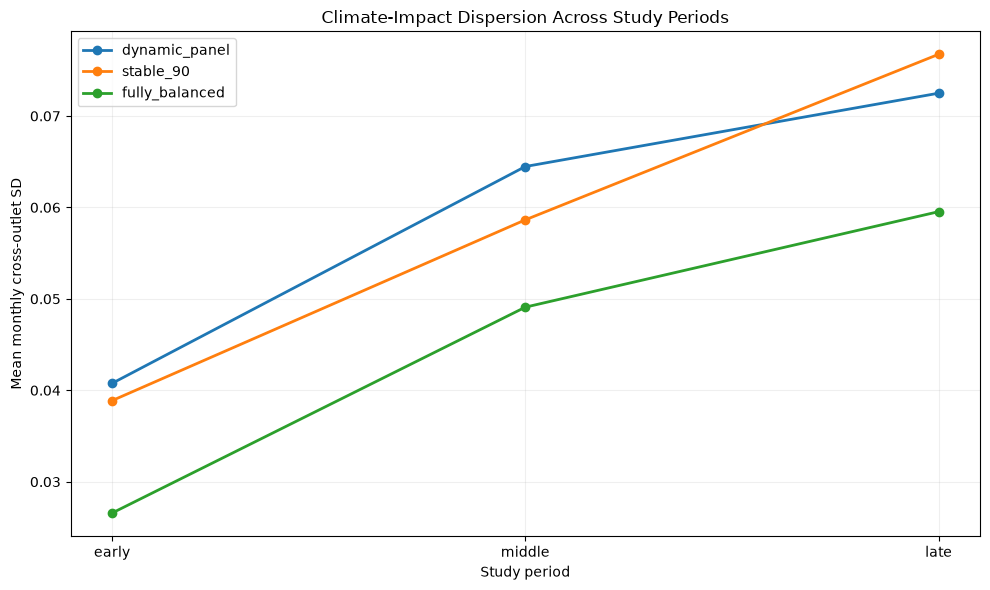

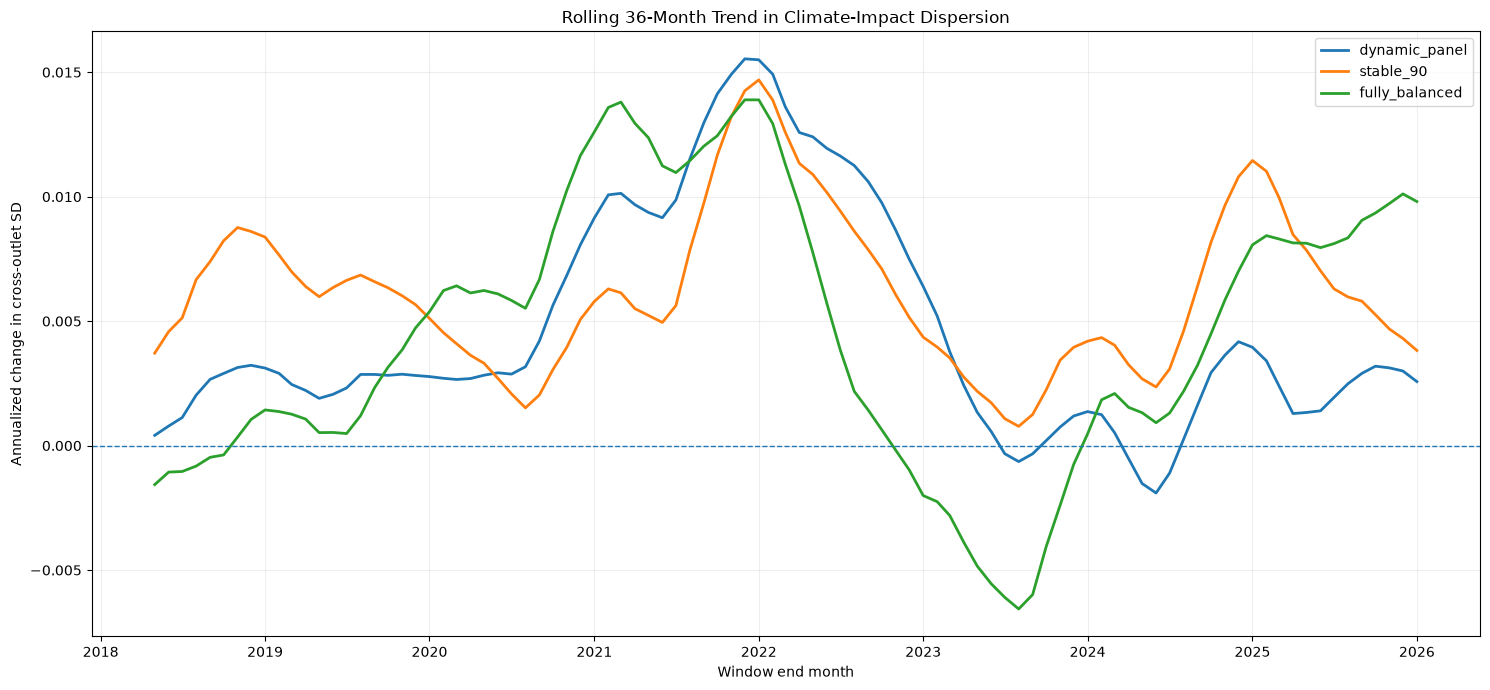


CELL 37 VALIDATION
Rows analyzed: 348
Months analyzed: 116
First month: 2016-06
Last month: 2026-01
Panels: ['dynamic_panel', 'stable_90', 'fully_balanced']

Artifacts:
Trend shape summary:
/Users/lasya/Documents/projects/media-polarization-lab/data/processed/climate_impact_trend_shape_summary.parquet

Polynomial models:
/Users/lasya/Documents/projects/media-polarization-lab/data/processed/climate_impact_polynomial_models.parquet

Period results:
/Users/lasya/Documents/projects/media-polarization-lab/data/processed/climate_impact_trend_periods.parquet

Rolling slopes:
/Users/lasya/Documents/projects/media-polarization-lab/data/processed/climate_impact_rolling_slopes.parquet

✓ analysis_month used as monthly time variable
✓ climate_impacts_std used as primary dispersion measure
✓ climate_impacts_iqr retained as secondary dispersion measure
✓ HAC linear trend estimated
✓ nonlinear polynomial specifications compared
✓ early / middle / late periods compared
✓ rolling 36-month slope estima

In [69]:
# ============================================================
# CELL 37
# CLIMATE-IMPACT TREND SHAPE ANALYSIS
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
from scipy.stats import spearmanr
from statsmodels.nonparametric.smoothers_lowess import lowess


# ============================================================
# PATHS
# ============================================================

PROJECT_ROOT = Path(
    "/Users/lasya/Documents/projects/media-polarization-lab"
)

PROCESSED_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

INPUT_PATH = (
    PROCESSED_DIR
    / "climate_dimension_monthly_dispersion.parquet"
)

STRUCTURAL_BREAK_PATH = (
    PROCESSED_DIR
    / "climate_impact_structural_breaks.parquet"
)

SUMMARY_OUT = (
    PROCESSED_DIR
    / "climate_impact_trend_shape_summary.parquet"
)

POLYNOMIAL_OUT = (
    PROCESSED_DIR
    / "climate_impact_polynomial_models.parquet"
)

ROLLING_OUT = (
    PROCESSED_DIR
    / "climate_impact_rolling_slopes.parquet"
)

PERIOD_OUT = (
    PROCESSED_DIR
    / "climate_impact_trend_periods.parquet"
)


# ============================================================
# SETTINGS
# ============================================================

PANEL_COL = "panel"
MONTH_COL = "analysis_month"
STD_COL = "climate_impacts_std"
IQR_COL = "climate_impacts_iqr"
OUTLETS_COL = "outlets"

PANEL_ORDER = [
    "dynamic_panel",
    "stable_90",
    "fully_balanced",
]


# ============================================================
# HELPERS
# ============================================================

def header(title):
    print()
    print("=" * 72)
    print(title)
    print("=" * 72)


def to_month_timestamp(series):

    if isinstance(
        series.dtype,
        pd.PeriodDtype,
    ):
        return (
            series
            .dt
            .to_timestamp()
        )

    return (
        pd.to_datetime(
            series,
            errors="coerce",
        )
        .dt
        .to_period("M")
        .dt
        .to_timestamp()
    )


def linear_hac_fit(
    data,
    value_col,
    hac_lags=12,
):

    d = (
        data[
            [
                MONTH_COL,
                value_col,
            ]
        ]
        .dropna()
        .sort_values(
            MONTH_COL
        )
        .reset_index(
            drop=True
        )
    )

    n = len(d)

    if n < 12:
        return None

    t_years = (
        np.arange(n)
        / 12.0
    )

    X = sm.add_constant(
        t_years
    )

    y = (
        d[value_col]
        .astype(float)
        .to_numpy()
    )

    model = (
        sm.OLS(
            y,
            X,
        )
        .fit(
            cov_type="HAC",
            cov_kwds={
                "maxlags": min(
                    hac_lags,
                    max(
                        1,
                        n - 2,
                    ),
                )
            },
        )
    )

    slope = float(
        model.params[1]
    )

    se = float(
        model.bse[1]
    )

    return {
        "months": n,
        "first_month": d[
            MONTH_COL
        ].min(),
        "last_month": d[
            MONTH_COL
        ].max(),
        "annualized_change": slope,
        "hac_se": se,
        "ci_lower": slope - 1.96 * se,
        "ci_upper": slope + 1.96 * se,
        "p_value": float(
            model.pvalues[1]
        ),
        "r_squared": float(
            model.rsquared
        ),
        "intercept": float(
            model.params[0]
        ),
    }


def polynomial_fit(
    data,
    degree,
    hac_lags=12,
):

    d = (
        data[
            [
                MONTH_COL,
                STD_COL,
            ]
        ]
        .dropna()
        .sort_values(
            MONTH_COL
        )
        .reset_index(
            drop=True
        )
    )

    n = len(d)

    if n < 18:
        return None

    t = (
        np.arange(n)
        / 12.0
    )

    t_centered = (
        t
        - t.mean()
    )

    X_parts = []

    for power in range(
        1,
        degree + 1,
    ):
        X_parts.append(
            t_centered ** power
        )

    X = np.column_stack(
        X_parts
    )

    X = sm.add_constant(
        X
    )

    y = (
        d[STD_COL]
        .astype(float)
        .to_numpy()
    )

    ordinary = (
        sm.OLS(
            y,
            X,
        )
        .fit()
    )

    robust = (
        sm.OLS(
            y,
            X,
        )
        .fit(
            cov_type="HAC",
            cov_kwds={
                "maxlags": min(
                    hac_lags,
                    max(
                        1,
                        n - 2,
                    ),
                )
            },
        )
    )

    result = {
        "degree": degree,
        "months": n,
        "aic": float(
            ordinary.aic
        ),
        "bic": float(
            ordinary.bic
        ),
        "r_squared": float(
            ordinary.rsquared
        ),
        "adj_r_squared": float(
            ordinary.rsquared_adj
        ),
    }

    for i in range(
        1,
        degree + 1,
    ):

        result[
            f"beta_{i}"
        ] = float(
            robust.params[i]
        )

        result[
            f"se_{i}"
        ] = float(
            robust.bse[i]
        )

        result[
            f"p_value_{i}"
        ] = float(
            robust.pvalues[i]
        )

    return result


def rolling_hac_slopes(
    data,
    window=36,
    minimum_months=24,
):

    d = (
        data[
            [
                MONTH_COL,
                STD_COL,
            ]
        ]
        .dropna()
        .sort_values(
            MONTH_COL
        )
        .reset_index(
            drop=True
        )
    )

    rows = []

    for end_idx in range(
        minimum_months - 1,
        len(d),
    ):

        start_idx = max(
            0,
            end_idx - window + 1,
        )

        subset = (
            d
            .iloc[
                start_idx:
                end_idx + 1
            ]
            .copy()
        )

        if len(subset) < minimum_months:
            continue

        fit = linear_hac_fit(
            subset,
            STD_COL,
            hac_lags=min(
                12,
                max(
                    1,
                    len(subset) // 3,
                ),
            ),
        )

        if fit is None:
            continue

        rows.append(
            {
                "window_start": subset[
                    MONTH_COL
                ].min(),
                "window_end": subset[
                    MONTH_COL
                ].max(),
                "months": len(
                    subset
                ),
                "annualized_change": fit[
                    "annualized_change"
                ],
                "hac_se": fit[
                    "hac_se"
                ],
                "ci_lower": fit[
                    "ci_lower"
                ],
                "ci_upper": fit[
                    "ci_upper"
                ],
                "p_value": fit[
                    "p_value"
                ],
                "r_squared": fit[
                    "r_squared"
                ],
            }
        )

    return pd.DataFrame(
        rows
    )


# ============================================================
# LOAD
# ============================================================

header(
    "CLIMATE-IMPACT TREND SHAPE ANALYSIS"
)

df = pd.read_parquet(
    INPUT_PATH
).copy()


print(
    f"Input: {INPUT_PATH}"
)

print(
    f"Rows: {len(df):,}"
)

print(
    f"Columns: {list(df.columns)}"
)


# ============================================================
# VALIDATE SCHEMA
# ============================================================

required = [
    PANEL_COL,
    MONTH_COL,
    OUTLETS_COL,
    STD_COL,
    IQR_COL,
]

missing = [
    col
    for col in required
    if col not in df.columns
]

if missing:

    raise KeyError(
        f"""
Missing required columns:
{missing}

Available columns:
{list(df.columns)}
"""
    )


# ============================================================
# CLEAN MONTH
# ============================================================

df[
    MONTH_COL
] = to_month_timestamp(
    df[
        MONTH_COL
    ]
)

bad_months = (
    df[
        MONTH_COL
    ]
    .isna()
    .sum()
)

print(
    f"Unparseable month rows: {bad_months:,}"
)

df = (
    df[
        df[
            MONTH_COL
        ].notna()
    ]
    .copy()
)


# ============================================================
# VALIDATE PANEL
# ============================================================

available_panels = (
    df[
        PANEL_COL
    ]
    .dropna()
    .unique()
    .tolist()
)

panel_order = [
    panel
    for panel in PANEL_ORDER
    if panel in available_panels
]

panel_order += [
    panel
    for panel in available_panels
    if panel not in panel_order
]


print(
    f"Panels: {panel_order}"
)

print(
    "Study period: "
    f"{df[MONTH_COL].min().strftime('%Y-%m')} "
    f"to "
    f"{df[MONTH_COL].max().strftime('%Y-%m')}"
)

print(
    f"Unique months: {df[MONTH_COL].nunique()}"
)


# ============================================================
# DUPLICATE CHECK
# ============================================================

duplicates = (
    df
    .duplicated(
        subset=[
            PANEL_COL,
            MONTH_COL,
        ]
    )
    .sum()
)

print(
    f"Duplicate panel-month rows: {duplicates:,}"
)

if duplicates:

    df = (
        df
        .groupby(
            [
                PANEL_COL,
                MONTH_COL,
            ],
            as_index=False,
        )
        .agg(
            {
                OUTLETS_COL: "max",
                STD_COL: "mean",
                IQR_COL: "mean",
            }
        )
    )


# ============================================================
# STUDY PANEL SUMMARY
# ============================================================

header(
    "STUDY PANEL"
)

study_rows = []

for panel in panel_order:

    p = (
        df[
            df[
                PANEL_COL
            ]
            == panel
        ]
        .sort_values(
            MONTH_COL
        )
    )

    study_rows.append(
        {
            "panel": panel,
            "months": p[
                MONTH_COL
            ].nunique(),
            "first_month": p[
                MONTH_COL
            ].min(),
            "last_month": p[
                MONTH_COL
            ].max(),
            "mean_outlets": p[
                OUTLETS_COL
            ].mean(),
            "mean_std": p[
                STD_COL
            ].mean(),
            "median_std": p[
                STD_COL
            ].median(),
            "min_std": p[
                STD_COL
            ].min(),
            "max_std": p[
                STD_COL
            ].max(),
        }
    )

study_summary = pd.DataFrame(
    study_rows
)

display(
    study_summary.round(
        6
    )
)


# ============================================================
# LINEAR HAC TREND
# ============================================================

header(
    "LINEAR HAC TREND"
)

linear_rows = []

for panel in panel_order:

    p = (
        df[
            df[
                PANEL_COL
            ]
            == panel
        ]
        .copy()
    )

    fit = linear_hac_fit(
        p,
        STD_COL,
        hac_lags=12,
    )

    if fit is None:
        continue

    fit[
        "panel"
    ] = panel

    linear_rows.append(
        fit
    )

linear_results = pd.DataFrame(
    linear_rows
)

linear_results = linear_results[
    [
        "panel",
        "months",
        "first_month",
        "last_month",
        "annualized_change",
        "hac_se",
        "ci_lower",
        "ci_upper",
        "p_value",
        "r_squared",
        "intercept",
    ]
]

display(
    linear_results.round(
        6
    )
)


# ============================================================
# MONOTONIC TREND
# ============================================================

header(
    "MONOTONIC TIME TREND"
)

spearman_rows = []

for panel in panel_order:

    p = (
        df[
            df[
                PANEL_COL
            ]
            == panel
        ]
        .sort_values(
            MONTH_COL
        )
        .dropna(
            subset=[
                STD_COL
            ]
        )
        .reset_index(
            drop=True
        )
    )

    rho, p_value = spearmanr(
        np.arange(
            len(p)
        ),
        p[
            STD_COL
        ].astype(
            float
        ),
    )

    spearman_rows.append(
        {
            "panel": panel,
            "months": len(p),
            "spearman_rho": rho,
            "spearman_p_value": p_value,
        }
    )

spearman_results = pd.DataFrame(
    spearman_rows
)

display(
    spearman_results.round(
        6
    )
)


# ============================================================
# LINEAR VS NONLINEAR TREND SHAPE
# ============================================================

header(
    "LINEAR VS NONLINEAR TREND SHAPE"
)

poly_rows = []

for panel in panel_order:

    p = (
        df[
            df[
                PANEL_COL
            ]
            == panel
        ]
        .copy()
    )

    for degree in [
        1,
        2,
        3,
    ]:

        result = polynomial_fit(
            p,
            degree=degree,
            hac_lags=12,
        )

        if result is None:
            continue

        result[
            "panel"
        ] = panel

        poly_rows.append(
            result
        )

polynomial_results = pd.DataFrame(
    poly_rows
)

base_cols = [
    "panel",
    "degree",
    "months",
    "aic",
    "bic",
    "r_squared",
    "adj_r_squared",
]

extra_cols = [
    c
    for c in polynomial_results.columns
    if c not in base_cols
]

polynomial_results = polynomial_results[
    base_cols
    + extra_cols
]

display(
    polynomial_results.round(
        6
    )
)


# ============================================================
# MODEL SELECTION
# ============================================================

header(
    "TREND-SHAPE MODEL SELECTION"
)

model_rows = []

for panel in panel_order:

    p = (
        polynomial_results[
            polynomial_results[
                "panel"
            ]
            == panel
        ]
        .copy()
    )

    if p.empty:
        continue

    best = (
        p
        .sort_values(
            "bic"
        )
        .iloc[
            0
        ]
    )

    def get_value(
        degree,
        column,
    ):

        row = (
            p[
                p[
                    "degree"
                ]
                == degree
            ]
        )

        if row.empty:
            return np.nan

        if column not in row.columns:
            return np.nan

        return float(
            row[
                column
            ].iloc[
                0
            ]
        )

    linear_bic = get_value(
        1,
        "bic",
    )

    quadratic_bic = get_value(
        2,
        "bic",
    )

    cubic_bic = get_value(
        3,
        "bic",
    )

    model_rows.append(
        {
            "panel": panel,
            "preferred_degree_bic": int(
                best[
                    "degree"
                ]
            ),
            "linear_bic": linear_bic,
            "quadratic_bic": quadratic_bic,
            "cubic_bic": cubic_bic,
            "quadratic_vs_linear_delta_bic": (
                linear_bic
                - quadratic_bic
            ),
            "cubic_vs_linear_delta_bic": (
                linear_bic
                - cubic_bic
            ),
            "quadratic_term_p_value": get_value(
                2,
                "p_value_2",
            ),
            "cubic_term_p_value": get_value(
                3,
                "p_value_3",
            ),
        }
    )

model_selection = pd.DataFrame(
    model_rows
)

display(
    model_selection.round(
        6
    )
)


# ============================================================
# EARLY / MIDDLE / LATE PERIODS
# ============================================================

header(
    "EARLY / MIDDLE / LATE TREND SHAPE"
)

months = (
    pd.Series(
        sorted(
            df[
                MONTH_COL
            ]
            .dropna()
            .unique()
        )
    )
)

month_groups = np.array_split(
    months.to_numpy(),
    3,
)

period_names = [
    "early",
    "middle",
    "late",
]

month_to_period = {}

for period_name, group in zip(
    period_names,
    month_groups,
):

    for month in group:

        month_to_period[
            pd.Timestamp(
                month
            )
        ] = period_name


df[
    "study_period"
] = (
    df[
        MONTH_COL
    ]
    .map(
        month_to_period
    )
)


period_rows = []

for panel in panel_order:

    for period in period_names:

        p = (
            df[
                (
                    df[
                        PANEL_COL
                    ]
                    == panel
                )
                &
                (
                    df[
                        "study_period"
                    ]
                    == period
                )
            ]
            .copy()
        )

        if p.empty:
            continue

        fit = linear_hac_fit(
            p,
            STD_COL,
            hac_lags=6,
        )

        period_rows.append(
            {
                "panel": panel,
                "period": period,
                "months": p[
                    MONTH_COL
                ].nunique(),
                "first_month": p[
                    MONTH_COL
                ].min(),
                "last_month": p[
                    MONTH_COL
                ].max(),
                "mean_std": p[
                    STD_COL
                ].mean(),
                "median_std": p[
                    STD_COL
                ].median(),
                "mean_iqr": p[
                    IQR_COL
                ].mean(),
                "mean_outlets": p[
                    OUTLETS_COL
                ].mean(),
                "annualized_change": (
                    fit[
                        "annualized_change"
                    ]
                    if fit
                    else np.nan
                ),
                "trend_p_value": (
                    fit[
                        "p_value"
                    ]
                    if fit
                    else np.nan
                ),
            }
        )

period_results = pd.DataFrame(
    period_rows
)

display(
    period_results.round(
        6
    )
)


# ============================================================
# EARLY -> LATE DISPERSION CHANGE
# ============================================================

header(
    "EARLY TO LATE DISPERSION CHANGE"
)

period_pivot = (
    period_results
    .pivot(
        index="panel",
        columns="period",
        values="mean_std",
    )
)

change_rows = []

for panel in panel_order:

    if panel not in period_pivot.index:
        continue

    early = period_pivot.loc[
        panel
    ].get(
        "early",
        np.nan,
    )

    middle = period_pivot.loc[
        panel
    ].get(
        "middle",
        np.nan,
    )

    late = period_pivot.loc[
        panel
    ].get(
        "late",
        np.nan,
    )

    change = (
        late
        - early
    )

    pct_change = (
        change
        / early
        * 100
        if pd.notna(
            early
        )
        and early != 0
        else np.nan
    )

    change_rows.append(
        {
            "panel": panel,
            "early": early,
            "middle": middle,
            "late": late,
            "early_to_late_change": change,
            "early_to_late_pct_change": pct_change,
        }
    )

early_late_results = pd.DataFrame(
    change_rows
)

display(
    early_late_results.round(
        6
    )
)


# ============================================================
# ROLLING 36-MONTH TREND
# ============================================================

header(
    "ROLLING 36-MONTH TREND"
)

rolling_frames = []

for panel in panel_order:

    p = (
        df[
            df[
                PANEL_COL
            ]
            == panel
        ]
        .copy()
    )

    rolling = rolling_hac_slopes(
        p,
        window=36,
        minimum_months=24,
    )

    if rolling.empty:
        continue

    rolling[
        "panel"
    ] = panel

    rolling_frames.append(
        rolling
    )

if rolling_frames:

    rolling_results = pd.concat(
        rolling_frames,
        ignore_index=True,
    )

else:

    rolling_results = pd.DataFrame()


if not rolling_results.empty:

    latest_rolling = (
        rolling_results
        .sort_values(
            "window_end"
        )
        .groupby(
            "panel",
            as_index=False,
        )
        .tail(
            1
        )
    )

    display(
        latest_rolling[
            [
                "panel",
                "window_start",
                "window_end",
                "months",
                "annualized_change",
                "hac_se",
                "ci_lower",
                "ci_upper",
                "p_value",
                "r_squared",
            ]
        ]
        .round(
            6
        )
    )


# ============================================================
# YEAR-OVER-YEAR DIRECTION
# ============================================================

header(
    "YEAR-OVER-YEAR DIRECTION CHECK"
)

yoy_rows = []

for panel in panel_order:

    p = (
        df[
            df[
                PANEL_COL
            ]
            == panel
        ]
        .sort_values(
            MONTH_COL
        )
        .copy()
    )

    p[
        "yoy_change"
    ] = (
        p[
            STD_COL
        ]
        - p[
            STD_COL
        ].shift(
            12
        )
    )

    valid = (
        p[
            "yoy_change"
        ]
        .dropna()
    )

    if valid.empty:
        continue

    yoy_rows.append(
        {
            "panel": panel,
            "comparisons": len(
                valid
            ),
            "positive_yoy_pct": (
                valid.gt(
                    0
                ).mean()
                * 100
            ),
            "negative_yoy_pct": (
                valid.lt(
                    0
                ).mean()
                * 100
            ),
            "mean_yoy_change": valid.mean(),
            "median_yoy_change": valid.median(),
        }
    )

yoy_results = pd.DataFrame(
    yoy_rows
)

display(
    yoy_results.round(
        6
    )
)


# ============================================================
# STRUCTURAL BREAK CONTEXT
# ============================================================

header(
    "STRUCTURAL-BREAK CONTEXT"
)

if STRUCTURAL_BREAK_PATH.exists():

    break_results = pd.read_parquet(
        STRUCTURAL_BREAK_PATH
    ).copy()

    break_cols = [
        col
        for col in [
            "panel",
            "break_idx",
            "break_month",
            "delta_bic",
            "observed_sup_f",
            "bootstrap_p_value",
            "pre_break_slope",
            "slope_change",
            "slope_change_p_value",
            "post_break_slope",
            "linear_r_squared",
            "segmented_r_squared",
        ]
        if col in break_results.columns
    ]

    display(
        break_results[
            break_cols
        ]
        .round(
            6
        )
    )

else:

    break_results = None

    print(
        "Structural-break artifact not found."
    )


# ============================================================
# PRIMARY STABLE-90 SUMMARY
# ============================================================

header(
    "PRIMARY STABLE-90 TREND SHAPE"
)

if "stable_90" in panel_order:

    primary_panel = "stable_90"

else:

    primary_panel = panel_order[
        0
    ]


primary_linear = (
    linear_results[
        linear_results[
            "panel"
        ]
        == primary_panel
    ]
)

primary_shape = (
    model_selection[
        model_selection[
            "panel"
        ]
        == primary_panel
    ]
)

primary_change = (
    early_late_results[
        early_late_results[
            "panel"
        ]
        == primary_panel
    ]
)


print(
    f"Primary panel: {primary_panel}"
)


if not primary_linear.empty:

    row = primary_linear.iloc[
        0
    ]

    print(
        f"Annualized linear change: "
        f"{row['annualized_change']:.6f}"
    )

    print(
        f"95% HAC CI: "
        f"[{row['ci_lower']:.6f}, "
        f"{row['ci_upper']:.6f}]"
    )

    print(
        f"Linear trend p-value: "
        f"{row['p_value']:.6f}"
    )

    print(
        f"Linear R²: "
        f"{row['r_squared']:.4f}"
    )


if not primary_change.empty:

    row = primary_change.iloc[
        0
    ]

    print(
        f"Early mean SD: "
        f"{row['early']:.6f}"
    )

    print(
        f"Middle mean SD: "
        f"{row['middle']:.6f}"
    )

    print(
        f"Late mean SD: "
        f"{row['late']:.6f}"
    )

    print(
        f"Early -> late change: "
        f"{row['early_to_late_change']:.6f}"
    )

    print(
        f"Early -> late % change: "
        f"{row['early_to_late_pct_change']:.2f}%"
    )


if not primary_shape.empty:

    row = primary_shape.iloc[
        0
    ]

    print(
        f"BIC-preferred polynomial degree: "
        f"{int(row['preferred_degree_bic'])}"
    )

    print(
        f"Quadratic vs linear delta BIC: "
        f"{row['quadratic_vs_linear_delta_bic']:.3f}"
    )

    print(
        f"Quadratic term HAC p-value: "
        f"{row['quadratic_term_p_value']:.6f}"
    )


if break_results is not None:

    primary_break = (
        break_results[
            break_results[
                "panel"
            ]
            == primary_panel
        ]
    )

    if not primary_break.empty:

        b = primary_break.iloc[
            0
        ]

        print()
        print(
            f"Structural-break candidate: "
            f"{b.get('break_month', np.nan)}"
        )

        print(
            f"Bootstrap break p-value: "
            f"{b.get('bootstrap_p_value', np.nan):.6f}"
        )

        print(
            f"Slope-change p-value: "
            f"{b.get('slope_change_p_value', np.nan):.6f}"
        )


# ============================================================
# PLOT 1
# MONTHLY TREND SHAPE
# ============================================================

primary_data = (
    df[
        df[
            PANEL_COL
        ]
        == primary_panel
    ]
    .sort_values(
        MONTH_COL
    )
    .dropna(
        subset=[
            STD_COL
        ]
    )
    .copy()
)


primary_data[
    "rolling_12m"
] = (
    primary_data[
        STD_COL
    ]
    .rolling(
        window=12,
        min_periods=6,
    )
    .mean()
)


n = len(
    primary_data
)

t_years = (
    np.arange(
        n
    )
    / 12.0
)


linear_model = (
    sm.OLS(
        primary_data[
            STD_COL
        ].astype(
            float
        ),
        sm.add_constant(
            t_years
        ),
    )
    .fit()
)


primary_data[
    "linear_fit"
] = (
    linear_model
    .predict(
        sm.add_constant(
            t_years
        )
    )
)


primary_data[
    "lowess"
] = lowess(
    endog=primary_data[
        STD_COL
    ].astype(
        float
    ),
    exog=np.arange(
        n
    ),
    frac=0.25,
    return_sorted=False,
)


plt.figure(
    figsize=(
        15,
        7,
    )
)

plt.plot(
    primary_data[
        MONTH_COL
    ],
    primary_data[
        STD_COL
    ],
    label="Monthly dispersion",
)

plt.plot(
    primary_data[
        MONTH_COL
    ],
    primary_data[
        "rolling_12m"
    ],
    linewidth=2.5,
    label="12-month rolling mean",
)

plt.plot(
    primary_data[
        MONTH_COL
    ],
    primary_data[
        "linear_fit"
    ],
    linestyle="--",
    linewidth=2,
    label="Linear trend",
)

plt.plot(
    primary_data[
        MONTH_COL
    ],
    primary_data[
        "lowess"
    ],
    linewidth=2,
    label="LOWESS",
)

plt.title(
    "Climate-Impact Framing Divergence — Trend Shape\n"
    "Stable 90% Outlet Cohort"
)

plt.xlabel(
    "Target month"
)

plt.ylabel(
    "Cross-outlet standard deviation"
)

plt.legend()

plt.grid(
    alpha=0.2
)

plt.tight_layout()

plt.show()


# ============================================================
# PLOT 2
# ALL PANELS
# ============================================================

plt.figure(
    figsize=(
        15,
        7,
    )
)

for panel in panel_order:

    p = (
        df[
            df[
                PANEL_COL
            ]
            == panel
        ]
        .sort_values(
            MONTH_COL
        )
    )

    plt.plot(
        p[
            MONTH_COL
        ],
        p[
            STD_COL
        ],
        label=panel,
        linewidth=1.8,
    )

plt.title(
    "Climate-Impact Framing Divergence Across Panel Definitions"
)

plt.xlabel(
    "Target month"
)

plt.ylabel(
    "Cross-outlet standard deviation"
)

plt.legend()

plt.grid(
    alpha=0.2
)

plt.tight_layout()

plt.show()


# ============================================================
# PLOT 3
# EARLY / MIDDLE / LATE
# ============================================================

plt.figure(
    figsize=(
        10,
        6,
    )
)

for panel in panel_order:

    p = (
        period_results[
            period_results[
                "panel"
            ]
            == panel
        ]
        .set_index(
            "period"
        )
        .reindex(
            period_names
        )
    )

    plt.plot(
        period_names,
        p[
            "mean_std"
        ],
        marker="o",
        linewidth=2,
        label=panel,
    )

plt.title(
    "Climate-Impact Dispersion Across Study Periods"
)

plt.xlabel(
    "Study period"
)

plt.ylabel(
    "Mean monthly cross-outlet SD"
)

plt.legend()

plt.grid(
    alpha=0.2
)

plt.tight_layout()

plt.show()


# ============================================================
# PLOT 4
# ROLLING 36-MONTH SLOPE
# ============================================================

if not rolling_results.empty:

    plt.figure(
        figsize=(
            15,
            7,
        )
    )

    for panel in panel_order:

        p = (
            rolling_results[
                rolling_results[
                    "panel"
                ]
                == panel
            ]
            .sort_values(
                "window_end"
            )
        )

        plt.plot(
            p[
                "window_end"
            ],
            p[
                "annualized_change"
            ],
            linewidth=2,
            label=panel,
        )

    plt.axhline(
        0,
        linestyle="--",
        linewidth=1,
    )

    plt.title(
        "Rolling 36-Month Trend in Climate-Impact Dispersion"
    )

    plt.xlabel(
        "Window end month"
    )

    plt.ylabel(
        "Annualized change in cross-outlet SD"
    )

    plt.legend()

    plt.grid(
        alpha=0.2
    )

    plt.tight_layout()

    plt.show()


# ============================================================
# SAVE RESULTS
# ============================================================

summary_output = (
    linear_results
    .merge(
        spearman_results,
        on=[
            "panel",
            "months",
        ],
        how="left",
    )
    .merge(
        early_late_results,
        on="panel",
        how="left",
    )
    .merge(
        model_selection,
        on="panel",
        how="left",
    )
)

summary_output.to_parquet(
    SUMMARY_OUT,
    index=False,
)

polynomial_results.to_parquet(
    POLYNOMIAL_OUT,
    index=False,
)

period_results.to_parquet(
    PERIOD_OUT,
    index=False,
)

if not rolling_results.empty:

    rolling_results.to_parquet(
        ROLLING_OUT,
        index=False,
    )


# ============================================================
# FINAL VALIDATION
# ============================================================

header(
    "CELL 37 VALIDATION"
)

print(
    f"Rows analyzed: {len(df):,}"
)

print(
    f"Months analyzed: {df[MONTH_COL].nunique():,}"
)

print(
    f"First month: {df[MONTH_COL].min().strftime('%Y-%m')}"
)

print(
    f"Last month: {df[MONTH_COL].max().strftime('%Y-%m')}"
)

print(
    f"Panels: {panel_order}"
)

print()
print(
    "Artifacts:"
)

print(
    f"Trend shape summary:\n{SUMMARY_OUT}"
)

print(
    f"\nPolynomial models:\n{POLYNOMIAL_OUT}"
)

print(
    f"\nPeriod results:\n{PERIOD_OUT}"
)

if not rolling_results.empty:

    print(
        f"\nRolling slopes:\n{ROLLING_OUT}"
    )

print()
print(
    "✓ analysis_month used as monthly time variable"
)

print(
    "✓ climate_impacts_std used as primary dispersion measure"
)

print(
    "✓ climate_impacts_iqr retained as secondary dispersion measure"
)

print(
    "✓ HAC linear trend estimated"
)

print(
    "✓ nonlinear polynomial specifications compared"
)

print(
    "✓ early / middle / late periods compared"
)

print(
    "✓ rolling 36-month slope estimated"
)

print(
    "✓ structural-break result placed in context"
)

print()
print(
    "CELL 37 COMPLETE"
)

In [70]:
# ============================================================
# CELL 38 — OUTLET-LEVEL CLIMATE-IMPACT TRAJECTORIES
# ============================================================

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy.stats import spearmanr

warnings.filterwarnings("ignore", category=FutureWarning)


# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

ROOT = Path.home() / "Documents/projects/media-polarization-lab"

PROCESSED_DIR = ROOT / "data" / "processed"

PROFILE_PATH = (
    PROCESSED_DIR
    / "outlet_month_climate_dimension_profiles.parquet"
)

MONTHLY_DIM_PATH = (
    PROCESSED_DIR
    / "climate_dimension_monthly_dispersion.parquet"
)

OUTPUT_PATH = (
    PROCESSED_DIR
    / "outlet_climate_impact_trends.parquet"
)


# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------

def to_month_start(series):

    return (
        pd.to_datetime(
            series.astype(str),
            errors="coerce",
        )
        .dt.to_period("M")
        .dt.to_timestamp()
    )


def calendar_month_index(series, base_month):

    series = pd.to_datetime(series)

    return (
        (series.dt.year - base_month.year) * 12
        + (series.dt.month - base_month.month)
    ).astype(float)


def hac_time_trend(
    df,
    month_col,
    value_col,
    maxlags=12,
):

    d = (
        df[
            [
                month_col,
                value_col,
            ]
        ]
        .dropna()
        .sort_values(month_col)
        .copy()
    )

    if len(d) < 12:

        return {
            "n_months": len(d),
            "annualized_change": np.nan,
            "hac_se": np.nan,
            "ci_lower": np.nan,
            "ci_upper": np.nan,
            "p_value": np.nan,
            "r_squared": np.nan,
            "spearman_rho": np.nan,
            "spearman_p_value": np.nan,
        }

    base_month = d[month_col].min()

    month_number = calendar_month_index(
        d[month_col],
        base_month,
    )

    t_years = month_number / 12.0

    X = sm.add_constant(
        t_years.to_numpy()
    )

    y = (
        d[value_col]
        .astype(float)
        .to_numpy()
    )

    model = sm.OLS(
        y,
        X,
    ).fit()

    robust = model.get_robustcov_results(
        cov_type="HAC",
        maxlags=min(
            maxlags,
            len(d) - 1,
        ),
    )

    slope = float(
        robust.params[1]
    )

    se = float(
        robust.bse[1]
    )

    p_value = float(
        robust.pvalues[1]
    )

    ci = np.asarray(
        robust.conf_int()
    )

    ci_lower = float(
        ci[1, 0]
    )

    ci_upper = float(
        ci[1, 1]
    )

    rho, rho_p = spearmanr(
        t_years,
        y,
    )

    return {
        "n_months": len(d),
        "annualized_change": slope,
        "hac_se": se,
        "ci_lower": ci_lower,
        "ci_upper": ci_upper,
        "p_value": p_value,
        "r_squared": float(
            model.rsquared
        ),
        "spearman_rho": float(rho),
        "spearman_p_value": float(rho_p),
    }


# ------------------------------------------------------------
# LOAD DATA
# ------------------------------------------------------------

print(
    "=" * 72
)

print(
    "OUTLET-LEVEL CLIMATE-IMPACT TRAJECTORIES"
)

print(
    "=" * 72
)


profiles = pd.read_parquet(
    PROFILE_PATH
)

monthly_dim = pd.read_parquet(
    MONTHLY_DIM_PATH
)


print(
    f"Profile rows: {len(profiles):,}"
)

print(
    f"Monthly-dimension rows: {len(monthly_dim):,}"
)


# ------------------------------------------------------------
# IDENTIFY MONTH COLUMNS
# ------------------------------------------------------------

profile_month_candidates = [
    "analysis_month",
    "target_month",
    "year_month",
    "month",
]

profile_month_col = next(
    (
        c
        for c in profile_month_candidates
        if c in profiles.columns
    ),
    None,
)

if profile_month_col is None:

    raise KeyError(
        "Could not identify month column in profile dataset.\n"
        f"Available columns:\n{profiles.columns.tolist()}"
    )


dimension_month_candidates = [
    "analysis_month",
    "target_month",
    "year_month",
    "month",
]

dimension_month_col = next(
    (
        c
        for c in dimension_month_candidates
        if c in monthly_dim.columns
    ),
    None,
)

if dimension_month_col is None:

    raise KeyError(
        "Could not identify month column in monthly dimension dataset.\n"
        f"Available columns:\n{monthly_dim.columns.tolist()}"
    )


profiles = profiles.copy()

profiles["analysis_month"] = to_month_start(
    profiles[
        profile_month_col
    ]
)

monthly_dim = monthly_dim.copy()

monthly_dim["analysis_month"] = to_month_start(
    monthly_dim[
        dimension_month_col
    ]
)


# ------------------------------------------------------------
# COMPLETE-MONTH STUDY PERIOD
#
# Cell 37 already excluded the incomplete 2026-02 month.
# Therefore the monthly-dimension dataset is our authoritative
# list of complete study months.
# ------------------------------------------------------------

study_months = (
    monthly_dim[
        "analysis_month"
    ]
    .dropna()
    .drop_duplicates()
    .sort_values()
    .tolist()
)


profiles = profiles[
    profiles[
        "analysis_month"
    ].isin(
        study_months
    )
].copy()


study_start = min(
    study_months
)

study_end = max(
    study_months
)

n_study_months = len(
    study_months
)


print()

print(
    "=" * 72
)

print(
    "STUDY PERIOD"
)

print(
    "=" * 72
)

print(
    f"Months: {n_study_months}"
)

print(
    f"First month: {study_start:%Y-%m}"
)

print(
    f"Last month:  {study_end:%Y-%m}"
)


# ------------------------------------------------------------
# VALIDATE REQUIRED COLUMNS
# ------------------------------------------------------------

OUTLET_COL = "media_name"

IMPACT_COL = (
    "relative_climate_impacts"
)


required_columns = [
    OUTLET_COL,
    "analysis_month",
    IMPACT_COL,
]

missing_columns = [
    c
    for c in required_columns
    if c not in profiles.columns
]

if missing_columns:

    raise KeyError(
        "Missing required columns:\n"
        f"{missing_columns}\n\n"
        f"Available columns:\n"
        f"{profiles.columns.tolist()}"
    )


# ------------------------------------------------------------
# ENSURE UNIQUE OUTLET-MONTH ROWS
# ------------------------------------------------------------

duplicate_rows = profiles.duplicated(
    subset=[
        OUTLET_COL,
        "analysis_month",
    ]
).sum()


print(
    f"Duplicate outlet-month rows: {duplicate_rows:,}"
)


if duplicate_rows > 0:

    profiles = (
        profiles
        .sort_values(
            [
                OUTLET_COL,
                "analysis_month",
            ]
        )
        .drop_duplicates(
            subset=[
                OUTLET_COL,
                "analysis_month",
            ],
            keep="last",
        )
        .copy()
    )


# ------------------------------------------------------------
# RECONSTRUCT STABLE 90% COHORT
# ------------------------------------------------------------

coverage = (
    profiles
    .groupby(
        OUTLET_COL
    )[
        "analysis_month"
    ]
    .nunique()
    .rename(
        "months_present"
    )
    .reset_index()
)


minimum_stable_months = int(
    np.ceil(
        0.90
        * n_study_months
    )
)


coverage[
    "coverage_pct"
] = (
    100
    * coverage[
        "months_present"
    ]
    / n_study_months
)


coverage[
    "stable_90"
] = (
    coverage[
        "months_present"
    ]
    >= minimum_stable_months
)


coverage[
    "fully_balanced"
] = (
    coverage[
        "months_present"
    ]
    == n_study_months
)


stable_outlets = (
    coverage.loc[
        coverage[
            "stable_90"
        ],
        OUTLET_COL,
    ]
    .sort_values()
    .tolist()
)


balanced_outlets = (
    coverage.loc[
        coverage[
            "fully_balanced"
        ],
        OUTLET_COL,
    ]
    .sort_values()
    .tolist()
)


print()

print(
    "=" * 72
)

print(
    "PRIMARY OUTLET COHORT"
)

print(
    "=" * 72
)

print(
    f"All observed outlets: "
    f"{coverage[OUTLET_COL].nunique():,}"
)

print(
    f"Minimum months for stable 90% cohort: "
    f"{minimum_stable_months}"
)

print(
    f"Stable >=90% outlets: "
    f"{len(stable_outlets)}"
)

print(
    f"Fully balanced outlets: "
    f"{len(balanced_outlets)}"
)


if len(stable_outlets) != 20:

    print()
    print(
        "WARNING:"
    )

    print(
        "Stable cohort does not contain 20 outlets."
    )

    print(
        "This is not automatically an error, but compare it "
        "with the cohort used in Cells 35–37."
    )


print()

print(
    "Stable outlets:"
)

for outlet in stable_outlets:

    print(
        f"  {outlet}"
    )


# ------------------------------------------------------------
# DEFINE EARLY / MIDDLE / LATE PERIODS
# ------------------------------------------------------------

month_blocks = np.array_split(
    np.array(
        study_months,
        dtype="datetime64[ns]",
    ),
    3,
)


early_months = set(
    pd.to_datetime(
        month_blocks[0]
    )
)

middle_months = set(
    pd.to_datetime(
        month_blocks[1]
    )
)

late_months = set(
    pd.to_datetime(
        month_blocks[2]
    )
)


print()

print(
    "=" * 72
)

print(
    "PERIOD DEFINITIONS"
)

print(
    "=" * 72
)

print(
    f"Early:  "
    f"{min(early_months):%Y-%m} -> "
    f"{max(early_months):%Y-%m} "
    f"({len(early_months)} months)"
)

print(
    f"Middle: "
    f"{min(middle_months):%Y-%m} -> "
    f"{max(middle_months):%Y-%m} "
    f"({len(middle_months)} months)"
)

print(
    f"Late:   "
    f"{min(late_months):%Y-%m} -> "
    f"{max(late_months):%Y-%m} "
    f"({len(late_months)} months)"
)


# ------------------------------------------------------------
# ESTIMATE OUTLET-SPECIFIC TRAJECTORIES
# ------------------------------------------------------------

rows = []


for outlet in stable_outlets:

    d = (
        profiles[
            profiles[
                OUTLET_COL
            ].eq(
                outlet
            )
        ]
        .sort_values(
            "analysis_month"
        )
        .copy()
    )


    trend = hac_time_trend(
        d,
        month_col="analysis_month",
        value_col=IMPACT_COL,
        maxlags=12,
    )


    early = d[
        d[
            "analysis_month"
        ].isin(
            early_months
        )
    ][
        IMPACT_COL
    ].dropna()


    middle = d[
        d[
            "analysis_month"
        ].isin(
            middle_months
        )
    ][
        IMPACT_COL
    ].dropna()


    late = d[
        d[
            "analysis_month"
        ].isin(
            late_months
        )
    ][
        IMPACT_COL
    ].dropna()


    early_mean = (
        float(
            early.mean()
        )
        if len(early)
        else np.nan
    )


    middle_mean = (
        float(
            middle.mean()
        )
        if len(middle)
        else np.nan
    )


    late_mean = (
        float(
            late.mean()
        )
        if len(late)
        else np.nan
    )


    early_to_late_change = (
        late_mean
        - early_mean
    )


    if (
        np.isfinite(
            trend[
                "ci_lower"
            ]
        )
        and trend[
            "ci_lower"
        ] > 0
    ):

        trend_direction = (
            "increasing"
        )

    elif (
        np.isfinite(
            trend[
                "ci_upper"
            ]
        )
        and trend[
            "ci_upper"
        ] < 0
    ):

        trend_direction = (
            "decreasing"
        )

    else:

        trend_direction = (
            "not_significantly_different_from_zero"
        )


    row = {
        "media_name": outlet,
        "study_months": n_study_months,
        "months_present": int(
            d[
                "analysis_month"
            ].nunique()
        ),
        "coverage_pct": float(
            100
            * d[
                "analysis_month"
            ].nunique()
            / n_study_months
        ),
        "first_month": d[
            "analysis_month"
        ].min(),
        "last_month": d[
            "analysis_month"
        ].max(),
        "early_mean": early_mean,
        "middle_mean": middle_mean,
        "late_mean": late_mean,
        "early_to_late_change": early_to_late_change,
        "trend_direction": trend_direction,
        **trend,
    }


    rows.append(
        row
    )


outlet_trends = pd.DataFrame(
    rows
)


# ------------------------------------------------------------
# RANK OUTLETS
# ------------------------------------------------------------

outlet_trends[
    "rank_by_annualized_change"
] = (
    outlet_trends[
        "annualized_change"
    ]
    .rank(
        ascending=False,
        method="min",
    )
    .astype(
        "Int64"
    )
)


outlet_trends[
    "rank_by_early_to_late_change"
] = (
    outlet_trends[
        "early_to_late_change"
    ]
    .rank(
        ascending=False,
        method="min",
    )
    .astype(
        "Int64"
    )
)


outlet_trends = (
    outlet_trends
    .sort_values(
        "annualized_change",
        ascending=False,
    )
    .reset_index(
        drop=True
    )
)


# ------------------------------------------------------------
# OUTPUT TABLE
# ------------------------------------------------------------

print()

print(
    "=" * 72
)

print(
    "OUTLET-SPECIFIC CLIMATE-IMPACT TRENDS"
)

print(
    "=" * 72
)


display_columns = [
    "media_name",
    "coverage_pct",
    "early_mean",
    "middle_mean",
    "late_mean",
    "early_to_late_change",
    "annualized_change",
    "hac_se",
    "ci_lower",
    "ci_upper",
    "p_value",
    "spearman_rho",
    "trend_direction",
]


display(
    outlet_trends[
        display_columns
    ].round(
        6
    )
)


# ------------------------------------------------------------
# LARGEST INCREASES
# ------------------------------------------------------------

print()

print(
    "=" * 72
)

print(
    "LARGEST OUTLET-LEVEL INCREASES"
)

print(
    "=" * 72
)


display(
    outlet_trends[
        [
            "media_name",
            "early_mean",
            "late_mean",
            "early_to_late_change",
            "annualized_change",
            "ci_lower",
            "ci_upper",
            "p_value",
        ]
    ]
    .head(
        10
    )
    .round(
        6
    )
)


# ------------------------------------------------------------
# SMALLEST / NEGATIVE TRENDS
# ------------------------------------------------------------

print()

print(
    "=" * 72
)

print(
    "SMALLEST OUTLET-LEVEL TRENDS"
)

print(
    "=" * 72
)


display(
    outlet_trends[
        [
            "media_name",
            "early_mean",
            "late_mean",
            "early_to_late_change",
            "annualized_change",
            "ci_lower",
            "ci_upper",
            "p_value",
        ]
    ]
    .tail(
        10
    )
    .sort_values(
        "annualized_change"
    )
    .round(
        6
    )
)


# ------------------------------------------------------------
# SIGNIFICANCE SUMMARY
# ------------------------------------------------------------

positive_sig = int(
    (
        outlet_trends[
            "ci_lower"
        ] > 0
    ).sum()
)

negative_sig = int(
    (
        outlet_trends[
            "ci_upper"
        ] < 0
    ).sum()
)

not_sig = (
    len(
        outlet_trends
    )
    - positive_sig
    - negative_sig
)


print()

print(
    "=" * 72
)

print(
    "OUTLET TREND SUMMARY"
)

print(
    "=" * 72
)

print(
    f"Stable outlets analyzed: {len(outlet_trends)}"
)

print(
    f"Significant positive trends: {positive_sig}"
)

print(
    f"Significant negative trends: {negative_sig}"
)

print(
    f"Not significant at 95% CI: {not_sig}"
)


# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------

outlet_trends.to_parquet(
    OUTPUT_PATH,
    index=False,
)


print()

print(
    "=" * 72
)

print(
    "ARTIFACT"
)

print(
    "=" * 72
)

print(
    f"Outlet trends:\n{OUTPUT_PATH}"
)


print()

print(
    "CELL 38 COMPLETE"
)

OUTLET-LEVEL CLIMATE-IMPACT TRAJECTORIES
Profile rows: 7,378
Monthly-dimension rows: 348

STUDY PERIOD
Months: 116
First month: 2016-06
Last month:  2026-01
Duplicate outlet-month rows: 0

PRIMARY OUTLET COHORT
All observed outlets: 136
Minimum months for stable 90% cohort: 105
Stable >=90% outlets: 20
Fully balanced outlets: 6

Stable outlets:
  abcnews.go.com
  cbsnews.com
  chicagotribune.com
  cnn.com
  dailycaller.com
  forbes.com
  foxnews.com
  grist.org
  latimes.com
  mercurynews.com
  mongabay.com
  newsweek.com
  nytimes.com
  pbs.org
  scientificamerican.com
  seattletimes.com
  theconversation.com
  theguardian.com
  upi.com
  usatoday.com

PERIOD DEFINITIONS
Early:  2016-06 -> 2019-08 (39 months)
Middle: 2019-09 -> 2022-11 (39 months)
Late:   2022-12 -> 2026-01 (38 months)

OUTLET-SPECIFIC CLIMATE-IMPACT TRENDS


,media_name,coverage_pct,early_mean,middle_mean,late_mean,early_to_late_change,annualized_change,hac_se,ci_lower,ci_upper,p_value,spearman_rho,trend_direction
0,cnn.com,93.103448,0.030221,0.100807,0.165766,0.135545,0.019812,0.002396,0.015063,0.024562,0.000000,0.831290,increasing
1,usatoday.com,90.517241,0.078239,0.149171,0.205662,0.127423,0.019716,0.001730,0.016285,0.023147,0.000000,0.828333,increasing
2,newsweek.com,97.413793,0.052994,0.087682,0.182211,0.129217,0.017979,0.006229,0.005634,0.030323,0.004689,0.571046,increasing
3,cbsnews.com,100.000000,0.057736,0.123926,0.179515,0.121780,0.017921,0.001967,0.014024,0.021817,0.000000,0.807058,increasing
4,nytimes.com,99.137931,0.030855,0.108011,0.146042,0.115187,0.016433,0.003011,0.010466,0.022399,0.000000,0.779500,increasing
5,pbs.org,92.241379,0.062800,0.124790,0.152934,0.090134,0.015736,0.003880,0.008042,0.023429,0.000096,0.562815,increasing
6,latimes.com,100.000000,0.051101,0.108058,0.141736,0.090635,0.014191,0.001728,0.010768,0.017614,0.000000,0.745996,increasing
7,abcnews.go.com,100.000000,0.024607,0.086814,0.105821,0.081214,0.013479,0.001618,0.010273,0.016685,0.000000,0.683420,increasing
8,mercurynews.com,97.413793,0.069943,0.131265,0.149068,0.079126,0.012140,0.001848,0.008478,0.015801,0.000000,0.716689,increasing
9,seattletimes.com,93.965517,0.015307,0.077254,0.082719,0.067412,0.011099,0.001507,0.008111,0.014086,0.000000,0.698452,increasing



LARGEST OUTLET-LEVEL INCREASES


,media_name,early_mean,late_mean,early_to_late_change,annualized_change,ci_lower,ci_upper,p_value
0,cnn.com,0.030221,0.165766,0.135545,0.019812,0.015063,0.024562,0.000000
1,usatoday.com,0.078239,0.205662,0.127423,0.019716,0.016285,0.023147,0.000000
2,newsweek.com,0.052994,0.182211,0.129217,0.017979,0.005634,0.030323,0.004689
3,cbsnews.com,0.057736,0.179515,0.121780,0.017921,0.014024,0.021817,0.000000
4,nytimes.com,0.030855,0.146042,0.115187,0.016433,0.010466,0.022399,0.000000
5,pbs.org,0.062800,0.152934,0.090134,0.015736,0.008042,0.023429,0.000096
6,latimes.com,0.051101,0.141736,0.090635,0.014191,0.010768,0.017614,0.000000
7,abcnews.go.com,0.024607,0.105821,0.081214,0.013479,0.010273,0.016685,0.000000
8,mercurynews.com,0.069943,0.149068,0.079126,0.012140,0.008478,0.015801,0.000000
9,seattletimes.com,0.015307,0.082719,0.067412,0.011099,0.008111,0.014086,0.000000



SMALLEST OUTLET-LEVEL TRENDS


,media_name,early_mean,late_mean,early_to_late_change,annualized_change,ci_lower,ci_upper,p_value
19,dailycaller.com,-0.025917,-0.032474,-0.006557,-0.000503,-0.003723,0.002716,0.757190
18,foxnews.com,0.045628,0.039287,-0.006340,0.000542,-0.008853,0.009936,0.909276
17,forbes.com,-0.043887,-0.031465,0.012422,0.001909,-0.000447,0.004266,0.111187
16,mongabay.com,0.001750,0.024784,0.023034,0.004235,0.000138,0.008333,0.042912
15,theconversation.com,0.016812,0.049954,0.033143,0.004922,0.002638,0.007206,0.000041
14,grist.org,0.023235,0.053728,0.030493,0.005016,0.001855,0.008177,0.002129
13,theguardian.com,-0.002670,0.042463,0.045133,0.006873,0.004874,0.008873,0.000000
12,chicagotribune.com,0.043220,0.084776,0.041556,0.007684,0.001964,0.013404,0.008946
11,upi.com,0.018462,0.047447,0.028985,0.007797,0.002679,0.012916,0.003173
10,scientificamerican.com,0.064440,0.118388,0.053948,0.008930,0.003761,0.014099,0.000867



OUTLET TREND SUMMARY
Stable outlets analyzed: 20
Significant positive trends: 17
Significant negative trends: 0
Not significant at 95% CI: 3

ARTIFACT
Outlet trends:
/Users/lasya/Documents/projects/media-polarization-lab/data/processed/outlet_climate_impact_trends.parquet

CELL 38 COMPLETE


In [72]:
# ============================================================
# CELL 39 — BUILD WEBAPP RESEARCH DATA BUNDLE
# ============================================================

from pathlib import Path
from datetime import date, datetime
import json

import numpy as np
import pandas as pd


# ============================================================
# CONFIG
# ============================================================

PROJECT_ROOT = Path(
    "/Users/lasya/Documents/projects/media-polarization-lab"
)

PROCESSED_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

WEBAPP_DATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "webapp"
)

WEBAPP_DATA_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ------------------------------------------------------------
# INPUT ARTIFACTS
# ------------------------------------------------------------

MONTHLY_DISPERSION_PATH = (
    PROCESSED_DIR
    / "climate_dimension_monthly_dispersion.parquet"
)

TREND_SHAPE_PATH = (
    PROCESSED_DIR
    / "climate_impact_trend_shape_summary.parquet"
)

POLYNOMIAL_PATH = (
    PROCESSED_DIR
    / "climate_impact_polynomial_models.parquet"
)

PERIOD_RESULTS_PATH = (
    PROCESSED_DIR
    / "climate_impact_trend_periods.parquet"
)

ROLLING_SLOPES_PATH = (
    PROCESSED_DIR
    / "climate_impact_rolling_slopes.parquet"
)

STRUCTURAL_BREAK_PATH = (
    PROCESSED_DIR
    / "climate_impact_structural_breaks.parquet"
)

HAC_INFERENCE_PATH = (
    PROCESSED_DIR
    / "climate_dimension_hac_inference.parquet"
)

PANEL_ROBUSTNESS_PATH = (
    PROCESSED_DIR
    / "climate_dimension_panel_robustness.parquet"
)

OUTLET_DRIVERS_PATH = (
    PROCESSED_DIR
    / "climate_impact_outlet_drivers.parquet"
)

LOO_OUTLET_PATH = (
    PROCESSED_DIR
    / "climate_impact_leave_one_out.parquet"
)

TEMPORAL_ROBUSTNESS_PATH = (
    PROCESSED_DIR
    / "climate_impact_temporal_robustness.parquet"
)


# ------------------------------------------------------------
# OUTPUT ARTIFACTS
# ------------------------------------------------------------

SUMMARY_PATH = (
    WEBAPP_DATA_DIR
    / "research_summary.json"
)

HEADLINE_PATH = (
    WEBAPP_DATA_DIR
    / "headline_metrics.json"
)

METHODOLOGY_PATH = (
    WEBAPP_DATA_DIR
    / "methodology.json"
)

MONTHLY_PATH = (
    WEBAPP_DATA_DIR
    / "monthly_climate_dispersion.json"
)

PERIODS_PATH = (
    WEBAPP_DATA_DIR
    / "climate_impact_periods.json"
)

ROLLING_PATH = (
    WEBAPP_DATA_DIR
    / "climate_impact_rolling_trends.json"
)

STRUCTURAL_PATH = (
    WEBAPP_DATA_DIR
    / "climate_impact_structural_breaks.json"
)

DIMENSION_TRENDS_PATH = (
    WEBAPP_DATA_DIR
    / "climate_dimension_trends.json"
)

OUTLET_DRIVERS_WEB_PATH = (
    WEBAPP_DATA_DIR
    / "climate_impact_outlet_drivers.json"
)

MANIFEST_PATH = (
    WEBAPP_DATA_DIR
    / "manifest.json"
)


# ============================================================
# HELPERS
# ============================================================

def section(title):

    print()
    print("=" * 72)
    print(title)
    print("=" * 72)


def load_parquet_optional(path):

    if path.exists():

        df = pd.read_parquet(
            path
        )

        print(
            f"✓ {path.name}: "
            f"{len(df):,} rows"
        )

        return df

    print(
        f"○ optional artifact not found: "
        f"{path.name}"
    )

    return pd.DataFrame()


def first_existing_column(
    df,
    candidates,
):

    for col in candidates:

        if col in df.columns:
            return col

    return None


def scalar_or_none(
    value,
):

    if value is None:
        return None

    try:

        if pd.isna(
            value
        ):
            return None

    except Exception:
        pass

    return value


# ============================================================
# ROBUST JSON CLEANING
# ============================================================

def clean_json_value(value):

    # --------------------------------------------------------
    # Nulls
    # --------------------------------------------------------

    if value is None:
        return None

    if value is pd.NaT:
        return None


    # --------------------------------------------------------
    # pandas Period
    # --------------------------------------------------------

    if isinstance(
        value,
        pd.Period,
    ):
        return str(
            value
        )


    # --------------------------------------------------------
    # pandas / Python datetime
    # --------------------------------------------------------

    if isinstance(
        value,
        (
            pd.Timestamp,
            np.datetime64,
            datetime,
            date,
        ),
    ):

        try:

            ts = pd.Timestamp(
                value
            )

            if pd.isna(
                ts
            ):
                return None

            # Data in this project is monthly.
            return ts.strftime(
                "%Y-%m"
            )

        except Exception:

            return str(
                value
            )


    # --------------------------------------------------------
    # NumPy bool
    # --------------------------------------------------------

    if isinstance(
        value,
        np.bool_,
    ):

        return bool(
            value
        )


    # --------------------------------------------------------
    # Python bool
    # --------------------------------------------------------

    if isinstance(
        value,
        bool,
    ):

        return value


    # --------------------------------------------------------
    # NumPy integer
    # --------------------------------------------------------

    if isinstance(
        value,
        np.integer,
    ):

        return int(
            value
        )


    # --------------------------------------------------------
    # Python integer
    # --------------------------------------------------------

    if isinstance(
        value,
        int,
    ):

        return value


    # --------------------------------------------------------
    # Float
    # --------------------------------------------------------

    if isinstance(
        value,
        (
            np.floating,
            float,
        ),
    ):

        if pd.isna(
            value
        ):
            return None

        if not np.isfinite(
            value
        ):
            return None

        return float(
            value
        )


    # --------------------------------------------------------
    # String
    # --------------------------------------------------------

    if isinstance(
        value,
        str,
    ):

        return value


    # --------------------------------------------------------
    # NumPy array
    # --------------------------------------------------------

    if isinstance(
        value,
        np.ndarray,
    ):

        return [
            recursively_clean(
                x
            )
            for x in value.tolist()
        ]


    # --------------------------------------------------------
    # pandas Series
    # --------------------------------------------------------

    if isinstance(
        value,
        pd.Series,
    ):

        return [
            recursively_clean(
                x
            )
            for x in value.tolist()
        ]


    # --------------------------------------------------------
    # Fallback
    # --------------------------------------------------------

    return value


def recursively_clean(obj):

    if isinstance(
        obj,
        dict,
    ):

        return {
            str(k): recursively_clean(
                v
            )
            for k, v in obj.items()
        }


    if isinstance(
        obj,
        (
            list,
            tuple,
            set,
        ),
    ):

        return [
            recursively_clean(
                v
            )
            for v in obj
        ]


    return clean_json_value(
        obj
    )


def dataframe_records(
    df,
):

    if df is None or df.empty:
        return []

    temp = df.copy()

    return recursively_clean(
        temp.to_dict(
            orient="records"
        )
    )


def write_json(
    obj,
    path,
):

    cleaned = recursively_clean(
        obj
    )

    # Validate in memory first.
    json.dumps(
        cleaned,
        indent=2,
    )

    with open(
        path,
        "w",
        encoding="utf-8",
    ) as f:

        json.dump(
            cleaned,
            f,
            indent=2,
            ensure_ascii=False,
            allow_nan=False,
        )

    return cleaned


# ============================================================
# LOAD FINAL ANALYSIS ARTIFACTS
# ============================================================

section(
    "WEBAPP DATA EXPORT"
)

print(
    f"Processed directory: "
    f"{PROCESSED_DIR}"
)

print(
    f"Webapp directory:    "
    f"{WEBAPP_DATA_DIR}"
)


section(
    "LOAD ANALYSIS ARTIFACTS"
)

monthly_df = load_parquet_optional(
    MONTHLY_DISPERSION_PATH
)

trend_shape_df = load_parquet_optional(
    TREND_SHAPE_PATH
)

polynomial_df = load_parquet_optional(
    POLYNOMIAL_PATH
)

period_df = load_parquet_optional(
    PERIOD_RESULTS_PATH
)

rolling_df = load_parquet_optional(
    ROLLING_SLOPES_PATH
)

break_df = load_parquet_optional(
    STRUCTURAL_BREAK_PATH
)

hac_df = load_parquet_optional(
    HAC_INFERENCE_PATH
)

panel_robustness_df = load_parquet_optional(
    PANEL_ROBUSTNESS_PATH
)

outlet_drivers_df = load_parquet_optional(
    OUTLET_DRIVERS_PATH
)

loo_outlet_df = load_parquet_optional(
    LOO_OUTLET_PATH
)

temporal_robustness_df = load_parquet_optional(
    TEMPORAL_ROBUSTNESS_PATH
)


# ============================================================
# NORMALIZE MONTH FIELDS
# ============================================================

section(
    "NORMALIZE MONTH FIELDS"
)


def normalize_month_column(
    df,
    candidates,
):

    if df.empty:
        return df

    df = df.copy()

    month_col = first_existing_column(
        df,
        candidates,
    )

    if month_col is not None:

        try:

            values = df[
                month_col
            ]

            if isinstance(
                values.dtype,
                pd.PeriodDtype,
            ):

                df[
                    month_col
                ] = values.astype(
                    str
                )

            else:

                converted = pd.to_datetime(
                    values,
                    errors="coerce",
                )

                mask = converted.notna()

                df.loc[
                    mask,
                    month_col,
                ] = (
                    converted.loc[
                        mask
                    ]
                    .dt.strftime(
                        "%Y-%m"
                    )
                )

        except Exception:

            df[
                month_col
            ] = df[
                month_col
            ].astype(
                str
            )

    return df


monthly_df = normalize_month_column(
    monthly_df,
    [
        "analysis_month",
        "target_month",
        "month",
    ],
)

period_df = normalize_month_column(
    period_df,
    [
        "first_month",
        "last_month",
    ],
)

rolling_df = normalize_month_column(
    rolling_df,
    [
        "window_end",
        "analysis_month",
    ],
)

break_df = normalize_month_column(
    break_df,
    [
        "break_month",
    ],
)


print(
    "✓ month fields normalized"
)


# ============================================================
# IDENTIFY PRIMARY PANEL
# ============================================================

PRIMARY_PANEL = "stable_90"

available_panels = []

for source_df in [
    monthly_df,
    trend_shape_df,
    period_df,
    rolling_df,
    break_df,
    hac_df,
]:

    if (
        not source_df.empty
        and "panel" in source_df.columns
    ):

        available_panels.extend(
            source_df[
                "panel"
            ]
            .dropna()
            .astype(str)
            .unique()
            .tolist()
        )

available_panels = sorted(
    set(
        available_panels
    )
)


section(
    "PRIMARY ANALYSIS SPECIFICATION"
)

print(
    f"Primary panel: "
    f"{PRIMARY_PANEL}"
)

print(
    f"Available panels: "
    f"{available_panels}"
)


# ============================================================
# PRIMARY LINEAR TREND
# ============================================================

primary_trend = {}


if not trend_shape_df.empty:

    trend_panel_col = first_existing_column(
        trend_shape_df,
        [
            "panel",
        ],
    )

    if trend_panel_col is not None:

        primary_rows = trend_shape_df[
            trend_shape_df[
                trend_panel_col
            ].astype(str)
            == PRIMARY_PANEL
        ]

        if len(
            primary_rows
        ) > 0:

            row = primary_rows.iloc[
                0
            ]

            primary_trend = {
                k: scalar_or_none(
                    v
                )
                for k, v in row.items()
            }


# ============================================================
# PRIMARY HAC TREND
# ============================================================

primary_hac = {}


if not hac_df.empty:

    hac_panel_col = first_existing_column(
        hac_df,
        [
            "panel",
        ],
    )

    hac_dimension_col = first_existing_column(
        hac_df,
        [
            "anchor",
            "dimension",
        ],
    )

    if (
        hac_panel_col is not None
        and hac_dimension_col is not None
    ):

        candidates = hac_df[
            (
                hac_df[
                    hac_panel_col
                ].astype(str)
                == PRIMARY_PANEL
            )
            &
            (
                hac_df[
                    hac_dimension_col
                ].astype(str)
                == "climate_impacts"
            )
        ].copy()

        # Prefer 12-lag HAC if that column exists.
        if (
            "hac_lags"
            in candidates.columns
            and len(
                candidates[
                    candidates[
                        "hac_lags"
                    ]
                    == 12
                ]
            ) > 0
        ):

            candidates = candidates[
                candidates[
                    "hac_lags"
                ]
                == 12
            ]

        if len(
            candidates
        ) > 0:

            row = candidates.iloc[
                0
            ]

            primary_hac = {
                k: scalar_or_none(
                    v
                )
                for k, v in row.items()
            }


# ============================================================
# PRIMARY STRUCTURAL BREAK
# ============================================================

primary_break = {}


if not break_df.empty:

    if "panel" in break_df.columns:

        rows = break_df[
            break_df[
                "panel"
            ].astype(str)
            == PRIMARY_PANEL
        ]

        if len(
            rows
        ) > 0:

            row = rows.iloc[
                0
            ]

            primary_break = {
                k: scalar_or_none(
                    v
                )
                for k, v in row.items()
            }


# ============================================================
# PRIMARY PERIOD COMPARISON
# ============================================================

primary_periods = {}


if (
    not period_df.empty
    and "panel" in period_df.columns
    and "period" in period_df.columns
):

    temp = period_df[
        period_df[
            "panel"
        ].astype(str)
        == PRIMARY_PANEL
    ].copy()

    for period_name in [
        "early",
        "middle",
        "late",
    ]:

        rows = temp[
            temp[
                "period"
            ].astype(str)
            == period_name
        ]

        if len(
            rows
        ) > 0:

            primary_periods[
                period_name
            ] = {
                k: scalar_or_none(
                    v
                )
                for k, v in rows.iloc[
                    0
                ].items()
            }


# ============================================================
# PRIMARY POLYNOMIAL MODEL
# ============================================================

primary_polynomial = {}


if (
    not polynomial_df.empty
    and "panel" in polynomial_df.columns
):

    rows = polynomial_df[
        polynomial_df[
            "panel"
        ].astype(str)
        == PRIMARY_PANEL
    ].copy()

    if len(
        rows
    ) > 0:

        # Lower BIC is better.
        if "bic" in rows.columns:

            rows = rows.sort_values(
                "bic",
                ascending=True,
            )

        row = rows.iloc[
            0
        ]

        primary_polynomial = {
            k: scalar_or_none(
                v
            )
            for k, v in row.items()
        }


# ============================================================
# DERIVED HEADLINE NUMBERS
# ============================================================

early_mean = None
middle_mean = None
late_mean = None

early_to_late_change = None
early_to_late_pct = None


if "early" in primary_periods:

    early_mean = scalar_or_none(
        primary_periods[
            "early"
        ].get(
            "mean_std"
        )
    )


if "middle" in primary_periods:

    middle_mean = scalar_or_none(
        primary_periods[
            "middle"
        ].get(
            "mean_std"
        )
    )


if "late" in primary_periods:

    late_mean = scalar_or_none(
        primary_periods[
            "late"
        ].get(
            "mean_std"
        )
    )


if (
    early_mean is not None
    and late_mean is not None
):

    early_to_late_change = (
        float(
            late_mean
        )
        - float(
            early_mean
        )
    )

    if float(
        early_mean
    ) != 0:

        early_to_late_pct = (
            early_to_late_change
            / float(
                early_mean
            )
            * 100
        )


# ============================================================
# HAC VALUES
# ============================================================

annualized_change = None
ci_lower = None
ci_upper = None
p_value = None
r_squared = None


for candidate_name in [
    "annualized_change",
    "annualized_std_change",
]:

    if candidate_name in primary_hac:

        annualized_change = scalar_or_none(
            primary_hac[
                candidate_name
            ]
        )

        break


for candidate_name in [
    "ci_lower",
    "hac_ci_lower",
]:

    if candidate_name in primary_hac:

        ci_lower = scalar_or_none(
            primary_hac[
                candidate_name
            ]
        )

        break


for candidate_name in [
    "ci_upper",
    "hac_ci_upper",
]:

    if candidate_name in primary_hac:

        ci_upper = scalar_or_none(
            primary_hac[
                candidate_name
            ]
        )

        break


if "p_value" in primary_hac:

    p_value = scalar_or_none(
        primary_hac[
            "p_value"
        ]
    )


if "r_squared" in primary_hac:

    r_squared = scalar_or_none(
        primary_hac[
            "r_squared"
        ]
    )


# Fallback to trend-shape result if HAC artifact unavailable.
if annualized_change is None:

    annualized_change = scalar_or_none(
        primary_trend.get(
            "annualized_change"
        )
    )


if ci_lower is None:

    ci_lower = scalar_or_none(
        primary_trend.get(
            "ci_lower"
        )
    )


if ci_upper is None:

    ci_upper = scalar_or_none(
        primary_trend.get(
            "ci_upper"
        )
    )


if p_value is None:

    p_value = scalar_or_none(
        primary_trend.get(
            "p_value"
        )
    )


if r_squared is None:

    r_squared = scalar_or_none(
        primary_trend.get(
            "r_squared"
        )
    )


# ============================================================
# STRUCTURAL-BREAK VALUES
# ============================================================

break_month = scalar_or_none(
    primary_break.get(
        "break_month"
    )
)

bootstrap_break_p = scalar_or_none(
    primary_break.get(
        "bootstrap_p_value"
    )
)

slope_change = scalar_or_none(
    primary_break.get(
        "slope_change"
    )
)

slope_change_p = scalar_or_none(
    primary_break.get(
        "slope_change_p_value"
    )
)

pre_break_slope = scalar_or_none(
    primary_break.get(
        "pre_break_slope"
    )
)

post_break_slope = scalar_or_none(
    primary_break.get(
        "post_break_slope"
    )
)


# ============================================================
# MONTH RANGE
# ============================================================

study_first_month = None
study_last_month = None
study_months = None


if not monthly_df.empty:

    month_col = first_existing_column(
        monthly_df,
        [
            "analysis_month",
            "target_month",
            "month",
        ],
    )

    if month_col is not None:

        month_values = pd.to_datetime(
            monthly_df[
                month_col
            ],
            errors="coerce",
        )

        month_values = month_values[
            month_values.notna()
        ]

        if len(
            month_values
        ) > 0:

            study_first_month = (
                month_values.min()
                .strftime(
                    "%Y-%m"
                )
            )

            study_last_month = (
                month_values.max()
                .strftime(
                    "%Y-%m"
                )
            )

            study_months = int(
                month_values
                .dt.to_period(
                    "M"
                )
                .nunique()
            )


# ============================================================
# PANEL SIZES
# ============================================================

panel_sizes = {}


if not monthly_df.empty:

    for panel_name, group in monthly_df.groupby(
        "panel"
    ):

        outlet_mean = None

        if "outlets" in group.columns:

            outlet_mean = float(
                group[
                    "outlets"
                ].mean()
            )

        panel_sizes[
            str(
                panel_name
            )
        ] = {
            "months": int(
                len(
                    group
                )
            ),
            "mean_outlets_per_month": outlet_mean,
        }


# ============================================================
# RESEARCH SUMMARY
# ============================================================

summary = {
    "project": {
        "title": (
            "Semantic Polarization in "
            "Climate-News Coverage"
        ),
        "analysis_level": (
            "outlet-month"
        ),
        "primary_panel": PRIMARY_PANEL,
        "study_first_month": (
            study_first_month
        ),
        "study_last_month": (
            study_last_month
        ),
        "study_months": (
            study_months
        ),
        "panels": (
            available_panels
        ),
    },

    "primary_finding": {
        "dimension": (
            "climate_impacts"
        ),
        "dispersion_measure": (
            "cross-outlet standard deviation "
            "of relative climate-impact emphasis"
        ),
        "annualized_change": (
            annualized_change
        ),
        "ci_lower": (
            ci_lower
        ),
        "ci_upper": (
            ci_upper
        ),
        "p_value": (
            p_value
        ),
        "r_squared": (
            r_squared
        ),
    },

    "period_comparison": {
        "early_mean_dispersion": (
            early_mean
        ),
        "middle_mean_dispersion": (
            middle_mean
        ),
        "late_mean_dispersion": (
            late_mean
        ),
        "early_to_late_absolute_change": (
            early_to_late_change
        ),
        "early_to_late_pct_change": (
            early_to_late_pct
        ),
    },

    "structural_break": {
        "candidate_break_month": (
            break_month
        ),
        "bootstrap_p_value": (
            bootstrap_break_p
        ),
        "pre_break_slope": (
            pre_break_slope
        ),
        "slope_change": (
            slope_change
        ),
        "slope_change_p_value": (
            slope_change_p
        ),
        "post_break_slope": (
            post_break_slope
        ),
        "break_supported_by_bootstrap_05": (
            (
                float(
                    bootstrap_break_p
                )
                < 0.05
            )
            if bootstrap_break_p is not None
            else None
        ),
    },

    "model_shape": {
        "preferred_polynomial_degree": (
            scalar_or_none(
                primary_polynomial.get(
                    "degree"
                )
            )
        ),
        "preferred_model_bic": (
            scalar_or_none(
                primary_polynomial.get(
                    "bic"
                )
            )
        ),
    },

    "panel_sizes": (
        panel_sizes
    ),
}


# ============================================================
# HEADLINE METRICS
# ============================================================

headline_metrics = {
    "primary_panel": (
        PRIMARY_PANEL
    ),

    "study_period": {
        "start": (
            study_first_month
        ),
        "end": (
            study_last_month
        ),
        "months": (
            study_months
        ),
    },

    "climate_impact_divergence": {
        "annualized_change": (
            annualized_change
        ),
        "annualized_change_pct_points": (
            (
                float(
                    annualized_change
                )
                * 100
            )
            if annualized_change is not None
            else None
        ),
        "ci_lower": (
            ci_lower
        ),
        "ci_upper": (
            ci_upper
        ),
        "p_value": (
            p_value
        ),
        "r_squared": (
            r_squared
        ),
    },

    "early_vs_late": {
        "early": (
            early_mean
        ),
        "middle": (
            middle_mean
        ),
        "late": (
            late_mean
        ),
        "absolute_change": (
            early_to_late_change
        ),
        "percent_change": (
            early_to_late_pct
        ),
    },

    "structural_break": {
        "selected_month": (
            break_month
        ),
        "bootstrap_p_value": (
            bootstrap_break_p
        ),
        "slope_change_p_value": (
            slope_change_p
        ),
        "pre_break_slope": (
            pre_break_slope
        ),
        "post_break_slope": (
            post_break_slope
        ),
    },
}


# ============================================================
# METHODOLOGY
# ============================================================

methodology = {
    "unit_of_analysis": (
        "news outlet by target month"
    ),

    "climate_relevance": {
        "classifier": (
            "sentence-transformers/all-MiniLM-L6-v2 "
            "multi-anchor semantic classifier"
        ),
        "similarity_threshold": (
            0.24
        ),
        "aggregation": (
            "six-month trailing semantic window"
        ),
        "minimum_window_climate_headlines": (
            50
        ),
        "minimum_current_month_climate_headlines": (
            1
        ),
    },

    "climate_dimensions": [
        "climate_science",
        "emissions_fossil_fuels",
        "clean_energy_transition",
        "climate_policy",
        "climate_impacts",
        "adaptation_resilience",
    ],

    "representation": {
        "embedding_dimension": (
            384
        ),
        "dimension_measure": (
            "relative similarity to six climate "
            "semantic anchors"
        ),
    },

    "primary_outcome": {
        "dimension": (
            "climate_impacts"
        ),
        "measure": (
            "monthly cross-outlet standard deviation "
            "of relative thematic emphasis"
        ),
    },

    "primary_panel": {
        "name": (
            "stable_90"
        ),
        "definition": (
            "outlets observed in at least 90% "
            "of complete analysis months"
        ),
    },

    "robustness_panels": {
        "dynamic_panel": (
            "all qualifying outlets available "
            "in each month"
        ),
        "fully_balanced": (
            "outlets present in every analysis month"
        ),
    },

    "inference": {
        "trend_model": (
            "linear monthly time trend"
        ),
        "standard_errors": (
            "Newey-West / HAC"
        ),
        "primary_hac_lags": (
            12
        ),
        "additional_checks": [
            "6-lag HAC",
            "IQR dispersion",
            "alternative outlet panels",
            "leave-one-outlet robustness",
            "leave-one-year-out robustness",
            "early-middle-late comparison",
            "rolling 36-month trends",
            "polynomial trend comparison",
            "data-driven structural-break search",
            "bootstrap Sup-F structural-break test",
        ],
    },

    "interpretation": (
        "Higher cross-outlet dispersion indicates "
        "greater disagreement among outlets in the "
        "relative thematic emphasis of climate coverage. "
        "It does not by itself measure ideological direction."
    ),
}


# ============================================================
# DATASETS FOR WEBAPP CHARTS
# ============================================================

section(
    "BUILD WEBAPP CHART DATA"
)


# ------------------------------------------------------------
# Monthly thematic dispersion
# ------------------------------------------------------------

monthly_records = dataframe_records(
    monthly_df
)


# ------------------------------------------------------------
# Early / middle / late
# ------------------------------------------------------------

period_records = dataframe_records(
    period_df
)


# ------------------------------------------------------------
# Rolling trends
# ------------------------------------------------------------

rolling_records = dataframe_records(
    rolling_df
)


# ------------------------------------------------------------
# Structural breaks
# ------------------------------------------------------------

structural_records = dataframe_records(
    break_df
)


# ------------------------------------------------------------
# Dimension HAC trends
# ------------------------------------------------------------

dimension_trend_records = dataframe_records(
    hac_df
)


# ------------------------------------------------------------
# Outlet driver data
# ------------------------------------------------------------

outlet_records = dataframe_records(
    outlet_drivers_df
)


print(
    f"Monthly records:       "
    f"{len(monthly_records):,}"
)

print(
    f"Period records:        "
    f"{len(period_records):,}"
)

print(
    f"Rolling records:       "
    f"{len(rolling_records):,}"
)

print(
    f"Structural records:    "
    f"{len(structural_records):,}"
)

print(
    f"Dimension trends:      "
    f"{len(dimension_trend_records):,}"
)

print(
    f"Outlet-driver records: "
    f"{len(outlet_records):,}"
)


# ============================================================
# SERIALIZATION CLEANUP
# ============================================================

summary = recursively_clean(
    summary
)

headline_metrics = recursively_clean(
    headline_metrics
)

methodology = recursively_clean(
    methodology
)

monthly_records = recursively_clean(
    monthly_records
)

period_records = recursively_clean(
    period_records
)

rolling_records = recursively_clean(
    rolling_records
)

structural_records = recursively_clean(
    structural_records
)

dimension_trend_records = recursively_clean(
    dimension_trend_records
)

outlet_records = recursively_clean(
    outlet_records
)


# ============================================================
# JSON SERIALIZATION CHECK
# ============================================================

section(
    "JSON SERIALIZATION CHECK"
)


objects_to_validate = {
    "research summary": (
        summary
    ),
    "headline metrics": (
        headline_metrics
    ),
    "methodology": (
        methodology
    ),
    "monthly dispersion": (
        monthly_records
    ),
    "period comparison": (
        period_records
    ),
    "rolling trends": (
        rolling_records
    ),
    "structural breaks": (
        structural_records
    ),
    "dimension trends": (
        dimension_trend_records
    ),
    "outlet drivers": (
        outlet_records
    ),
}


for name, obj in objects_to_validate.items():

    json.dumps(
        obj,
        indent=2,
        allow_nan=False,
    )

    print(
        f"✓ {name} is JSON serializable"
    )


# ============================================================
# SAVE WEBAPP ARTIFACTS
# ============================================================

section(
    "SAVE WEBAPP ARTIFACTS"
)


write_json(
    summary,
    SUMMARY_PATH,
)

write_json(
    headline_metrics,
    HEADLINE_PATH,
)

write_json(
    methodology,
    METHODOLOGY_PATH,
)

write_json(
    monthly_records,
    MONTHLY_PATH,
)

write_json(
    period_records,
    PERIODS_PATH,
)

write_json(
    rolling_records,
    ROLLING_PATH,
)

write_json(
    structural_records,
    STRUCTURAL_PATH,
)

write_json(
    dimension_trend_records,
    DIMENSION_TRENDS_PATH,
)

write_json(
    outlet_records,
    OUTLET_DRIVERS_WEB_PATH,
)


# ============================================================
# MANIFEST
# ============================================================

manifest = {
    "version": 1,

    "generated_from": (
        "media-polarization-lab final analysis pipeline"
    ),

    "primary_panel": (
        PRIMARY_PANEL
    ),

    "study_period": {
        "start": (
            study_first_month
        ),
        "end": (
            study_last_month
        ),
        "months": (
            study_months
        ),
    },

    "files": {
        "research_summary": (
            SUMMARY_PATH.name
        ),
        "headline_metrics": (
            HEADLINE_PATH.name
        ),
        "methodology": (
            METHODOLOGY_PATH.name
        ),
        "monthly_climate_dispersion": (
            MONTHLY_PATH.name
        ),
        "climate_impact_periods": (
            PERIODS_PATH.name
        ),
        "climate_impact_rolling_trends": (
            ROLLING_PATH.name
        ),
        "climate_impact_structural_breaks": (
            STRUCTURAL_PATH.name
        ),
        "climate_dimension_trends": (
            DIMENSION_TRENDS_PATH.name
        ),
        "climate_impact_outlet_drivers": (
            OUTLET_DRIVERS_WEB_PATH.name
        ),
    },
}


manifest = write_json(
    manifest,
    MANIFEST_PATH,
)


# ============================================================
# FINAL VALIDATION — READ FILES BACK
# ============================================================

section(
    "READ-BACK VALIDATION"
)


saved_paths = [
    SUMMARY_PATH,
    HEADLINE_PATH,
    METHODOLOGY_PATH,
    MONTHLY_PATH,
    PERIODS_PATH,
    ROLLING_PATH,
    STRUCTURAL_PATH,
    DIMENSION_TRENDS_PATH,
    OUTLET_DRIVERS_WEB_PATH,
    MANIFEST_PATH,
]


for path in saved_paths:

    with open(
        path,
        "r",
        encoding="utf-8",
    ) as f:

        loaded = json.load(
            f
        )

    size_kb = (
        path.stat().st_size
        / 1024
    )

    print(
        f"✓ {path.name:<45} "
        f"{size_kb:>8.1f} KB"
    )


# ============================================================
# DISPLAY FINAL HEADLINE RESULTS
# ============================================================

section(
    "WEBAPP HEADLINE METRICS"
)


print(
    f"Primary panel: "
    f"{PRIMARY_PANEL}"
)

print(
    f"Study period: "
    f"{study_first_month} → "
    f"{study_last_month}"
)

print(
    f"Months: "
    f"{study_months}"
)


if annualized_change is not None:

    print(
        f"Climate-impact dispersion trend: "
        f"{annualized_change:.6f}/year"
    )


if (
    ci_lower is not None
    and ci_upper is not None
):

    print(
        "95% HAC CI: "
        f"[{ci_lower:.6f}, "
        f"{ci_upper:.6f}]"
    )


if p_value is not None:

    print(
        f"Trend p-value: "
        f"{p_value:.6g}"
    )


if early_mean is not None:

    print(
        f"Early-period mean dispersion: "
        f"{early_mean:.6f}"
    )


if middle_mean is not None:

    print(
        f"Middle-period mean dispersion: "
        f"{middle_mean:.6f}"
    )


if late_mean is not None:

    print(
        f"Late-period mean dispersion: "
        f"{late_mean:.6f}"
    )


if early_to_late_pct is not None:

    print(
        f"Early → late increase: "
        f"{early_to_late_pct:.2f}%"
    )


if break_month is not None:

    print(
        f"Structural-break candidate: "
        f"{break_month}"
    )


if bootstrap_break_p is not None:

    print(
        f"Bootstrap break p-value: "
        f"{bootstrap_break_p:.6f}"
    )


# ============================================================
# OUTPUT LOCATION
# ============================================================

section(
    "WEBAPP DATA BUNDLE COMPLETE"
)


print(
    f"Output directory:\n"
    f"{WEBAPP_DATA_DIR}"
)

print()

for path in saved_paths:

    print(
        f"  {path.name}"
    )


print()
print(
    "✓ pandas Period values converted safely"
)

print(
    "✓ timestamps converted to YYYY-MM"
)

print(
    "✓ NumPy scalar types converted"
)

print(
    "✓ NaN / inf values removed from JSON"
)

print(
    "✓ webapp chart datasets exported"
)

print(
    "✓ research summary exported"
)

print(
    "✓ methodology exported"
)

print(
    "✓ manifest exported"
)

print()
print(
    "CELL 39 COMPLETE"
)


WEBAPP DATA EXPORT
Processed directory: /Users/lasya/Documents/projects/media-polarization-lab/data/processed
Webapp directory:    /Users/lasya/Documents/projects/media-polarization-lab/data/webapp

LOAD ANALYSIS ARTIFACTS
✓ climate_dimension_monthly_dispersion.parquet: 348 rows
✓ climate_impact_trend_shape_summary.parquet: 3 rows
✓ climate_impact_polynomial_models.parquet: 9 rows
✓ climate_impact_trend_periods.parquet: 9 rows
✓ climate_impact_rolling_slopes.parquet: 279 rows
✓ climate_impact_structural_breaks.parquet: 3 rows
✓ climate_dimension_hac_inference.parquet: 72 rows
✓ climate_dimension_panel_robustness.parquet: 18 rows
✓ climate_impact_outlet_drivers.parquet: 20 rows
✓ climate_impact_leave_one_out.parquet: 20 rows
✓ climate_impact_temporal_robustness.parquet: 12 rows

NORMALIZE MONTH FIELDS
✓ month fields normalized

PRIMARY ANALYSIS SPECIFICATION
Primary panel: stable_90
Available panels: ['dynamic_panel', 'fully_balanced', 'stable_90']

BUILD WEBAPP CHART DATA
Monthly reco

In [73]:
# ============================================================
# CELL 40 — BUILD APP-READY DATASET
# ============================================================

from pathlib import Path
import json
import shutil

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

ROOT = Path.home() / "Documents/projects/media-polarization-lab"

PROCESSED_DIR = ROOT / "data" / "processed"

APP_DIR = ROOT / "data" / "app"

APP_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


MONTHLY_DIM_PATH = (
    PROCESSED_DIR
    / "climate_dimension_monthly_dispersion.parquet"
)

PROFILE_PATH = (
    PROCESSED_DIR
    / "outlet_month_climate_dimension_profiles.parquet"
)

OUTLET_TREND_PATH = (
    PROCESSED_DIR
    / "outlet_climate_impact_trends.parquet"
)

RESEARCH_SUMMARY_PATH = (
    PROCESSED_DIR
    / "final_research_summary.json"
)

HEADLINE_PATH = (
    PROCESSED_DIR
    / "headline_metrics.json"
)

METHODOLOGY_PATH = (
    PROCESSED_DIR
    / "methodology_summary.json"
)


# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------

def normalize_month(series):

    return (
        pd.to_datetime(
            series.astype(str),
            errors="coerce",
        )
        .dt.to_period("M")
        .dt.strftime(
            "%Y-%m"
        )
    )


def save_dataset(
    df,
    stem,
):

    parquet_path = (
        APP_DIR
        / f"{stem}.parquet"
    )

    json_path = (
        APP_DIR
        / f"{stem}.json"
    )

    df.to_parquet(
        parquet_path,
        index=False,
    )

    df.to_json(
        json_path,
        orient="records",
        indent=2,
    )

    return (
        parquet_path,
        json_path,
    )


# ------------------------------------------------------------
# LOAD
# ------------------------------------------------------------

print(
    "=" * 72
)

print(
    "APP DATA EXPORT"
)

print(
    "=" * 72
)


monthly = pd.read_parquet(
    MONTHLY_DIM_PATH
)

profiles = pd.read_parquet(
    PROFILE_PATH
)

outlet_trends = pd.read_parquet(
    OUTLET_TREND_PATH
)


# ------------------------------------------------------------
# FIND MONTH COLUMNS
# ------------------------------------------------------------

monthly_month_col = next(
    (
        c
        for c in [
            "analysis_month",
            "target_month",
            "month",
            "year_month",
        ]
        if c in monthly.columns
    ),
    None,
)


profile_month_col = next(
    (
        c
        for c in [
            "analysis_month",
            "target_month",
            "month",
            "year_month",
        ]
        if c in profiles.columns
    ),
    None,
)


if monthly_month_col is None:

    raise KeyError(
        "No month column found in monthly dimension dataset."
    )


if profile_month_col is None:

    raise KeyError(
        "No month column found in outlet profile dataset."
    )


monthly = monthly.copy()

profiles = profiles.copy()


monthly[
    "month"
] = normalize_month(
    monthly[
        monthly_month_col
    ]
)


profiles[
    "month"
] = normalize_month(
    profiles[
        profile_month_col
    ]
)


# ------------------------------------------------------------
# AUTHORITATIVE COMPLETE STUDY MONTHS
# ------------------------------------------------------------

valid_months = set(
    monthly[
        "month"
    ]
    .dropna()
    .unique()
)


profiles = profiles[
    profiles[
        "month"
    ].isin(
        valid_months
    )
].copy()


n_study_months = len(
    valid_months
)


# ============================================================
# 1. MONTHLY CLIMATE DIMENSIONS
# ============================================================

dimensions = [
    "climate_science",
    "emissions_fossil_fuels",
    "clean_energy_transition",
    "climate_policy",
    "climate_impacts",
    "adaptation_resilience",
]


dimension_frames = []


for dimension in dimensions:

    std_col = (
        f"{dimension}_std"
    )

    iqr_col = (
        f"{dimension}_iqr"
    )

    if std_col not in monthly.columns:

        raise KeyError(
            f"Missing {std_col}"
        )

    temp_columns = [
        "month",
        "panel",
        std_col,
    ]

    if (
        "outlets"
        in monthly.columns
    ):

        temp_columns.append(
            "outlets"
        )

    if (
        iqr_col
        in monthly.columns
    ):

        temp_columns.append(
            iqr_col
        )


    temp = monthly[
        temp_columns
    ].copy()


    temp[
        "dimension"
    ] = dimension


    temp = temp.rename(
        columns={
            std_col: "std",
            iqr_col: "iqr",
        }
    )


    if (
        "iqr"
        not in temp.columns
    ):

        temp[
            "iqr"
        ] = np.nan


    dimension_frames.append(
        temp
    )


monthly_dimensions = pd.concat(
    dimension_frames,
    ignore_index=True,
)


monthly_dimensions = (
    monthly_dimensions[
        [
            "month",
            "panel",
            "dimension",
            "outlets",
            "std",
            "iqr",
        ]
    ]
    .sort_values(
        [
            "month",
            "panel",
            "dimension",
        ]
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# 2. OUTLET-MONTH PROFILE DATASET
# ============================================================

profile_columns = [
    "media_name",
    "month",
]


optional_profile_columns = [
    "window_climate_articles",
    "current_month_climate_articles",
    "observed_months_in_window",
    "centroid_concentration",
    "mean_climate_relevance",
    "median_climate_relevance",
    "dominant_climate_anchor",
]


for col in optional_profile_columns:

    if col in profiles.columns:

        profile_columns.append(
            col
        )


for dimension in dimensions:

    col = (
        f"relative_{dimension}"
    )

    if col not in profiles.columns:

        raise KeyError(
            f"Missing profile column: {col}"
        )

    profile_columns.append(
        col
    )


outlet_month_profiles = (
    profiles[
        profile_columns
    ]
    .sort_values(
        [
            "media_name",
            "month",
        ]
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# 3. OUTLET SUMMARY
# ============================================================

coverage = (
    profiles
    .groupby(
        "media_name"
    )
    .agg(
        months_present=(
            "month",
            "nunique",
        ),
        first_month=(
            "month",
            "min",
        ),
        last_month=(
            "month",
            "max",
        ),
    )
    .reset_index()
)


coverage[
    "coverage_pct"
] = (
    100
    * coverage[
        "months_present"
    ]
    / n_study_months
)


coverage[
    "stable_90"
] = (
    coverage[
        "coverage_pct"
    ]
    >= 90
)


coverage[
    "fully_balanced"
] = (
    coverage[
        "months_present"
    ]
    == n_study_months
)


if (
    "current_month_climate_articles"
    in profiles.columns
):

    article_summary = (
        profiles
        .groupby(
            "media_name"
        )[
            "current_month_climate_articles"
        ]
        .agg(
            median_current_month_articles="median",
            mean_current_month_articles="mean",
        )
        .reset_index()
    )


    coverage = coverage.merge(
        article_summary,
        on="media_name",
        how="left",
    )


# ------------------------------------------------------------
# ALL-OUTLET EARLY / MIDDLE / LATE IMPACT EMPHASIS
# ------------------------------------------------------------

ordered_months = sorted(
    valid_months
)


chunks = np.array_split(
    np.array(
        ordered_months
    ),
    3,
)


period_lookup = {}


for label, chunk in zip(
    [
        "early",
        "middle",
        "late",
    ],
    chunks,
):

    for month in chunk:

        period_lookup[
            month
        ] = label


profiles[
    "_period"
] = profiles[
    "month"
].map(
    period_lookup
)


impact_period = (
    profiles
    .groupby(
        [
            "media_name",
            "_period",
        ]
    )[
        "relative_climate_impacts"
    ]
    .mean()
    .unstack(
        "_period"
    )
    .reset_index()
)


for col in [
    "early",
    "middle",
    "late",
]:

    if col not in impact_period.columns:

        impact_period[
            col
        ] = np.nan


impact_period = impact_period.rename(
    columns={
        "early": "impact_early_mean",
        "middle": "impact_middle_mean",
        "late": "impact_late_mean",
    }
)


impact_period[
    "impact_early_to_late_change"
] = (
    impact_period[
        "impact_late_mean"
    ]
    -
    impact_period[
        "impact_early_mean"
    ]
)


outlet_summary = coverage.merge(
    impact_period,
    on="media_name",
    how="left",
)


# ------------------------------------------------------------
# MERGE PRIMARY STABLE-COHORT HAC TRENDS
# ------------------------------------------------------------

trend_columns = [
    "media_name",
    "annualized_change",
    "hac_se",
    "ci_lower",
    "ci_upper",
    "p_value",
    "r_squared",
    "spearman_rho",
    "trend_direction",
]


trend_columns = [
    c
    for c in trend_columns
    if c in outlet_trends.columns
]


trend_export = outlet_trends[
    trend_columns
].copy()


trend_export = trend_export.rename(
    columns={
        "annualized_change": (
            "impact_annualized_change"
        ),
        "hac_se": (
            "impact_hac_se"
        ),
        "ci_lower": (
            "impact_ci_lower"
        ),
        "ci_upper": (
            "impact_ci_upper"
        ),
        "p_value": (
            "impact_p_value"
        ),
        "r_squared": (
            "impact_r_squared"
        ),
        "spearman_rho": (
            "impact_spearman_rho"
        ),
        "trend_direction": (
            "impact_trend_direction"
        ),
    }
)


outlet_summary = outlet_summary.merge(
    trend_export,
    on="media_name",
    how="left",
)


outlet_summary = (
    outlet_summary
    .sort_values(
        [
            "stable_90",
            "coverage_pct",
            "media_name",
        ],
        ascending=[
            False,
            False,
            True,
        ],
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# 4. OVERALL SEMANTIC DISPERSION
# ============================================================

overall_output = None


OVERALL_PATH = (
    PROCESSED_DIR
    / "monthly_semantic_dispersion.parquet"
)


if OVERALL_PATH.exists():

    overall = pd.read_parquet(
        OVERALL_PATH
    ).copy()


    overall_month_col = next(
        (
            c
            for c in [
                "analysis_month",
                "target_month",
                "month",
                "year_month",
            ]
            if c in overall.columns
        ),
        None,
    )


    if overall_month_col:

        overall[
            "month"
        ] = normalize_month(
            overall[
                overall_month_col
            ]
        )


        keep_candidates = [
            "month",
            "outlets",
            "pairs",
            "mean_pairwise_distance",
            "median_pairwise_distance",
            "p25_pairwise_distance",
            "p75_pairwise_distance",
            "p90_pairwise_distance",
            "max_pairwise_distance",
        ]


        keep = [
            c
            for c in keep_candidates
            if c in overall.columns
        ]


        overall_output = (
            overall[
                keep
            ]
            .sort_values(
                "month"
            )
            .reset_index(
                drop=True
            )
        )


# ============================================================
# 5. SAVE APP DATASETS
# ============================================================

artifacts = {}


artifacts[
    "monthly_dimensions"
] = save_dataset(
    monthly_dimensions,
    "monthly_dimensions",
)


artifacts[
    "outlet_month_profiles"
] = save_dataset(
    outlet_month_profiles,
    "outlet_month_profiles",
)


artifacts[
    "outlet_summary"
] = save_dataset(
    outlet_summary,
    "outlet_summary",
)


if overall_output is not None:

    artifacts[
        "monthly_overall"
    ] = save_dataset(
        overall_output,
        "monthly_overall",
    )


# ------------------------------------------------------------
# COPY FROZEN METADATA JSON
# ------------------------------------------------------------

for source_path, filename in [
    (
        RESEARCH_SUMMARY_PATH,
        "research_summary.json",
    ),
    (
        HEADLINE_PATH,
        "headline_metrics.json",
    ),
    (
        METHODOLOGY_PATH,
        "methodology.json",
    ),
]:

    if source_path.exists():

        shutil.copy2(
            source_path,
            APP_DIR
            / filename,
        )


# ============================================================
# 6. CREATE APP MANIFEST
# ============================================================

manifest = {
    "dataset_version": "1.0",
    "study_months": n_study_months,
    "first_month": min(
        valid_months
    ),
    "last_month": max(
        valid_months
    ),
    "dimensions": dimensions,
    "panels": sorted(
        monthly[
            "panel"
        ]
        .dropna()
        .unique()
        .tolist()
    ),
    "outlets": int(
        profiles[
            "media_name"
        ].nunique()
    ),
    "stable_90_outlets": int(
        outlet_summary[
            "stable_90"
        ].sum()
    ),
    "fully_balanced_outlets": int(
        outlet_summary[
            "fully_balanced"
        ].sum()
    ),
    "files": [
        "monthly_dimensions.json",
        "outlet_month_profiles.json",
        "outlet_summary.json",
        "research_summary.json",
        "headline_metrics.json",
        "methodology.json",
    ],
}


if overall_output is not None:

    manifest[
        "files"
    ].append(
        "monthly_overall.json"
    )


with open(
    APP_DIR
    / "manifest.json",
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        manifest,
        f,
        indent=2,
    )


# ============================================================
# VALIDATION
# ============================================================

print()

print(
    "=" * 72
)

print(
    "APP DATA VALIDATION"
)

print(
    "=" * 72
)


print(
    f"Study months: "
    f"{n_study_months}"
)

print(
    f"Study period: "
    f"{min(valid_months)} -> "
    f"{max(valid_months)}"
)

print(
    f"Outlets: "
    f"{profiles['media_name'].nunique()}"
)

print(
    f"Stable >=90% outlets: "
    f"{outlet_summary['stable_90'].sum()}"
)

print(
    f"Fully balanced outlets: "
    f"{outlet_summary['fully_balanced'].sum()}"
)

print()

print(
    f"Monthly dimension rows: "
    f"{len(monthly_dimensions):,}"
)

print(
    f"Outlet-month profile rows: "
    f"{len(outlet_month_profiles):,}"
)

print(
    f"Outlet summary rows: "
    f"{len(outlet_summary):,}"
)


duplicate_dimension_rows = (
    monthly_dimensions
    .duplicated(
        subset=[
            "month",
            "panel",
            "dimension",
        ]
    )
    .sum()
)


duplicate_profile_rows = (
    outlet_month_profiles
    .duplicated(
        subset=[
            "media_name",
            "month",
        ]
    )
    .sum()
)


print()

print(
    f"Duplicate month-panel-dimension rows: "
    f"{duplicate_dimension_rows}"
)

print(
    f"Duplicate outlet-month rows: "
    f"{duplicate_profile_rows}"
)


if duplicate_dimension_rows:

    raise ValueError(
        "Duplicate monthly dimension rows detected."
    )


if duplicate_profile_rows:

    raise ValueError(
        "Duplicate outlet-month rows detected."
    )


print()

print(
    "=" * 72
)

print(
    "APP FILES"
)

print(
    "=" * 72
)


for file_path in sorted(
    APP_DIR.iterdir()
):

    if file_path.is_file():

        size_mb = (
            file_path.stat().st_size
            / 1024
            / 1024
        )

        print(
            f"{file_path.name:<40} "
            f"{size_mb:>8.3f} MB"
        )


print()

print(
    f"App data directory:\n{APP_DIR}"
)

print()

print(
    "CELL 40 COMPLETE"
)

print()

print(
    "RESEARCH -> APPLICATION DATA CONTRACT IS NOW FROZEN."
)

APP DATA EXPORT

APP DATA VALIDATION
Study months: 116
Study period: 2016-06 -> 2026-01
Outlets: 136
Stable >=90% outlets: 20
Fully balanced outlets: 6

Monthly dimension rows: 2,088
Outlet-month profile rows: 7,340
Outlet summary rows: 136

Duplicate month-panel-dimension rows: 0
Duplicate outlet-month rows: 0

APP FILES
manifest.json                               0.001 MB
monthly_dimensions.json                     0.324 MB
monthly_dimensions.parquet                  0.039 MB
monthly_overall.json                        0.036 MB
monthly_overall.parquet                     0.012 MB
outlet_month_profiles.json                  4.529 MB
outlet_month_profiles.parquet               0.438 MB
outlet_summary.json                         0.091 MB
outlet_summary.parquet                      0.021 MB
research_summary.json                       0.003 MB

App data directory:
/Users/lasya/Documents/projects/media-polarization-lab/data/app

CELL 40 COMPLETE

RESEARCH -> APPLICATION DATA CONTRACT IS N